In [1]:
# ======================== CELL 0.1: Imports and Configuration ========================

import os
import time
import copy
import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None


# -------------------------
# Reproducibility
# -------------------------

SEED = 42

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_global_seed(SEED)


# -------------------------
# Device
# -------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# -------------------------
# Paths
# -------------------------

NOTEBOOK_DIR = Path.cwd()
RESULTS_DIR = NOTEBOOK_DIR / "results_gpt"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# -------------------------
# Dataset registry
# -------------------------

DATASETS = {
    "CICIoT2023": {
        "path": "CICIoT2023.csv",
        "label_col": "Label",
        "forced_drop_cols": [],
        "expected_features": 46,
    },
    "5GNIDD": {
        "path": "merged_5GNIDD.csv",
        "label_col": "Label",
        "forced_drop_cols": ["Unnamed: 0", "Seq", "Attack Type", "Attack Tool"],
        "expected_features": 41,
    },
}

ACTIVE_DATASETS = ["CICIoT2023"]


# -------------------------
# Main experiment config
# -------------------------

CONFIG = {
    # Reproducibility
    "seed": SEED,

    # Federated setting
    "n_clients": 10,
    "fed_rounds": 20,
    "local_epochs": 5,
    "batch_size": 256,
    "lr": 1e-3,

    # Server-side / aggregation
    "server_lr": 1.0,
    "beta_momentum": 0.9,

    # Model
    "latent_dim": 16,
    "dropout": 0.2,

    # RAFA default: balanced setting selected from sensitivity analysis
    "alpha": 15.0,
    "beta": 0.0,
    "tau": 0.2,

    # RAFA scoring safeguards
    "rec_margin": 0.01,
    "rec_clip": 2.0,
    "kl_floor": 0.001,
    "kl_margin": 0.02,
    "kl_clip": 2.0,

    # Reference set
    "default_reference_size": 500,

    # Attacks
    "byzantine_fractions": [0.1, 0.2, 0.3, 0.4],
    "noise_scale": 5.0,
    "sign_flip_eta": 5.0,
    "attack_scale": 1.0,
    "recon_inflation_scale": 1.0,
    "adaptive_attack_scale": 1.0,

    # Evaluation
    "threshold_percentile": 95,
    "max_local_batches": 20,

    # Data cleaning
    "heavy_nan_threshold": 0.50,
    "drop_non_numeric_features": True,
    "drop_rows_after_column_cleanup": True,

    # Output
    "results_dir": str(RESULTS_DIR),
}


# Separate NaN/drop config because Cell 1.1 uses it directly
NAN_DROP_CONFIG = {
    "heavy_nan_threshold": CONFIG["heavy_nan_threshold"],
    "drop_non_numeric_features": CONFIG["drop_non_numeric_features"],
    "drop_rows_after_column_cleanup": CONFIG["drop_rows_after_column_cleanup"],
    "global_forced_drop_cols": [],
}


# -------------------------
# Aggregator registry
# -------------------------

AGGREGATORS = [
    "RAFA",
    "FedAvg",
    "FedAvgM",
    "Krum",
    "TrimMean",
    "DnC",
    "FLTrust-AE",
]


# -------------------------
# Dynamic checks
# -------------------------

dataset_files_found = {
    name: Path(meta["path"]).exists()
    for name, meta in DATASETS.items()
}

failed_checks = []

if not ACTIVE_DATASETS:
    failed_checks.append("ACTIVE_DATASETS is empty")

for name in ACTIVE_DATASETS:
    if name not in DATASETS:
        failed_checks.append(f"Active dataset is not registered: {name}")
    elif not dataset_files_found.get(name, False):
        failed_checks.append(f"Active dataset file not found: {name}")

if CONFIG["n_clients"] <= 1:
    failed_checks.append("n_clients must be > 1")

if CONFIG["fed_rounds"] <= 0:
    failed_checks.append("fed_rounds must be > 0")

if CONFIG["batch_size"] <= 0:
    failed_checks.append("batch_size must be > 0")

if CONFIG["latent_dim"] <= 0:
    failed_checks.append("latent_dim must be > 0")

if not AGGREGATORS:
    failed_checks.append("AGGREGATORS is empty")

cell_status = "OK" if not failed_checks else "CHECK_REQUIRED"


# -------------------------
# Print compact summary
# -------------------------

print(f"[Cell 0.1] Status: {cell_status}")
print(f"Device      : {DEVICE.type} | CUDA available: {torch.cuda.is_available()}")

print(f"Datasets    : {len(DATASETS)} registered")
for name, found in dataset_files_found.items():
    status = "found" if found else "missing"
    print(f"  - {name}: {status} ({DATASETS[name]['path']})")

print(f"Active data : {ACTIVE_DATASETS}")

print(f"Aggregators : {len(AGGREGATORS)} registered")
print(f"  - {', '.join(AGGREGATORS)}")

print("Core config :")
print(
    f"  - clients={CONFIG['n_clients']}, "
    f"rounds={CONFIG['fed_rounds']}, "
    f"local_epochs={CONFIG['local_epochs']}"
)
print(
    f"  - batch_size={CONFIG['batch_size']}, "
    f"lr={CONFIG['lr']}, "
    f"latent_dim={CONFIG['latent_dim']}"
)
print(
    f"  - alpha={CONFIG['alpha']}, "
    f"beta={CONFIG['beta']}, "
    f"tau={CONFIG['tau']}"
)
print(
    f"  - rec_margin={CONFIG['rec_margin']}, "
    f"rec_clip={CONFIG['rec_clip']}"
)
print(
    f"  - kl_floor={CONFIG['kl_floor']}, "
    f"kl_margin={CONFIG['kl_margin']}, "
    f"kl_clip={CONFIG['kl_clip']}"
)
print(
    f"  - heavy_nan_threshold={CONFIG['heavy_nan_threshold']}, "
    f"drop_non_numeric={CONFIG['drop_non_numeric_features']}"
)
print(f"Results dir : {RESULTS_DIR}")

if failed_checks:
    print("\nFailed checks:")
    for item in failed_checks:
        print(f"  - {item}")

[Cell 0.1] Status: OK
Device      : cuda | CUDA available: True
Datasets    : 2 registered
  - CICIoT2023: found (CICIoT2023.csv)
  - 5GNIDD: found (merged_5GNIDD.csv)
Active data : ['CICIoT2023']
Aggregators : 7 registered
  - RAFA, FedAvg, FedAvgM, Krum, TrimMean, DnC, FLTrust-AE
Core config :
  - clients=10, rounds=20, local_epochs=5
  - batch_size=256, lr=0.001, latent_dim=16
  - alpha=15.0, beta=0.0, tau=0.2
  - rec_margin=0.01, rec_clip=2.0
  - kl_floor=0.001, kl_margin=0.02, kl_clip=2.0
  - heavy_nan_threshold=0.5, drop_non_numeric=True
Results dir : /home/beny/Desktop/Beny_Work/RAFA/results_gpt


In [2]:
# ======================== CELL 1.1: Data Loading and Preprocessing ========================

def infer_binary_label(label_series):
    label_text = label_series.astype(str).str.lower()
    benign_mask = label_text.str.contains("benign|normal", regex=True, na=False)
    return (~benign_mask).astype(int)


def map_ciciot_attack_category(label):
    label = str(label).lower()

    if "benign" in label:
        return "Benign"
    if "ddos" in label:
        return "DDoS"
    if "dos" in label:
        return "DoS"
    if "mirai" in label:
        return "Mirai"
    if "recon" in label:
        return "Reconnaissance"
    if "spoof" in label:
        return "Spoofing"
    if "brute" in label or "password" in label:
        return "Brute Force"
    if "web" in label or "upload" in label or "xss" in label or "sql" in label:
        return "Web-based"

    return "Other"


def map_attack_category(dataset_name, label):
    if dataset_name == "CICIoT2023":
        return map_ciciot_attack_category(label)

    label = str(label)
    if label.lower() in {"benign", "normal"}:
        return "Benign"

    return "Other"


def clean_and_prepare_dataset(dataset_name, meta):
    path = Path(meta["path"])
    label_col = meta["label_col"]

    if not path.exists():
        raise FileNotFoundError(f"Dataset file not found: {path}")

    print(f"\nLoading {dataset_name} from {path} ...", flush=True)

    # low_memory=True is more memory-friendly for large CSVs.
    # Mixed-type warnings are acceptable because non-numeric features are removed later.
    df_raw = pd.read_csv(path, low_memory=True)

    raw_rows = len(df_raw)
    print(f"  Raw rows loaded: {raw_rows:,}", flush=True)

    if label_col not in df_raw.columns:
        raise ValueError(f"Label column '{label_col}' not found in {dataset_name}")

    forced_drop_cols = list(meta.get("forced_drop_cols", []))
    forced_drop_cols += list(NAN_DROP_CONFIG.get("global_forced_drop_cols", []))
    forced_drop_cols = [c for c in forced_drop_cols if c in df_raw.columns and c != label_col]

    candidate_feature_cols = [
        c for c in df_raw.columns
        if c != label_col and c not in forced_drop_cols
    ]

    print(f"  Candidate feature columns: {len(candidate_feature_cols)}", flush=True)

    nan_ratio = df_raw[candidate_feature_cols].isna().mean()
    heavy_nan_cols = nan_ratio[
        nan_ratio > NAN_DROP_CONFIG["heavy_nan_threshold"]
    ].index.tolist()

    feature_candidates_after_nan = [
        c for c in candidate_feature_cols
        if c not in heavy_nan_cols
    ]

    non_numeric_cols = [
        c for c in feature_candidates_after_nan
        if not pd.api.types.is_numeric_dtype(df_raw[c])
    ]

    if NAN_DROP_CONFIG.get("drop_non_numeric_features", True):
        feature_cols = [
            c for c in feature_candidates_after_nan
            if c not in non_numeric_cols
        ]
    else:
        feature_cols = feature_candidates_after_nan

    excluded_cols = sorted(set(forced_drop_cols + heavy_nan_cols + non_numeric_cols))

    print(f"  Numeric feature columns kept: {len(feature_cols)}", flush=True)
    print(f"  Heavy-NaN cols dropped: {len(heavy_nan_cols)}", flush=True)
    print(f"  Non-numeric cols dropped: {len(non_numeric_cols)}", flush=True)

    keep_cols = feature_cols + [label_col]
    df = df_raw[keep_cols].copy()

    # Free memory from raw dataframe as early as possible
    del df_raw

    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if NAN_DROP_CONFIG.get("drop_rows_after_column_cleanup", True):
        before_row_drop = len(df)
        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.dropna(subset=feature_cols + [label_col]).reset_index(drop=True)
        row_drops = before_row_drop - len(df)
    else:
        row_drops = 0

    clean_rows = len(df)
    print(f"  Clean rows after row cleanup: {clean_rows:,}", flush=True)

    df["binary_label"] = infer_binary_label(df[label_col])
    df["attack_category"] = df[label_col].apply(lambda x: map_attack_category(dataset_name, x))

    benign_df = df[df["binary_label"] == 0].copy().reset_index(drop=True)
    attack_df = df[df["binary_label"] == 1].copy().reset_index(drop=True)

    if len(benign_df) == 0:
        raise ValueError(f"No benign samples found in {dataset_name}")

    if len(attack_df) == 0:
        raise ValueError(f"No attack samples found in {dataset_name}")

    print(f"  Benign rows: {len(benign_df):,}", flush=True)
    print(f"  Attack rows: {len(attack_df):,}", flush=True)

    benign_train_pool, benign_temp = train_test_split(
        benign_df,
        test_size=0.30,
        random_state=CONFIG["seed"],
        shuffle=True,
    )

    benign_val, benign_test = train_test_split(
        benign_temp,
        test_size=0.50,
        random_state=CONFIG["seed"],
        shuffle=True,
    )

    benign_train_pool = benign_train_pool.reset_index(drop=True)
    benign_val = benign_val.reset_index(drop=True)
    benign_test = benign_test.reset_index(drop=True)

    ref_size = min(CONFIG["default_reference_size"], len(benign_train_pool))

    reference_df = benign_train_pool.sample(
        n=ref_size,
        random_state=CONFIG["seed"],
    )

    train_df = benign_train_pool.drop(index=reference_df.index).reset_index(drop=True)
    reference_df = reference_df.reset_index(drop=True)

    test_df = pd.concat([benign_test, attack_df], axis=0).reset_index(drop=True)

    print("  Fitting scaler on benign training data ...", flush=True)

    scaler = MinMaxScaler()
    scaler.fit(train_df[feature_cols])

    def apply_scaler(split_df):
        out = split_df.copy()
        out[feature_cols] = scaler.transform(out[feature_cols])
        return out.reset_index(drop=True)

    train_df = apply_scaler(train_df)
    reference_df = apply_scaler(reference_df)
    benign_val = apply_scaler(benign_val)
    test_df = apply_scaler(test_df)

    # Dynamic diagnostics for scaled feature ranges.
    train_min = float(np.nanmin(train_df[feature_cols].to_numpy()))
    train_max = float(np.nanmax(train_df[feature_cols].to_numpy()))
    test_min = float(np.nanmin(test_df[feature_cols].to_numpy()))
    test_max = float(np.nanmax(test_df[feature_cols].to_numpy()))

    attack_counts = (
        test_df[test_df["binary_label"] == 1]["attack_category"]
        .value_counts()
        .to_dict()
    )

    print(f"  Scaled train range: [{train_min:.3f}, {train_max:.3f}]", flush=True)
    print(f"  Scaled test range : [{test_min:.3f}, {test_max:.3f}]", flush=True)
    print(f"  Finished preprocessing {dataset_name}.", flush=True)

    return {
        "name": dataset_name,
        "path": str(path),
        "label_col": label_col,
        "raw_rows": raw_rows,
        "clean_rows": clean_rows,
        "feature_cols": feature_cols,
        "n_features": len(feature_cols),
        "expected_features": meta.get("expected_features", None),
        "forced_drop_cols": forced_drop_cols,
        "heavy_nan_cols": heavy_nan_cols,
        "non_numeric_cols": non_numeric_cols,
        "excluded_cols": excluded_cols,
        "row_drops": row_drops,
        "scaler": scaler,
        "train": train_df,
        "reference": reference_df,
        "val": benign_val,
        "test": test_df,
        "attack_counts": attack_counts,
        "benign_train_count": len(train_df),
        "benign_ref_count": len(reference_df),
        "benign_val_count": len(benign_val),
        "benign_test_count": int((test_df["binary_label"] == 0).sum()),
        "attack_test_count": int((test_df["binary_label"] == 1).sum()),
        "scaled_train_min": train_min,
        "scaled_train_max": train_max,
        "scaled_test_min": test_min,
        "scaled_test_max": test_max,
    }


DATA = {}
load_errors = {}

# Load only active datasets to avoid unnecessary memory use after kernel restart.
DATASETS_TO_LOAD = ACTIVE_DATASETS

print("[Cell 1.1] Data loading started", flush=True)
print(f"Datasets requested: {DATASETS_TO_LOAD}", flush=True)

for dataset_name in DATASETS_TO_LOAD:
    try:
        DATA[dataset_name] = clean_and_prepare_dataset(dataset_name, DATASETS[dataset_name])
    except Exception as e:
        load_errors[dataset_name] = str(e)

cell_status = "OK" if not load_errors else "CHECK_REQUIRED"

print(f"\n[Cell 1.1] Status: {cell_status}", flush=True)
print(f"Datasets loaded: {len(DATA)}/{len(DATASETS_TO_LOAD)}", flush=True)

for dataset_name, obj in DATA.items():
    print(f"\n{dataset_name}")
    print(f"  Rows      : raw={obj['raw_rows']:,}, clean={obj['clean_rows']:,}")
    print(f"  Features  : {obj['n_features']} (expected {obj['expected_features']})")
    print(
        f"  Splits    : train={obj['benign_train_count']:,}, "
        f"ref={obj['benign_ref_count']:,}, "
        f"val={obj['benign_val_count']:,}, "
        f"test={len(obj['test']):,}"
    )
    print(
        f"  Test mix  : benign={obj['benign_test_count']:,}, "
        f"attack={obj['attack_test_count']:,}"
    )
    print(f"  Attacks   : {obj['attack_counts']}")
    print(
        f"  NaN drops : forced={len(obj['forced_drop_cols'])}, "
        f"heavy_nan_cols={len(obj['heavy_nan_cols'])}, "
        f"non_numeric={len(obj['non_numeric_cols'])}, "
        f"rows={obj['row_drops']}"
    )
    print(
        f"  Scaled rng: train=[{obj['scaled_train_min']:.3f}, {obj['scaled_train_max']:.3f}], "
        f"test=[{obj['scaled_test_min']:.3f}, {obj['scaled_test_max']:.3f}]"
    )

if load_errors:
    print("\nLoad errors:")
    for name, msg in load_errors.items():
        print(f"  - {name}: {msg}")

[Cell 1.1] Data loading started
Datasets requested: ['CICIoT2023']

Loading CICIoT2023 from CICIoT2023.csv ...
  Raw rows loaded: 5,478,211
  Candidate feature columns: 39
  Numeric feature columns kept: 39
  Heavy-NaN cols dropped: 0
  Non-numeric cols dropped: 0
  Clean rows after row cleanup: 5,478,041
  Benign rows: 352,285
  Attack rows: 5,125,756
  Fitting scaler on benign training data ...
  Scaled train range: [0.000, 1.000]
  Scaled test range : [-0.051, 33807.502]
  Finished preprocessing CICIoT2023.

[Cell 1.1] Status: OK
Datasets loaded: 1/1

CICIoT2023
  Rows      : raw=5,478,211, clean=5,478,041
  Features  : 39 (expected 46)
  Splits    : train=246,099, ref=500, val=52,843, test=5,178,599
  Test mix  : benign=52,843, attack=5,125,756
  Attacks   : {'DDoS': 2811276, 'DoS': 1079821, 'Mirai': 844501, 'Spoofing': 156293, 'Other': 124357, 'Reconnaissance': 101954, 'Brute Force': 4181, 'Web-based': 3373}
  NaN drops : forced=0, heavy_nan_cols=0, non_numeric=0, rows=170
  Scale

In [3]:
# ======================== CELL 1.1b: Dataset Sanity Diagnostics ========================

def inspect_dataset_columns(dataset_name, info, prepared_obj, nrows_preview=5000):
    df_preview = pd.read_csv(info["path"], nrows=nrows_preview, low_memory=True)

    label_col = prepared_obj["label_col"]
    feature_cols = set(prepared_obj["feature_cols"])

    forced_drop = set(prepared_obj.get("forced_drop_cols", []))
    heavy_nan = set(prepared_obj.get("heavy_nan_cols", []))
    non_numeric_prepared = set(prepared_obj.get("non_numeric_cols", []))
    excluded_prepared = set(prepared_obj.get("excluded_cols", []))

    non_numeric_cols_preview = [
        c for c in df_preview.columns
        if c != label_col and not pd.api.types.is_numeric_dtype(df_preview[c])
    ]

    excluded_cols_preview = [
        c for c in df_preview.columns
        if c not in feature_cols and c != label_col
    ]

    label_counts = (
        df_preview[label_col].astype(str).value_counts().head(10).to_dict()
        if label_col in df_preview.columns
        else {}
    )

    return {
        "label_col": label_col,
        "prepared_features": len(feature_cols),
        "expected_features": info.get("expected_features"),
        "forced_drop_cols": sorted(list(forced_drop)),
        "heavy_nan_cols": sorted(list(heavy_nan)),
        "non_numeric_cols_prepared": sorted(list(non_numeric_prepared)),
        "excluded_cols_prepared": sorted(list(excluded_prepared)),
        "non_numeric_cols_preview": non_numeric_cols_preview,
        "excluded_cols_preview": excluded_cols_preview,
        "label_counts_preview": label_counts,
    }


print("[Cell 1.1b] Dataset diagnostics")

for name, obj in DATA.items():
    diag = inspect_dataset_columns(name, DATASETS[name], obj)

    print(f"\n{name}")
    print(f"  Label col : {diag['label_col']}")
    print(f"  Features  : {diag['prepared_features']} / expected {diag['expected_features']}")

    print(f"  Forced drops ({len(diag['forced_drop_cols'])}):")
    print(f"    {diag['forced_drop_cols']}")

    print(f"  Heavy-NaN drops ({len(diag['heavy_nan_cols'])}):")
    print(f"    {diag['heavy_nan_cols']}")

    print(f"  Non-numeric cols prepared ({len(diag['non_numeric_cols_prepared'])}):")
    print(f"    {diag['non_numeric_cols_prepared']}")

    print(f"  Excluded cols prepared ({len(diag['excluded_cols_prepared'])}):")
    print(f"    {diag['excluded_cols_prepared']}")

    print(f"  Non-numeric cols in preview ({len(diag['non_numeric_cols_preview'])}):")
    print(f"    {diag['non_numeric_cols_preview']}")

    print(f"  Excluded cols in preview ({len(diag['excluded_cols_preview'])}):")
    print(f"    {diag['excluded_cols_preview']}")

    print("  Label preview:")
    for k, v in diag["label_counts_preview"].items():
        print(f"    {k}: {v}")

[Cell 1.1b] Dataset diagnostics

CICIoT2023
  Label col : Label
  Features  : 39 / expected 46
  Forced drops (0):
    []
  Heavy-NaN drops (0):
    []
  Non-numeric cols prepared (0):
    []
  Excluded cols prepared (0):
    []
  Non-numeric cols in preview (0):
    []
  Excluded cols in preview (0):
    []
  Label preview:
    DDOS-PSHACK_FLOOD: 5000


In [4]:
# ======================== CELL 1.2: Client Data Partitioning ========================

def make_loader_from_df(df, feature_cols, batch_size, shuffle=True):
    x = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    return DataLoader(TensorDataset(x), batch_size=batch_size, shuffle=shuffle, drop_last=False)


def iid_partition(df, n_clients, seed):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(df))
    rng.shuffle(indices)

    splits = np.array_split(indices, n_clients)
    return {
        cid: df.iloc[idx].reset_index(drop=True)
        for cid, idx in enumerate(splits)
    }


def choose_noniid_key(df, feature_cols, preferred_names=None):
    preferred_names = preferred_names or [
        "Protocol Type", "protocol_type", "Protocol", "Proto", "sTtl", "Rate"
    ]

    lower_to_real = {c.lower(): c for c in feature_cols}

    for name in preferred_names:
        if name.lower() in lower_to_real:
            return lower_to_real[name.lower()]

    variances = df[feature_cols].var(numeric_only=True).sort_values(ascending=False)
    return variances.index[0]


def make_group_labels(values, n_bins=10):
    if values.nunique(dropna=True) <= n_bins:
        return values.astype(str)

    ranked = values.rank(method="first")
    return pd.qcut(
        ranked,
        q=n_bins,
        labels=False,
        duplicates="drop"
    ).astype(str)


def balanced_shard_noniid_partition(
    df,
    feature_cols,
    n_clients,
    seed,
    shards_per_client=3,
    n_bins=10,
):
    rng = np.random.default_rng(seed)

    key_col = choose_noniid_key(df, feature_cols)
    group_labels = make_group_labels(df[key_col], n_bins=n_bins)

    work = df.copy()
    work["_noniid_group"] = group_labels.values
    work["_rand"] = rng.random(len(work))

    work = work.sort_values(["_noniid_group", "_rand"]).reset_index(drop=True)

    n_shards = n_clients * shards_per_client
    shard_indices = np.array_split(np.arange(len(work)), n_shards)
    shard_order = np.arange(n_shards)
    rng.shuffle(shard_order)

    client_indices = {cid: [] for cid in range(n_clients)}

    for pos, shard_id in enumerate(shard_order):
        cid = pos % n_clients
        client_indices[cid].extend(shard_indices[shard_id].tolist())

    partitions = {}

    for cid in range(n_clients):
        idx = np.array(client_indices[cid], dtype=int)
        rng.shuffle(idx)

        part = work.iloc[idx].drop(columns=["_noniid_group", "_rand"]).reset_index(drop=True)
        partitions[cid] = part

    return partitions, key_col


def summarize_partitions(partitions):
    counts = np.array([len(v) for v in partitions.values()])

    return {
        "min": int(counts.min()),
        "max": int(counts.max()),
        "mean": float(counts.mean()),
        "std": float(counts.std()),
        "empty_clients": int((counts == 0).sum()),
    }


def summarize_noniid_heterogeneity(partitions, key_col, n_bins=10):
    top_shares = []

    for part in partitions.values():
        labels = make_group_labels(part[key_col], n_bins=n_bins)
        shares = labels.value_counts(normalize=True)
        top_shares.append(float(shares.max()))

    top_shares = np.array(top_shares)

    return {
        "avg_top_group_share": float(top_shares.mean()),
        "min_top_group_share": float(top_shares.min()),
        "max_top_group_share": float(top_shares.max()),
    }


partition_errors = {}

for dataset_name, obj in DATA.items():
    try:
        train_df = obj["train"]
        feature_cols = obj["feature_cols"]

        iid_parts = iid_partition(
            df=train_df,
            n_clients=CONFIG["n_clients"],
            seed=CONFIG["seed"],
        )

        noniid_parts, noniid_key_col = balanced_shard_noniid_partition(
            df=train_df,
            feature_cols=feature_cols,
            n_clients=CONFIG["n_clients"],
            seed=CONFIG["seed"],
            shards_per_client=3,
            n_bins=CONFIG["n_clients"],
        )

        DATA[dataset_name]["iid_parts"] = iid_parts
        DATA[dataset_name]["noniid_parts"] = noniid_parts

        DATA[dataset_name]["iid_loaders"] = {
            cid: make_loader_from_df(part, feature_cols, CONFIG["batch_size"], shuffle=True)
            for cid, part in iid_parts.items()
        }

        DATA[dataset_name]["noniid_loaders"] = {
            cid: make_loader_from_df(part, feature_cols, CONFIG["batch_size"], shuffle=True)
            for cid, part in noniid_parts.items()
        }

        DATA[dataset_name]["partition_summary"] = {
            "iid": summarize_partitions(iid_parts),
            "noniid": summarize_partitions(noniid_parts),
            "noniid_key_col": noniid_key_col,
            "noniid_heterogeneity": summarize_noniid_heterogeneity(
                noniid_parts,
                noniid_key_col,
                n_bins=CONFIG["n_clients"],
            ),
        }

    except Exception as e:
        partition_errors[dataset_name] = str(e)


cell_status = "OK" if not partition_errors else "CHECK_REQUIRED"

print(f"[Cell 1.2] Status: {cell_status}")
print(f"Datasets partitioned: {len(DATA) - len(partition_errors)}/{len(DATA)}")

for name, obj in DATA.items():
    if "partition_summary" not in obj:
        continue

    ps = obj["partition_summary"]
    h = ps["noniid_heterogeneity"]

    print(f"\n{name}")
    print(
        f"  IID clients    : min={ps['iid']['min']:,}, max={ps['iid']['max']:,}, "
        f"mean={ps['iid']['mean']:.1f}, std={ps['iid']['std']:.1f}, empty={ps['iid']['empty_clients']}"
    )
    print(
        f"  Non-IID clients: min={ps['noniid']['min']:,}, max={ps['noniid']['max']:,}, "
        f"mean={ps['noniid']['mean']:.1f}, std={ps['noniid']['std']:.1f}, empty={ps['noniid']['empty_clients']}"
    )
    print(f"  Non-IID key    : {ps['noniid_key_col']}")
    print(
        f"  Heterogeneity : avg_top_group_share={h['avg_top_group_share']:.3f}, "
        f"range=({h['min_top_group_share']:.3f}, {h['max_top_group_share']:.3f})"
    )

if partition_errors:
    print("\nPartition errors:")
    for name, msg in partition_errors.items():
        print(f"  - {name}: {msg}")

[Cell 1.2] Status: OK
Datasets partitioned: 1/1

CICIoT2023
  IID clients    : min=24,609, max=24,610, mean=24609.9, std=0.3, empty=0
  Non-IID clients: min=24,609, max=24,611, mean=24609.9, std=0.7, empty=0
  Non-IID key    : Protocol Type
  Heterogeneity : avg_top_group_share=0.915, range=(0.644, 1.000)


In [5]:
# ======================== CELL 2.1: Model Definitions (AE and VAE) ========================

class SimpleAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16, dropout=0.2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, input_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


class SimpleVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16, dropout=0.2):
        super().__init__()

        self.shared_encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.mu_layer = nn.Linear(32, latent_dim)
        self.logvar_layer = nn.Linear(32, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.shared_encoder(x)
        mu = self.mu_layer(h)
        logvar = self.logvar_layer(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar


def reconstruction_loss(x_hat, x, reduction="mean"):
    return nn.functional.mse_loss(x_hat, x, reduction=reduction)


def kl_divergence(mu, logvar, reduction="mean"):
    kl_per_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)

    if reduction == "mean":
        return kl_per_sample.mean()
    if reduction == "sum":
        return kl_per_sample.sum()
    return kl_per_sample


def vae_loss(x_hat, x, mu, logvar, kl_weight=1.0):
    rec = reconstruction_loss(x_hat, x, reduction="mean")
    kl = kl_divergence(mu, logvar, reduction="mean")
    return rec + kl_weight * kl, rec, kl


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


MODEL_REGISTRY = {}

model_errors = {}

for dataset_name, obj in DATA.items():
    try:
        input_dim = len(obj["feature_cols"])

        ae = SimpleAE(
            input_dim=input_dim,
            latent_dim=CONFIG["latent_dim"],
            dropout=CONFIG["dropout"],
        ).to(DEVICE)

        vae = SimpleVAE(
            input_dim=input_dim,
            latent_dim=CONFIG["latent_dim"],
            dropout=CONFIG["dropout"],
        ).to(DEVICE)

        MODEL_REGISTRY[dataset_name] = {
            "input_dim": input_dim,
            "AE": ae,
            "VAE": vae,
            "AE_params": count_parameters(ae),
            "VAE_params": count_parameters(vae),
        }

    except Exception as e:
        model_errors[dataset_name] = str(e)


cell_status = "OK" if not model_errors else "CHECK_REQUIRED"

print(f"[Cell 2.1] Status: {cell_status}")
print(f"Model sets created: {len(MODEL_REGISTRY)}/{len(DATA)}")

for name, info in MODEL_REGISTRY.items():
    print(f"\n{name}")
    print(f"  Input dim : {info['input_dim']}")
    print(f"  AE params : {info['AE_params']:,}")
    print(f"  VAE params: {info['VAE_params']:,}")

if model_errors:
    print("\nModel errors:")
    for name, msg in model_errors.items():
        print(f"  - {name}: {msg}")

[Cell 2.1] Status: OK
Model sets created: 1/1

CICIoT2023
  Input dim : 39
  AE params : 10,743
  VAE params: 11,271


In [6]:
# ======================== CELL 2.2: RAFA and Baseline Aggregation Functions ========================

def clone_model(model):
    cloned = copy.deepcopy(model)
    cloned.load_state_dict(copy.deepcopy(model.state_dict()))
    return cloned.to(DEVICE)


def get_trainable_param_names(model):
    return [name for name, _ in model.named_parameters()]


def get_model_update(global_model, local_model):
    global_params = dict(global_model.named_parameters())
    local_params = dict(local_model.named_parameters())

    return {
        name: (local_params[name].detach() - global_params[name].detach()).clone()
        for name in global_params.keys()
    }


def apply_update_to_model(global_model, update):
    candidate = clone_model(global_model)

    with torch.no_grad():
        for name, param in candidate.named_parameters():
            if name in update:
                param.add_(update[name].to(param.device))

    return candidate


def update_to_vector(update):
    return torch.cat([
        tensor.detach().flatten().float().cpu()
        for tensor in update.values()
    ])


def vector_to_update(vector, template_update):
    new_update = {}
    pointer = 0

    for name, tensor in template_update.items():
        numel = tensor.numel()
        new_update[name] = vector[pointer:pointer + numel].view_as(tensor).to(tensor.device)
        pointer += numel

    return new_update


def average_updates(updates, weights=None):
    if len(updates) == 0:
        raise ValueError("Cannot average an empty update list.")

    if weights is None:
        weights = np.ones(len(updates), dtype=np.float64)

    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / (weights.sum() + 1e-12)

    avg_update = {}

    for name in updates[0]:
        stacked = torch.stack([u[name].detach().float() for u in updates], dim=0)
        w = torch.tensor(
            weights,
            dtype=stacked.dtype,
            device=stacked.device
        ).view(-1, *([1] * (stacked.ndim - 1)))

        avg_update[name] = (stacked * w).sum(dim=0)

    return avg_update


def add_update_inplace(model, update, scale=1.0):
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name in update:
                param.add_(scale * update[name].to(param.device))

    return model


def get_reconstruction_and_kl(model, x_tensor, model_type):
    model.eval()

    with torch.no_grad():
        x_tensor = x_tensor.to(DEVICE)

        if model_type.upper() == "VAE":
            x_hat, mu, logvar = model(x_tensor)
            rec_per_sample = torch.mean((x_hat - x_tensor) ** 2, dim=1)
            kl_per_sample = kl_divergence(mu, logvar, reduction="none")
            return rec_per_sample.mean().item(), kl_per_sample.mean().item()

        x_hat = model(x_tensor)
        rec_per_sample = torch.mean((x_hat - x_tensor) ** 2, dim=1)
        return rec_per_sample.mean().item(), 0.0


def get_reference_tensor(reference_df, feature_cols):
    return torch.tensor(reference_df[feature_cols].values, dtype=torch.float32)


def compute_aqs(global_model, client_update, reference_tensor, alpha, beta, model_type):
    candidate_model = apply_update_to_model(global_model, client_update)

    rec_0, kl_0 = get_reconstruction_and_kl(global_model, reference_tensor, model_type)
    rec_i, kl_i = get_reconstruction_and_kl(candidate_model, reference_tensor, model_type)

    rec_margin = CONFIG.get("rec_margin", 0.01)
    rec_clip = CONFIG.get("rec_clip", 2.0)

    kl_floor = CONFIG.get("kl_floor", 1e-3)
    kl_margin = CONFIG.get("kl_margin", 0.02)
    kl_clip = CONFIG.get("kl_clip", 2.0)

    rec_den = max(rec_0, 1e-8)
    rec_ratio_raw = (rec_i - rec_0) / rec_den
    rec_ratio = max(0.0, rec_ratio_raw - rec_margin)
    rec_ratio = min(rec_ratio, rec_clip)

    s_rec = float(np.exp(-alpha * rec_ratio))

    if model_type.upper() == "VAE":
        kl_den = max(kl_0, kl_floor)
        kl_ratio_raw = (kl_i - kl_0) / kl_den
        kl_ratio = max(0.0, kl_ratio_raw - kl_margin)
        kl_ratio = min(kl_ratio, kl_clip)
        s_kl = float(np.exp(-beta * kl_ratio))
    else:
        kl_ratio_raw = 0.0
        kl_ratio = 0.0
        s_kl = 1.0

    aqs = float(s_rec * s_kl)

    return {
        "aqs": aqs,
        "s_rec": s_rec,
        "s_kl": s_kl,
        "rec_0": rec_0,
        "rec_i": rec_i,
        "kl_0": kl_0,
        "kl_i": kl_i,
        "rec_ratio_raw": float(rec_ratio_raw),
        "rec_ratio": float(rec_ratio),
        "kl_ratio_raw": float(kl_ratio_raw),
        "kl_ratio": float(kl_ratio),
    }


def rafa_aggregate(global_model, client_updates, reference_tensor, alpha, beta, tau, model_type):
    aqs_info = [
        compute_aqs(global_model, upd, reference_tensor, alpha, beta, model_type)
        for upd in client_updates
    ]

    aqs_scores = np.array([x["aqs"] for x in aqs_info], dtype=np.float64)
    accepted = aqs_scores >= tau

    if accepted.sum() == 0:
        return clone_model(global_model), aqs_info

    accepted_updates = [upd for upd, keep in zip(client_updates, accepted) if keep]
    accepted_weights = aqs_scores[accepted]

    avg_update = average_updates(accepted_updates, weights=accepted_weights)
    new_model = clone_model(global_model)
    add_update_inplace(new_model, avg_update)

    return new_model, aqs_info


def fedavg_aggregate(global_model, client_updates, client_sizes=None):
    weights = None if client_sizes is None else np.asarray(client_sizes, dtype=np.float64)

    avg_update = average_updates(client_updates, weights=weights)
    new_model = clone_model(global_model)
    add_update_inplace(new_model, avg_update)

    return new_model, {"selected": len(client_updates)}


def fedavgm_aggregate(
    global_model,
    client_updates,
    velocity_state=None,
    client_sizes=None,
    beta_momentum=0.9,
    server_lr=1.0,
):
    if velocity_state is None:
        velocity_state = {
            name: torch.zeros_like(tensor, dtype=torch.float32)
            for name, tensor in client_updates[0].items()
        }

    avg_update = average_updates(client_updates, weights=client_sizes)

    new_velocity = {}
    momentum_update = {}

    for name in avg_update:
        prev_v = velocity_state[name].to(avg_update[name].device)
        new_v = beta_momentum * prev_v + avg_update[name]
        new_velocity[name] = new_v.detach().clone()
        momentum_update[name] = server_lr * new_v

    new_model = clone_model(global_model)
    add_update_inplace(new_model, momentum_update)

    return new_model, {
        "velocity": new_velocity,
        "selected": len(client_updates),
    }


def multi_krum_aggregate(global_model, client_updates, n_byzantine):
    n = len(client_updates)
    vectors = torch.stack([update_to_vector(u) for u in client_updates])

    k_neighbors = max(1, n - n_byzantine - 2)
    distances = torch.cdist(vectors, vectors, p=2) ** 2

    scores = []

    for i in range(n):
        nearest = torch.topk(distances[i], k=k_neighbors + 1, largest=False).values[1:]
        scores.append(nearest.sum().item())

    selected_idx = int(np.argmin(scores))
    selected_update = client_updates[selected_idx]

    new_model = clone_model(global_model)
    add_update_inplace(new_model, selected_update)

    return new_model, {
        "selected_idx": selected_idx,
        "scores": scores,
    }


def trimmed_mean_aggregate(global_model, client_updates, n_byzantine):
    n = len(client_updates)
    trim = min(n_byzantine, (n - 1) // 2)

    avg_update = {}

    for name in client_updates[0]:
        stacked = torch.stack([u[name].detach().float() for u in client_updates], dim=0)

        if trim > 0 and n > 2 * trim:
            sorted_vals, _ = torch.sort(stacked, dim=0)
            trimmed = sorted_vals[trim:n - trim]
        else:
            trimmed = stacked

        avg_update[name] = trimmed.mean(dim=0)

    new_model = clone_model(global_model)
    add_update_inplace(new_model, avg_update)

    return new_model, {
        "trim": trim,
        "selected": n - 2 * trim,
    }


def dnc_aggregate(global_model, client_updates, n_byzantine):
    n = len(client_updates)
    vectors = torch.stack([update_to_vector(u) for u in client_updates])
    centered = vectors - vectors.mean(dim=0, keepdim=True)

    try:
        _, _, vh = torch.linalg.svd(centered, full_matrices=False)
        direction = vh[0]
        scores = torch.abs(centered @ direction)
    except Exception:
        scores = torch.norm(centered, dim=1)

    keep = max(1, n - n_byzantine)
    selected_idx = torch.topk(scores, k=keep, largest=False).indices.cpu().numpy().tolist()

    selected_updates = [client_updates[i] for i in selected_idx]
    avg_update = average_updates(selected_updates)

    new_model = clone_model(global_model)
    add_update_inplace(new_model, avg_update)

    return new_model, {
        "selected_idx": selected_idx,
        "scores": scores.cpu().numpy().tolist(),
    }


def train_server_root_update(global_model, reference_tensor, model_type, lr=1e-3, epochs=1, batch_size=256):
    server_model = clone_model(global_model)
    server_model.train()

    loader = DataLoader(TensorDataset(reference_tensor), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(server_model.parameters(), lr=lr)

    for _ in range(epochs):
        for (x,) in loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()

            if model_type.upper() == "VAE":
                x_hat, mu, logvar = server_model(x)
                loss, _, _ = vae_loss(x_hat, x, mu, logvar)
            else:
                x_hat = server_model(x)
                loss = reconstruction_loss(x_hat, x)

            loss.backward()
            optimizer.step()

    return get_model_update(global_model, server_model)


def fltrust_ae_aggregate(global_model, client_updates, reference_tensor, model_type, client_sizes=None):
    root_update = train_server_root_update(
        global_model=global_model,
        reference_tensor=reference_tensor,
        model_type=model_type,
        lr=CONFIG["lr"],
        epochs=1,
        batch_size=CONFIG["batch_size"],
    )

    root_vec = update_to_vector(root_update)
    root_norm = torch.norm(root_vec) + 1e-12

    trust_scores = []

    for upd in client_updates:
        vec = update_to_vector(upd)
        cos = torch.dot(vec, root_vec) / ((torch.norm(vec) + 1e-12) * root_norm)
        trust_scores.append(max(0.0, float(cos.item())))

    if np.sum(trust_scores) <= 1e-12:
        return clone_model(global_model), {
            "trust_scores": trust_scores,
            "selected": 0,
        }

    avg_update = average_updates(client_updates, weights=trust_scores)
    new_model = clone_model(global_model)
    add_update_inplace(new_model, avg_update)

    return new_model, {
        "trust_scores": trust_scores,
        "selected": int(np.sum(np.array(trust_scores) > 0)),
    }


# ------------------------
# Smoke test
# ------------------------
agg_errors = {}

for dataset_name, obj in DATA.items():
    try:
        feature_cols = obj["feature_cols"]
        reference_tensor = get_reference_tensor(obj["reference"], feature_cols)

        base_model = clone_model(MODEL_REGISTRY[dataset_name]["VAE"])
        local_model = clone_model(base_model)

        with torch.no_grad():
            for p in local_model.parameters():
                p.add_(0.001 * torch.randn_like(p))

        test_update = get_model_update(base_model, local_model)
        test_updates = [copy.deepcopy(test_update) for _ in range(CONFIG["n_clients"])]

        aqs_test = compute_aqs(
            global_model=base_model,
            client_update=test_update,
            reference_tensor=reference_tensor,
            alpha=CONFIG["alpha"],
            beta=CONFIG["beta"],
            model_type="VAE",
        )

        _, rafa_info = rafa_aggregate(
            base_model,
            test_updates,
            reference_tensor,
            CONFIG["alpha"],
            CONFIG["beta"],
            CONFIG["tau"],
            "VAE",
        )

        _, fedavg_info = fedavg_aggregate(base_model, test_updates)
        _, fedavgm_info = fedavgm_aggregate(base_model, test_updates)
        _, krum_info = multi_krum_aggregate(base_model, test_updates, n_byzantine=1)
        _, trim_info = trimmed_mean_aggregate(base_model, test_updates, n_byzantine=1)
        _, dnc_info = dnc_aggregate(base_model, test_updates, n_byzantine=1)
        _, fltrust_info = fltrust_ae_aggregate(base_model, test_updates, reference_tensor, "VAE")

        param_names = set(get_trainable_param_names(base_model))
        update_names = set(test_update.keys())

        buffer_like_keys = [
            k for k in update_names
            if ("running_mean" in k or "running_var" in k or "num_batches_tracked" in k)
        ]

        DATA[dataset_name]["cell_2_2_smoke"] = {
            "aqs": aqs_test["aqs"],
            "s_rec": aqs_test["s_rec"],
            "s_kl": aqs_test["s_kl"],
            "rafa_accepted": int(sum(x["aqs"] >= CONFIG["tau"] for x in rafa_info)),
            "fedavg_selected": fedavg_info["selected"],
            "fedavgm_selected": fedavgm_info["selected"],
            "krum_selected_idx": krum_info["selected_idx"],
            "trim_selected": trim_info["selected"],
            "dnc_selected": len(dnc_info["selected_idx"]),
            "fltrust_selected": fltrust_info["selected"],
            "trainable_params": len(param_names),
            "update_entries": len(update_names),
            "buffer_entries": len(buffer_like_keys),
        }

    except Exception as e:
        agg_errors[dataset_name] = str(e)


cell_status = "OK" if not agg_errors else "CHECK_REQUIRED"

print(f"[Cell 2.2] Status: {cell_status}")
print(f"Aggregator smoke tests: {len(DATA) - len(agg_errors)}/{len(DATA)}")

for name, obj in DATA.items():
    if "cell_2_2_smoke" not in obj:
        continue

    s = obj["cell_2_2_smoke"]

    print(f"\n{name}")
    print(f"  AQS test      : aqs={s['aqs']:.4f}, s_rec={s['s_rec']:.4f}, s_kl={s['s_kl']:.4f}")
    print(f"  RAFA accepted : {s['rafa_accepted']}/{CONFIG['n_clients']}")
    print(f"  FedAvg/FedAvgM: selected={s['fedavg_selected']}/{s['fedavgm_selected']}")
    print(f"  Krum/DnC      : krum_idx={s['krum_selected_idx']}, dnc_selected={s['dnc_selected']}")
    print(f"  Trim/FLTrust  : trim_selected={s['trim_selected']}, fltrust_selected={s['fltrust_selected']}")
    print(f"  Update check  : trainable={s['trainable_params']}, update_entries={s['update_entries']}, buffers={s['buffer_entries']}")

if agg_errors:
    print("\nAggregator errors:")
    for name, msg in agg_errors.items():
        print(f"  - {name}: {msg}")

[Cell 2.2] Status: OK
Aggregator smoke tests: 1/1

CICIoT2023
  AQS test      : aqs=1.0000, s_rec=1.0000, s_kl=1.0000
  RAFA accepted : 10/10
  FedAvg/FedAvgM: selected=10/10
  Krum/DnC      : krum_idx=0, dnc_selected=9
  Trim/FLTrust  : trim_selected=8, fltrust_selected=0
  Update check  : trainable=22, update_entries=22, buffers=0


In [7]:
# ======================== CELL 2.3: Attack Implementations ========================

def scale_update_to_norm(update, target_norm):
    vec = update_to_vector(update)
    norm = torch.norm(vec).item()

    if norm <= 1e-12:
        return update

    scale = target_norm / norm
    return {name: tensor * scale for name, tensor in update.items()}


def attack_random_noise(genuine_update, scale=1.0, match_norm=True):
    noise_update = {
        name: torch.randn_like(tensor.float()) * scale
        for name, tensor in genuine_update.items()
    }

    if match_norm:
        target_norm = torch.norm(update_to_vector(genuine_update)).item()
        noise_update = scale_update_to_norm(noise_update, target_norm)

    return noise_update


def attack_sign_flip(genuine_update, eta=5.0):
    return {
        name: -eta * tensor.detach().clone()
        for name, tensor in genuine_update.items()
    }


def train_model_for_attack(
    global_model,
    data_loader,
    model_type,
    objective="minimize_re",
    local_epochs=1,
    lr=1e-3,
    max_batches=None,
):
    attack_model = clone_model(global_model)
    attack_model.train()

    optimizer = torch.optim.Adam(attack_model.parameters(), lr=lr)
    batches_seen = 0

    for _ in range(local_epochs):
        for (x,) in data_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()

            if model_type.upper() == "VAE":
                x_hat, mu, logvar = attack_model(x)
                loss, rec, kl = vae_loss(x_hat, x, mu, logvar)
                target = rec
            else:
                x_hat = attack_model(x)
                target = reconstruction_loss(x_hat, x)

            if objective == "maximize_re":
                train_loss = -target
            elif objective == "minimize_re":
                train_loss = target
            else:
                raise ValueError(f"Unknown attack objective: {objective}")

            train_loss.backward()
            optimizer.step()

            batches_seen += 1
            if max_batches is not None and batches_seen >= max_batches:
                break

        if max_batches is not None and batches_seen >= max_batches:
            break

    return get_model_update(global_model, attack_model)


def attack_recon_inflation(
    global_model,
    target_loader,
    model_type,
    local_epochs=1,
    lr=1e-3,
    max_batches=20,
    match_norm_update=None,
):
    poisoned_update = train_model_for_attack(
        global_model=global_model,
        data_loader=target_loader,
        model_type=model_type,
        objective="maximize_re",
        local_epochs=local_epochs,
        lr=lr,
        max_batches=max_batches,
    )

    if match_norm_update is not None:
        target_norm = torch.norm(update_to_vector(match_norm_update)).item()
        poisoned_update = scale_update_to_norm(poisoned_update, target_norm)

    return poisoned_update


def attack_train_on_attack_traffic(
    global_model,
    attack_loader,
    model_type,
    local_epochs=1,
    lr=1e-3,
    max_batches=20,
    match_norm_update=None,
):
    poisoned_update = train_model_for_attack(
        global_model=global_model,
        data_loader=attack_loader,
        model_type=model_type,
        objective="minimize_re",
        local_epochs=local_epochs,
        lr=lr,
        max_batches=max_batches,
    )

    if match_norm_update is not None:
        target_norm = torch.norm(update_to_vector(match_norm_update)).item()
        poisoned_update = scale_update_to_norm(poisoned_update, target_norm)

    return poisoned_update


def attack_adaptive(
    global_model,
    proxy_loader,
    reference_tensor,
    model_type,
    alpha,
    beta,
    tau,
    variant="score_aware",
    lr=1e-3,
    steps=20,
    penalty_weight=10.0,
    max_batches_per_step=1,
    match_norm_update=None,
):
    attack_model = clone_model(global_model)
    attack_model.train()

    optimizer = torch.optim.Adam(attack_model.parameters(), lr=lr)
    proxy_iter = iter(proxy_loader)

    # Baseline reference statistics from the current global model
    global_model.eval()

    with torch.no_grad():
        x_ref = reference_tensor.to(DEVICE)

        if model_type.upper() == "VAE":
            x_ref_hat, mu_ref, logvar_ref = global_model(x_ref)
            rec_0 = torch.mean((x_ref_hat - x_ref) ** 2)
            kl_0 = kl_divergence(mu_ref, logvar_ref, reduction="mean")
        else:
            x_ref_hat = global_model(x_ref)
            rec_0 = torch.mean((x_ref_hat - x_ref) ** 2)
            kl_0 = torch.tensor(0.0, device=DEVICE)

    rec_margin = CONFIG.get("rec_margin", 0.01)
    rec_clip = CONFIG.get("rec_clip", 2.0)

    kl_floor = CONFIG.get("kl_floor", 1e-3)
    kl_margin = CONFIG.get("kl_margin", 0.02)
    kl_clip = CONFIG.get("kl_clip", 2.0)

    for _ in range(steps):
        try:
            (x_proxy,) = next(proxy_iter)
        except StopIteration:
            proxy_iter = iter(proxy_loader)
            (x_proxy,) = next(proxy_iter)

        x_proxy = x_proxy.to(DEVICE)
        optimizer.zero_grad()

        # Objective: degrade reconstruction on proxy data
        if model_type.upper() == "VAE":
            x_proxy_hat, _, _ = attack_model(x_proxy)
            rec_proxy = torch.mean((x_proxy_hat - x_proxy) ** 2)
        else:
            x_proxy_hat = attack_model(x_proxy)
            rec_proxy = torch.mean((x_proxy_hat - x_proxy) ** 2)

        # Differentiable RAFA score on the reference set
        if model_type.upper() == "VAE":
            x_ref_hat_i, mu_i, logvar_i = attack_model(x_ref)
            rec_i = torch.mean((x_ref_hat_i - x_ref) ** 2)
            kl_i = kl_divergence(mu_i, logvar_i, reduction="mean")
        else:
            x_ref_hat_i = attack_model(x_ref)
            rec_i = torch.mean((x_ref_hat_i - x_ref) ** 2)
            kl_i = torch.tensor(0.0, device=DEVICE)

        rec_ratio_raw = (rec_i - rec_0) / torch.clamp(rec_0, min=1e-8)
        rec_ratio = torch.clamp(rec_ratio_raw - rec_margin, min=0.0, max=rec_clip)
        s_rec = torch.exp(-alpha * rec_ratio)

        if model_type.upper() == "VAE":
            kl_den = torch.clamp(kl_0, min=kl_floor)
            kl_ratio_raw = (kl_i - kl_0) / kl_den
            kl_ratio = torch.clamp(kl_ratio_raw - kl_margin, min=0.0, max=kl_clip)
            s_kl = torch.exp(-beta * kl_ratio)
        else:
            s_kl = torch.tensor(1.0, device=DEVICE)

        aqs = s_rec * s_kl

        # Adaptive objective:
        # - maximize reconstruction error on proxy data
        # - remain above RAFA threshold if possible
        constraint_penalty = torch.relu(torch.tensor(tau, device=DEVICE) - aqs) ** 2
        loss = -rec_proxy + penalty_weight * constraint_penalty

        loss.backward()
        optimizer.step()

        if max_batches_per_step <= 1:
            continue

    poisoned_update = get_model_update(global_model, attack_model)

    if match_norm_update is not None:
        target_norm = torch.norm(update_to_vector(match_norm_update)).item()
        poisoned_update = scale_update_to_norm(poisoned_update, target_norm)

    attack_scale = CONFIG.get("adaptive_attack_scale", 1.0)

    poisoned_update = {
        name: tensor * attack_scale
        for name, tensor in poisoned_update.items()
    }

    return poisoned_update


# ------------------------
# Smoke test
# ------------------------
attack_errors = {}

for dataset_name, obj in DATA.items():
    try:
        feature_cols = obj["feature_cols"]
        base_model = clone_model(MODEL_REGISTRY[dataset_name]["VAE"])

        client_loader = DATA[dataset_name]["iid_loaders"][0]
        reference_tensor = get_reference_tensor(obj["reference"], feature_cols)

        local_update = train_model_for_attack(
            global_model=base_model,
            data_loader=client_loader,
            model_type="VAE",
            objective="minimize_re",
            local_epochs=1,
            lr=CONFIG["lr"],
            max_batches=2,
        )

        noise_update = attack_random_noise(local_update)
        flip_update = attack_sign_flip(local_update, eta=5.0)

        recon_update = attack_recon_inflation(
            global_model=base_model,
            target_loader=client_loader,
            model_type="VAE",
            local_epochs=1,
            lr=CONFIG["lr"],
            max_batches=2,
            match_norm_update=local_update,
        )

        adaptive_update = attack_adaptive(
            global_model=base_model,
            proxy_loader=client_loader,
            reference_tensor=reference_tensor,
            model_type="VAE",
            alpha=CONFIG["alpha"],
            beta=CONFIG["beta"],
            tau=CONFIG["tau"],
            variant="score_aware",
            lr=CONFIG["lr"],
            steps=2,
            match_norm_update=local_update,
        )

        template_keys = set(local_update.keys())

        test_updates = {
            "noise": noise_update,
            "sign_flip": flip_update,
            "recon_inflation": recon_update,
            "adaptive": adaptive_update,
        }

        shape_checks = {
            name: (
                set(upd.keys()) == template_keys
                and all(upd[k].shape == local_update[k].shape for k in template_keys)
            )
            for name, upd in test_updates.items()
        }

        DATA[dataset_name]["cell_2_3_smoke"] = {
            "local_norm": torch.norm(update_to_vector(local_update)).item(),
            "noise_norm": torch.norm(update_to_vector(noise_update)).item(),
            "flip_norm": torch.norm(update_to_vector(flip_update)).item(),
            "recon_norm": torch.norm(update_to_vector(recon_update)).item(),
            "adaptive_norm": torch.norm(update_to_vector(adaptive_update)).item(),
            "shape_checks": shape_checks,
        }

    except Exception as e:
        attack_errors[dataset_name] = str(e)


cell_status = "OK" if not attack_errors else "CHECK_REQUIRED"

print(f"[Cell 2.3] Status: {cell_status}")
print(f"Attack smoke tests: {len(DATA) - len(attack_errors)}/{len(DATA)}")

for name, obj in DATA.items():
    if "cell_2_3_smoke" not in obj:
        continue

    s = obj["cell_2_3_smoke"]

    print(f"\n{name}")
    print(f"  Update norms : local={s['local_norm']:.4f}, noise={s['noise_norm']:.4f}, sign_flip={s['flip_norm']:.4f}")
    print(f"               : recon={s['recon_norm']:.4f}, adaptive={s['adaptive_norm']:.4f}")
    print(f"  Shape checks : {s['shape_checks']}")

if attack_errors:
    print("\nAttack errors:")
    for name, msg in attack_errors.items():
        print(f"  - {name}: {msg}")

[Cell 2.3] Status: OK
Attack smoke tests: 1/1

CICIoT2023
  Update norms : local=0.1766, noise=0.1766, sign_flip=0.8832
               : recon=0.1766, adaptive=0.1766
  Shape checks : {'noise': True, 'sign_flip': True, 'recon_inflation': True, 'adaptive': True}


In [8]:
# ======================== CELL 2.4: Federated Training Loop and Evaluation ========================

def make_eval_loader(df, feature_cols, batch_size=1024, shuffle=False):
    x = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    return DataLoader(TensorDataset(x), batch_size=batch_size, shuffle=shuffle, drop_last=False)


def train_local_model(global_model, train_loader, model_type, local_epochs, lr, max_batches=None):
    local_model = clone_model(global_model)
    local_model.train()

    optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)
    batches_seen = 0

    for _ in range(local_epochs):
        for (x,) in train_loader:
            x = x.to(DEVICE)
            optimizer.zero_grad()

            if model_type.upper() == "VAE":
                x_hat, mu, logvar = local_model(x)
                loss, _, _ = vae_loss(x_hat, x, mu, logvar)
            else:
                x_hat = local_model(x)
                loss = reconstruction_loss(x_hat, x)

            loss.backward()
            optimizer.step()

            batches_seen += 1
            if max_batches is not None and batches_seen >= max_batches:
                break

        if max_batches is not None and batches_seen >= max_batches:
            break

    return local_model, get_model_update(global_model, local_model)


def reconstruction_errors(model, data_loader, model_type):
    model.eval()
    errors = []

    with torch.no_grad():
        for (x,) in data_loader:
            x = x.to(DEVICE)

            if model_type.upper() == "VAE":
                x_hat, _, _ = model(x)
            else:
                x_hat = model(x)

            batch_errors = torch.mean((x_hat - x) ** 2, dim=1)
            errors.append(batch_errors.detach().cpu().numpy())

    return np.concatenate(errors) if errors else np.array([])


def calibrate_threshold(model, benign_val_df, feature_cols, model_type, percentile=95):
    val_loader = make_eval_loader(benign_val_df, feature_cols, batch_size=1024, shuffle=False)
    val_errors = reconstruction_errors(model, val_loader, model_type)

    if len(val_errors) == 0:
        raise ValueError("Validation set is empty, cannot calibrate threshold.")

    finite_errors = val_errors[np.isfinite(val_errors)]

    if len(finite_errors) == 0:
        raise ValueError("Validation reconstruction errors are all non-finite.")

    return float(np.percentile(finite_errors, percentile))


def evaluate_global_model(model, test_df, feature_cols, model_type, threshold):
    test_loader = make_eval_loader(test_df, feature_cols, batch_size=2048, shuffle=False)
    errors = reconstruction_errors(model, test_loader, model_type)

    y_true = test_df["binary_label"].values.astype(int)

    finite_mask = np.isfinite(errors)
    nonfinite_count = int((~finite_mask).sum())

    if len(errors) != len(y_true):
        raise ValueError(f"Error/label length mismatch: {len(errors)} vs {len(y_true)}")

    if nonfinite_count > 0:
        finite_errors = errors[finite_mask]
        replacement = float(np.nanmax(finite_errors)) if len(finite_errors) else threshold
        errors = np.where(finite_mask, errors, replacement)

    y_pred = (errors > threshold).astype(int)

    f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)

    try:
        auc = roc_auc_score(y_true, errors)
    except ValueError:
        auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn + 1e-12)
    asr = fn / (fn + tp + 1e-12)

    return {
        "f1": float(f1),
        "auc": float(auc),
        "fpr": float(fpr),
        "asr": float(asr),
        "threshold": float(threshold),
        "mean_re_benign": float(errors[y_true == 0].mean()) if np.any(y_true == 0) else np.nan,
        "mean_re_attack": float(errors[y_true == 1].mean()) if np.any(y_true == 1) else np.nan,
        "nonfinite_re_count": nonfinite_count,
    }


def select_byzantine_clients(n_clients, n_byzantine, seed):
    rng = np.random.default_rng(seed)
    return sorted(rng.choice(np.arange(n_clients), size=n_byzantine, replace=False).tolist())


def make_attack_loader(dataset_obj, feature_cols, batch_size=256, max_samples=5000):
    attack_df = dataset_obj["test"].loc[dataset_obj["test"]["binary_label"] == 1].copy()

    if len(attack_df) > max_samples:
        attack_df = attack_df.sample(n=max_samples, random_state=CONFIG["seed"]).reset_index(drop=True)

    return make_eval_loader(attack_df, feature_cols, batch_size=batch_size, shuffle=True)


def scale_update(update, scale):
    return {
        name: tensor * scale
        for name, tensor in update.items()
    }


def apply_attack_to_update(
    attack_name,
    genuine_update,
    global_model,
    model_type,
    client_loader,
    attack_loader,
    reference_tensor,
):
    if attack_name in {None, "none"}:
        return genuine_update

    if attack_name == "noise":
        return attack_random_noise(genuine_update, scale=1.0, match_norm=True)

    if attack_name == "sign_flip":
        return attack_sign_flip(genuine_update, eta=5.0)

    if attack_name == "recon_inflation":
        attack_update = attack_recon_inflation(
            global_model=global_model,
            target_loader=client_loader,
            model_type=model_type,
            local_epochs=1,
            lr=CONFIG["lr"],
            max_batches=20,
            match_norm_update=genuine_update,
        )

        attack_scale = CONFIG.get("recon_inflation_scale", 1.0)
        return scale_update(attack_update, attack_scale)

    if attack_name == "train_on_attack":
        attack_update = attack_train_on_attack_traffic(
            global_model=global_model,
            attack_loader=attack_loader,
            model_type=model_type,
            local_epochs=1,
            lr=CONFIG["lr"],
            max_batches=20,
            match_norm_update=genuine_update,
        )

        attack_scale = CONFIG.get("train_on_attack_scale", 1.0)
        return scale_update(attack_update, attack_scale)

    if attack_name in {"adaptive_score", "adaptive_reference"}:
        variant = "score_aware" if attack_name == "adaptive_score" else "reference_aware"
        proxy_loader = attack_loader if variant == "score_aware" else client_loader

        attack_update = attack_adaptive(
            global_model=global_model,
            proxy_loader=proxy_loader,
            reference_tensor=reference_tensor,
            model_type=model_type,
            alpha=CONFIG["alpha"],
            beta=CONFIG["beta"],
            tau=CONFIG["tau"],
            variant=variant,
            lr=CONFIG["lr"],
            steps=20,
            match_norm_update=genuine_update,
        )

        attack_scale = CONFIG.get("adaptive_attack_scale", 1.0)
        return scale_update(attack_update, attack_scale)

    raise ValueError(f"Unknown attack name: {attack_name}")


def compute_screening_metrics(aqs_history, byzantine_ids, tau):
    if not aqs_history:
        return {"mdr": np.nan, "bfrr": np.nan}

    malicious_flags = []
    benign_flags = []

    byz = set(byzantine_ids)

    for round_scores in aqs_history:
        for cid, score in enumerate(round_scores):
            rejected = score < tau
            if cid in byz:
                malicious_flags.append(rejected)
            else:
                benign_flags.append(rejected)

    mdr = np.mean(malicious_flags) if malicious_flags else np.nan
    bfrr = np.mean(benign_flags) if benign_flags else np.nan

    return {
        "mdr": float(mdr) if not np.isnan(mdr) else np.nan,
        "bfrr": float(bfrr) if not np.isnan(bfrr) else np.nan,
    }


def summarize_aqs_history(aqs_history, byzantine_ids):
    if not aqs_history:
        return {
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    byz = set(byzantine_ids)
    benign_scores = []
    malicious_scores = []

    for round_scores in aqs_history:
        for cid, score in enumerate(round_scores):
            if cid in byz:
                malicious_scores.append(score)
            else:
                benign_scores.append(score)

    benign_scores = np.array(benign_scores, dtype=float)
    malicious_scores = np.array(malicious_scores, dtype=float)

    mean_benign = float(np.nanmean(benign_scores)) if len(benign_scores) else np.nan
    mean_malicious = float(np.nanmean(malicious_scores)) if len(malicious_scores) else np.nan

    return {
        "mean_aqs_benign": mean_benign,
        "mean_aqs_malicious": mean_malicious,
        "aqs_gap": mean_benign - mean_malicious if np.isfinite(mean_benign) and np.isfinite(mean_malicious) else np.nan,
    }


def aggregate_by_name(
    aggregator,
    global_model,
    client_updates,
    client_sizes,
    reference_tensor,
    model_type,
    n_byzantine,
    state,
):
    if aggregator == "RAFA":
        new_model, info = rafa_aggregate(
            global_model,
            client_updates,
            reference_tensor,
            CONFIG["alpha"],
            CONFIG["beta"],
            CONFIG["tau"],
            model_type,
        )
        return new_model, info, state

    if aggregator == "FedAvg":
        new_model, info = fedavg_aggregate(global_model, client_updates, client_sizes=client_sizes)
        return new_model, info, state

    if aggregator == "FedAvgM":
        new_model, info = fedavgm_aggregate(
            global_model,
            client_updates,
            velocity_state=state.get("velocity"),
            client_sizes=client_sizes,
            beta_momentum=CONFIG["beta_momentum"],
            server_lr=CONFIG["server_lr"],
        )
        state["velocity"] = info["velocity"]
        return new_model, info, state

    if aggregator == "Krum":
        new_model, info = multi_krum_aggregate(global_model, client_updates, n_byzantine=n_byzantine)
        return new_model, info, state

    if aggregator == "TrimMean":
        new_model, info = trimmed_mean_aggregate(global_model, client_updates, n_byzantine=n_byzantine)
        return new_model, info, state

    if aggregator == "DnC":
        new_model, info = dnc_aggregate(global_model, client_updates, n_byzantine=n_byzantine)
        return new_model, info, state

    if aggregator == "FLTrust-AE":
        new_model, info = fltrust_ae_aggregate(
            global_model,
            client_updates,
            reference_tensor,
            model_type,
            client_sizes=client_sizes,
        )
        return new_model, info, state

    raise ValueError(f"Unknown aggregator: {aggregator}")


def run_federation(config):
    dataset_name = config["dataset_name"]
    aggregator = config["aggregator"]
    model_type = config.get("model_type", "VAE")
    partition_name = config.get("partition", "iid")
    n_byzantine = int(config.get("n_byzantine", 0))
    attack_name = config.get("attack", "none")
    fed_rounds = int(config.get("fed_rounds", CONFIG["fed_rounds"]))
    max_local_batches = config.get("max_local_batches", None)

    dataset_obj = DATA[dataset_name]
    feature_cols = dataset_obj["feature_cols"]

    loaders_key = "iid_loaders" if partition_name == "iid" else "noniid_loaders"
    client_loaders = dataset_obj[loaders_key]
    client_parts = dataset_obj["iid_parts"] if partition_name == "iid" else dataset_obj["noniid_parts"]
    client_sizes = [len(client_parts[cid]) for cid in range(CONFIG["n_clients"])]

    global_model = clone_model(MODEL_REGISTRY[dataset_name][model_type.upper()])
    reference_tensor = get_reference_tensor(dataset_obj["reference"], feature_cols)
    attack_loader = make_attack_loader(dataset_obj, feature_cols, batch_size=CONFIG["batch_size"])

    byzantine_ids = select_byzantine_clients(
        n_clients=CONFIG["n_clients"],
        n_byzantine=n_byzantine,
        seed=CONFIG["seed"] + n_byzantine,
    )

    aqs_history = []
    round_re_ref = []
    round_re_test_benign = []
    aggregator_state = {}

    start_time = time.time()

    for round_idx in range(fed_rounds):
        client_updates = []

        for cid in range(CONFIG["n_clients"]):
            _, genuine_update = train_local_model(
                global_model=global_model,
                train_loader=client_loaders[cid],
                model_type=model_type,
                local_epochs=CONFIG["local_epochs"],
                lr=CONFIG["lr"],
                max_batches=max_local_batches,
            )

            if cid in byzantine_ids:
                final_update = apply_attack_to_update(
                    attack_name=attack_name,
                    genuine_update=genuine_update,
                    global_model=global_model,
                    model_type=model_type,
                    client_loader=client_loaders[cid],
                    attack_loader=attack_loader,
                    reference_tensor=reference_tensor,
                )
            else:
                final_update = genuine_update

            client_updates.append(final_update)

        global_model, agg_info, aggregator_state = aggregate_by_name(
            aggregator=aggregator,
            global_model=global_model,
            client_updates=client_updates,
            client_sizes=client_sizes,
            reference_tensor=reference_tensor,
            model_type=model_type,
            n_byzantine=n_byzantine,
            state=aggregator_state,
        )

        if aggregator == "RAFA":
            round_aqs = [x["aqs"] for x in agg_info]
            aqs_history.append(round_aqs)

        ref_loader = make_eval_loader(dataset_obj["reference"], feature_cols, batch_size=1024)
        test_benign_df = dataset_obj["test"].loc[dataset_obj["test"]["binary_label"] == 0]
        test_benign_loader = make_eval_loader(test_benign_df, feature_cols, batch_size=1024)

        ref_errors = reconstruction_errors(global_model, ref_loader, model_type)
        test_benign_errors = reconstruction_errors(global_model, test_benign_loader, model_type)

        round_re_ref.append(float(np.nanmean(ref_errors)))
        round_re_test_benign.append(float(np.nanmean(test_benign_errors)))

    threshold = calibrate_threshold(
        model=global_model,
        benign_val_df=dataset_obj["val"],
        feature_cols=feature_cols,
        model_type=model_type,
        percentile=CONFIG["threshold_percentile"],
    )

    final_metrics = evaluate_global_model(
        model=global_model,
        test_df=dataset_obj["test"],
        feature_cols=feature_cols,
        model_type=model_type,
        threshold=threshold,
    )

    screening = compute_screening_metrics(aqs_history, byzantine_ids, CONFIG["tau"])
    aqs_summary = summarize_aqs_history(aqs_history, byzantine_ids)

    return {
        "config": copy.deepcopy(config),
        "dataset": dataset_name,
        "aggregator": aggregator,
        "model_type": model_type,
        "partition": partition_name,
        "attack": attack_name,
        "n_byzantine": n_byzantine,
        "byzantine_ids": byzantine_ids,
        "final_metrics": final_metrics,
        "screening": screening,
        "aqs_summary": aqs_summary,
        "aqs_history": aqs_history,
        "round_re_ref": round_re_ref,
        "round_re_test_benign": round_re_test_benign,
        "runtime_sec": float(time.time() - start_time),
    }


# ------------------------
# Smoke test with reduced rounds/batches
# ------------------------
train_loop_errors = {}

for dataset_name in DATA.keys():
    try:
        smoke_result = run_federation({
            "dataset_name": dataset_name,
            "aggregator": "RAFA",
            "model_type": "VAE",
            "partition": "iid",
            "n_byzantine": 1,
            "attack": "sign_flip",
            "fed_rounds": 1,
            "max_local_batches": 1,
        })

        DATA[dataset_name]["cell_2_4_smoke"] = {
            "f1": smoke_result["final_metrics"]["f1"],
            "auc": smoke_result["final_metrics"]["auc"],
            "fpr": smoke_result["final_metrics"]["fpr"],
            "threshold": smoke_result["final_metrics"]["threshold"],
            "mdr": smoke_result["screening"]["mdr"],
            "bfrr": smoke_result["screening"]["bfrr"],
            "runtime_sec": smoke_result["runtime_sec"],
            "byzantine_ids": smoke_result["byzantine_ids"],
            "aqs_rounds": len(smoke_result["aqs_history"]),
            "nonfinite_re_count": smoke_result["final_metrics"].get("nonfinite_re_count", 0),
        }

    except Exception as e:
        train_loop_errors[dataset_name] = str(e)


cell_status = "OK" if not train_loop_errors else "CHECK_REQUIRED"

print(f"[Cell 2.4] Status: {cell_status}")
print(f"Training loop smoke tests: {len(DATA) - len(train_loop_errors)}/{len(DATA)}")

for name, obj in DATA.items():
    if "cell_2_4_smoke" not in obj:
        continue

    s = obj["cell_2_4_smoke"]

    print(f"\n{name}")
    print(f"  Metrics   : F1={s['f1']:.4f}, AUC={s['auc']:.4f}, FPR={s['fpr']:.4f}")
    print(f"  Threshold : {s['threshold']:.6f}")
    print(f"  Screening : MDR={s['mdr']:.4f}, BFRR={s['bfrr']:.4f}, AQS rounds={s['aqs_rounds']}")
    print(f"  Byzantine : {s['byzantine_ids']}")
    print(f"  Nonfinite : reconstruction_errors={s['nonfinite_re_count']}")
    print(f"  Runtime   : {s['runtime_sec']:.2f}s")

if train_loop_errors:
    print("\nTraining loop errors:")
    for name, msg in train_loop_errors.items():
        print(f"  - {name}: {msg}")

[Cell 2.4] Status: OK
Training loop smoke tests: 1/1

CICIoT2023
  Metrics   : F1=0.9628, AUC=0.9599, FPR=0.0508
  Threshold : 0.230608
  Screening : MDR=0.0000, BFRR=0.0000, AQS rounds=1
  Byzantine : [5]
  Nonfinite : reconstruction_errors=0
  Runtime   : 22.28s


In [9]:
# ======================== DIAGNOSTIC: Update Keys and NaN Check ========================

def diagnostic_update_keys_and_nan(dataset_name="CICIoT2023", model_type="VAE"):
    obj = DATA[dataset_name]
    feature_cols = obj["feature_cols"]
    reference_tensor = get_reference_tensor(obj["reference"], feature_cols)

    base_model = clone_model(MODEL_REGISTRY[dataset_name][model_type])
    client_loader = obj["iid_loaders"][0]

    _, genuine_update = train_local_model(
        global_model=base_model,
        train_loader=client_loader,
        model_type=model_type,
        local_epochs=1,
        lr=CONFIG["lr"],
        max_batches=1,
    )

    noise_update = attack_random_noise(genuine_update, scale=1.0, match_norm=True)
    noisy_model = apply_update_to_model(base_model, noise_update)

    update_keys = list(genuine_update.keys())
    buffer_like_keys = [
        k for k in update_keys
        if ("running_mean" in k or "running_var" in k or "num_batches_tracked" in k)
    ]

    param_keys = [name for name, _ in base_model.named_parameters()]
    state_keys = list(base_model.state_dict().keys())

    with torch.no_grad():
        x = reference_tensor.to(DEVICE)

        if model_type.upper() == "VAE":
            out = noisy_model(x)
            x_hat = out[0]
        else:
            x_hat = noisy_model(x)

        finite_output = torch.isfinite(x_hat).all().item()
        rec_errors = torch.mean((x_hat - x) ** 2, dim=1)
        finite_re = torch.isfinite(rec_errors).all().item()

    print("[Diagnostic] Update keys and NaN check")
    print(f"Dataset             : {dataset_name}")
    print(f"Model type          : {model_type}")
    print(f"State dict keys     : {len(state_keys)}")
    print(f"Parameter keys      : {len(param_keys)}")
    print(f"Update keys         : {len(update_keys)}")
    print(f"Buffer-like in update: {len(buffer_like_keys)}")

    if buffer_like_keys:
        print("Buffer-like keys included in update:")
        for k in buffer_like_keys[:10]:
            print(f"  - {k}")

    print(f"Noisy output finite : {finite_output}")
    print(f"Noisy RE finite     : {finite_re}")
    print(f"Noisy RE mean       : {rec_errors.detach().cpu().mean().item()}")


diagnostic_update_keys_and_nan("CICIoT2023", "VAE")

[Diagnostic] Update keys and NaN check
Dataset             : CICIoT2023
Model type          : VAE
State dict keys     : 34
Parameter keys      : 22
Update keys         : 22
Buffer-like in update: 0
Noisy output finite : True
Noisy RE finite     : True
Noisy RE mean       : 0.21465438604354858


In [10]:
# ======================== CELL 3.0b: RAFA Threshold Debug ========================

TAU_DEBUG_VALUES = [0.1, 0.3, 0.5]
TAU_DEBUG_DATASET = ACTIVE_DATASETS[0] if "ACTIVE_DATASETS" in globals() else "CICIoT2023"
TAU_DEBUG_ATTACK = "noise"
TAU_DEBUG_FRACTION = 0.1
TAU_DEBUG_ROUNDS = 5
TAU_DEBUG_MAX_LOCAL_BATCHES = None

tau_original = CONFIG["tau"]

TAU_DEBUG_RESULTS = {}
TAU_DEBUG_ROWS = []
TAU_DEBUG_ERRORS = {}

print("[Cell 3.0b] RAFA threshold debug started")
print(f"Dataset   : {TAU_DEBUG_DATASET}")
print(f"Attack    : {TAU_DEBUG_ATTACK}")
print(f"Fraction  : {TAU_DEBUG_FRACTION}")
print(f"Rounds    : {TAU_DEBUG_ROUNDS}")
print(f"Tau values: {TAU_DEBUG_VALUES}")

debug_start = time.time()

for tau_value in TAU_DEBUG_VALUES:
    try:
        CONFIG["tau"] = tau_value

        run_start = time.time()

        result = run_federation({
            "dataset_name": TAU_DEBUG_DATASET,
            "aggregator": "RAFA",
            "model_type": "VAE",
            "partition": "iid",
            "n_byzantine": int(round(CONFIG["n_clients"] * TAU_DEBUG_FRACTION)),
            "attack": TAU_DEBUG_ATTACK,
            "fed_rounds": TAU_DEBUG_ROUNDS,
            "max_local_batches": TAU_DEBUG_MAX_LOCAL_BATCHES,
        })

        metrics = result["final_metrics"]
        screening = result["screening"]

        aqs_values = np.array(result["aqs_history"], dtype=float).flatten()
        aqs_finite = aqs_values[np.isfinite(aqs_values)]

        row = {
            "tau": tau_value,
            "f1": metrics["f1"],
            "auc": metrics["auc"],
            "fpr": metrics["fpr"],
            "asr": metrics["asr"],
            "mdr": screening["mdr"],
            "bfrr": screening["bfrr"],
            "threshold": metrics["threshold"],
            "aqs_min": float(np.min(aqs_finite)) if len(aqs_finite) else np.nan,
            "aqs_median": float(np.median(aqs_finite)) if len(aqs_finite) else np.nan,
            "aqs_max": float(np.max(aqs_finite)) if len(aqs_finite) else np.nan,
            "runtime_sec": result["runtime_sec"],
        }

        TAU_DEBUG_RESULTS[tau_value] = result
        TAU_DEBUG_ROWS.append(row)

        print(
            f"tau={tau_value:.2f} -> "
            f"F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, "
            f"FPR={metrics['fpr']:.4f}, ASR={metrics['asr']:.4f}, "
            f"MDR={screening['mdr']:.4f}, BFRR={screening['bfrr']:.4f}, "
            f"AQS median={row['aqs_median']:.4f}, time={time.time() - run_start:.1f}s"
        )

    except Exception as e:
        TAU_DEBUG_ERRORS[tau_value] = str(e)
        print(f"tau={tau_value:.2f} -> ERROR: {e}")

CONFIG["tau"] = tau_original

tau_debug_df = pd.DataFrame(TAU_DEBUG_ROWS)
cell_status = "OK" if not TAU_DEBUG_ERRORS and len(tau_debug_df) == len(TAU_DEBUG_VALUES) else "CHECK_REQUIRED"

print(f"\n[Cell 3.0b] Status: {cell_status}")
print(f"Completed runs: {len(tau_debug_df)}/{len(TAU_DEBUG_VALUES)}")
print(f"Original tau restored: {CONFIG['tau']}")
print(f"Total runtime: {(time.time() - debug_start) / 60:.2f} min")

if len(tau_debug_df) > 0:
    display(
        tau_debug_df[
            ["tau", "f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_min", "aqs_median", "aqs_max", "runtime_sec"]
        ].sort_values("tau").reset_index(drop=True)
    )

if TAU_DEBUG_ERRORS:
    print("\nThreshold debug errors:")
    for tau_value, msg in TAU_DEBUG_ERRORS.items():
        print(f"  - tau={tau_value}: {msg}")

[Cell 3.0b] RAFA threshold debug started
Dataset   : CICIoT2023
Attack    : noise
Fraction  : 0.1
Rounds    : 5
Tau values: [0.1, 0.3, 0.5]
tau=0.10 -> F1=0.9711, AUC=0.9762, FPR=0.0510, ASR=0.0557, MDR=0.0000, BFRR=0.0000, AQS median=1.0000, time=113.9s
tau=0.30 -> F1=0.9710, AUC=0.9761, FPR=0.0508, ASR=0.0558, MDR=0.0000, BFRR=0.0000, AQS median=1.0000, time=116.3s
tau=0.50 -> F1=0.9710, AUC=0.9761, FPR=0.0508, ASR=0.0558, MDR=0.0000, BFRR=0.0000, AQS median=1.0000, time=115.5s

[Cell 3.0b] Status: OK
Completed runs: 3/3
Original tau restored: 0.2
Total runtime: 5.76 min


,tau,f1,auc,fpr,asr,mdr,bfrr,aqs_min,aqs_median,aqs_max,runtime_sec
0,0.1,0.971098,0.976189,0.051019,0.055683,0.0,0.0,0.812482,1.0,1.0,113.167110
1,0.3,0.971039,0.976058,0.050830,0.055797,0.0,0.0,1.000000,1.0,1.0,115.591912
2,0.5,0.971032,0.976066,0.050849,0.055810,0.0,0.0,0.938541,1.0,1.0,114.560646


In [11]:
# ======================== CELL 3.0c: One-Round AQS Component Diagnostic ========================

AQS_DIAG_DATASET = ACTIVE_DATASETS[0] if "ACTIVE_DATASETS" in globals() else "CICIoT2023"
AQS_DIAG_MODEL_TYPE = "VAE"
AQS_DIAG_PARTITION = "iid"
AQS_DIAG_ATTACK = "noise"
AQS_DIAG_FRACTION = 0.1
AQS_DIAG_LOCAL_EPOCHS = CONFIG["local_epochs"]
AQS_DIAG_MAX_LOCAL_BATCHES = None

dataset_obj = DATA[AQS_DIAG_DATASET]
feature_cols = dataset_obj["feature_cols"]
client_loaders = dataset_obj["iid_loaders"] if AQS_DIAG_PARTITION == "iid" else dataset_obj["noniid_loaders"]

reference_tensor = get_reference_tensor(dataset_obj["reference"], feature_cols)
global_model = clone_model(MODEL_REGISTRY[AQS_DIAG_DATASET][AQS_DIAG_MODEL_TYPE])

n_byzantine = int(round(CONFIG["n_clients"] * AQS_DIAG_FRACTION))
byzantine_ids = select_byzantine_clients(
    n_clients=CONFIG["n_clients"],
    n_byzantine=n_byzantine,
    seed=CONFIG["seed"] + n_byzantine,
)

attack_loader = make_attack_loader(dataset_obj, feature_cols, batch_size=CONFIG["batch_size"])

diag_rows = []
diag_errors = {}

print("[Cell 3.0c] One-round AQS component diagnostic")
print(f"Dataset      : {AQS_DIAG_DATASET}")
print(f"Model        : {AQS_DIAG_MODEL_TYPE}")
print(f"Attack       : {AQS_DIAG_ATTACK}")
print(f"Byzantine IDs: {byzantine_ids}")
print(f"alpha={CONFIG['alpha']}, beta={CONFIG['beta']}, tau={CONFIG['tau']}")
print(f"rec_margin={CONFIG['rec_margin']}, rec_clip={CONFIG['rec_clip']}")
print(f"kl_floor={CONFIG['kl_floor']}, kl_margin={CONFIG['kl_margin']}, kl_clip={CONFIG['kl_clip']}")

for cid in range(CONFIG["n_clients"]):
    try:
        _, genuine_update = train_local_model(
            global_model=global_model,
            train_loader=client_loaders[cid],
            model_type=AQS_DIAG_MODEL_TYPE,
            local_epochs=AQS_DIAG_LOCAL_EPOCHS,
            lr=CONFIG["lr"],
            max_batches=AQS_DIAG_MAX_LOCAL_BATCHES,
        )

        if cid in byzantine_ids:
            final_update = apply_attack_to_update(
                attack_name=AQS_DIAG_ATTACK,
                genuine_update=genuine_update,
                global_model=global_model,
                model_type=AQS_DIAG_MODEL_TYPE,
                client_loader=client_loaders[cid],
                attack_loader=attack_loader,
                reference_tensor=reference_tensor,
            )
            client_type = "malicious"
        else:
            final_update = genuine_update
            client_type = "benign"

        info = compute_aqs(
            global_model=global_model,
            client_update=final_update,
            reference_tensor=reference_tensor,
            alpha=CONFIG["alpha"],
            beta=CONFIG["beta"],
            model_type=AQS_DIAG_MODEL_TYPE,
        )

        diag_rows.append({
            "client": cid,
            "type": client_type,
            "aqs": info["aqs"],
            "s_rec": info["s_rec"],
            "s_kl": info["s_kl"],
            "rec_ratio_raw": info["rec_ratio_raw"],
            "rec_ratio": info["rec_ratio"],
            "kl_ratio_raw": info["kl_ratio_raw"],
            "kl_ratio": info["kl_ratio"],
            "rejected": info["aqs"] < CONFIG["tau"],
        })

    except Exception as e:
        diag_errors[cid] = str(e)

diag_df = pd.DataFrame(diag_rows)
cell_status = "OK" if not diag_errors and len(diag_df) == CONFIG["n_clients"] else "CHECK_REQUIRED"

print(f"\n[Cell 3.0c] Status: {cell_status}")

if len(diag_df) > 0:
    display_cols = [
        "client", "type", "aqs", "s_rec", "s_kl",
        "rec_ratio_raw", "rec_ratio",
        "kl_ratio_raw", "kl_ratio",
        "rejected"
    ]
    display(diag_df[display_cols].sort_values(["type", "client"]).reset_index(drop=True))

    summary = diag_df.groupby("type").agg(
        n=("client", "count"),
        mean_aqs=("aqs", "mean"),
        min_aqs=("aqs", "min"),
        mean_s_rec=("s_rec", "mean"),
        mean_s_kl=("s_kl", "mean"),
        mean_rec_ratio=("rec_ratio", "mean"),
        mean_kl_ratio=("kl_ratio", "mean"),
        rejection_rate=("rejected", "mean"),
    ).reset_index()

    print("\nSummary by client type:")
    display(summary)

if diag_errors:
    print("\nDiagnostic errors:")
    for cid, msg in diag_errors.items():
        print(f"  - client {cid}: {msg}")

[Cell 3.0c] One-round AQS component diagnostic
Dataset      : CICIoT2023
Model        : VAE
Attack       : noise
Byzantine IDs: [5]
alpha=15.0, beta=0.0, tau=0.2
rec_margin=0.01, rec_clip=2.0
kl_floor=0.001, kl_margin=0.02, kl_clip=2.0

[Cell 3.0c] Status: OK


,client,type,aqs,s_rec,s_kl,rec_ratio_raw,rec_ratio,kl_ratio_raw,kl_ratio,rejected
0,0,benign,1.0,1.0,1.0,-0.579267,0.0,-0.960057,0.000000,False
1,1,benign,1.0,1.0,1.0,-0.583138,0.0,-0.956589,0.000000,False
2,2,benign,1.0,1.0,1.0,-0.585561,0.0,-0.956355,0.000000,False
3,3,benign,1.0,1.0,1.0,-0.579533,0.0,-0.954270,0.000000,False
4,4,benign,1.0,1.0,1.0,-0.584442,0.0,-0.952796,0.000000,False
5,6,benign,1.0,1.0,1.0,-0.579261,0.0,-0.957145,0.000000,False
6,7,benign,1.0,1.0,1.0,-0.569730,0.0,-0.957811,0.000000,False
7,8,benign,1.0,1.0,1.0,-0.578087,0.0,-0.952867,0.000000,False
8,9,benign,1.0,1.0,1.0,-0.574726,0.0,-0.957466,0.000000,False
9,5,malicious,1.0,1.0,1.0,-0.005940,0.0,0.460162,0.440162,False



Summary by client type:


,type,n,mean_aqs,min_aqs,mean_s_rec,mean_s_kl,mean_rec_ratio,mean_kl_ratio,rejection_rate
0,benign,9,1.0,1.0,1.0,1.0,0.0,0.000000,0.0
1,malicious,1,1.0,1.0,1.0,1.0,0.0,0.440162,0.0


In [12]:
# ======================== CELL 3.0d: Fixed-Update AQS Hyperparameter Diagnostic ========================

if "diag_df" not in globals() or len(diag_df) == 0:
    raise RuntimeError("Run Cell 3.0c first.")

AQS_GRID_ALPHA = [1, 5, 10]
AQS_GRID_BETA = [0, 0.1, 1, 5, 10]
AQS_GRID_TAU = [0.01, 0.05, 0.1, 0.3, 0.5]

# Recollect the same updates once, then rescore them.
dataset_obj = DATA[AQS_DIAG_DATASET]
feature_cols = dataset_obj["feature_cols"]
client_loaders = dataset_obj["iid_loaders"] if AQS_DIAG_PARTITION == "iid" else dataset_obj["noniid_loaders"]

reference_tensor = get_reference_tensor(dataset_obj["reference"], feature_cols)
global_model = clone_model(MODEL_REGISTRY[AQS_DIAG_DATASET][AQS_DIAG_MODEL_TYPE])
attack_loader = make_attack_loader(dataset_obj, feature_cols, batch_size=CONFIG["batch_size"])

client_updates_fixed = []
client_types_fixed = []

print("[Cell 3.0d] Collecting fixed client updates")

for cid in range(CONFIG["n_clients"]):
    _, genuine_update = train_local_model(
        global_model=global_model,
        train_loader=client_loaders[cid],
        model_type=AQS_DIAG_MODEL_TYPE,
        local_epochs=AQS_DIAG_LOCAL_EPOCHS,
        lr=CONFIG["lr"],
        max_batches=AQS_DIAG_MAX_LOCAL_BATCHES,
    )

    if cid in byzantine_ids:
        final_update = apply_attack_to_update(
            attack_name=AQS_DIAG_ATTACK,
            genuine_update=genuine_update,
            global_model=global_model,
            model_type=AQS_DIAG_MODEL_TYPE,
            client_loader=client_loaders[cid],
            attack_loader=attack_loader,
            reference_tensor=reference_tensor,
        )
        client_types_fixed.append("malicious")
    else:
        final_update = genuine_update
        client_types_fixed.append("benign")

    client_updates_fixed.append(final_update)

grid_rows = []

for alpha_value in AQS_GRID_ALPHA:
    for beta_value in AQS_GRID_BETA:
        scores = []

        for upd in client_updates_fixed:
            info = compute_aqs(
                global_model=global_model,
                client_update=upd,
                reference_tensor=reference_tensor,
                alpha=alpha_value,
                beta=beta_value,
                model_type=AQS_DIAG_MODEL_TYPE,
            )
            scores.append(info["aqs"])

        scores = np.array(scores, dtype=float)
        types = np.array(client_types_fixed)

        for tau_value in AQS_GRID_TAU:
            rejected = scores < tau_value

            malicious_mask = types == "malicious"
            benign_mask = types == "benign"

            mdr = rejected[malicious_mask].mean() if malicious_mask.any() else np.nan
            bfrr = rejected[benign_mask].mean() if benign_mask.any() else np.nan

            grid_rows.append({
                "alpha": alpha_value,
                "beta": beta_value,
                "tau": tau_value,
                "mdr": float(mdr),
                "bfrr": float(bfrr),
                "mean_aqs_benign": float(scores[benign_mask].mean()),
                "min_aqs_benign": float(scores[benign_mask].min()),
                "mean_aqs_malicious": float(scores[malicious_mask].mean()),
                "max_aqs_malicious": float(scores[malicious_mask].max()),
            })

grid_df = pd.DataFrame(grid_rows)

candidate_df = grid_df[
    (grid_df["mdr"] >= 0.9) &
    (grid_df["bfrr"] <= 0.2)
].sort_values(["bfrr", "tau", "beta", "alpha"])

print("[Cell 3.0d] Fixed-update hyperparameter diagnostic")
print(f"Tested combinations: {len(grid_df)}")
print(f"Candidates with MDR >= 0.9 and BFRR <= 0.2: {len(candidate_df)}")

if len(candidate_df) > 0:
    print("\nBest candidate settings:")
    display(candidate_df.head(10).reset_index(drop=True))
else:
    print("\nNo setting met the MDR/BFRR target. Showing lowest-BFRR settings with MDR >= 0.9:")
    display(
        grid_df[grid_df["mdr"] >= 0.9]
        .sort_values(["bfrr", "tau", "beta", "alpha"])
        .head(10)
        .reset_index(drop=True)
    )

print("\nFull grid summary, sorted by BFRR then MDR:")
display(
    grid_df.sort_values(["bfrr", "mdr"], ascending=[True, False])
    .head(20)
    .reset_index(drop=True)
)

[Cell 3.0d] Collecting fixed client updates
[Cell 3.0d] Fixed-update hyperparameter diagnostic
Tested combinations: 75
Candidates with MDR >= 0.9 and BFRR <= 0.2: 24

Best candidate settings:


,alpha,beta,tau,mdr,bfrr,mean_aqs_benign,min_aqs_benign,mean_aqs_malicious,max_aqs_malicious
0,1,10.0,0.01,1.0,0.0,1.0,1.0,0.006064,0.006064
1,5,10.0,0.01,1.0,0.0,1.0,1.0,0.006064,0.006064
2,10,10.0,0.01,1.0,0.0,1.0,1.0,0.006064,0.006064
3,1,10.0,0.05,1.0,0.0,1.0,1.0,0.006064,0.006064
4,5,10.0,0.05,1.0,0.0,1.0,1.0,0.006064,0.006064
5,10,10.0,0.05,1.0,0.0,1.0,1.0,0.006064,0.006064
6,1,5.0,0.10,1.0,0.0,1.0,1.0,0.077869,0.077869
7,5,5.0,0.10,1.0,0.0,1.0,1.0,0.077869,0.077869
8,10,5.0,0.10,1.0,0.0,1.0,1.0,0.077869,0.077869
9,1,10.0,0.10,1.0,0.0,1.0,1.0,0.006064,0.006064



Full grid summary, sorted by BFRR then MDR:


,alpha,beta,tau,mdr,bfrr,mean_aqs_benign,min_aqs_benign,mean_aqs_malicious,max_aqs_malicious
0,1,5.0,0.10,1.0,0.0,1.0,1.0,0.077869,0.077869
1,1,5.0,0.30,1.0,0.0,1.0,1.0,0.077869,0.077869
2,1,5.0,0.50,1.0,0.0,1.0,1.0,0.077869,0.077869
3,1,10.0,0.01,1.0,0.0,1.0,1.0,0.006064,0.006064
4,1,10.0,0.05,1.0,0.0,1.0,1.0,0.006064,0.006064
5,1,10.0,0.10,1.0,0.0,1.0,1.0,0.006064,0.006064
6,1,10.0,0.30,1.0,0.0,1.0,1.0,0.006064,0.006064
7,1,10.0,0.50,1.0,0.0,1.0,1.0,0.006064,0.006064
8,5,5.0,0.10,1.0,0.0,1.0,1.0,0.077869,0.077869
9,5,5.0,0.30,1.0,0.0,1.0,1.0,0.077869,0.077869


In [13]:
# ======================== CELL 3.0e: Multi-Round RAFA AQS Trace ========================

TRACE_DATASET = ACTIVE_DATASETS[0] if "ACTIVE_DATASETS" in globals() else "CICIoT2023"
TRACE_MODEL_TYPE = "VAE"
TRACE_PARTITION = "iid"
TRACE_ATTACK = "noise"
TRACE_FRACTION = 0.1
TRACE_ROUNDS = 5
TRACE_MAX_LOCAL_BATCHES = None

dataset_obj = DATA[TRACE_DATASET]
feature_cols = dataset_obj["feature_cols"]
client_loaders = dataset_obj["iid_loaders"] if TRACE_PARTITION == "iid" else dataset_obj["noniid_loaders"]
client_parts = dataset_obj["iid_parts"] if TRACE_PARTITION == "iid" else dataset_obj["noniid_parts"]
client_sizes = [len(client_parts[cid]) for cid in range(CONFIG["n_clients"])]

reference_tensor = get_reference_tensor(dataset_obj["reference"], feature_cols)
attack_loader = make_attack_loader(dataset_obj, feature_cols, batch_size=CONFIG["batch_size"])

global_model = clone_model(MODEL_REGISTRY[TRACE_DATASET][TRACE_MODEL_TYPE])

n_byzantine = int(round(CONFIG["n_clients"] * TRACE_FRACTION))
byzantine_ids = select_byzantine_clients(
    n_clients=CONFIG["n_clients"],
    n_byzantine=n_byzantine,
    seed=CONFIG["seed"] + n_byzantine,
)

trace_rows = []
trace_errors = {}

print("[Cell 3.0e] Multi-round RAFA AQS trace")
print(f"Dataset      : {TRACE_DATASET}")
print(f"Model        : {TRACE_MODEL_TYPE}")
print(f"Attack       : {TRACE_ATTACK}")
print(f"Rounds       : {TRACE_ROUNDS}")
print(f"Byzantine IDs: {byzantine_ids}")
print(f"alpha={CONFIG['alpha']}, beta={CONFIG['beta']}, tau={CONFIG['tau']}")
print(f"rec_margin={CONFIG['rec_margin']}, rec_clip={CONFIG['rec_clip']}")
print(f"kl_floor={CONFIG['kl_floor']}, kl_margin={CONFIG['kl_margin']}, kl_clip={CONFIG['kl_clip']}")

start_time = time.time()

for round_idx in range(TRACE_ROUNDS):
    client_updates = []

    for cid in range(CONFIG["n_clients"]):
        try:
            _, genuine_update = train_local_model(
                global_model=global_model,
                train_loader=client_loaders[cid],
                model_type=TRACE_MODEL_TYPE,
                local_epochs=CONFIG["local_epochs"],
                lr=CONFIG["lr"],
                max_batches=TRACE_MAX_LOCAL_BATCHES,
            )

            if cid in byzantine_ids:
                final_update = apply_attack_to_update(
                    attack_name=TRACE_ATTACK,
                    genuine_update=genuine_update,
                    global_model=global_model,
                    model_type=TRACE_MODEL_TYPE,
                    client_loader=client_loaders[cid],
                    attack_loader=attack_loader,
                    reference_tensor=reference_tensor,
                )
                client_type = "malicious"
            else:
                final_update = genuine_update
                client_type = "benign"

            info = compute_aqs(
                global_model=global_model,
                client_update=final_update,
                reference_tensor=reference_tensor,
                alpha=CONFIG["alpha"],
                beta=CONFIG["beta"],
                model_type=TRACE_MODEL_TYPE,
            )

            trace_rows.append({
                "round": round_idx,
                "client": cid,
                "type": client_type,
                "aqs": info["aqs"],
                "s_rec": info["s_rec"],
                "s_kl": info["s_kl"],
                "rec_0": info["rec_0"],
                "rec_i": info["rec_i"],
                "rec_ratio_raw": info["rec_ratio_raw"],
                "rec_ratio": info["rec_ratio"],
                "kl_0": info["kl_0"],
                "kl_i": info["kl_i"],
                "kl_ratio_raw": info["kl_ratio_raw"],
                "kl_ratio": info["kl_ratio"],
                "rejected": info["aqs"] < CONFIG["tau"],
            })

            client_updates.append(final_update)

        except Exception as e:
            trace_errors[(round_idx, cid)] = str(e)

    global_model, agg_info = rafa_aggregate(
        global_model=global_model,
        client_updates=client_updates,
        reference_tensor=reference_tensor,
        alpha=CONFIG["alpha"],
        beta=CONFIG["beta"],
        tau=CONFIG["tau"],
        model_type=TRACE_MODEL_TYPE,
    )

trace_df = pd.DataFrame(trace_rows)
cell_status = "OK" if not trace_errors and len(trace_df) == TRACE_ROUNDS * CONFIG["n_clients"] else "CHECK_REQUIRED"

print(f"\n[Cell 3.0e] Status: {cell_status}")
print(f"Rows collected: {len(trace_df)}/{TRACE_ROUNDS * CONFIG['n_clients']}")
print(f"Runtime       : {time.time() - start_time:.1f}s")

if len(trace_df) > 0:
    round_summary = trace_df.groupby(["round", "type"]).agg(
        n=("client", "count"),
        rejection_rate=("rejected", "mean"),
        mean_aqs=("aqs", "mean"),
        min_aqs=("aqs", "min"),
        mean_s_rec=("s_rec", "mean"),
        mean_s_kl=("s_kl", "mean"),
        mean_rec_ratio=("rec_ratio", "mean"),
        mean_kl_ratio=("kl_ratio", "mean"),
        mean_rec_ratio_raw=("rec_ratio_raw", "mean"),
        mean_kl_ratio_raw=("kl_ratio_raw", "mean"),
    ).reset_index()

    print("\nRound-level summary:")
    display(round_summary)

    rejected_honest = trace_df[
        (trace_df["type"] == "benign") &
        (trace_df["rejected"])
    ].copy()

    print(f"\nRejected honest updates: {len(rejected_honest)}")

    if len(rejected_honest) > 0:
        display(
            rejected_honest[
                [
                    "round", "client", "aqs", "s_rec", "s_kl",
                    "rec_ratio_raw", "rec_ratio",
                    "kl_ratio_raw", "kl_ratio"
                ]
            ].sort_values(["round", "client"]).reset_index(drop=True)
        )

if trace_errors:
    print("\nTrace errors:")
    for key, msg in trace_errors.items():
        print(f"  - {key}: {msg}")

[Cell 3.0e] Multi-round RAFA AQS trace
Dataset      : CICIoT2023
Model        : VAE
Attack       : noise
Rounds       : 5
Byzantine IDs: [5]
alpha=15.0, beta=0.0, tau=0.2
rec_margin=0.01, rec_clip=2.0
kl_floor=0.001, kl_margin=0.02, kl_clip=2.0

[Cell 3.0e] Status: OK
Rows collected: 50/50
Runtime       : 91.1s

Round-level summary:


,round,type,n,rejection_rate,mean_aqs,min_aqs,mean_s_rec,mean_s_kl,mean_rec_ratio,mean_kl_ratio,mean_rec_ratio_raw,mean_kl_ratio_raw
0,0,benign,9,0.0,1.000000,1.000000,1.000000,1.0,0.000000,0.000000,-0.580184,-0.955068
1,0,malicious,1,0.0,0.971791,0.971791,0.971791,1.0,0.001908,0.788009,0.011908,0.808009
2,1,benign,9,0.0,1.000000,1.000000,1.000000,1.0,0.000000,0.000000,-0.568132,-0.999780
3,1,malicious,1,0.0,0.524164,0.524164,0.524164,1.0,0.043063,1.692869,0.053063,1.712869
4,2,benign,9,0.0,1.000000,1.000000,1.000000,1.0,0.000000,0.000000,-0.366026,-0.076880
5,2,malicious,1,0.0,0.879004,0.879004,0.879004,1.0,0.008598,2.000000,0.018598,6.591737
6,3,benign,9,0.0,1.000000,1.000000,1.000000,1.0,0.000000,0.000000,-0.228167,-0.054985
7,3,malicious,1,0.0,1.000000,1.000000,1.000000,1.0,0.000000,2.000000,-0.013951,6.775886
8,4,benign,9,0.0,1.000000,1.000000,1.000000,1.0,0.000000,0.000000,-0.137548,-0.067969
9,4,malicious,1,0.0,1.000000,1.000000,1.000000,1.0,0.000000,1.980093,-0.015481,2.000093



Rejected honest updates: 0


In [14]:
# ======================== CELL 3.0: Debug Subset Before Full S1 ========================

DEBUG_DATASETS = ACTIVE_DATASETS if "ACTIVE_DATASETS" in globals() else ["CICIoT2023"]
DEBUG_AGGREGATORS = ["RAFA", "FedAvg", "Krum"]
DEBUG_ATTACKS = ["noise"]
DEBUG_FRACTIONS = [0.1]

DEBUG_FED_ROUNDS = 5
DEBUG_MAX_LOCAL_BATCHES = None

DEBUG_RESULTS = {}
DEBUG_ROWS = {}
DEBUG_ERRORS = {}

debug_total_runs = (
    len(DEBUG_DATASETS)
    * len(DEBUG_AGGREGATORS)
    * len(DEBUG_ATTACKS)
    * len(DEBUG_FRACTIONS)
)

debug_run_id = 0
debug_start = time.time()

print("[Cell 3.0] Debug subset started")
print(f"Datasets    : {DEBUG_DATASETS}")
print(f"Aggregators : {DEBUG_AGGREGATORS}")
print(f"Attacks     : {DEBUG_ATTACKS}")
print(f"Fractions   : {DEBUG_FRACTIONS}")
print(f"Rounds      : {DEBUG_FED_ROUNDS}")
print(f"Total runs  : {debug_total_runs}")

for dataset_name in DEBUG_DATASETS:
    for attack_name in DEBUG_ATTACKS:
        for frac in DEBUG_FRACTIONS:
            n_byzantine = int(round(CONFIG["n_clients"] * frac))

            for aggregator in DEBUG_AGGREGATORS:
                debug_run_id += 1
                key = (dataset_name, aggregator, attack_name, frac)

                try:
                    run_start = time.time()

                    result = run_federation({
                        "dataset_name": dataset_name,
                        "aggregator": aggregator,
                        "model_type": "VAE",
                        "partition": "iid",
                        "n_byzantine": n_byzantine,
                        "attack": attack_name,
                        "fed_rounds": DEBUG_FED_ROUNDS,
                        "max_local_batches": DEBUG_MAX_LOCAL_BATCHES,
                    })

                    metrics = result["final_metrics"]
                    screening = result["screening"]

                    DEBUG_RESULTS[key] = result

                    DEBUG_ROWS[key] = {
                        "dataset": dataset_name,
                        "aggregator": aggregator,
                        "attack": attack_name,
                        "byzantine_fraction": frac,
                        "n_byzantine": n_byzantine,
                        "f1": metrics["f1"],
                        "auc": metrics["auc"],
                        "fpr": metrics["fpr"],
                        "asr": metrics["asr"],
                        "threshold": metrics["threshold"],
                        "mdr": screening["mdr"],
                        "bfrr": screening["bfrr"],
                        "runtime_sec": result["runtime_sec"],
                        "finite_auc": np.isfinite(metrics["auc"]),
                    }

                    print(
                        f"[{debug_run_id}/{debug_total_runs}] {dataset_name} | {aggregator} | "
                        f"{attack_name} | f={frac:.1f} -> "
                        f"F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, "
                        f"FPR={metrics['fpr']:.4f}, ASR={metrics['asr']:.4f}, "
                        f"MDR={screening['mdr']:.4f}, BFRR={screening['bfrr']:.4f}, "
                        f"time={time.time() - run_start:.1f}s"
                    )

                except Exception as e:
                    DEBUG_ERRORS[key] = str(e)

                    print(
                        f"[{debug_run_id}/{debug_total_runs}] ERROR | {dataset_name} | "
                        f"{aggregator} | {attack_name} | f={frac:.1f}: {e}"
                    )

debug_df = pd.DataFrame(list(DEBUG_ROWS.values()))

cell_status = "OK" if not DEBUG_ERRORS and len(debug_df) == debug_total_runs and debug_df["finite_auc"].all() else "CHECK_REQUIRED"

print(f"\n[Cell 3.0] Status: {cell_status}")
print(f"Completed runs: {len(debug_df)}/{debug_total_runs}")
print(f"Total runtime : {(time.time() - debug_start) / 60:.2f} min")

if len(debug_df) > 0:
    display_cols = [
        "dataset", "aggregator", "attack", "byzantine_fraction",
        "f1", "auc", "fpr", "asr", "mdr", "bfrr", "runtime_sec"
    ]
    display(debug_df[display_cols].sort_values(["dataset", "attack", "aggregator"]).reset_index(drop=True))

if DEBUG_ERRORS:
    print("\nDebug errors:")
    for key, msg in DEBUG_ERRORS.items():
        print(f"  - {key}: {msg}")

[Cell 3.0] Debug subset started
Datasets    : ['CICIoT2023']
Aggregators : ['RAFA', 'FedAvg', 'Krum']
Attacks     : ['noise']
Fractions   : [0.1]
Rounds      : 5
Total runs  : 3
[1/3] CICIoT2023 | RAFA | noise | f=0.1 -> F1=0.9711, AUC=0.9762, FPR=0.0510, ASR=0.0558, MDR=0.0000, BFRR=0.0000, time=115.7s
[2/3] CICIoT2023 | FedAvg | noise | f=0.1 -> F1=0.9711, AUC=0.9763, FPR=0.0509, ASR=0.0557, MDR=nan, BFRR=nan, time=115.6s
[3/3] CICIoT2023 | Krum | noise | f=0.1 -> F1=0.9711, AUC=0.9770, FPR=0.0506, ASR=0.0557, MDR=nan, BFRR=nan, time=115.3s

[Cell 3.0] Status: OK
Completed runs: 3/3
Total runtime : 5.78 min


,dataset,aggregator,attack,byzantine_fraction,f1,auc,fpr,asr,mdr,bfrr,runtime_sec
0,CICIoT2023,FedAvg,noise,0.1,0.971092,0.976299,0.050943,0.055695,NaN,NaN,114.767297
1,CICIoT2023,Krum,noise,0.1,0.971080,0.977033,0.050584,0.055723,NaN,NaN,114.527636
2,CICIoT2023,RAFA,noise,0.1,0.971056,0.976162,0.051000,0.055764,0.0,0.0,114.910939


In [15]:
# ======================== CELL 3.1: S1 — Untargeted Attacks ========================

import pickle
import json

if "ACTIVE_DATASETS" not in globals():
    ACTIVE_DATASETS = ["CICIoT2023"]

S1_AGGREGATORS = ["RAFA", "FedAvg", "FedAvgM", "Krum", "TrimMean", "DnC", "FLTrust-AE"]

# S1 focuses on untargeted attacks only.
# Reconstruction-targeted attack is handled separately in S2.
S1_ATTACKS = ["noise", "sign_flip"]

S1_FRACTIONS = CONFIG["byzantine_fractions"]

# Runtime control: each client sees at most this many batches per round.
S1_MAX_LOCAL_BATCHES = 20

S1_RESULTS = {}
S1_ROWS = []
S1_ERRORS = {}

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

s1_pickle_path = results_dir / "s1_results.pkl"
s1_csv_path = results_dir / "s1_summary.csv"
s1_errors_path = results_dir / "s1_errors.json"

total_runs = len(ACTIVE_DATASETS) * len(S1_AGGREGATORS) * len(S1_ATTACKS) * len(S1_FRACTIONS)
run_id = 0
start_s1 = time.time()

print("[Cell 3.1] S1 experiment started")
print(f"Active datasets   : {ACTIVE_DATASETS}")
print(f"Aggregators       : {S1_AGGREGATORS}")
print(f"Attacks           : {S1_ATTACKS}")
print(f"Fractions         : {S1_FRACTIONS}")
print(f"Fed rounds        : {CONFIG['fed_rounds']}")
print(f"Max local batches : {S1_MAX_LOCAL_BATCHES}")
print(f"Total runs        : {total_runs}")
print(f"Results dir       : {results_dir.resolve()}")

for dataset_name in ACTIVE_DATASETS:
    for attack_name in S1_ATTACKS:
        for frac in S1_FRACTIONS:
            n_byzantine = int(round(CONFIG["n_clients"] * frac))

            for aggregator in S1_AGGREGATORS:
                run_id += 1
                key = (dataset_name, aggregator, attack_name, frac)

                try:
                    run_start = time.time()

                    result = run_federation({
                        "dataset_name": dataset_name,
                        "aggregator": aggregator,
                        "model_type": "VAE",
                        "partition": "iid",
                        "n_byzantine": n_byzantine,
                        "attack": attack_name,
                        "fed_rounds": CONFIG["fed_rounds"],
                        "max_local_batches": S1_MAX_LOCAL_BATCHES,
                    })

                    metrics = result["final_metrics"]
                    screening = result["screening"]

                    finite_metrics = all(
                        np.isfinite(metrics[k])
                        for k in ["f1", "auc", "fpr", "asr"]
                    )

                    S1_RESULTS[key] = result

                    row = {
                        "dataset": dataset_name,
                        "aggregator": aggregator,
                        "attack": attack_name,
                        "byzantine_fraction": frac,
                        "n_byzantine": n_byzantine,
                        "f1": metrics["f1"],
                        "auc": metrics["auc"],
                        "fpr": metrics["fpr"],
                        "asr": metrics["asr"],
                        "threshold": metrics["threshold"],
                        "mdr": screening["mdr"],
                        "bfrr": screening["bfrr"],
                        "runtime_sec": result["runtime_sec"],
                        "finite_metrics": finite_metrics,
                        "fed_rounds": CONFIG["fed_rounds"],
                        "max_local_batches": S1_MAX_LOCAL_BATCHES,
                    }

                    S1_ROWS.append(row)

                    pd.DataFrame(S1_ROWS).to_csv(s1_csv_path, index=False)
                    with open(s1_pickle_path, "wb") as f:
                        pickle.dump(S1_RESULTS, f)

                    metric_flag = "finite" if finite_metrics else "NONFINITE"

                    print(
                        f"[{run_id:03d}/{total_runs}] {dataset_name} | {aggregator} | "
                        f"{attack_name} | f={frac:.1f} -> "
                        f"F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, "
                        f"FPR={metrics['fpr']:.4f}, ASR={metrics['asr']:.4f}, "
                        f"MDR={screening['mdr']:.4f}, BFRR={screening['bfrr']:.4f}, "
                        f"{metric_flag}, time={time.time() - run_start:.1f}s"
                    )

                except Exception as e:
                    S1_ERRORS[str(key)] = str(e)

                    with open(s1_errors_path, "w") as f:
                        json.dump(S1_ERRORS, f, indent=2)

                    print(
                        f"[{run_id:03d}/{total_runs}] ERROR | {dataset_name} | "
                        f"{aggregator} | {attack_name} | f={frac:.1f}: {e}"
                    )

s1_df = pd.DataFrame(S1_ROWS)

nonfinite_count = 0
if len(s1_df) > 0 and "finite_metrics" in s1_df.columns:
    nonfinite_count = int((~s1_df["finite_metrics"]).sum())

cell_status = "OK" if not S1_ERRORS and nonfinite_count == 0 else "CHECK_REQUIRED"

print(f"\n[Cell 3.1] Status: {cell_status}")
print(f"Completed runs    : {len(S1_ROWS)}/{total_runs}")
print(f"Nonfinite results : {nonfinite_count}")
print(f"Saved summary     : {s1_csv_path}")
print(f"Saved results     : {s1_pickle_path}")
print(f"Saved errors      : {s1_errors_path if S1_ERRORS else 'none'}")
print(f"Total runtime     : {(time.time() - start_s1) / 60:.2f} min")

if len(s1_df) > 0:
    summary_cols = [
        "dataset", "aggregator", "attack", "byzantine_fraction",
        "f1", "auc", "fpr", "asr", "mdr", "bfrr", "finite_metrics",
        "fed_rounds", "max_local_batches"
    ]

    display(
        s1_df[summary_cols]
        .sort_values(["dataset", "attack", "byzantine_fraction", "aggregator"])
        .reset_index(drop=True)
    )

if S1_ERRORS:
    print("\nS1 errors:")
    for key, msg in S1_ERRORS.items():
        print(f"  - {key}: {msg}")

[Cell 3.1] S1 experiment started
Active datasets   : ['CICIoT2023']
Aggregators       : ['RAFA', 'FedAvg', 'FedAvgM', 'Krum', 'TrimMean', 'DnC', 'FLTrust-AE']
Attacks           : ['noise', 'sign_flip']
Fractions         : [0.1, 0.2, 0.3, 0.4]
Fed rounds        : 20
Max local batches : 20
Total runs        : 56
Results dir       : /home/beny/Desktop/Beny_Work/RAFA/results_gpt
[001/56] CICIoT2023 | RAFA | noise | f=0.1 -> F1=0.9691, AUC=0.9691, FPR=0.0516, ASR=0.0595, MDR=0.0000, BFRR=0.0000, finite, time=44.2s
[002/56] CICIoT2023 | FedAvg | noise | f=0.1 -> F1=0.9692, AUC=0.9691, FPR=0.0521, ASR=0.0592, MDR=nan, BFRR=nan, finite, time=43.7s
[003/56] CICIoT2023 | FedAvgM | noise | f=0.1 -> F1=0.9715, AUC=0.9711, FPR=0.0519, ASR=0.0549, MDR=nan, BFRR=nan, finite, time=43.2s
[004/56] CICIoT2023 | Krum | noise | f=0.1 -> F1=0.9698, AUC=0.9695, FPR=0.0523, ASR=0.0581, MDR=nan, BFRR=nan, finite, time=43.8s
[005/56] CICIoT2023 | TrimMean | noise | f=0.1 -> F1=0.9694, AUC=0.9692, FPR=0.0525, AS

/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))


[038/56] ERROR | CICIoT2023 | FedAvgM | sign_flip | f=0.2: Validation reconstruction errors are all non-finite.
[039/56] CICIoT2023 | Krum | sign_flip | f=0.2 -> F1=0.9693, AUC=0.9690, FPR=0.0522, ASR=0.0591, MDR=nan, BFRR=nan, finite, time=43.6s
[040/56] CICIoT2023 | TrimMean | sign_flip | f=0.2 -> F1=0.9688, AUC=0.9689, FPR=0.0520, ASR=0.0600, MDR=nan, BFRR=nan, finite, time=43.4s
[041/56] CICIoT2023 | DnC | sign_flip | f=0.2 -> F1=0.9695, AUC=0.9693, FPR=0.0522, ASR=0.0587, MDR=nan, BFRR=nan, finite, time=43.3s
[042/56] CICIoT2023 | FLTrust-AE | sign_flip | f=0.2 -> F1=0.9698, AUC=0.9695, FPR=0.0520, ASR=0.0581, MDR=nan, BFRR=nan, finite, time=43.9s
[043/56] CICIoT2023 | RAFA | sign_flip | f=0.3 -> F1=0.9697, AUC=0.9699, FPR=0.0503, ASR=0.0583, MDR=0.7333, BFRR=0.0000, finite, time=44.9s
[044/56] CICIoT2023 | FedAvg | sign_flip | f=0.3 -> F1=0.9621, AUC=0.9480, FPR=0.0500, ASR=0.0726, MDR=nan, BFRR=nan, finite, time=43.7s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

[045/56] ERROR | CICIoT2023 | FedAvgM | sign_flip | f=0.3: Validation reconstruction errors are all non-finite.
[046/56] CICIoT2023 | Krum | sign_flip | f=0.3 -> F1=0.9700, AUC=0.9696, FPR=0.0519, ASR=0.0578, MDR=nan, BFRR=nan, finite, time=43.5s
[047/56] CICIoT2023 | TrimMean | sign_flip | f=0.3 -> F1=0.9685, AUC=0.9685, FPR=0.0527, ASR=0.0606, MDR=nan, BFRR=nan, finite, time=42.9s
[048/56] CICIoT2023 | DnC | sign_flip | f=0.3 -> F1=0.9693, AUC=0.9692, FPR=0.0523, ASR=0.0590, MDR=nan, BFRR=nan, finite, time=43.8s
[049/56] CICIoT2023 | FLTrust-AE | sign_flip | f=0.3 -> F1=0.9699, AUC=0.9695, FPR=0.0521, ASR=0.0580, MDR=nan, BFRR=nan, finite, time=43.6s
[050/56] CICIoT2023 | RAFA | sign_flip | f=0.4 -> F1=0.9697, AUC=0.9802, FPR=0.0519, ASR=0.0583, MDR=0.7375, BFRR=0.0167, finite, time=44.1s
[051/56] CICIoT2023 | FedAvg | sign_flip | f=0.4 -> F1=0.9621, AUC=0.9481, FPR=0.0501, ASR=0.0726, MDR=nan, BFRR=nan, finite, time=43.5s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

[052/56] ERROR | CICIoT2023 | FedAvgM | sign_flip | f=0.4: Validation reconstruction errors are all non-finite.
[053/56] CICIoT2023 | Krum | sign_flip | f=0.4 -> F1=0.9696, AUC=0.9693, FPR=0.0520, ASR=0.0584, MDR=nan, BFRR=nan, finite, time=43.7s
[054/56] CICIoT2023 | TrimMean | sign_flip | f=0.4 -> F1=0.9682, AUC=0.9684, FPR=0.0531, ASR=0.0611, MDR=nan, BFRR=nan, finite, time=43.5s
[055/56] CICIoT2023 | DnC | sign_flip | f=0.4 -> F1=0.9698, AUC=0.9695, FPR=0.0520, ASR=0.0581, MDR=nan, BFRR=nan, finite, time=43.7s
[056/56] CICIoT2023 | FLTrust-AE | sign_flip | f=0.4 -> F1=0.9696, AUC=0.9692, FPR=0.0522, ASR=0.0585, MDR=nan, BFRR=nan, finite, time=44.1s

[Cell 3.1] Status: CHECK_REQUIRED
Completed runs    : 53/56
Nonfinite results : 0
Saved summary     : /home/beny/Desktop/Beny_Work/RAFA/results_gpt/s1_summary.csv
Saved results     : /home/beny/Desktop/Beny_Work/RAFA/results_gpt/s1_results.pkl
Saved errors      : /home/beny/Desktop/Beny_Work/RAFA/results_gpt/s1_errors.json
Total runtime

,dataset,aggregator,attack,byzantine_fraction,f1,auc,fpr,asr,mdr,bfrr,finite_metrics,fed_rounds,max_local_batches
0,CICIoT2023,DnC,noise,0.1,0.969752,0.969386,0.052154,0.058214,NaN,NaN,True,20,20
1,CICIoT2023,FLTrust-AE,noise,0.1,0.969713,0.969300,0.052249,0.058285,NaN,NaN,True,20,20
2,CICIoT2023,FedAvg,noise,0.1,0.969229,0.969124,0.052060,0.059201,NaN,NaN,True,20,20
3,CICIoT2023,FedAvgM,noise,0.1,0.971498,0.971094,0.051852,0.054919,NaN,NaN,True,20,20
4,CICIoT2023,Krum,noise,0.1,0.969837,0.969491,0.052325,0.058052,NaN,NaN,True,20,20
5,CICIoT2023,RAFA,noise,0.1,0.969087,0.969062,0.051625,0.059472,0.000000,0.000000,True,20,20
6,CICIoT2023,TrimMean,noise,0.1,0.969434,0.969227,0.052457,0.058811,NaN,NaN,True,20,20
7,CICIoT2023,DnC,noise,0.2,0.969544,0.969263,0.052287,0.058604,NaN,NaN,True,20,20
8,CICIoT2023,FLTrust-AE,noise,0.2,0.969790,0.969420,0.052003,0.058144,NaN,NaN,True,20,20
9,CICIoT2023,FedAvg,noise,0.2,0.968789,0.968861,0.051984,0.060028,NaN,NaN,True,20,20



S1 errors:
  - ('CICIoT2023', 'FedAvgM', 'sign_flip', 0.2): Validation reconstruction errors are all non-finite.
  - ('CICIoT2023', 'FedAvgM', 'sign_flip', 0.3): Validation reconstruction errors are all non-finite.
  - ('CICIoT2023', 'FedAvgM', 'sign_flip', 0.4): Validation reconstruction errors are all non-finite.


In [16]:
# ======================== CELL 3.1b: Repair S1 Diverged Rows ========================

import json
from pathlib import Path
import pandas as pd
import numpy as np

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
s1_csv_path = results_dir / "s1_summary.csv"
s1_errors_path = results_dir / "s1_errors.json"

if not s1_csv_path.exists():
    raise FileNotFoundError(f"S1 summary not found: {s1_csv_path}")

s1_df = pd.read_csv(s1_csv_path)

added_rows = []

if s1_errors_path.exists():
    with open(s1_errors_path, "r") as f:
        s1_errors = json.load(f)
else:
    s1_errors = {}

for key_text, msg in s1_errors.items():
    # key_text looks like "('CICIoT2023', 'FedAvgM', 'sign_flip', 0.2)"
    try:
        parsed = eval(key_text)
        dataset_name, aggregator, attack, frac = parsed
    except Exception:
        continue

    exists = (
        (s1_df["dataset"] == dataset_name)
        & (s1_df["aggregator"] == aggregator)
        & (s1_df["attack"] == attack)
        & (s1_df["byzantine_fraction"] == float(frac))
    ).any()

    if exists:
        continue

    added_rows.append({
        "dataset": dataset_name,
        "aggregator": aggregator,
        "attack": attack,
        "byzantine_fraction": float(frac),
        "n_byzantine": int(round(CONFIG["n_clients"] * float(frac))),
        "f1": np.nan,
        "auc": np.nan,
        "fpr": np.nan,
        "asr": np.nan,
        "threshold": np.nan,
        "mdr": np.nan,
        "bfrr": np.nan,
        "runtime_sec": np.nan,
        "finite_metrics": False,
        "fed_rounds": CONFIG["fed_rounds"],
        "max_local_batches": 20,
        "status": "Diverged",
        "error_message": msg,
    })

if added_rows:
    s1_df = pd.concat([s1_df, pd.DataFrame(added_rows)], ignore_index=True)
else:
    if "status" not in s1_df.columns:
        s1_df["status"] = np.where(s1_df.get("finite_metrics", True), "OK", "Diverged")
    if "error_message" not in s1_df.columns:
        s1_df["error_message"] = ""

# Ensure all existing finite rows have status
if "status" not in s1_df.columns:
    s1_df["status"] = "OK"
else:
    s1_df["status"] = s1_df["status"].fillna("OK")

if "error_message" not in s1_df.columns:
    s1_df["error_message"] = ""
else:
    s1_df["error_message"] = s1_df["error_message"].fillna("")

s1_df.to_csv(s1_csv_path, index=False)

print("[Cell 3.1b] S1 repair completed")
print(f"Rows added as Diverged : {len(added_rows)}")
print(f"Total S1 rows          : {len(s1_df)}")
print(f"Saved summary          : {s1_csv_path}")

display(
    s1_df[
        [
            "dataset", "aggregator", "attack", "byzantine_fraction",
            "f1", "auc", "fpr", "asr", "mdr", "bfrr",
            "finite_metrics", "status"
        ]
    ]
    .sort_values(["attack", "byzantine_fraction", "aggregator"])
    .reset_index(drop=True)
)

[Cell 3.1b] S1 repair completed
Rows added as Diverged : 3
Total S1 rows          : 56
Saved summary          : /home/beny/Desktop/Beny_Work/RAFA/results_gpt/s1_summary.csv


,dataset,aggregator,attack,byzantine_fraction,f1,auc,fpr,asr,mdr,bfrr,finite_metrics,status
0,CICIoT2023,DnC,noise,0.1,0.969752,0.969386,0.052154,0.058214,NaN,NaN,True,OK
1,CICIoT2023,FLTrust-AE,noise,0.1,0.969713,0.969300,0.052249,0.058285,NaN,NaN,True,OK
2,CICIoT2023,FedAvg,noise,0.1,0.969229,0.969124,0.052060,0.059201,NaN,NaN,True,OK
3,CICIoT2023,FedAvgM,noise,0.1,0.971498,0.971094,0.051852,0.054919,NaN,NaN,True,OK
4,CICIoT2023,Krum,noise,0.1,0.969837,0.969491,0.052325,0.058052,NaN,NaN,True,OK
5,CICIoT2023,RAFA,noise,0.1,0.969087,0.969062,0.051625,0.059472,0.000000,0.000000,True,OK
6,CICIoT2023,TrimMean,noise,0.1,0.969434,0.969227,0.052457,0.058811,NaN,NaN,True,OK
7,CICIoT2023,DnC,noise,0.2,0.969544,0.969263,0.052287,0.058604,NaN,NaN,True,OK
8,CICIoT2023,FLTrust-AE,noise,0.2,0.969790,0.969420,0.052003,0.058144,NaN,NaN,True,OK
9,CICIoT2023,FedAvg,noise,0.2,0.968789,0.968861,0.051984,0.060028,NaN,NaN,True,OK


In [17]:
# ======================== CELL 3.2: S2 — Reconstruction-Targeted Attack ========================

import pickle
import json

if "ACTIVE_DATASETS" not in globals():
    ACTIVE_DATASETS = ["CICIoT2023"]

S2_AGGREGATORS = ["RAFA", "FedAvg", "FedAvgM", "Krum", "TrimMean", "DnC", "FLTrust-AE"]
S2_ATTACK = "recon_inflation"
S2_FRACTIONS = [0.2, 0.4]

# Controlled attack strength.
# lambda=1: mild semantic poisoning
# lambda=2: moderate semantic poisoning
# lambda=5: strong stress-test
S2_ATTACK_SCALES = [1.0, 2.0, 5.0]

S2_MAX_LOCAL_BATCHES = 20

S2_RESULTS = {}
S2_ROWS = []
S2_ERRORS = {}

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

s2_pickle_path = results_dir / "s2_results.pkl"
s2_csv_path = results_dir / "s2_summary.csv"
s2_errors_path = results_dir / "s2_errors.json"

original_recon_scale = CONFIG.get("recon_inflation_scale", 1.0)

total_runs = (
    len(ACTIVE_DATASETS)
    * len(S2_AGGREGATORS)
    * len(S2_FRACTIONS)
    * len(S2_ATTACK_SCALES)
)

run_id = 0
start_s2 = time.time()

print("[Cell 3.2] S2 reconstruction-targeted experiment started")
print(f"Active datasets   : {ACTIVE_DATASETS}")
print(f"Aggregators       : {S2_AGGREGATORS}")
print(f"Attack            : {S2_ATTACK}")
print(f"Attack scales     : {S2_ATTACK_SCALES}")
print(f"Fractions         : {S2_FRACTIONS}")
print(f"Fed rounds        : {CONFIG['fed_rounds']}")
print(f"Max local batches : {S2_MAX_LOCAL_BATCHES}")
print(f"Total runs        : {total_runs}")
print(f"Results dir       : {results_dir.resolve()}")

for dataset_name in ACTIVE_DATASETS:
    for attack_scale in S2_ATTACK_SCALES:
        CONFIG["recon_inflation_scale"] = attack_scale

        for frac in S2_FRACTIONS:
            n_byzantine = int(round(CONFIG["n_clients"] * frac))

            for aggregator in S2_AGGREGATORS:
                run_id += 1
                key = (dataset_name, aggregator, S2_ATTACK, attack_scale, frac)

                try:
                    run_start = time.time()

                    result = run_federation({
                        "dataset_name": dataset_name,
                        "aggregator": aggregator,
                        "model_type": "VAE",
                        "partition": "iid",
                        "n_byzantine": n_byzantine,
                        "attack": S2_ATTACK,
                        "fed_rounds": CONFIG["fed_rounds"],
                        "max_local_batches": S2_MAX_LOCAL_BATCHES,
                    })

                    metrics = result["final_metrics"]
                    screening = result["screening"]
                    aqs_summary = result.get("aqs_summary", {})

                    finite_metrics = all(
                        np.isfinite(metrics[k])
                        for k in ["f1", "auc", "fpr", "asr"]
                    )

                    S2_RESULTS[key] = result

                    row = {
                        "dataset": dataset_name,
                        "aggregator": aggregator,
                        "attack": S2_ATTACK,
                        "attack_scale": attack_scale,
                        "byzantine_fraction": frac,
                        "n_byzantine": n_byzantine,
                        "f1": metrics["f1"],
                        "auc": metrics["auc"],
                        "fpr": metrics["fpr"],
                        "asr": metrics["asr"],
                        "threshold": metrics["threshold"],
                        "nonfinite_re_count": metrics.get("nonfinite_re_count", 0),
                        "mdr": screening["mdr"],
                        "bfrr": screening["bfrr"],
                        "mean_aqs_benign": aqs_summary.get("mean_aqs_benign", np.nan),
                        "mean_aqs_malicious": aqs_summary.get("mean_aqs_malicious", np.nan),
                        "aqs_gap": aqs_summary.get("aqs_gap", np.nan),
                        "runtime_sec": result["runtime_sec"],
                        "finite_metrics": finite_metrics,
                        "fed_rounds": CONFIG["fed_rounds"],
                        "max_local_batches": S2_MAX_LOCAL_BATCHES,
                    }

                    S2_ROWS.append(row)

                    pd.DataFrame(S2_ROWS).to_csv(s2_csv_path, index=False)
                    with open(s2_pickle_path, "wb") as f:
                        pickle.dump(S2_RESULTS, f)

                    metric_flag = "finite" if finite_metrics else "NONFINITE"

                    print(
                        f"[{run_id:03d}/{total_runs}] {dataset_name} | {aggregator} | "
                        f"{S2_ATTACK} | scale={attack_scale:.1f} | f={frac:.1f} -> "
                        f"F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, "
                        f"FPR={metrics['fpr']:.4f}, ASR={metrics['asr']:.4f}, "
                        f"MDR={screening['mdr']:.4f}, BFRR={screening['bfrr']:.4f}, "
                        f"AQS_gap={row['aqs_gap']:.4f}, {metric_flag}, "
                        f"time={time.time() - run_start:.1f}s"
                    )

                except Exception as e:
                    S2_ERRORS[str(key)] = str(e)

                    with open(s2_errors_path, "w") as f:
                        json.dump(S2_ERRORS, f, indent=2)

                    print(
                        f"[{run_id:03d}/{total_runs}] ERROR | {dataset_name} | "
                        f"{aggregator} | {S2_ATTACK} | scale={attack_scale:.1f} | "
                        f"f={frac:.1f}: {e}"
                    )

CONFIG["recon_inflation_scale"] = original_recon_scale

s2_df = pd.DataFrame(S2_ROWS)

nonfinite_count = 0
if len(s2_df) > 0 and "finite_metrics" in s2_df.columns:
    nonfinite_count = int((~s2_df["finite_metrics"]).sum())

cell_status = "OK" if not S2_ERRORS and nonfinite_count == 0 else "CHECK_REQUIRED"

print(f"\n[Cell 3.2] Status: {cell_status}")
print(f"Completed runs    : {len(S2_ROWS)}/{total_runs}")
print(f"Nonfinite results : {nonfinite_count}")
print(f"Saved summary     : {s2_csv_path}")
print(f"Saved results     : {s2_pickle_path}")
print(f"Saved errors      : {s2_errors_path if S2_ERRORS else 'none'}")
print(f"Restored scale    : {CONFIG.get('recon_inflation_scale', None)}")
print(f"Total runtime     : {(time.time() - start_s2) / 60:.2f} min")

if len(s2_df) > 0:
    summary_cols = [
        "dataset", "aggregator", "attack", "attack_scale", "byzantine_fraction",
        "f1", "auc", "fpr", "asr",
        "mdr", "bfrr",
        "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
        "nonfinite_re_count",
        "finite_metrics", "fed_rounds", "max_local_batches"
    ]

    display(
        s2_df[summary_cols]
        .sort_values(["dataset", "attack_scale", "byzantine_fraction", "aggregator"])
        .reset_index(drop=True)
    )

    print("\nBest F1 by attack scale and Byzantine fraction:")
    display(
        s2_df.sort_values(["attack_scale", "byzantine_fraction", "f1"], ascending=[True, True, False])
        .groupby(["attack_scale", "byzantine_fraction"])
        .head(3)
        [["attack_scale", "byzantine_fraction", "aggregator", "f1", "auc", "fpr", "asr"]]
        .reset_index(drop=True)
    )

    rafa_rows = s2_df[s2_df["aggregator"] == "RAFA"].copy()

    if len(rafa_rows) > 0:
        print("\nRAFA screening summary:")
        display(
            rafa_rows[
                [
                    "attack_scale", "byzantine_fraction",
                    "mdr", "bfrr",
                    "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
                    "f1", "auc", "fpr", "asr"
                ]
            ].sort_values(["attack_scale", "byzantine_fraction"]).reset_index(drop=True)
        )

if S2_ERRORS:
    print("\nS2 errors:")
    for key, msg in S2_ERRORS.items():
        print(f"  - {key}: {msg}")

[Cell 3.2] S2 reconstruction-targeted experiment started
Active datasets   : ['CICIoT2023']
Aggregators       : ['RAFA', 'FedAvg', 'FedAvgM', 'Krum', 'TrimMean', 'DnC', 'FLTrust-AE']
Attack            : recon_inflation
Attack scales     : [1.0, 2.0, 5.0]
Fractions         : [0.2, 0.4]
Fed rounds        : 20
Max local batches : 20
Total runs        : 42
Results dir       : /home/beny/Desktop/Beny_Work/RAFA/results_gpt
[001/42] CICIoT2023 | RAFA | recon_inflation | scale=1.0 | f=0.2 -> F1=0.9688, AUC=0.9689, FPR=0.0521, ASR=0.0599, MDR=0.2000, BFRR=0.0000, AQS_gap=0.4404, finite, time=47.6s
[002/42] CICIoT2023 | FedAvg | recon_inflation | scale=1.0 | f=0.2 -> F1=0.9685, AUC=0.9686, FPR=0.0526, ASR=0.0605, MDR=nan, BFRR=nan, AQS_gap=nan, finite, time=46.5s
[003/42] CICIoT2023 | FedAvgM | recon_inflation | scale=1.0 | f=0.2 -> F1=0.9706, AUC=0.9709, FPR=0.0510, ASR=0.0567, MDR=nan, BFRR=nan, AQS_gap=nan, finite, time=46.2s
[004/42] CICIoT2023 | Krum | recon_inflation | scale=1.0 | f=0.2 ->

,dataset,aggregator,attack,attack_scale,byzantine_fraction,f1,auc,fpr,asr,mdr,bfrr,mean_aqs_benign,mean_aqs_malicious,aqs_gap,nonfinite_re_count,finite_metrics,fed_rounds,max_local_batches
0,CICIoT2023,DnC,recon_inflation,1.0,0.2,0.969829,0.969478,0.051871,0.058071,NaN,NaN,NaN,NaN,NaN,0,True,20,20
1,CICIoT2023,FLTrust-AE,recon_inflation,1.0,0.2,0.969691,0.969305,0.052211,0.058328,NaN,NaN,NaN,NaN,NaN,0,True,20,20
2,CICIoT2023,FedAvg,recon_inflation,1.0,0.2,0.968513,0.968629,0.052609,0.060543,NaN,NaN,NaN,NaN,NaN,0,True,20,20
3,CICIoT2023,FedAvgM,recon_inflation,1.0,0.2,0.970581,0.970888,0.050962,0.056661,NaN,NaN,NaN,NaN,NaN,0,True,20,20
4,CICIoT2023,Krum,recon_inflation,1.0,0.2,0.969144,0.969140,0.052192,0.059359,NaN,NaN,NaN,NaN,NaN,0,True,20,20
5,CICIoT2023,RAFA,recon_inflation,1.0,0.2,0.968843,0.968902,0.052079,0.059927,0.2000,0.000000,1.000000,0.559560,0.440440,0,True,20,20
6,CICIoT2023,TrimMean,recon_inflation,1.0,0.2,0.969831,0.969477,0.051984,0.058066,NaN,NaN,NaN,NaN,NaN,0,True,20,20
7,CICIoT2023,DnC,recon_inflation,1.0,0.4,0.969913,0.969529,0.052041,0.057911,NaN,NaN,NaN,NaN,NaN,0,True,20,20
8,CICIoT2023,FLTrust-AE,recon_inflation,1.0,0.4,0.969294,0.969131,0.052117,0.059078,NaN,NaN,NaN,NaN,NaN,0,True,20,20
9,CICIoT2023,FedAvg,recon_inflation,1.0,0.4,0.966523,0.965471,0.051341,0.064290,NaN,NaN,NaN,NaN,NaN,0,True,20,20



Best F1 by attack scale and Byzantine fraction:


,attack_scale,byzantine_fraction,aggregator,f1,auc,fpr,asr
0,1.0,0.2,FedAvgM,0.970581,0.970888,0.050962,0.056661
1,1.0,0.2,TrimMean,0.969831,0.969477,0.051984,0.058066
2,1.0,0.2,DnC,0.969829,0.969478,0.051871,0.058071
3,1.0,0.4,FedAvgM,0.970998,0.969620,0.050584,0.055877
4,1.0,0.4,RAFA,0.970499,0.970330,0.050622,0.056819
5,1.0,0.4,TrimMean,0.970176,0.969780,0.051719,0.057418
6,2.0,0.2,TrimMean,0.969869,0.969507,0.052079,0.057994
7,2.0,0.2,Krum,0.969733,0.969356,0.052382,0.058247
8,2.0,0.2,FLTrust-AE,0.969702,0.969334,0.052344,0.058307
9,2.0,0.4,RAFA,0.971021,0.971039,0.051379,0.055825



RAFA screening summary:


,attack_scale,byzantine_fraction,mdr,bfrr,mean_aqs_benign,mean_aqs_malicious,aqs_gap,f1,auc,fpr,asr
0,1.0,0.2,0.2000,0.000000,1.000000,0.559560,0.440440,0.968843,0.968902,0.052079,0.059927
1,1.0,0.4,0.1500,0.016667,0.874560,0.616767,0.257792,0.970499,0.970330,0.050622,0.056819
2,2.0,0.2,0.4500,0.000000,0.988972,0.528216,0.460756,0.969214,0.969083,0.052382,0.059225
3,2.0,0.4,0.5375,0.000000,0.834010,0.433579,0.400431,0.971021,0.971039,0.051379,0.055825
4,5.0,0.2,0.7750,0.000000,0.986655,0.219147,0.767509,0.968892,0.968999,0.051606,0.059839
5,5.0,0.4,0.8750,0.266667,0.687727,0.102282,0.585446,0.970714,0.972713,0.050773,0.056413


In [18]:
# ======================== CELL 3.2b: Reconstruction-Targeted Attack Strength Diagnostic ========================

S2B_DATASET = ACTIVE_DATASETS[0] if "ACTIVE_DATASETS" in globals() else "CICIoT2023"
S2B_MODEL_TYPE = "VAE"
S2B_PARTITION = "iid"
S2B_CLIENT_ID = 0
S2B_MAX_LOCAL_BATCHES = 20

# Test controlled strength multipliers after norm matching
S2B_ATTACK_SCALES = [1.0, 2.0, 5.0]

dataset_obj = DATA[S2B_DATASET]
feature_cols = dataset_obj["feature_cols"]
client_loader = dataset_obj["iid_loaders"][S2B_CLIENT_ID]
reference_tensor = get_reference_tensor(dataset_obj["reference"], feature_cols)

global_model = clone_model(MODEL_REGISTRY[S2B_DATASET][S2B_MODEL_TYPE])

print("[Cell 3.2b] Reconstruction-targeted attack strength diagnostic")
print(f"Dataset   : {S2B_DATASET}")
print(f"Model     : {S2B_MODEL_TYPE}")
print(f"Client ID : {S2B_CLIENT_ID}")
print(f"Scales    : {S2B_ATTACK_SCALES}")
print(f"alpha={CONFIG['alpha']}, beta={CONFIG['beta']}, tau={CONFIG['tau']}")

# Honest update
_, honest_update = train_local_model(
    global_model=global_model,
    train_loader=client_loader,
    model_type=S2B_MODEL_TYPE,
    local_epochs=CONFIG["local_epochs"],
    lr=CONFIG["lr"],
    max_batches=S2B_MAX_LOCAL_BATCHES,
)

honest_info = compute_aqs(
    global_model=global_model,
    client_update=honest_update,
    reference_tensor=reference_tensor,
    alpha=CONFIG["alpha"],
    beta=CONFIG["beta"],
    model_type=S2B_MODEL_TYPE,
)

honest_norm = torch.norm(update_to_vector(honest_update)).item()

rows = [{
    "update_type": "honest",
    "scale": 1.0,
    "update_norm": honest_norm,
    "aqs": honest_info["aqs"],
    "s_rec": honest_info["s_rec"],
    "s_kl": honest_info["s_kl"],
    "rec_0": honest_info["rec_0"],
    "rec_i": honest_info["rec_i"],
    "rec_delta": honest_info["rec_i"] - honest_info["rec_0"],
    "rec_ratio_raw": honest_info["rec_ratio_raw"],
    "rec_ratio": honest_info["rec_ratio"],
    "kl_0": honest_info["kl_0"],
    "kl_i": honest_info["kl_i"],
    "kl_delta": honest_info["kl_i"] - honest_info["kl_0"],
    "kl_ratio_raw": honest_info["kl_ratio_raw"],
    "kl_ratio": honest_info["kl_ratio"],
    "rejected": honest_info["aqs"] < CONFIG["tau"],
}]

# Base recon-inflation update with norm matching
base_attack_update = attack_recon_inflation(
    global_model=global_model,
    target_loader=client_loader,
    model_type=S2B_MODEL_TYPE,
    local_epochs=1,
    lr=CONFIG["lr"],
    max_batches=S2B_MAX_LOCAL_BATCHES,
    match_norm_update=honest_update,
)

for scale in S2B_ATTACK_SCALES:
    scaled_attack_update = {
        name: tensor * scale
        for name, tensor in base_attack_update.items()
    }

    info = compute_aqs(
        global_model=global_model,
        client_update=scaled_attack_update,
        reference_tensor=reference_tensor,
        alpha=CONFIG["alpha"],
        beta=CONFIG["beta"],
        model_type=S2B_MODEL_TYPE,
    )

    rows.append({
        "update_type": "recon_inflation",
        "scale": scale,
        "update_norm": torch.norm(update_to_vector(scaled_attack_update)).item(),
        "aqs": info["aqs"],
        "s_rec": info["s_rec"],
        "s_kl": info["s_kl"],
        "rec_0": info["rec_0"],
        "rec_i": info["rec_i"],
        "rec_delta": info["rec_i"] - info["rec_0"],
        "rec_ratio_raw": info["rec_ratio_raw"],
        "rec_ratio": info["rec_ratio"],
        "kl_0": info["kl_0"],
        "kl_i": info["kl_i"],
        "kl_delta": info["kl_i"] - info["kl_0"],
        "kl_ratio_raw": info["kl_ratio_raw"],
        "kl_ratio": info["kl_ratio"],
        "rejected": info["aqs"] < CONFIG["tau"],
    })

s2b_df = pd.DataFrame(rows)

print("\n[Cell 3.2b] Diagnostic results")
display(
    s2b_df[
        [
            "update_type", "scale", "update_norm",
            "aqs", "s_rec", "s_kl",
            "rec_delta", "rec_ratio_raw", "rec_ratio",
            "kl_delta", "kl_ratio_raw", "kl_ratio",
            "rejected"
        ]
    ]
)

[Cell 3.2b] Reconstruction-targeted attack strength diagnostic
Dataset   : CICIoT2023
Model     : VAE
Client ID : 0
Scales    : [1.0, 2.0, 5.0]
alpha=15.0, beta=0.0, tau=0.2

[Cell 3.2b] Diagnostic results


,update_type,scale,update_norm,aqs,s_rec,s_kl,rec_delta,rec_ratio_raw,rec_ratio,kl_delta,kl_ratio_raw,kl_ratio,rejected
0,honest,1.0,1.413602,1.000000,1.000000,1.0,-0.015465,-0.075831,0.000000,-0.049429,-0.313846,0.000000,False
1,recon_inflation,1.0,1.413602,0.256283,0.256283,1.0,0.020551,0.100765,0.090765,-0.007267,-0.046142,0.000000,False
2,recon_inflation,2.0,2.827203,0.035979,0.035979,1.0,0.047245,0.231654,0.221654,-0.007658,-0.048622,0.000000,True
3,recon_inflation,5.0,7.068008,0.000002,0.000002,1.0,0.180817,0.886591,0.876591,0.016782,0.106553,0.086553,True


In [19]:
# ======================== CELL 3.3: S3 — Adaptive Attack ========================

import pickle
import json

if "ACTIVE_DATASETS" not in globals():
    ACTIVE_DATASETS = ["CICIoT2023"]

S3_AGGREGATORS = ["RAFA", "FedAvg", "FedAvgM", "Krum", "TrimMean", "DnC", "FLTrust-AE"]
S3_VARIANTS = ["adaptive_score", "adaptive_reference"]
S3_FRACTIONS = [0.2, 0.4]

# Controlled adaptive strength.
# Keep this modest first. Increase later only if the attack is too weak.
S3_ATTACK_SCALES = [1.0, 2.0]

S3_MAX_LOCAL_BATCHES = 20

S3_RESULTS = {}
S3_ROWS = []
S3_ERRORS = {}

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

s3_pickle_path = results_dir / "s3_results.pkl"
s3_csv_path = results_dir / "s3_summary.csv"
s3_errors_path = results_dir / "s3_errors.json"

original_adaptive_scale = CONFIG.get("adaptive_attack_scale", 1.0)

total_runs = (
    len(ACTIVE_DATASETS)
    * len(S3_AGGREGATORS)
    * len(S3_VARIANTS)
    * len(S3_FRACTIONS)
    * len(S3_ATTACK_SCALES)
)

run_id = 0
start_s3 = time.time()

print("[Cell 3.3] S3 adaptive attack experiment started")
print(f"Active datasets   : {ACTIVE_DATASETS}")
print(f"Aggregators       : {S3_AGGREGATORS}")
print(f"Adaptive variants : {S3_VARIANTS}")
print(f"Attack scales     : {S3_ATTACK_SCALES}")
print(f"Fractions         : {S3_FRACTIONS}")
print(f"Fed rounds        : {CONFIG['fed_rounds']}")
print(f"Max local batches : {S3_MAX_LOCAL_BATCHES}")
print(f"Total runs        : {total_runs}")
print(f"Results dir       : {results_dir.resolve()}")

for dataset_name in ACTIVE_DATASETS:
    for variant in S3_VARIANTS:
        for attack_scale in S3_ATTACK_SCALES:
            CONFIG["adaptive_attack_scale"] = attack_scale

            for frac in S3_FRACTIONS:
                n_byzantine = int(round(CONFIG["n_clients"] * frac))

                for aggregator in S3_AGGREGATORS:
                    run_id += 1
                    key = (dataset_name, aggregator, variant, attack_scale, frac)

                    try:
                        run_start = time.time()

                        result = run_federation({
                            "dataset_name": dataset_name,
                            "aggregator": aggregator,
                            "model_type": "VAE",
                            "partition": "iid",
                            "n_byzantine": n_byzantine,
                            "attack": variant,
                            "fed_rounds": CONFIG["fed_rounds"],
                            "max_local_batches": S3_MAX_LOCAL_BATCHES,
                        })

                        metrics = result["final_metrics"]
                        screening = result["screening"]
                        aqs_summary = result.get("aqs_summary", {})

                        finite_metrics = all(
                            np.isfinite(metrics[k])
                            for k in ["f1", "auc", "fpr", "asr"]
                        )

                        S3_RESULTS[key] = result

                        row = {
                            "dataset": dataset_name,
                            "aggregator": aggregator,
                            "attack": variant,
                            "attack_scale": attack_scale,
                            "byzantine_fraction": frac,
                            "n_byzantine": n_byzantine,
                            "f1": metrics["f1"],
                            "auc": metrics["auc"],
                            "fpr": metrics["fpr"],
                            "asr": metrics["asr"],
                            "threshold": metrics["threshold"],
                            "nonfinite_re_count": metrics.get("nonfinite_re_count", 0),
                            "mdr": screening["mdr"],
                            "bfrr": screening["bfrr"],
                            "mean_aqs_benign": aqs_summary.get("mean_aqs_benign", np.nan),
                            "mean_aqs_malicious": aqs_summary.get("mean_aqs_malicious", np.nan),
                            "aqs_gap": aqs_summary.get("aqs_gap", np.nan),
                            "runtime_sec": result["runtime_sec"],
                            "finite_metrics": finite_metrics,
                            "fed_rounds": CONFIG["fed_rounds"],
                            "max_local_batches": S3_MAX_LOCAL_BATCHES,
                        }

                        S3_ROWS.append(row)

                        pd.DataFrame(S3_ROWS).to_csv(s3_csv_path, index=False)
                        with open(s3_pickle_path, "wb") as f:
                            pickle.dump(S3_RESULTS, f)

                        metric_flag = "finite" if finite_metrics else "NONFINITE"

                        print(
                            f"[{run_id:03d}/{total_runs}] {dataset_name} | {aggregator} | "
                            f"{variant} | scale={attack_scale:.1f} | f={frac:.1f} -> "
                            f"F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, "
                            f"FPR={metrics['fpr']:.4f}, ASR={metrics['asr']:.4f}, "
                            f"MDR={screening['mdr']:.4f}, BFRR={screening['bfrr']:.4f}, "
                            f"AQS_gap={row['aqs_gap']:.4f}, {metric_flag}, "
                            f"time={time.time() - run_start:.1f}s"
                        )

                    except Exception as e:
                        S3_ERRORS[str(key)] = str(e)

                        with open(s3_errors_path, "w") as f:
                            json.dump(S3_ERRORS, f, indent=2)

                        print(
                            f"[{run_id:03d}/{total_runs}] ERROR | {dataset_name} | "
                            f"{aggregator} | {variant} | scale={attack_scale:.1f} | "
                            f"f={frac:.1f}: {e}"
                        )

CONFIG["adaptive_attack_scale"] = original_adaptive_scale

s3_df = pd.DataFrame(S3_ROWS)

nonfinite_count = 0
if len(s3_df) > 0 and "finite_metrics" in s3_df.columns:
    nonfinite_count = int((~s3_df["finite_metrics"]).sum())

cell_status = "OK" if not S3_ERRORS and nonfinite_count == 0 else "CHECK_REQUIRED"

print(f"\n[Cell 3.3] Status: {cell_status}")
print(f"Completed runs    : {len(S3_ROWS)}/{total_runs}")
print(f"Nonfinite results : {nonfinite_count}")
print(f"Saved summary     : {s3_csv_path}")
print(f"Saved results     : {s3_pickle_path}")
print(f"Saved errors      : {s3_errors_path if S3_ERRORS else 'none'}")
print(f"Restored scale    : {CONFIG.get('adaptive_attack_scale', None)}")
print(f"Total runtime     : {(time.time() - start_s3) / 60:.2f} min")

if len(s3_df) > 0:
    summary_cols = [
        "dataset", "aggregator", "attack", "attack_scale", "byzantine_fraction",
        "f1", "auc", "fpr", "asr",
        "mdr", "bfrr",
        "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
        "nonfinite_re_count",
        "finite_metrics", "fed_rounds", "max_local_batches"
    ]

    display(
        s3_df[summary_cols]
        .sort_values(["dataset", "attack", "attack_scale", "byzantine_fraction", "aggregator"])
        .reset_index(drop=True)
    )

    print("\nBest F1 by adaptive variant, scale, and Byzantine fraction:")
    display(
        s3_df.sort_values(
            ["attack", "attack_scale", "byzantine_fraction", "f1"],
            ascending=[True, True, True, False]
        )
        .groupby(["attack", "attack_scale", "byzantine_fraction"])
        .head(3)
        [["attack", "attack_scale", "byzantine_fraction", "aggregator", "f1", "auc", "fpr", "asr"]]
        .reset_index(drop=True)
    )

    rafa_rows = s3_df[s3_df["aggregator"] == "RAFA"].copy()

    if len(rafa_rows) > 0:
        print("\nRAFA adaptive screening summary:")
        display(
            rafa_rows[
                [
                    "attack", "attack_scale", "byzantine_fraction",
                    "mdr", "bfrr",
                    "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
                    "f1", "auc", "fpr", "asr"
                ]
            ].sort_values(["attack", "attack_scale", "byzantine_fraction"]).reset_index(drop=True)
        )

if S3_ERRORS:
    print("\nS3 errors:")
    for key, msg in S3_ERRORS.items():
        print(f"  - {key}: {msg}")

[Cell 3.3] S3 adaptive attack experiment started
Active datasets   : ['CICIoT2023']
Aggregators       : ['RAFA', 'FedAvg', 'FedAvgM', 'Krum', 'TrimMean', 'DnC', 'FLTrust-AE']
Adaptive variants : ['adaptive_score', 'adaptive_reference']
Attack scales     : [1.0, 2.0]
Fractions         : [0.2, 0.4]
Fed rounds        : 20
Max local batches : 20
Total runs        : 56
Results dir       : /home/beny/Desktop/Beny_Work/RAFA/results_gpt
[001/56] CICIoT2023 | RAFA | adaptive_score | scale=1.0 | f=0.2 -> F1=0.9694, AUC=0.9692, FPR=0.0519, ASR=0.0589, MDR=0.0000, BFRR=0.0000, AQS_gap=0.2875, finite, time=48.4s
[002/56] CICIoT2023 | FedAvg | adaptive_score | scale=1.0 | f=0.2 -> F1=0.9689, AUC=0.9689, FPR=0.0522, ASR=0.0599, MDR=nan, BFRR=nan, AQS_gap=nan, finite, time=47.9s
[003/56] CICIoT2023 | FedAvgM | adaptive_score | scale=1.0 | f=0.2 -> F1=0.9707, AUC=0.9712, FPR=0.0508, ASR=0.0564, MDR=nan, BFRR=nan, AQS_gap=nan, finite, time=47.8s
[004/56] CICIoT2023 | Krum | adaptive_score | scale=1.0 | 

,dataset,aggregator,attack,attack_scale,byzantine_fraction,f1,auc,fpr,asr,mdr,bfrr,mean_aqs_benign,mean_aqs_malicious,aqs_gap,nonfinite_re_count,finite_metrics,fed_rounds,max_local_batches
0,CICIoT2023,DnC,adaptive_reference,1.0,0.2,0.969713,0.969326,0.052117,0.058287,NaN,NaN,NaN,NaN,NaN,0,True,20,20
1,CICIoT2023,FLTrust-AE,adaptive_reference,1.0,0.2,0.969720,0.969375,0.052268,0.058274,NaN,NaN,NaN,NaN,NaN,0,True,20,20
2,CICIoT2023,FedAvg,adaptive_reference,1.0,0.2,0.968235,0.968384,0.053006,0.061061,NaN,NaN,NaN,NaN,NaN,0,True,20,20
3,CICIoT2023,FedAvgM,adaptive_reference,1.0,0.2,0.970274,0.970283,0.051662,0.057233,NaN,NaN,NaN,NaN,NaN,0,True,20,20
4,CICIoT2023,Krum,adaptive_reference,1.0,0.2,0.969438,0.969284,0.052022,0.058807,NaN,NaN,NaN,NaN,NaN,0,True,20,20
5,CICIoT2023,RAFA,adaptive_reference,1.0,0.2,0.968728,0.968878,0.052249,0.060142,0.2000,0.000000,0.999894,0.633200,0.366694,0,True,20,20
6,CICIoT2023,TrimMean,adaptive_reference,1.0,0.2,0.969297,0.969141,0.052249,0.059070,NaN,NaN,NaN,NaN,NaN,0,True,20,20
7,CICIoT2023,DnC,adaptive_reference,1.0,0.4,0.969995,0.969619,0.051927,0.057758,NaN,NaN,NaN,NaN,NaN,0,True,20,20
8,CICIoT2023,FLTrust-AE,adaptive_reference,1.0,0.4,0.969933,0.969584,0.052060,0.057874,NaN,NaN,NaN,NaN,NaN,0,True,20,20
9,CICIoT2023,FedAvg,adaptive_reference,1.0,0.4,0.966370,0.965314,0.051946,0.064571,NaN,NaN,NaN,NaN,NaN,0,True,20,20



Best F1 by adaptive variant, scale, and Byzantine fraction:


,attack,attack_scale,byzantine_fraction,aggregator,f1,auc,fpr,asr
0,adaptive_reference,1.0,0.2,FedAvgM,0.970274,0.970283,0.051662,0.057233
1,adaptive_reference,1.0,0.2,FLTrust-AE,0.969720,0.969375,0.052268,0.058274
2,adaptive_reference,1.0,0.2,DnC,0.969713,0.969326,0.052117,0.058287
3,adaptive_reference,1.0,0.4,FedAvgM,0.970175,0.969400,0.051114,0.057426
4,adaptive_reference,1.0,0.4,TrimMean,0.970039,0.969719,0.051871,0.057675
5,adaptive_reference,1.0,0.4,DnC,0.969995,0.969619,0.051927,0.057758
6,adaptive_reference,2.0,0.2,RAFA,0.970103,0.970443,0.050451,0.057568
7,adaptive_reference,2.0,0.2,TrimMean,0.969784,0.969456,0.052098,0.058154
8,adaptive_reference,2.0,0.2,FLTrust-AE,0.969760,0.969384,0.052041,0.058199
9,adaptive_reference,2.0,0.4,RAFA,0.970911,0.970041,0.050641,0.056041



RAFA adaptive screening summary:


,attack,attack_scale,byzantine_fraction,mdr,bfrr,mean_aqs_benign,mean_aqs_malicious,aqs_gap,f1,auc,fpr,asr
0,adaptive_reference,1.0,0.2,0.2000,0.000000,0.999894,0.633200,0.366694,0.968728,0.968878,0.052249,0.060142
1,adaptive_reference,1.0,0.4,0.1750,0.000000,0.987109,0.636469,0.350640,0.968680,0.968775,0.051757,0.060236
2,adaptive_reference,2.0,0.2,0.8750,0.450000,0.566101,0.134123,0.431978,0.970103,0.970443,0.050451,0.057568
3,adaptive_reference,2.0,0.4,0.7125,0.016667,0.863769,0.272597,0.591171,0.970911,0.970041,0.050641,0.056041
4,adaptive_score,1.0,0.2,0.0000,0.000000,1.000000,0.712544,0.287456,0.969405,0.969226,0.051946,0.058869
5,adaptive_score,1.0,0.4,0.0000,0.000000,1.000000,0.560371,0.439629,0.969442,0.969314,0.051890,0.058801
6,adaptive_score,2.0,0.2,0.4250,0.000000,0.993371,0.438579,0.554792,0.970771,0.970464,0.051625,0.056295
7,adaptive_score,2.0,0.4,0.6500,0.000000,0.982143,0.275276,0.706867,0.971451,0.971190,0.050811,0.055018


In [20]:
# ======================== CELL 3.4: S4 — Fidelity Under Non-IID, No Attack ========================

import pickle
import json

if "ACTIVE_DATASETS" not in globals():
    ACTIVE_DATASETS = ["CICIoT2023"]

S4_AGGREGATORS = ["RAFA", "FedAvg", "FedAvgM", "Krum", "TrimMean", "DnC", "FLTrust-AE"]
S4_PARTITION = "noniid"
S4_ATTACK = "none"
S4_N_BYZANTINE = 0
S4_MAX_LOCAL_BATCHES = 20

S4_RESULTS = {}
S4_ROWS = []
S4_ERRORS = {}

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

s4_pickle_path = results_dir / "s4_results.pkl"
s4_csv_path = results_dir / "s4_summary.csv"
s4_errors_path = results_dir / "s4_errors.json"

total_runs = len(ACTIVE_DATASETS) * len(S4_AGGREGATORS)
run_id = 0
start_s4 = time.time()

print("[Cell 3.4] S4 Non-IID fidelity experiment started")
print(f"Active datasets   : {ACTIVE_DATASETS}")
print(f"Aggregators       : {S4_AGGREGATORS}")
print(f"Partition         : {S4_PARTITION}")
print(f"Attack            : {S4_ATTACK}")
print(f"Fed rounds        : {CONFIG['fed_rounds']}")
print(f"Max local batches : {S4_MAX_LOCAL_BATCHES}")
print(f"Total runs        : {total_runs}")
print(f"Results dir       : {results_dir.resolve()}")

for dataset_name in ACTIVE_DATASETS:
    for aggregator in S4_AGGREGATORS:
        run_id += 1
        key = (dataset_name, aggregator, S4_PARTITION, S4_ATTACK)

        try:
            run_start = time.time()

            result = run_federation({
                "dataset_name": dataset_name,
                "aggregator": aggregator,
                "model_type": "VAE",
                "partition": S4_PARTITION,
                "n_byzantine": S4_N_BYZANTINE,
                "attack": S4_ATTACK,
                "fed_rounds": CONFIG["fed_rounds"],
                "max_local_batches": S4_MAX_LOCAL_BATCHES,
            })

            metrics = result["final_metrics"]
            screening = result["screening"]
            aqs_summary = result.get("aqs_summary", {})

            finite_metrics = all(
                np.isfinite(metrics[k])
                for k in ["f1", "auc", "fpr", "asr"]
            )

            S4_RESULTS[key] = result

            row = {
                "dataset": dataset_name,
                "aggregator": aggregator,
                "partition": S4_PARTITION,
                "attack": S4_ATTACK,
                "n_byzantine": S4_N_BYZANTINE,
                "f1": metrics["f1"],
                "auc": metrics["auc"],
                "fpr": metrics["fpr"],
                "asr": metrics["asr"],
                "threshold": metrics["threshold"],
                "nonfinite_re_count": metrics.get("nonfinite_re_count", 0),
                "mdr": screening["mdr"],
                "bfrr": screening["bfrr"],
                "mean_aqs_benign": aqs_summary.get("mean_aqs_benign", np.nan),
                "mean_aqs_malicious": aqs_summary.get("mean_aqs_malicious", np.nan),
                "aqs_gap": aqs_summary.get("aqs_gap", np.nan),
                "runtime_sec": result["runtime_sec"],
                "finite_metrics": finite_metrics,
                "fed_rounds": CONFIG["fed_rounds"],
                "max_local_batches": S4_MAX_LOCAL_BATCHES,
            }

            S4_ROWS.append(row)

            pd.DataFrame(S4_ROWS).to_csv(s4_csv_path, index=False)
            with open(s4_pickle_path, "wb") as f:
                pickle.dump(S4_RESULTS, f)

            metric_flag = "finite" if finite_metrics else "NONFINITE"

            print(
                f"[{run_id:03d}/{total_runs}] {dataset_name} | {aggregator} | "
                f"{S4_PARTITION} | no attack -> "
                f"F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, "
                f"FPR={metrics['fpr']:.4f}, ASR={metrics['asr']:.4f}, "
                f"BFRR={screening['bfrr']:.4f}, {metric_flag}, "
                f"time={time.time() - run_start:.1f}s"
            )

        except Exception as e:
            S4_ERRORS[str(key)] = str(e)

            with open(s4_errors_path, "w") as f:
                json.dump(S4_ERRORS, f, indent=2)

            print(
                f"[{run_id:03d}/{total_runs}] ERROR | {dataset_name} | "
                f"{aggregator} | {S4_PARTITION}: {e}"
            )

s4_df = pd.DataFrame(S4_ROWS)

nonfinite_count = 0
if len(s4_df) > 0 and "finite_metrics" in s4_df.columns:
    nonfinite_count = int((~s4_df["finite_metrics"]).sum())

# Compute fidelity gap relative to FedAvg per dataset
if len(s4_df) > 0:
    s4_df["fidelity_gap_vs_fedavg"] = np.nan

    for dataset_name in s4_df["dataset"].unique():
        fedavg_rows = s4_df[
            (s4_df["dataset"] == dataset_name) &
            (s4_df["aggregator"] == "FedAvg")
        ]

        if len(fedavg_rows) == 1:
            fedavg_f1 = float(fedavg_rows.iloc[0]["f1"])
            mask = s4_df["dataset"] == dataset_name
            s4_df.loc[mask, "fidelity_gap_vs_fedavg"] = np.abs(s4_df.loc[mask, "f1"] - fedavg_f1)

    s4_df.to_csv(s4_csv_path, index=False)

cell_status = "OK" if not S4_ERRORS and nonfinite_count == 0 else "CHECK_REQUIRED"

print(f"\n[Cell 3.4] Status: {cell_status}")
print(f"Completed runs    : {len(S4_ROWS)}/{total_runs}")
print(f"Nonfinite results : {nonfinite_count}")
print(f"Saved summary     : {s4_csv_path}")
print(f"Saved results     : {s4_pickle_path}")
print(f"Saved errors      : {s4_errors_path if S4_ERRORS else 'none'}")
print(f"Total runtime     : {(time.time() - start_s4) / 60:.2f} min")

if len(s4_df) > 0:
    summary_cols = [
        "dataset", "aggregator", "partition",
        "f1", "auc", "fpr", "asr",
        "fidelity_gap_vs_fedavg",
        "mdr", "bfrr",
        "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
        "nonfinite_re_count",
        "finite_metrics", "fed_rounds", "max_local_batches"
    ]

    display(
        s4_df[summary_cols]
        .sort_values(["dataset", "fidelity_gap_vs_fedavg", "aggregator"])
        .reset_index(drop=True)
    )

    print("\nBest F1 under Non-IID no-attack setting:")
    display(
        s4_df.sort_values(["dataset", "f1"], ascending=[True, False])
        [["dataset", "aggregator", "f1", "auc", "fpr", "asr", "fidelity_gap_vs_fedavg"]]
        .reset_index(drop=True)
    )

    rafa_rows = s4_df[s4_df["aggregator"] == "RAFA"].copy()

    if len(rafa_rows) > 0:
        print("\nRAFA Non-IID fidelity summary:")
        display(
            rafa_rows[
                [
                    "dataset", "f1", "auc", "fpr", "asr",
                    "fidelity_gap_vs_fedavg",
                    "bfrr", "mean_aqs_benign"
                ]
            ].reset_index(drop=True)
        )

if S4_ERRORS:
    print("\nS4 errors:")
    for key, msg in S4_ERRORS.items():
        print(f"  - {key}: {msg}")

[Cell 3.4] S4 Non-IID fidelity experiment started
Active datasets   : ['CICIoT2023']
Aggregators       : ['RAFA', 'FedAvg', 'FedAvgM', 'Krum', 'TrimMean', 'DnC', 'FLTrust-AE']
Partition         : noniid
Attack            : none
Fed rounds        : 20
Max local batches : 20
Total runs        : 7
Results dir       : /home/beny/Desktop/Beny_Work/RAFA/results_gpt
[001/7] CICIoT2023 | RAFA | noniid | no attack -> F1=0.9701, AUC=0.9699, FPR=0.0518, ASR=0.0575, BFRR=0.0350, finite, time=43.2s
[002/7] CICIoT2023 | FedAvg | noniid | no attack -> F1=0.9682, AUC=0.9684, FPR=0.0526, ASR=0.0611, BFRR=nan, finite, time=41.7s
[003/7] CICIoT2023 | FedAvgM | noniid | no attack -> F1=0.9718, AUC=0.9714, FPR=0.0513, ASR=0.0543, BFRR=nan, finite, time=42.0s
[004/7] CICIoT2023 | Krum | noniid | no attack -> F1=0.9712, AUC=0.9706, FPR=0.0507, ASR=0.0556, BFRR=nan, finite, time=42.1s
[005/7] CICIoT2023 | TrimMean | noniid | no attack -> F1=0.9681, AUC=0.9683, FPR=0.0523, ASR=0.0613, BFRR=nan, finite, time=41

,dataset,aggregator,partition,f1,auc,fpr,asr,fidelity_gap_vs_fedavg,mdr,bfrr,mean_aqs_benign,mean_aqs_malicious,aqs_gap,nonfinite_re_count,finite_metrics,fed_rounds,max_local_batches
0,CICIoT2023,FedAvg,noniid,0.968203,0.968367,0.052609,0.061125,0.000000,NaN,NaN,NaN,NaN,NaN,0,True,20,20
1,CICIoT2023,DnC,noniid,0.968240,0.968409,0.052628,0.061055,0.000037,NaN,NaN,NaN,NaN,NaN,0,True,20,20
2,CICIoT2023,TrimMean,noniid,0.968088,0.968262,0.052268,0.061344,0.000115,NaN,NaN,NaN,NaN,NaN,0,True,20,20
3,CICIoT2023,FLTrust-AE,noniid,0.968508,0.968733,0.052495,0.060552,0.000305,NaN,NaN,NaN,NaN,NaN,0,True,20,20
4,CICIoT2023,RAFA,noniid,0.970148,0.969917,0.051833,0.057471,0.001944,NaN,0.035,0.8809,NaN,NaN,0,True,20,20
5,CICIoT2023,Krum,noniid,0.971156,0.970617,0.050735,0.055578,0.002952,NaN,NaN,NaN,NaN,NaN,0,True,20,20
6,CICIoT2023,FedAvgM,noniid,0.971804,0.971423,0.051265,0.054347,0.003600,NaN,NaN,NaN,NaN,NaN,0,True,20,20



Best F1 under Non-IID no-attack setting:


,dataset,aggregator,f1,auc,fpr,asr,fidelity_gap_vs_fedavg
0,CICIoT2023,FedAvgM,0.971804,0.971423,0.051265,0.054347,0.003600
1,CICIoT2023,Krum,0.971156,0.970617,0.050735,0.055578,0.002952
2,CICIoT2023,RAFA,0.970148,0.969917,0.051833,0.057471,0.001944
3,CICIoT2023,FLTrust-AE,0.968508,0.968733,0.052495,0.060552,0.000305
4,CICIoT2023,DnC,0.968240,0.968409,0.052628,0.061055,0.000037
5,CICIoT2023,FedAvg,0.968203,0.968367,0.052609,0.061125,0.000000
6,CICIoT2023,TrimMean,0.968088,0.968262,0.052268,0.061344,0.000115



RAFA Non-IID fidelity summary:


,dataset,f1,auc,fpr,asr,fidelity_gap_vs_fedavg,bfrr,mean_aqs_benign
0,CICIoT2023,0.970148,0.969917,0.051833,0.057471,0.001944,0.035,0.8809


In [21]:
# ======================== CELL 4.1: Ablations A1–A5 ========================

import pickle
import json

ABL_DATASET = ACTIVE_DATASETS[0] if "ACTIVE_DATASETS" in globals() else "CICIoT2023"
ABL_ATTACK = "recon_inflation"
ABL_ATTACK_SCALE = 2.0
ABL_FRACTION = 0.4
ABL_N_BYZANTINE = int(round(CONFIG["n_clients"] * ABL_FRACTION))
ABL_MAX_LOCAL_BATCHES = 20
ABL_PARTITION = "iid"

ABLATIONS = [
    {
        "name": "Full RAFA",
        "model_type": "VAE",
        "alpha": CONFIG["alpha"],
        "beta": CONFIG["beta"],
        "tau": CONFIG["tau"],
        "rec_margin": CONFIG["rec_margin"],
        "kl_margin": CONFIG["kl_margin"],
        "re_weighting": True,
        "hard_threshold": True,
    },
    {
        "name": "A1: +KL component",
        "model_type": "VAE",
        "alpha": CONFIG["alpha"],
        "beta": 1.0,
        "tau": CONFIG["tau"],
        "rec_margin": CONFIG["rec_margin"],
        "kl_margin": CONFIG["kl_margin"],
        "re_weighting": True,
        "hard_threshold": True,
    },
    {
        "name": "A2: w/o RE",
        "model_type": "VAE",
        "alpha": 0.0,
        "beta": 1.0,
        "tau": CONFIG["tau"],
        "rec_margin": CONFIG["rec_margin"],
        "kl_margin": CONFIG["kl_margin"],
        "re_weighting": True,
        "hard_threshold": True,
    },
    {
        "name": "A3: hard threshold only",
        "model_type": "VAE",
        "alpha": CONFIG["alpha"],
        "beta": CONFIG["beta"],
        "tau": CONFIG["tau"],
        "rec_margin": CONFIG["rec_margin"],
        "kl_margin": CONFIG["kl_margin"],
        "re_weighting": False,
        "hard_threshold": True,
    },
    {
        "name": "A4: soft weighting only",
        "model_type": "VAE",
        "alpha": CONFIG["alpha"],
        "beta": CONFIG["beta"],
        "tau": 0.0,
        "rec_margin": CONFIG["rec_margin"],
        "kl_margin": CONFIG["kl_margin"],
        "re_weighting": True,
        "hard_threshold": False,
    },
    {
        "name": "A5: AE backbone",
        "model_type": "AE",
        "alpha": CONFIG["alpha"],
        "beta": 0.0,
        "tau": CONFIG["tau"],
        "rec_margin": CONFIG["rec_margin"],
        "kl_margin": CONFIG["kl_margin"],
        "re_weighting": True,
        "hard_threshold": True,
    },
]

ABL_RESULTS = {}
ABL_ROWS = []
ABL_ERRORS = {}

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

abl_pickle_path = results_dir / "ablation_a1_a5_results.pkl"
abl_csv_path = results_dir / "ablation_a1_a5_summary.csv"
abl_errors_path = results_dir / "ablation_a1_a5_errors.json"

original_config = {
    "alpha": CONFIG["alpha"],
    "beta": CONFIG["beta"],
    "tau": CONFIG["tau"],
    "recon_inflation_scale": CONFIG.get("recon_inflation_scale", 1.0),
}


def rafa_aggregate_ablation(
    global_model,
    client_updates,
    reference_tensor,
    alpha,
    beta,
    tau,
    model_type,
    use_weighting=True,
    use_threshold=True,
):
    aqs_info = [
        compute_aqs(global_model, upd, reference_tensor, alpha, beta, model_type)
        for upd in client_updates
    ]

    aqs_scores = np.array([x["aqs"] for x in aqs_info], dtype=np.float64)

    if use_threshold:
        accepted = aqs_scores >= tau
    else:
        accepted = np.ones_like(aqs_scores, dtype=bool)

    if accepted.sum() == 0:
        return clone_model(global_model), aqs_info

    accepted_updates = [upd for upd, keep in zip(client_updates, accepted) if keep]

    if use_weighting:
        accepted_weights = aqs_scores[accepted]
    else:
        accepted_weights = np.ones(accepted.sum(), dtype=np.float64)

    avg_update = average_updates(accepted_updates, weights=accepted_weights)
    new_model = clone_model(global_model)
    add_update_inplace(new_model, avg_update)

    return new_model, aqs_info


def run_rafa_ablation(config, ablation_cfg):
    dataset_name = config["dataset_name"]
    model_type = ablation_cfg["model_type"]
    partition_name = config.get("partition", "iid")
    n_byzantine = int(config.get("n_byzantine", 0))
    attack_name = config.get("attack", "none")
    fed_rounds = int(config.get("fed_rounds", CONFIG["fed_rounds"]))
    max_local_batches = config.get("max_local_batches", None)

    dataset_obj = DATA[dataset_name]
    feature_cols = dataset_obj["feature_cols"]

    loaders_key = "iid_loaders" if partition_name == "iid" else "noniid_loaders"
    client_loaders = dataset_obj[loaders_key]
    client_parts = dataset_obj["iid_parts"] if partition_name == "iid" else dataset_obj["noniid_parts"]
    client_sizes = [len(client_parts[cid]) for cid in range(CONFIG["n_clients"])]

    global_model = clone_model(MODEL_REGISTRY[dataset_name][model_type.upper()])
    reference_tensor = get_reference_tensor(dataset_obj["reference"], feature_cols)
    attack_loader = make_attack_loader(dataset_obj, feature_cols, batch_size=CONFIG["batch_size"])

    byzantine_ids = select_byzantine_clients(
        n_clients=CONFIG["n_clients"],
        n_byzantine=n_byzantine,
        seed=CONFIG["seed"] + n_byzantine,
    )

    aqs_history = []
    round_re_ref = []
    round_re_test_benign = []

    start_time = time.time()

    for _ in range(fed_rounds):
        client_updates = []

        for cid in range(CONFIG["n_clients"]):
            _, genuine_update = train_local_model(
                global_model=global_model,
                train_loader=client_loaders[cid],
                model_type=model_type,
                local_epochs=CONFIG["local_epochs"],
                lr=CONFIG["lr"],
                max_batches=max_local_batches,
            )

            if cid in byzantine_ids:
                final_update = apply_attack_to_update(
                    attack_name=attack_name,
                    genuine_update=genuine_update,
                    global_model=global_model,
                    model_type=model_type,
                    client_loader=client_loaders[cid],
                    attack_loader=attack_loader,
                    reference_tensor=reference_tensor,
                )
            else:
                final_update = genuine_update

            client_updates.append(final_update)

        global_model, aqs_info = rafa_aggregate_ablation(
            global_model=global_model,
            client_updates=client_updates,
            reference_tensor=reference_tensor,
            alpha=ablation_cfg["alpha"],
            beta=ablation_cfg["beta"],
            tau=ablation_cfg["tau"],
            model_type=model_type,
            use_weighting=ablation_cfg["re_weighting"],
            use_threshold=ablation_cfg["hard_threshold"],
        )

        aqs_history.append([x["aqs"] for x in aqs_info])

        ref_loader = make_eval_loader(dataset_obj["reference"], feature_cols, batch_size=1024)
        test_benign_df = dataset_obj["test"].loc[dataset_obj["test"]["binary_label"] == 0]
        test_benign_loader = make_eval_loader(test_benign_df, feature_cols, batch_size=1024)

        ref_errors = reconstruction_errors(global_model, ref_loader, model_type)
        test_benign_errors = reconstruction_errors(global_model, test_benign_loader, model_type)

        round_re_ref.append(float(np.nanmean(ref_errors)))
        round_re_test_benign.append(float(np.nanmean(test_benign_errors)))

    threshold = calibrate_threshold(
        model=global_model,
        benign_val_df=dataset_obj["val"],
        feature_cols=feature_cols,
        model_type=model_type,
        percentile=CONFIG["threshold_percentile"],
    )

    final_metrics = evaluate_global_model(
        model=global_model,
        test_df=dataset_obj["test"],
        feature_cols=feature_cols,
        model_type=model_type,
        threshold=threshold,
    )

    screening = compute_screening_metrics(aqs_history, byzantine_ids, ablation_cfg["tau"])
    aqs_summary = summarize_aqs_history(aqs_history, byzantine_ids)

    return {
        "config": copy.deepcopy(config),
        "ablation": copy.deepcopy(ablation_cfg),
        "dataset": dataset_name,
        "model_type": model_type,
        "attack": attack_name,
        "n_byzantine": n_byzantine,
        "byzantine_ids": byzantine_ids,
        "final_metrics": final_metrics,
        "screening": screening,
        "aqs_summary": aqs_summary,
        "aqs_history": aqs_history,
        "round_re_ref": round_re_ref,
        "round_re_test_benign": round_re_test_benign,
        "runtime_sec": float(time.time() - start_time),
    }


print("[Cell 4.1] Ablations A1–A5 started")
print(f"Dataset           : {ABL_DATASET}")
print(f"Attack            : {ABL_ATTACK}")
print(f"Attack scale      : {ABL_ATTACK_SCALE}")
print(f"Byzantine fraction: {ABL_FRACTION}")
print(f"Fed rounds        : {CONFIG['fed_rounds']}")
print(f"Max local batches : {ABL_MAX_LOCAL_BATCHES}")
print(f"Ablations         : {[a['name'] for a in ABLATIONS]}")

CONFIG["recon_inflation_scale"] = ABL_ATTACK_SCALE

start_abl = time.time()

for idx, ablation_cfg in enumerate(ABLATIONS, start=1):
    key = ablation_cfg["name"]

    try:
        run_start = time.time()

        result = run_rafa_ablation({
            "dataset_name": ABL_DATASET,
            "partition": ABL_PARTITION,
            "n_byzantine": ABL_N_BYZANTINE,
            "attack": ABL_ATTACK,
            "fed_rounds": CONFIG["fed_rounds"],
            "max_local_batches": ABL_MAX_LOCAL_BATCHES,
        }, ablation_cfg)

        metrics = result["final_metrics"]
        screening = result["screening"]
        aqs_summary = result["aqs_summary"]

        finite_metrics = all(
            np.isfinite(metrics[k])
            for k in ["f1", "auc", "fpr", "asr"]
        )

        ABL_RESULTS[key] = result

        row = {
            "ablation": key,
            "dataset": ABL_DATASET,
            "model_type": ablation_cfg["model_type"],
            "attack": ABL_ATTACK,
            "attack_scale": ABL_ATTACK_SCALE,
            "byzantine_fraction": ABL_FRACTION,
            "n_byzantine": ABL_N_BYZANTINE,
            "alpha": ablation_cfg["alpha"],
            "beta": ablation_cfg["beta"],
            "tau": ablation_cfg["tau"],
            "use_weighting": ablation_cfg["re_weighting"],
            "use_threshold": ablation_cfg["hard_threshold"],
            "f1": metrics["f1"],
            "auc": metrics["auc"],
            "fpr": metrics["fpr"],
            "asr": metrics["asr"],
            "mdr": screening["mdr"],
            "bfrr": screening["bfrr"],
            "mean_aqs_benign": aqs_summary["mean_aqs_benign"],
            "mean_aqs_malicious": aqs_summary["mean_aqs_malicious"],
            "aqs_gap": aqs_summary["aqs_gap"],
            "nonfinite_re_count": metrics.get("nonfinite_re_count", 0),
            "finite_metrics": finite_metrics,
            "runtime_sec": result["runtime_sec"],
            "fed_rounds": CONFIG["fed_rounds"],
            "max_local_batches": ABL_MAX_LOCAL_BATCHES,
        }

        ABL_ROWS.append(row)

        pd.DataFrame(ABL_ROWS).to_csv(abl_csv_path, index=False)
        with open(abl_pickle_path, "wb") as f:
            pickle.dump(ABL_RESULTS, f)

        metric_flag = "finite" if finite_metrics else "NONFINITE"

        print(
            f"[{idx:02d}/{len(ABLATIONS)}] {key} -> "
            f"F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, "
            f"FPR={metrics['fpr']:.4f}, ASR={metrics['asr']:.4f}, "
            f"MDR={screening['mdr']:.4f}, BFRR={screening['bfrr']:.4f}, "
            f"AQS_gap={aqs_summary['aqs_gap']:.4f}, {metric_flag}, "
            f"time={time.time() - run_start:.1f}s"
        )

    except Exception as e:
        ABL_ERRORS[key] = str(e)

        with open(abl_errors_path, "w") as f:
            json.dump(ABL_ERRORS, f, indent=2)

        print(f"[{idx:02d}/{len(ABLATIONS)}] ERROR | {key}: {e}")

for k, v in original_config.items():
    CONFIG[k] = v

abl_df = pd.DataFrame(ABL_ROWS)

nonfinite_count = 0
if len(abl_df) > 0 and "finite_metrics" in abl_df.columns:
    nonfinite_count = int((~abl_df["finite_metrics"]).sum())

cell_status = "OK" if not ABL_ERRORS and nonfinite_count == 0 else "CHECK_REQUIRED"

print(f"\n[Cell 4.1] Status: {cell_status}")
print(f"Completed runs    : {len(ABL_ROWS)}/{len(ABLATIONS)}")
print(f"Nonfinite results : {nonfinite_count}")
print(f"Saved summary     : {abl_csv_path}")
print(f"Saved results     : {abl_pickle_path}")
print(f"Saved errors      : {abl_errors_path if ABL_ERRORS else 'none'}")
print(f"Total runtime     : {(time.time() - start_abl) / 60:.2f} min")

if len(abl_df) > 0:
    summary_cols = [
        "ablation", "model_type", "f1", "auc", "fpr", "asr",
        "mdr", "bfrr", "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
        "use_weighting", "use_threshold", "alpha", "beta", "tau",
        "finite_metrics"
    ]

    display(
        abl_df[summary_cols]
        .sort_values(["f1"], ascending=False)
        .reset_index(drop=True)
    )

if ABL_ERRORS:
    print("\nAblation errors:")
    for key, msg in ABL_ERRORS.items():
        print(f"  - {key}: {msg}")

[Cell 4.1] Ablations A1–A5 started
Dataset           : CICIoT2023
Attack            : recon_inflation
Attack scale      : 2.0
Byzantine fraction: 0.4
Fed rounds        : 20
Max local batches : 20
Ablations         : ['Full RAFA', 'A1: +KL component', 'A2: w/o RE', 'A3: hard threshold only', 'A4: soft weighting only', 'A5: AE backbone']
[01/6] Full RAFA -> F1=0.9680, AUC=0.9682, FPR=0.0522, ASR=0.0615, MDR=0.6375, BFRR=0.0917, AQS_gap=0.3671, finite, time=48.1s
[02/6] A1: +KL component -> F1=0.9689, AUC=0.9689, FPR=0.0522, ASR=0.0598, MDR=0.5875, BFRR=0.0000, AQS_gap=0.5639, finite, time=49.1s
[03/6] A2: w/o RE -> F1=0.9678, AUC=0.9681, FPR=0.0527, ASR=0.0619, MDR=0.0625, BFRR=0.0000, AQS_gap=0.4939, finite, time=49.2s
[04/6] A3: hard threshold only -> F1=0.9683, AUC=0.9679, FPR=0.0534, ASR=0.0610, MDR=0.5875, BFRR=0.0000, AQS_gap=0.6257, finite, time=48.8s
[05/6] A4: soft weighting only -> F1=0.9700, AUC=0.9697, FPR=0.0515, ASR=0.0577, MDR=0.0000, BFRR=0.0000, AQS_gap=0.5016, finite, t

,ablation,model_type,f1,auc,fpr,asr,mdr,bfrr,mean_aqs_benign,mean_aqs_malicious,aqs_gap,use_weighting,use_threshold,alpha,beta,tau,finite_metrics
0,A4: soft weighting only,VAE,0.970049,0.969723,0.051454,0.057660,0.0000,0.000000,0.912279,0.410669,0.501609,True,False,15.0,0.0,0.0,True
1,A5: AE backbone,AE,0.969892,0.969587,0.051700,0.057954,0.4500,0.000000,1.000000,0.240832,0.759168,True,True,15.0,0.0,0.2,True
2,A1: +KL component,VAE,0.968894,0.968927,0.052192,0.059830,0.5875,0.000000,0.912262,0.348323,0.563939,True,True,15.0,1.0,0.2,True
3,A3: hard threshold only,VAE,0.968274,0.967940,0.053385,0.060984,0.5875,0.000000,0.985567,0.359871,0.625696,False,True,15.0,0.0,0.2,True
4,Full RAFA,VAE,0.967980,0.968199,0.052249,0.061548,0.6375,0.091667,0.742033,0.374917,0.367117,True,True,15.0,0.0,0.2,True
5,A2: w/o RE,VAE,0.967771,0.968054,0.052665,0.061937,0.0625,0.000000,0.999970,0.506033,0.493937,True,True,0.0,1.0,0.2,True


In [22]:
# ======================== CELL 4.2: A6–A7 Sensitivity Analysis ========================

import pickle
import json

SENS_DATASET = ACTIVE_DATASETS[0] if "ACTIVE_DATASETS" in globals() else "CICIoT2023"
SENS_ATTACK = "recon_inflation"
SENS_ATTACK_SCALE = 2.0 
SENS_FRACTION = 0.4
SENS_N_BYZANTINE = int(round(CONFIG["n_clients"] * SENS_FRACTION))
SENS_PARTITION = "iid"
SENS_MAX_LOCAL_BATCHES = 20

SENS_REFERENCE_SIZES = [50, 100, 200, 500]

# Centered around the new reconstruction-only default
SENS_ALPHA_VALUES = [5.0, 10.0, 15.0]
SENS_BETA_VALUES = [0.0, 0.5, 1.0]
SENS_TAU_VALUES = [0.1, 0.2, 0.3]

SENS_RESULTS = {}
SENS_ROWS = []
SENS_ERRORS = {}

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

sens_pickle_path = results_dir / "sensitivity_a6_a7_results.pkl"
sens_csv_path = results_dir / "sensitivity_a6_a7_summary.csv"
sens_errors_path = results_dir / "sensitivity_a6_a7_errors.json"

original_config = {
    "alpha": CONFIG["alpha"],
    "beta": CONFIG["beta"],
    "tau": CONFIG["tau"],
    "recon_inflation_scale": CONFIG.get("recon_inflation_scale", 1.0),
}

CONFIG["recon_inflation_scale"] = SENS_ATTACK_SCALE

original_reference = DATA[SENS_DATASET]["reference"].copy()


def run_sensitivity_trial(label, alpha, beta, tau, reference_size):
    CONFIG["alpha"] = alpha
    CONFIG["beta"] = beta
    CONFIG["tau"] = tau

    train_pool = DATA[SENS_DATASET]["train"].copy()

    if len(train_pool) < reference_size:
        raise ValueError(f"Reference size {reference_size} exceeds train pool size {len(train_pool)}")

    DATA[SENS_DATASET]["reference"] = train_pool.sample(
        n=reference_size,
        random_state=CONFIG["seed"] + reference_size
    ).reset_index(drop=True)

    result = run_federation({
        "dataset_name": SENS_DATASET,
        "aggregator": "RAFA",
        "model_type": "VAE",
        "partition": SENS_PARTITION,
        "n_byzantine": SENS_N_BYZANTINE,
        "attack": SENS_ATTACK,
        "fed_rounds": CONFIG["fed_rounds"],
        "max_local_batches": SENS_MAX_LOCAL_BATCHES,
    })

    metrics = result["final_metrics"]
    screening = result["screening"]
    aqs_summary = result.get("aqs_summary", {})

    finite_metrics = all(
        np.isfinite(metrics[k])
        for k in ["f1", "auc", "fpr", "asr"]
    )

    row = {
        "label": label,
        "dataset": SENS_DATASET,
        "attack": SENS_ATTACK,
        "attack_scale": SENS_ATTACK_SCALE,
        "byzantine_fraction": SENS_FRACTION,
        "n_byzantine": SENS_N_BYZANTINE,
        "reference_size": reference_size,
        "alpha": alpha,
        "beta": beta,
        "tau": tau,
        "f1": metrics["f1"],
        "auc": metrics["auc"],
        "fpr": metrics["fpr"],
        "asr": metrics["asr"],
        "mdr": screening["mdr"],
        "bfrr": screening["bfrr"],
        "mean_aqs_benign": aqs_summary.get("mean_aqs_benign", np.nan),
        "mean_aqs_malicious": aqs_summary.get("mean_aqs_malicious", np.nan),
        "aqs_gap": aqs_summary.get("aqs_gap", np.nan),
        "nonfinite_re_count": metrics.get("nonfinite_re_count", 0),
        "finite_metrics": finite_metrics,
        "runtime_sec": result["runtime_sec"],
        "fed_rounds": CONFIG["fed_rounds"],
        "max_local_batches": SENS_MAX_LOCAL_BATCHES,
    }

    return result, row


print("[Cell 4.2] Sensitivity A6–A7 started")
print(f"Dataset           : {SENS_DATASET}")
print(f"Attack            : {SENS_ATTACK}")
print(f"Attack scale      : {SENS_ATTACK_SCALE}")
print(f"Byzantine fraction: {SENS_FRACTION}")
print(f"Fed rounds        : {CONFIG['fed_rounds']}")
print(f"Max local batches : {SENS_MAX_LOCAL_BATCHES}")
print(f"Reference sizes   : {SENS_REFERENCE_SIZES}")
print(f"Alpha values      : {SENS_ALPHA_VALUES}")
print(f"Beta values       : {SENS_BETA_VALUES}")
print(f"Tau values        : {SENS_TAU_VALUES}")

total_runs = len(SENS_REFERENCE_SIZES) + (
    len(SENS_ALPHA_VALUES) * len(SENS_BETA_VALUES) * len(SENS_TAU_VALUES)
)

run_id = 0
start_sens = time.time()

# A6: reference size sensitivity using new default alpha-beta-tau
for ref_size in SENS_REFERENCE_SIZES:
    run_id += 1
    key = ("A6_reference_size", ref_size)

    try:
        run_start = time.time()

        result, row = run_sensitivity_trial(
            label="A6_reference_size",
            alpha=original_config["alpha"],
            beta=original_config["beta"],
            tau=original_config["tau"],
            reference_size=ref_size,
        )

        SENS_RESULTS[key] = result
        SENS_ROWS.append(row)

        pd.DataFrame(SENS_ROWS).to_csv(sens_csv_path, index=False)
        with open(sens_pickle_path, "wb") as f:
            pickle.dump(SENS_RESULTS, f)

        print(
            f"[{run_id:03d}/{total_runs}] A6 | M={ref_size} -> "
            f"F1={row['f1']:.4f}, AUC={row['auc']:.4f}, "
            f"MDR={row['mdr']:.4f}, BFRR={row['bfrr']:.4f}, "
            f"AQS_gap={row['aqs_gap']:.4f}, time={time.time() - run_start:.1f}s"
        )

    except Exception as e:
        SENS_ERRORS[str(key)] = str(e)
        with open(sens_errors_path, "w") as f:
            json.dump(SENS_ERRORS, f, indent=2)
        print(f"[{run_id:03d}/{total_runs}] ERROR | A6 | M={ref_size}: {e}")

# A7: hyperparameter sensitivity at fixed M=500
for alpha in SENS_ALPHA_VALUES:
    for beta in SENS_BETA_VALUES:
        for tau in SENS_TAU_VALUES:
            run_id += 1
            key = ("A7_hyperparam", alpha, beta, tau)

            try:
                run_start = time.time()

                result, row = run_sensitivity_trial(
                    label="A7_hyperparam",
                    alpha=alpha,
                    beta=beta,
                    tau=tau,
                    reference_size=500,
                )

                SENS_RESULTS[key] = result
                SENS_ROWS.append(row)

                pd.DataFrame(SENS_ROWS).to_csv(sens_csv_path, index=False)
                with open(sens_pickle_path, "wb") as f:
                    pickle.dump(SENS_RESULTS, f)

                print(
                    f"[{run_id:03d}/{total_runs}] A7 | "
                    f"alpha={alpha}, beta={beta}, tau={tau} -> "
                    f"F1={row['f1']:.4f}, AUC={row['auc']:.4f}, "
                    f"MDR={row['mdr']:.4f}, BFRR={row['bfrr']:.4f}, "
                    f"AQS_gap={row['aqs_gap']:.4f}, time={time.time() - run_start:.1f}s"
                )

            except Exception as e:
                SENS_ERRORS[str(key)] = str(e)
                with open(sens_errors_path, "w") as f:
                    json.dump(SENS_ERRORS, f, indent=2)
                print(
                    f"[{run_id:03d}/{total_runs}] ERROR | A7 | "
                    f"alpha={alpha}, beta={beta}, tau={tau}: {e}"
                )

DATA[SENS_DATASET]["reference"] = original_reference

for k, v in original_config.items():
    CONFIG[k] = v

sens_df = pd.DataFrame(SENS_ROWS)

nonfinite_count = 0
if len(sens_df) > 0 and "finite_metrics" in sens_df.columns:
    nonfinite_count = int((~sens_df["finite_metrics"]).sum())

cell_status = "OK" if not SENS_ERRORS and nonfinite_count == 0 else "CHECK_REQUIRED"

print(f"\n[Cell 4.2] Status: {cell_status}")
print(f"Completed runs    : {len(SENS_ROWS)}/{total_runs}")
print(f"Nonfinite results : {nonfinite_count}")
print(f"Saved summary     : {sens_csv_path}")
print(f"Saved results     : {sens_pickle_path}")
print(f"Saved errors      : {sens_errors_path if SENS_ERRORS else 'none'}")
print(f"Total runtime     : {(time.time() - start_sens) / 60:.2f} min")

if len(sens_df) > 0:
    print("\nA6 reference size sensitivity:")
    display(
        sens_df[sens_df["label"] == "A6_reference_size"][
            [
                "reference_size", "alpha", "beta", "tau",
                "f1", "auc", "fpr", "asr",
                "mdr", "bfrr", "aqs_gap",
                "mean_aqs_benign", "mean_aqs_malicious"
            ]
        ].sort_values("reference_size").reset_index(drop=True)
    )

    print("\nA7 best Pareto-like settings, sorted by F1 then low BFRR:")
    a7_df = sens_df[sens_df["label"] == "A7_hyperparam"].copy()

    if len(a7_df) > 0:
        display(
            a7_df.sort_values(["f1", "bfrr", "mdr"], ascending=[False, True, False])[
                [
                    "alpha", "beta", "tau",
                    "f1", "auc", "fpr", "asr",
                    "mdr", "bfrr", "aqs_gap",
                    "mean_aqs_benign", "mean_aqs_malicious"
                ]
            ].head(15).reset_index(drop=True)
        )

        print("\nA7 conservative settings with BFRR <= 0.05, sorted by MDR then F1:")
        conservative_df = a7_df[a7_df["bfrr"] <= 0.05].copy()

        if len(conservative_df) > 0:
            display(
                conservative_df.sort_values(["mdr", "f1"], ascending=[False, False])[
                    [
                        "alpha", "beta", "tau",
                        "f1", "auc", "fpr", "asr",
                        "mdr", "bfrr", "aqs_gap"
                    ]
                ].head(15).reset_index(drop=True)
            )
        else:
            print("No settings found with BFRR <= 0.05.")

if SENS_ERRORS:
    print("\nSensitivity errors:")
    for key, msg in SENS_ERRORS.items():
        print(f"  - {key}: {msg}")

[Cell 4.2] Sensitivity A6–A7 started
Dataset           : CICIoT2023
Attack            : recon_inflation
Attack scale      : 2.0
Byzantine fraction: 0.4
Fed rounds        : 20
Max local batches : 20
Reference sizes   : [50, 100, 200, 500]
Alpha values      : [5.0, 10.0, 15.0]
Beta values       : [0.0, 0.5, 1.0]
Tau values        : [0.1, 0.2, 0.3]
[001/31] A6 | M=50 -> F1=0.9703, AUC=0.9709, MDR=0.6500, BFRR=0.1083, AQS_gap=0.4903, time=49.0s
[002/31] A6 | M=100 -> F1=0.9706, AUC=0.9715, MDR=0.7125, BFRR=0.1500, AQS_gap=0.5258, time=47.3s
[003/31] A6 | M=200 -> F1=0.9695, AUC=0.9692, MDR=0.5875, BFRR=0.0417, AQS_gap=0.4283, time=49.5s
[004/31] A6 | M=500 -> F1=0.9707, AUC=0.9727, MDR=0.7125, BFRR=0.3000, AQS_gap=0.3572, time=48.9s
[005/31] A7 | alpha=5.0, beta=0.0, tau=0.1 -> F1=0.9682, AUC=0.9683, MDR=0.0000, BFRR=0.0000, AQS_gap=0.6689, time=48.8s
[006/31] A7 | alpha=5.0, beta=0.0, tau=0.2 -> F1=0.9684, AUC=0.9685, MDR=0.0375, BFRR=0.0000, AQS_gap=0.6295, time=48.3s
[007/31] A7 | alpha

,reference_size,alpha,beta,tau,f1,auc,fpr,asr,mdr,bfrr,aqs_gap,mean_aqs_benign,mean_aqs_malicious
0,50,15.0,0.0,0.2,0.970271,0.970914,0.050527,0.057251,0.6500,0.108333,0.490301,0.837314,0.347013
1,100,15.0,0.0,0.2,0.970560,0.971499,0.050887,0.056701,0.7125,0.150000,0.525779,0.824510,0.298731
2,200,15.0,0.0,0.2,0.969496,0.969199,0.051625,0.058701,0.5875,0.041667,0.428346,0.831971,0.403625
3,500,15.0,0.0,0.2,0.970728,0.972662,0.051662,0.056376,0.7125,0.300000,0.357208,0.649009,0.291801



A7 best Pareto-like settings, sorted by F1 then low BFRR:


,alpha,beta,tau,f1,auc,fpr,asr,mdr,bfrr,aqs_gap,mean_aqs_benign,mean_aqs_malicious
0,15.0,0.0,0.1,0.971199,0.973500,0.051852,0.055485,0.5500,0.041667,0.354110,0.784759,0.430649
1,15.0,1.0,0.3,0.970742,0.973427,0.051606,0.056351,0.7375,0.250000,0.472786,0.719773,0.246987
2,15.0,0.5,0.3,0.970525,0.970362,0.051322,0.056763,0.8125,0.350000,0.506988,0.650178,0.143190
3,15.0,0.5,0.1,0.970488,0.972235,0.051871,0.056828,0.7750,0.350000,0.479383,0.623800,0.144417
4,15.0,0.0,0.3,0.970396,0.971164,0.050868,0.057011,0.6750,0.175000,0.469899,0.793862,0.323963
5,10.0,1.0,0.1,0.969704,0.971471,0.050735,0.058317,0.3750,0.150000,0.459170,0.691563,0.232392
6,10.0,0.5,0.3,0.969410,0.969335,0.052173,0.058858,0.5500,0.008333,0.468356,0.890574,0.422218
7,10.0,1.0,0.3,0.969170,0.968779,0.051303,0.059319,0.7250,0.241667,0.436396,0.743004,0.306608
8,15.0,0.0,0.2,0.969098,0.969138,0.052117,0.059445,0.4875,0.000000,0.606148,0.974165,0.368017
9,15.0,1.0,0.2,0.968797,0.969032,0.051587,0.060018,0.7625,0.250000,0.535367,0.708816,0.173450



A7 conservative settings with BFRR <= 0.05, sorted by MDR then F1:


,alpha,beta,tau,f1,auc,fpr,asr,mdr,bfrr,aqs_gap
0,15.0,0.5,0.2,0.968088,0.968277,0.052419,0.061343,0.6375,0.000000,0.606710
1,15.0,0.0,0.1,0.971199,0.973500,0.051852,0.055485,0.5500,0.041667,0.354110
2,10.0,0.5,0.3,0.969410,0.969335,0.052173,0.058858,0.5500,0.008333,0.468356
3,10.0,0.0,0.2,0.968179,0.968560,0.052325,0.061174,0.5125,0.000000,0.527435
4,15.0,0.0,0.2,0.969098,0.969138,0.052117,0.059445,0.4875,0.000000,0.606148
5,10.0,1.0,0.2,0.967826,0.968735,0.052230,0.061838,0.4750,0.000000,0.486095
6,10.0,0.5,0.2,0.967737,0.968174,0.051927,0.062008,0.4500,0.000000,0.586579
7,15.0,1.0,0.1,0.967961,0.968323,0.052173,0.061584,0.4375,0.000000,0.584691
8,5.0,0.5,0.3,0.968757,0.968510,0.052060,0.060088,0.2875,0.000000,0.507988
9,5.0,1.0,0.3,0.968389,0.968463,0.052893,0.060772,0.2625,0.000000,0.548203


In [23]:
# ======================== CELL 4.3: Conservative vs Balanced RAFA Trade-off ========================

import pickle
from pathlib import Path

TRADEOFF_CONFIGS = [
    {
        "config_name": "Conservative",
        "alpha": 10.0,
        "beta": 0.0,
        "tau": 0.2,
        "description": "zero-BFRR-oriented setting",
    },
    {
        "config_name": "Balanced",
        "alpha": 15.0,
        "beta": 0.0,
        "tau": 0.2,
        "description": "sensitivity-selected balanced setting",
    },
]

TRADEOFF_SCENARIOS = [
    {
        "scenario": "S1 sign-flip",
        "partition": "iid",
        "attack": "sign_flip",
        "attack_scale": 1.0,
        "byzantine_fraction": 0.2,
    },
    {
        "scenario": "S1 sign-flip",
        "partition": "iid",
        "attack": "sign_flip",
        "attack_scale": 1.0,
        "byzantine_fraction": 0.4,
    },
    {
        "scenario": "S2 recon-inflation",
        "partition": "iid",
        "attack": "recon_inflation",
        "attack_scale": 2.0,
        "byzantine_fraction": 0.4,
    },
    {
        "scenario": "S2 recon-inflation",
        "partition": "iid",
        "attack": "recon_inflation",
        "attack_scale": 5.0,
        "byzantine_fraction": 0.4,
    },
    {
        "scenario": "S3 adaptive-reference",
        "partition": "iid",
        "attack": "adaptive_reference",
        "attack_scale": 2.0,
        "byzantine_fraction": 0.4,
    },
    {
        "scenario": "S4 Non-IID no attack",
        "partition": "noniid",
        "attack": "none",
        "attack_scale": 1.0,
        "byzantine_fraction": 0.0,
    },
]


def set_runtime_attack_scale(scale):
    CONFIG["attack_scale"] = float(scale)
    CONFIG["recon_inflation_scale"] = float(scale)
    CONFIG["adaptive_attack_scale"] = float(scale)


results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

tradeoff_csv_path = results_dir / "rafa_config_tradeoff_summary.csv"
tradeoff_pkl_path = results_dir / "rafa_config_tradeoff_results.pkl"

original_alpha = CONFIG["alpha"]
original_beta = CONFIG["beta"]
original_tau = CONFIG["tau"]
original_attack_scale = CONFIG.get("attack_scale", 1.0)
original_recon_scale = CONFIG.get("recon_inflation_scale", 1.0)
original_adaptive_scale = CONFIG.get("adaptive_attack_scale", 1.0)

TRADEOFF_RESULTS = {}
TRADEOFF_ROWS = []
TRADEOFF_ERRORS = {}

total_runs = len(ACTIVE_DATASETS) * len(TRADEOFF_CONFIGS) * len(TRADEOFF_SCENARIOS)
run_id = 0
start_time = time.time()

print("[Cell 4.3] RAFA configuration trade-off started")
print(f"Active datasets : {ACTIVE_DATASETS}")
print(f"Configurations  : {[c['config_name'] for c in TRADEOFF_CONFIGS]}")
print(f"Scenarios       : {len(TRADEOFF_SCENARIOS)}")
print(f"Fed rounds      : {CONFIG['fed_rounds']}")
print(f"Max local batches: {CONFIG.get('max_local_batches', 20)}")
print(f"Total runs      : {total_runs}")
print(f"Results dir     : {results_dir}")

for dataset_name in ACTIVE_DATASETS:
    for cfg in TRADEOFF_CONFIGS:
        CONFIG["alpha"] = cfg["alpha"]
        CONFIG["beta"] = cfg["beta"]
        CONFIG["tau"] = cfg["tau"]

        for scenario in TRADEOFF_SCENARIOS:
            run_id += 1

            attack_name = scenario["attack"]
            frac = scenario["byzantine_fraction"]
            n_byzantine = int(round(CONFIG["n_clients"] * frac))
            set_runtime_attack_scale(scenario["attack_scale"])

            key = (
                dataset_name,
                cfg["config_name"],
                scenario["scenario"],
                attack_name,
                scenario["attack_scale"],
                frac,
            )

            try:
                run_start = time.time()

                result = run_federation({
                    "dataset_name": dataset_name,
                    "aggregator": "RAFA",
                    "model_type": "VAE",
                    "partition": scenario["partition"],
                    "n_byzantine": n_byzantine,
                    "attack": attack_name,
                    "fed_rounds": CONFIG["fed_rounds"],
                    "max_local_batches": CONFIG.get("max_local_batches", 20),
                })

                metrics = result["final_metrics"]
                screening = result["screening"]

                mean_aqs_benign = np.nan
                mean_aqs_malicious = np.nan
                aqs_gap = np.nan

                if "aqs_history" in result and result["aqs_history"]:
                    aqs_df = pd.DataFrame(result["aqs_history"])

                    if "type" in aqs_df.columns and "aqs" in aqs_df.columns:
                        benign_aqs = aqs_df.loc[aqs_df["type"] == "benign", "aqs"]
                        malicious_aqs = aqs_df.loc[aqs_df["type"] == "malicious", "aqs"]

                        if len(benign_aqs) > 0:
                            mean_aqs_benign = float(benign_aqs.mean())

                        if len(malicious_aqs) > 0:
                            mean_aqs_malicious = float(malicious_aqs.mean())

                        if np.isfinite(mean_aqs_benign) and np.isfinite(mean_aqs_malicious):
                            aqs_gap = mean_aqs_benign - mean_aqs_malicious

                finite_metrics = all(
                    np.isfinite(metrics.get(k, np.nan))
                    for k in ["f1", "auc", "fpr", "asr"]
                )

                row = {
                    "dataset": dataset_name,
                    "config_name": cfg["config_name"],
                    "description": cfg["description"],
                    "alpha": cfg["alpha"],
                    "beta": cfg["beta"],
                    "tau": cfg["tau"],
                    "scenario": scenario["scenario"],
                    "partition": scenario["partition"],
                    "attack": attack_name,
                    "attack_scale": scenario["attack_scale"],
                    "byzantine_fraction": frac,
                    "n_byzantine": n_byzantine,
                    "f1": metrics["f1"],
                    "auc": metrics["auc"],
                    "fpr": metrics["fpr"],
                    "asr": metrics["asr"],
                    "threshold": metrics["threshold"],
                    "mdr": screening["mdr"],
                    "bfrr": screening["bfrr"],
                    "mean_aqs_benign": mean_aqs_benign,
                    "mean_aqs_malicious": mean_aqs_malicious,
                    "aqs_gap": aqs_gap,
                    "finite_metrics": finite_metrics,
                    "runtime_sec": result["runtime_sec"],
                }

                TRADEOFF_RESULTS[key] = result
                TRADEOFF_ROWS.append(row)

                pd.DataFrame(TRADEOFF_ROWS).to_csv(tradeoff_csv_path, index=False)

                with open(tradeoff_pkl_path, "wb") as f:
                    pickle.dump(TRADEOFF_RESULTS, f)

                print(
                    f"[{run_id:02d}/{total_runs}] {dataset_name} | {cfg['config_name']} | "
                    f"{scenario['scenario']} | {attack_name} | "
                    f"scale={scenario['attack_scale']} | f={frac:.1f} -> "
                    f"F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, "
                    f"MDR={screening['mdr']:.4f}, BFRR={screening['bfrr']:.4f}, "
                    f"AQS_gap={aqs_gap:.4f}, time={time.time() - run_start:.1f}s"
                )

            except Exception as e:
                TRADEOFF_ERRORS[key] = str(e)

                print(
                    f"[{run_id:02d}/{total_runs}] ERROR | {dataset_name} | "
                    f"{cfg['config_name']} | {scenario['scenario']} | "
                    f"{attack_name} | scale={scenario['attack_scale']} | f={frac:.1f}: {e}"
                )

# Restore global config
CONFIG["alpha"] = original_alpha
CONFIG["beta"] = original_beta
CONFIG["tau"] = original_tau
CONFIG["attack_scale"] = original_attack_scale
CONFIG["recon_inflation_scale"] = original_recon_scale
CONFIG["adaptive_attack_scale"] = original_adaptive_scale

tradeoff_df = pd.DataFrame(TRADEOFF_ROWS)
cell_status = "OK" if not TRADEOFF_ERRORS else "CHECK_REQUIRED"

print(f"\n[Cell 4.3] Status: {cell_status}")
print(f"Completed runs : {len(TRADEOFF_ROWS)}/{total_runs}")
print(f"Saved summary  : {tradeoff_csv_path}")
print(f"Saved results  : {tradeoff_pkl_path}")
print(f"Restored config: alpha={CONFIG['alpha']}, beta={CONFIG['beta']}, tau={CONFIG['tau']}")
print(f"Total runtime  : {(time.time() - start_time) / 60:.2f} min")

if len(tradeoff_df) > 0:
    display_cols = [
        "config_name", "scenario", "attack", "attack_scale", "byzantine_fraction",
        "f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap"
    ]

    display(
        tradeoff_df[display_cols]
        .sort_values(["scenario", "attack_scale", "byzantine_fraction", "config_name"])
        .reset_index(drop=True)
    )

    print("\nConfiguration-level mean summary:")
    config_summary = (
        tradeoff_df
        .groupby("config_name", as_index=False)
        .agg(
            mean_f1=("f1", "mean"),
            mean_auc=("auc", "mean"),
            mean_mdr=("mdr", "mean"),
            mean_bfrr=("bfrr", "mean"),
            mean_aqs_gap=("aqs_gap", "mean"),
        )
    )

    display(config_summary)

if TRADEOFF_ERRORS:
    print("\nTrade-off errors:")
    for key, msg in TRADEOFF_ERRORS.items():
        print(f"  - {key}: {msg}")

[Cell 4.3] RAFA configuration trade-off started
Active datasets : ['CICIoT2023']
Configurations  : ['Conservative', 'Balanced']
Scenarios       : 6
Fed rounds      : 20
Max local batches: 20
Total runs      : 12
Results dir     : /home/beny/Desktop/Beny_Work/RAFA/results_gpt
[01/12] CICIoT2023 | Conservative | S1 sign-flip | sign_flip | scale=1.0 | f=0.2 -> F1=0.9691, AUC=0.9691, MDR=0.7750, BFRR=0.0000, AQS_gap=nan, time=42.6s
[02/12] CICIoT2023 | Conservative | S1 sign-flip | sign_flip | scale=1.0 | f=0.4 -> F1=0.9712, AUC=0.9723, MDR=0.7500, BFRR=0.0083, AQS_gap=nan, time=43.3s
[03/12] CICIoT2023 | Conservative | S2 recon-inflation | recon_inflation | scale=2.0 | f=0.4 -> F1=0.9687, AUC=0.9689, MDR=0.5250, BFRR=0.0000, AQS_gap=nan, time=48.6s
[04/12] CICIoT2023 | Conservative | S2 recon-inflation | recon_inflation | scale=5.0 | f=0.4 -> F1=0.9711, AUC=0.9726, MDR=0.7000, BFRR=0.0000, AQS_gap=nan, time=48.9s
[05/12] CICIoT2023 | Conservative | S3 adaptive-reference | adaptive_referen

,config_name,scenario,attack,attack_scale,byzantine_fraction,f1,auc,fpr,asr,mdr,bfrr,aqs_gap
0,Balanced,S1 sign-flip,sign_flip,1.0,0.2,0.969315,0.969186,0.052230,0.059037,0.8500,0.000000,NaN
1,Conservative,S1 sign-flip,sign_flip,1.0,0.2,0.969121,0.969069,0.052230,0.059401,0.7750,0.000000,NaN
2,Balanced,S1 sign-flip,sign_flip,1.0,0.4,0.970736,0.970814,0.050243,0.056375,0.7625,0.000000,NaN
3,Conservative,S1 sign-flip,sign_flip,1.0,0.4,0.971201,0.972261,0.051095,0.055488,0.7500,0.008333,NaN
4,Balanced,S2 recon-inflation,recon_inflation,2.0,0.4,0.968308,0.968801,0.052363,0.060930,0.5625,0.000000,NaN
5,Conservative,S2 recon-inflation,recon_inflation,2.0,0.4,0.968687,0.968883,0.052060,0.060220,0.5250,0.000000,NaN
6,Balanced,S2 recon-inflation,recon_inflation,5.0,0.4,0.970905,0.970637,0.050981,0.056049,0.8125,0.008333,NaN
7,Conservative,S2 recon-inflation,recon_inflation,5.0,0.4,0.971102,0.972633,0.051625,0.055670,0.7000,0.000000,NaN
8,Balanced,S3 adaptive-reference,adaptive_reference,2.0,0.4,0.967866,0.968151,0.052287,0.061762,0.7000,0.025000,NaN
9,Conservative,S3 adaptive-reference,adaptive_reference,2.0,0.4,0.968180,0.968373,0.052703,0.061168,0.6750,0.000000,NaN



Configuration-level mean summary:


,config_name,mean_f1,mean_auc,mean_mdr,mean_bfrr,mean_aqs_gap
0,Balanced,0.969571,0.969599,0.7375,0.011389,NaN
1,Conservative,0.969597,0.970092,0.6850,0.001389,NaN


In [24]:
# ======================== CELL 5.1: Results Compilation ========================

from pathlib import Path
import pandas as pd
import numpy as np

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

print("[Cell 5.1] Results compilation started")
print(f"Results dir: {results_dir}")


def load_csv_if_exists(path, name):
    if path.exists():
        df = pd.read_csv(path)
        print(f"  Loaded {name}: {len(df)} rows")
        return df
    print(f"  Missing {name}: {path}")
    return None


def round_metric_cols(df, cols, ndigits=4):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").round(ndigits)
    return out


def format_metric_or_status(row, metric_col="f1"):
    status = str(row.get("status", "OK"))
    value = row.get(metric_col, np.nan)

    if status.lower() == "diverged":
        return "Diverged"

    if pd.isna(value):
        return "--"

    return f"{float(value):.4f}"


def print_latex_table(df, caption, label, column_format=None):
    if df is None or len(df) == 0:
        print(f"\n{caption}: no data available")
        return

    print(f"\n{caption}")
    display(df)

    print("\nLaTeX:")
    print(
        df.to_latex(
            index=False,
            escape=False,
            column_format=column_format,
            caption=caption,
            label=label,
        )
    )


# -------------------------
# Load result files
# -------------------------

s1_df = load_csv_if_exists(results_dir / "s1_summary.csv", "S1 summary")
s2_df = load_csv_if_exists(results_dir / "s2_summary.csv", "S2 summary")
s3_df = load_csv_if_exists(results_dir / "s3_summary.csv", "S3 summary")
s4_df = load_csv_if_exists(results_dir / "s4_summary.csv", "S4 summary")
a1a5_df = load_csv_if_exists(results_dir / "ablation_a1_a5_summary.csv", "A1-A5 ablation summary")
a6a7_df = load_csv_if_exists(results_dir / "sensitivity_a6_a7_summary.csv", "A6-A7 sensitivity summary")
tradeoff_df = load_csv_if_exists(results_dir / "rafa_config_tradeoff_summary.csv", "RAFA config trade-off summary")


compiled_paths = {}


# -------------------------
# Table III: S1 untargeted attacks
# -------------------------

if s1_df is not None and len(s1_df) > 0:
    s1_table = s1_df.copy()

    if "status" not in s1_table.columns:
        s1_table["status"] = np.where(s1_table.get("finite_metrics", True), "OK", "Diverged")

    s1_table["F1/Status"] = s1_table.apply(lambda r: format_metric_or_status(r, "f1"), axis=1)

    s1_pivot = (
        s1_table
        .pivot_table(
            index=["attack", "byzantine_fraction"],
            columns="aggregator",
            values="F1/Status",
            aggfunc="first"
        )
        .reset_index()
    )

    s1_pivot = s1_pivot.rename(
        columns={
            "attack": "Attack",
            "byzantine_fraction": "f/N",
        }
    )

    s1_out_path = results_dir / "table_s1_f1_status.csv"
    s1_pivot.to_csv(s1_out_path, index=False)
    compiled_paths["table_s1_f1_status"] = s1_out_path

    print_latex_table(
        s1_pivot,
        caption="S1 untargeted attack results. Entries report F1 or divergence status.",
        label="tab:s1_results",
    )


# -------------------------
# Table IV: S2 reconstruction-targeted attack
# -------------------------

if s2_df is not None and len(s2_df) > 0:
    s2_table = s2_df.copy()
    s2_table = round_metric_cols(
        s2_table,
        ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap"]
    )

    s2_compact = s2_table[
        [
            "attack_scale",
            "byzantine_fraction",
            "aggregator",
            "f1",
            "auc",
            "fpr",
            "asr",
            "mdr",
            "bfrr",
            "aqs_gap",
        ]
    ].copy()

    s2_compact = s2_compact.rename(
        columns={
            "attack_scale": "Scale",
            "byzantine_fraction": "f/N",
            "aggregator": "Aggregator",
            "f1": "F1",
            "auc": "AUC",
            "fpr": "FPR",
            "asr": "ASR",
            "mdr": "MDR",
            "bfrr": "BFRR",
            "aqs_gap": "AQS gap",
        }
    )

    s2_out_path = results_dir / "table_s2_recon_targeted.csv"
    s2_compact.to_csv(s2_out_path, index=False)
    compiled_paths["table_s2_recon_targeted"] = s2_out_path

    print_latex_table(
        s2_compact,
        caption="S2 reconstruction-targeted attack results.",
        label="tab:s2_results",
    )

    s2_rafa = s2_table[s2_table["aggregator"] == "RAFA"][
        [
            "attack_scale",
            "byzantine_fraction",
            "f1",
            "mdr",
            "bfrr",
            "mean_aqs_benign",
            "mean_aqs_malicious",
            "aqs_gap",
        ]
    ].copy()

    s2_rafa = round_metric_cols(
        s2_rafa,
        ["f1", "mdr", "bfrr", "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap"]
    )

    s2_rafa = s2_rafa.rename(
        columns={
            "attack_scale": "Scale",
            "byzantine_fraction": "f/N",
            "f1": "F1",
            "mdr": "MDR",
            "bfrr": "BFRR",
            "mean_aqs_benign": "Mean AQS benign",
            "mean_aqs_malicious": "Mean AQS malicious",
            "aqs_gap": "AQS gap",
        }
    )

    s2_rafa_path = results_dir / "table_s2_rafa_screening.csv"
    s2_rafa.to_csv(s2_rafa_path, index=False)
    compiled_paths["table_s2_rafa_screening"] = s2_rafa_path

    print_latex_table(
        s2_rafa,
        caption="RAFA screening behavior under reconstruction-targeted attacks.",
        label="tab:s2_rafa_screening",
    )


# -------------------------
# Table V: S3 adaptive attack
# -------------------------

if s3_df is not None and len(s3_df) > 0:
    s3_table = s3_df.copy()
    s3_table = round_metric_cols(
        s3_table,
        ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap"]
    )

    s3_compact = s3_table[
        [
            "attack",
            "attack_scale",
            "byzantine_fraction",
            "aggregator",
            "f1",
            "auc",
            "fpr",
            "asr",
            "mdr",
            "bfrr",
            "aqs_gap",
        ]
    ].copy()

    s3_compact = s3_compact.rename(
        columns={
            "attack": "Attack",
            "attack_scale": "Scale",
            "byzantine_fraction": "f/N",
            "aggregator": "Aggregator",
            "f1": "F1",
            "auc": "AUC",
            "fpr": "FPR",
            "asr": "ASR",
            "mdr": "MDR",
            "bfrr": "BFRR",
            "aqs_gap": "AQS gap",
        }
    )

    s3_out_path = results_dir / "table_s3_adaptive.csv"
    s3_compact.to_csv(s3_out_path, index=False)
    compiled_paths["table_s3_adaptive"] = s3_out_path

    print_latex_table(
        s3_compact,
        caption="S3 adaptive attack results.",
        label="tab:s3_results",
    )

    s3_rafa = s3_table[s3_table["aggregator"] == "RAFA"][
        [
            "attack",
            "attack_scale",
            "byzantine_fraction",
            "f1",
            "mdr",
            "bfrr",
            "mean_aqs_benign",
            "mean_aqs_malicious",
            "aqs_gap",
        ]
    ].copy()

    s3_rafa = round_metric_cols(
        s3_rafa,
        ["f1", "mdr", "bfrr", "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap"]
    )

    s3_rafa = s3_rafa.rename(
        columns={
            "attack": "Attack",
            "attack_scale": "Scale",
            "byzantine_fraction": "f/N",
            "f1": "F1",
            "mdr": "MDR",
            "bfrr": "BFRR",
            "mean_aqs_benign": "Mean AQS benign",
            "mean_aqs_malicious": "Mean AQS malicious",
            "aqs_gap": "AQS gap",
        }
    )

    s3_rafa_path = results_dir / "table_s3_rafa_screening.csv"
    s3_rafa.to_csv(s3_rafa_path, index=False)
    compiled_paths["table_s3_rafa_screening"] = s3_rafa_path

    print_latex_table(
        s3_rafa,
        caption="RAFA screening behavior under adaptive attacks.",
        label="tab:s3_rafa_screening",
    )


# -------------------------
# Table VI: S4 Non-IID fidelity
# -------------------------

if s4_df is not None and len(s4_df) > 0:
    s4_table = s4_df.copy()
    s4_table = round_metric_cols(
        s4_table,
        ["f1", "auc", "fpr", "asr", "fidelity_gap_vs_fedavg", "bfrr", "mean_aqs_benign"]
    )

    s4_compact = s4_table[
        [
            "aggregator",
            "f1",
            "auc",
            "fpr",
            "asr",
            "fidelity_gap_vs_fedavg",
            "bfrr",
            "mean_aqs_benign",
        ]
    ].copy()

    s4_compact = s4_compact.rename(
        columns={
            "aggregator": "Aggregator",
            "f1": "F1",
            "auc": "AUC",
            "fpr": "FPR",
            "asr": "ASR",
            "fidelity_gap_vs_fedavg": "Gap vs FedAvg",
            "bfrr": "BFRR",
            "mean_aqs_benign": "Mean AQS benign",
        }
    )

    s4_out_path = results_dir / "table_s4_noniid_fidelity.csv"
    s4_compact.to_csv(s4_out_path, index=False)
    compiled_paths["table_s4_noniid_fidelity"] = s4_out_path

    print_latex_table(
        s4_compact,
        caption="S4 Non-IID no-attack fidelity results.",
        label="tab:s4_fidelity",
    )


# -------------------------
# Table VII: A1-A5 ablations
# -------------------------

if a1a5_df is not None and len(a1a5_df) > 0:
    ablation_table = a1a5_df.copy()
    ablation_table = round_metric_cols(
        ablation_table,
        ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap", "alpha", "beta", "tau"]
    )

    ablation_compact = ablation_table[
        [
            "ablation",
            "model_type",
            "f1",
            "auc",
            "mdr",
            "bfrr",
            "aqs_gap",
            "alpha",
            "beta",
            "tau",
        ]
    ].copy()

    ablation_compact = ablation_compact.rename(
        columns={
            "ablation": "Ablation",
            "model_type": "Model",
            "f1": "F1",
            "auc": "AUC",
            "mdr": "MDR",
            "bfrr": "BFRR",
            "aqs_gap": "AQS gap",
            "alpha": r"$\alpha$",
            "beta": r"$\beta$",
            "tau": r"$\tau$",
        }
    )

    ablation_out_path = results_dir / "table_ablation_a1_a5.csv"
    ablation_compact.to_csv(ablation_out_path, index=False)
    compiled_paths["table_ablation_a1_a5"] = ablation_out_path

    print_latex_table(
        ablation_compact,
        caption="Ablation results for RAFA components.",
        label="tab:ablation_a1_a5",
    )


# -------------------------
# Table VIII: A6-A7 sensitivity
# -------------------------

if a6a7_df is not None and len(a6a7_df) > 0:
    sensitivity_table = a6a7_df.copy()
    sensitivity_table = round_metric_cols(
        sensitivity_table,
        ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap", "alpha", "beta", "tau"]
    )

    if "experiment" in sensitivity_table.columns:
        a6_table = sensitivity_table[sensitivity_table["experiment"] == "A6"].copy()
        a7_table = sensitivity_table[sensitivity_table["experiment"] == "A7"].copy()
    else:
        a6_table = sensitivity_table[sensitivity_table["reference_size"].notna()].copy()
        a7_table = sensitivity_table[sensitivity_table["reference_size"].isna()].copy()

    if len(a6_table) > 0:
        a6_compact = a6_table[
            [
                "reference_size",
                "alpha",
                "beta",
                "tau",
                "f1",
                "mdr",
                "bfrr",
                "aqs_gap",
            ]
        ].copy()

        a6_compact = a6_compact.rename(
            columns={
                "reference_size": "Reference size",
                "alpha": r"$\alpha$",
                "beta": r"$\beta$",
                "tau": r"$\tau$",
                "f1": "F1",
                "mdr": "MDR",
                "bfrr": "BFRR",
                "aqs_gap": "AQS gap",
            }
        )

        a6_out_path = results_dir / "table_a6_reference_size.csv"
        a6_compact.to_csv(a6_out_path, index=False)
        compiled_paths["table_a6_reference_size"] = a6_out_path

        print_latex_table(
            a6_compact,
            caption="A6 reference-size sensitivity.",
            label="tab:a6_reference_size",
        )

    if len(a7_table) > 0:
        a7_conservative = a7_table[a7_table["bfrr"] <= 0.05].copy()

        if len(a7_conservative) > 0:
            a7_conservative = a7_conservative.sort_values(
                ["mdr", "f1"],
                ascending=[False, False],
            ).head(10)

            a7_compact = a7_conservative[
                [
                    "alpha",
                    "beta",
                    "tau",
                    "f1",
                    "mdr",
                    "bfrr",
                    "aqs_gap",
                ]
            ].copy()

            a7_compact = a7_compact.rename(
                columns={
                    "alpha": r"$\alpha$",
                    "beta": r"$\beta$",
                    "tau": r"$\tau$",
                    "f1": "F1",
                    "mdr": "MDR",
                    "bfrr": "BFRR",
                    "aqs_gap": "AQS gap",
                }
            )

            a7_out_path = results_dir / "table_a7_conservative_settings.csv"
            a7_compact.to_csv(a7_out_path, index=False)
            compiled_paths["table_a7_conservative_settings"] = a7_out_path

            print_latex_table(
                a7_compact,
                caption="A7 conservative RAFA sensitivity settings with BFRR <= 0.05.",
                label="tab:a7_conservative_settings",
            )


# -------------------------
# Table IX: Cell 4.3 Conservative vs Balanced RAFA trade-off
# -------------------------

if tradeoff_df is not None and len(tradeoff_df) > 0:
    tradeoff_table = tradeoff_df[
        [
            "config_name",
            "scenario",
            "attack_scale",
            "byzantine_fraction",
            "f1",
            "mdr",
            "bfrr",
            "aqs_gap",
        ]
    ].copy()

    tradeoff_table = round_metric_cols(
        tradeoff_table,
        ["attack_scale", "byzantine_fraction", "f1", "mdr", "bfrr", "aqs_gap"]
    )

    tradeoff_table = tradeoff_table.rename(
        columns={
            "config_name": "Configuration",
            "scenario": "Scenario",
            "attack_scale": "Scale",
            "byzantine_fraction": "f/N",
            "f1": "F1",
            "mdr": "MDR",
            "bfrr": "BFRR",
            "aqs_gap": "AQS gap",
        }
    )

    tradeoff_out_path = results_dir / "table_rafa_config_tradeoff.csv"
    tradeoff_table.to_csv(tradeoff_out_path, index=False)
    compiled_paths["table_rafa_config_tradeoff"] = tradeoff_out_path

    print_latex_table(
        tradeoff_table,
        caption="Conservative and balanced RAFA configuration trade-off.",
        label="tab:rafa_config_tradeoff",
    )

    tradeoff_mean = (
        tradeoff_df
        .groupby("config_name", as_index=False)
        .agg(
            mean_f1=("f1", "mean"),
            mean_mdr=("mdr", "mean"),
            mean_bfrr=("bfrr", "mean"),
            mean_aqs_gap=("aqs_gap", "mean"),
        )
    )

    tradeoff_mean = round_metric_cols(
        tradeoff_mean,
        ["mean_f1", "mean_mdr", "mean_bfrr", "mean_aqs_gap"]
    )

    tradeoff_mean = tradeoff_mean.rename(
        columns={
            "config_name": "Configuration",
            "mean_f1": "Mean F1",
            "mean_mdr": "Mean MDR",
            "mean_bfrr": "Mean BFRR",
            "mean_aqs_gap": "Mean AQS gap",
        }
    )

    tradeoff_mean_path = results_dir / "table_rafa_config_tradeoff_mean.csv"
    tradeoff_mean.to_csv(tradeoff_mean_path, index=False)
    compiled_paths["table_rafa_config_tradeoff_mean"] = tradeoff_mean_path

    print_latex_table(
        tradeoff_mean,
        caption="Mean RAFA configuration trade-off across representative scenarios.",
        label="tab:rafa_config_tradeoff_mean",
    )


# -------------------------
# Save manifest
# -------------------------

manifest_path = results_dir / "compiled_tables_manifest.json"

with open(manifest_path, "w") as f:
    json.dump({k: str(v) for k, v in compiled_paths.items()}, f, indent=2)

print("\n[Cell 5.1] Status: OK")
print(f"Compiled tables: {len(compiled_paths)}")
print(f"Manifest saved : {manifest_path}")

for name, path in compiled_paths.items():
    print(f"  - {name}: {path}")

[Cell 5.1] Results compilation started
Results dir: /home/beny/Desktop/Beny_Work/RAFA/results_gpt
  Loaded S1 summary: 56 rows
  Loaded S2 summary: 42 rows
  Loaded S3 summary: 56 rows
  Loaded S4 summary: 7 rows
  Loaded A1-A5 ablation summary: 6 rows
  Loaded A6-A7 sensitivity summary: 31 rows
  Loaded RAFA config trade-off summary: 12 rows

S1 untargeted attack results. Entries report F1 or divergence status.


aggregator,Attack,f/N,DnC,FLTrust-AE,FedAvg,FedAvgM,Krum,RAFA,TrimMean
0,noise,0.1,0.9698,0.9697,0.9692,0.9715,0.9698,0.9691,0.9694
1,noise,0.2,0.9695,0.9698,0.9688,0.9715,0.9694,0.9689,0.9692
2,noise,0.3,0.9697,0.9697,0.9682,0.9707,0.9697,0.9685,0.9689
3,noise,0.4,0.9697,0.9696,0.9679,0.9706,0.9690,0.9678,0.9687
4,sign_flip,0.1,0.9696,0.9698,0.9673,0.9702,0.9700,0.9694,0.9692
5,sign_flip,0.2,0.9695,0.9698,0.9612,Diverged,0.9693,0.9698,0.9688
6,sign_flip,0.3,0.9693,0.9699,0.9621,Diverged,0.9700,0.9697,0.9685
7,sign_flip,0.4,0.9698,0.9696,0.9621,Diverged,0.9696,0.9697,0.9682



LaTeX:
\begin{table}
\caption{S1 untargeted attack results. Entries report F1 or divergence status.}
\label{tab:s1_results}
\begin{tabular}{lrlllllll}
\toprule
Attack & f/N & DnC & FLTrust-AE & FedAvg & FedAvgM & Krum & RAFA & TrimMean \\
\midrule
noise & 0.100000 & 0.9698 & 0.9697 & 0.9692 & 0.9715 & 0.9698 & 0.9691 & 0.9694 \\
noise & 0.200000 & 0.9695 & 0.9698 & 0.9688 & 0.9715 & 0.9694 & 0.9689 & 0.9692 \\
noise & 0.300000 & 0.9697 & 0.9697 & 0.9682 & 0.9707 & 0.9697 & 0.9685 & 0.9689 \\
noise & 0.400000 & 0.9697 & 0.9696 & 0.9679 & 0.9706 & 0.9690 & 0.9678 & 0.9687 \\
sign_flip & 0.100000 & 0.9696 & 0.9698 & 0.9673 & 0.9702 & 0.9700 & 0.9694 & 0.9692 \\
sign_flip & 0.200000 & 0.9695 & 0.9698 & 0.9612 & Diverged & 0.9693 & 0.9698 & 0.9688 \\
sign_flip & 0.300000 & 0.9693 & 0.9699 & 0.9621 & Diverged & 0.9700 & 0.9697 & 0.9685 \\
sign_flip & 0.400000 & 0.9698 & 0.9696 & 0.9621 & Diverged & 0.9696 & 0.9697 & 0.9682 \\
\bottomrule
\end{tabular}
\end{table}


S2 reconstruction-targete

,Scale,f/N,Aggregator,F1,AUC,FPR,ASR,MDR,BFRR,AQS gap
0,1.0,0.2,RAFA,0.9688,0.9689,0.0521,0.0599,0.2000,0.0000,0.4404
1,1.0,0.2,FedAvg,0.9685,0.9686,0.0526,0.0605,NaN,NaN,NaN
2,1.0,0.2,FedAvgM,0.9706,0.9709,0.0510,0.0567,NaN,NaN,NaN
3,1.0,0.2,Krum,0.9691,0.9691,0.0522,0.0594,NaN,NaN,NaN
4,1.0,0.2,TrimMean,0.9698,0.9695,0.0520,0.0581,NaN,NaN,NaN
5,1.0,0.2,DnC,0.9698,0.9695,0.0519,0.0581,NaN,NaN,NaN
6,1.0,0.2,FLTrust-AE,0.9697,0.9693,0.0522,0.0583,NaN,NaN,NaN
7,1.0,0.4,RAFA,0.9705,0.9703,0.0506,0.0568,0.1500,0.0167,0.2578
8,1.0,0.4,FedAvg,0.9665,0.9655,0.0513,0.0643,NaN,NaN,NaN
9,1.0,0.4,FedAvgM,0.9710,0.9696,0.0506,0.0559,NaN,NaN,NaN



LaTeX:
\begin{table}
\caption{S2 reconstruction-targeted attack results.}
\label{tab:s2_results}
\begin{tabular}{rrlrrrrrrr}
\toprule
Scale & f/N & Aggregator & F1 & AUC & FPR & ASR & MDR & BFRR & AQS gap \\
\midrule
1.000000 & 0.200000 & RAFA & 0.968800 & 0.968900 & 0.052100 & 0.059900 & 0.200000 & 0.000000 & 0.440400 \\
1.000000 & 0.200000 & FedAvg & 0.968500 & 0.968600 & 0.052600 & 0.060500 & NaN & NaN & NaN \\
1.000000 & 0.200000 & FedAvgM & 0.970600 & 0.970900 & 0.051000 & 0.056700 & NaN & NaN & NaN \\
1.000000 & 0.200000 & Krum & 0.969100 & 0.969100 & 0.052200 & 0.059400 & NaN & NaN & NaN \\
1.000000 & 0.200000 & TrimMean & 0.969800 & 0.969500 & 0.052000 & 0.058100 & NaN & NaN & NaN \\
1.000000 & 0.200000 & DnC & 0.969800 & 0.969500 & 0.051900 & 0.058100 & NaN & NaN & NaN \\
1.000000 & 0.200000 & FLTrust-AE & 0.969700 & 0.969300 & 0.052200 & 0.058300 & NaN & NaN & NaN \\
1.000000 & 0.400000 & RAFA & 0.970500 & 0.970300 & 0.050600 & 0.056800 & 0.150000 & 0.016700 & 0.257800 \\
1.

...


LaTeX:
\begin{table}
\caption{A6 reference-size sensitivity.}
\label{tab:a6_reference_size}
\begin{tabular}{rrrrrrrr}
\toprule
Reference size & $\alpha$ & $\beta$ & $\tau$ & F1 & MDR & BFRR & AQS gap \\
\midrule
50 & 15.000000 & 0.000000 & 0.200000 & 0.970300 & 0.650000 & 0.108300 & 0.490300 \\
100 & 15.000000 & 0.000000 & 0.200000 & 0.970600 & 0.712500 & 0.150000 & 0.525800 \\
200 & 15.000000 & 0.000000 & 0.200000 & 0.969500 & 0.587500 & 0.041700 & 0.428300 \\
500 & 15.000000 & 0.000000 & 0.200000 & 0.970700 & 0.712500 & 0.300000 & 0.357200 \\
500 & 5.000000 & 0.000000 & 0.100000 & 0.968200 & 0.000000 & 0.000000 & 0.668900 \\
500 & 5.000000 & 0.000000 & 0.200000 & 0.968400 & 0.037500 & 0.000000 & 0.629500 \\
500 & 5.000000 & 0.000000 & 0.300000 & 0.968300 & 0.175000 & 0.000000 & 0.552800 \\
500 & 5.000000 & 0.500000 & 0.100000 & 0.968600 & 0.000000 & 0.000000 & 0.705800 \\
500 & 5.000000 & 0.500000 & 0.200000 & 0.968700 & 0.087500 & 0.000000 & 0.599600 \\
500 & 5.000000 & 0.500000 & 

,Configuration,Scenario,Scale,f/N,F1,MDR,BFRR,AQS gap
0,Conservative,S1 sign-flip,1.0,0.2,0.9691,0.7750,0.0000,NaN
1,Conservative,S1 sign-flip,1.0,0.4,0.9712,0.7500,0.0083,NaN
2,Conservative,S2 recon-inflation,2.0,0.4,0.9687,0.5250,0.0000,NaN
3,Conservative,S2 recon-inflation,5.0,0.4,0.9711,0.7000,0.0000,NaN
4,Conservative,S3 adaptive-reference,2.0,0.4,0.9682,0.6750,0.0000,NaN
5,Conservative,S4 Non-IID no attack,1.0,0.0,0.9693,NaN,0.0000,NaN
6,Balanced,S1 sign-flip,1.0,0.2,0.9693,0.8500,0.0000,NaN
7,Balanced,S1 sign-flip,1.0,0.4,0.9707,0.7625,0.0000,NaN
8,Balanced,S2 recon-inflation,2.0,0.4,0.9683,0.5625,0.0000,NaN
9,Balanced,S2 recon-inflation,5.0,0.4,0.9709,0.8125,0.0083,NaN



LaTeX:
\begin{table}
\caption{Conservative and balanced RAFA configuration trade-off.}
\label{tab:rafa_config_tradeoff}
\begin{tabular}{llrrrrrr}
\toprule
Configuration & Scenario & Scale & f/N & F1 & MDR & BFRR & AQS gap \\
\midrule
Conservative & S1 sign-flip & 1.000000 & 0.200000 & 0.969100 & 0.775000 & 0.000000 & NaN \\
Conservative & S1 sign-flip & 1.000000 & 0.400000 & 0.971200 & 0.750000 & 0.008300 & NaN \\
Conservative & S2 recon-inflation & 2.000000 & 0.400000 & 0.968700 & 0.525000 & 0.000000 & NaN \\
Conservative & S2 recon-inflation & 5.000000 & 0.400000 & 0.971100 & 0.700000 & 0.000000 & NaN \\
Conservative & S3 adaptive-reference & 2.000000 & 0.400000 & 0.968200 & 0.675000 & 0.000000 & NaN \\
Conservative & S4 Non-IID no attack & 1.000000 & 0.000000 & 0.969300 & NaN & 0.000000 & NaN \\
Balanced & S1 sign-flip & 1.000000 & 0.200000 & 0.969300 & 0.850000 & 0.000000 & NaN \\
Balanced & S1 sign-flip & 1.000000 & 0.400000 & 0.970700 & 0.762500 & 0.000000 & NaN \\
Balanced & S2

,Configuration,Mean F1,Mean MDR,Mean BFRR,Mean AQS gap
0,Balanced,0.9696,0.7375,0.0114,NaN
1,Conservative,0.9696,0.6850,0.0014,NaN



LaTeX:
\begin{table}
\caption{Mean RAFA configuration trade-off across representative scenarios.}
\label{tab:rafa_config_tradeoff_mean}
\begin{tabular}{lrrrr}
\toprule
Configuration & Mean F1 & Mean MDR & Mean BFRR & Mean AQS gap \\
\midrule
Balanced & 0.969600 & 0.737500 & 0.011400 & NaN \\
Conservative & 0.969600 & 0.685000 & 0.001400 & NaN \\
\bottomrule
\end{tabular}
\end{table}


[Cell 5.1] Status: OK
Compiled tables: 10
Manifest saved : /home/beny/Desktop/Beny_Work/RAFA/results_gpt/compiled_tables_manifest.json
  - table_s1_f1_status: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/table_s1_f1_status.csv
  - table_s2_recon_targeted: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/table_s2_recon_targeted.csv
  - table_s2_rafa_screening: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/table_s2_rafa_screening.csv
  - table_s3_adaptive: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/table_s3_adaptive.csv
  - table_s3_rafa_screening: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/table_s3_ra

[Cell 5.2] Figure generation started
Results dir: /home/beny/Desktop/Beny_Work/RAFA/results_gpt
  Loaded S1 summary: 56 rows
  Loaded S2 summary: 42 rows
  Loaded S3 summary: 56 rows
  Loaded A6-A7 sensitivity summary: 31 rows
  Loaded RAFA config trade-off summary: 12 rows


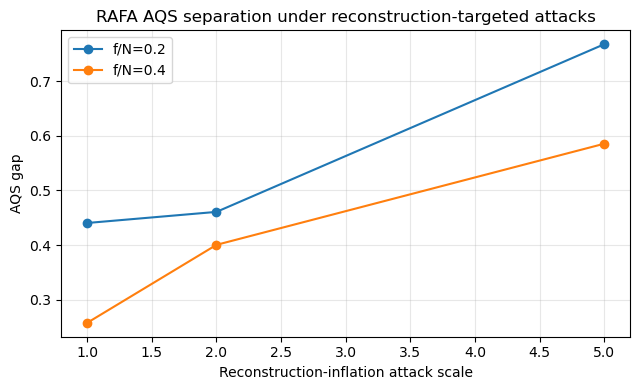

Saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig1_s2_rafa_aqs_gap.pdf
Saved alias: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig1_s1_rafa_aqs_gap.pdf


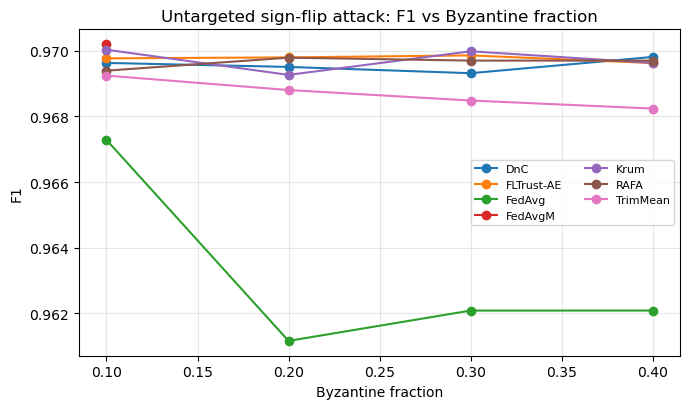

Saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig2_s1_signflip_f1.pdf
Saved alias: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig2_s2_signflip_f1.pdf
  A7 rows selected for Fig 3: 27


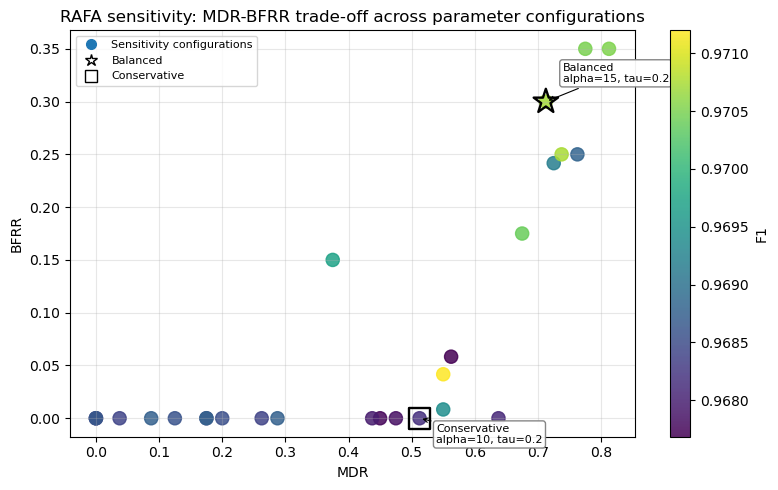

Saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig3_sensitivity_mdr_bfrr.pdf
Saved highlighted configuration summary: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig3_highlighted_configs.csv
  Configuration  alpha  beta  tau     MDR  BFRR        F1
0      Balanced   15.0   0.0  0.2  0.7125   0.3  0.970728
1  Conservative   10.0   0.0  0.2  0.5125   0.0  0.968179


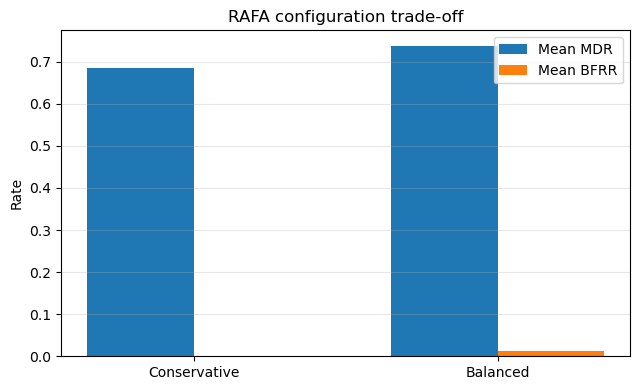

Saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig4_rafa_config_tradeoff.pdf


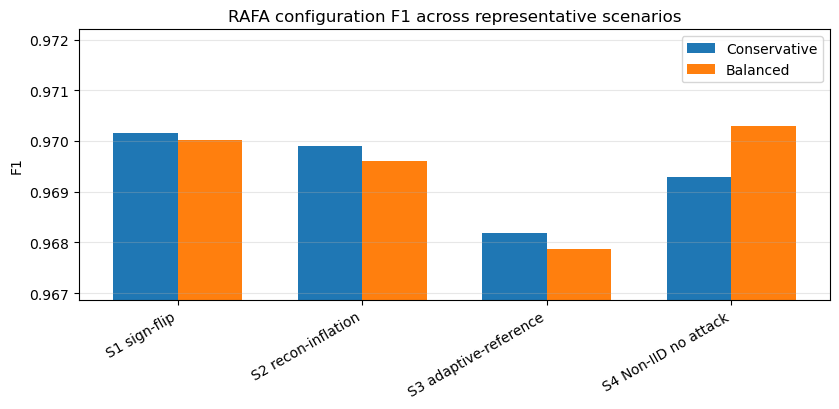

Saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig5_rafa_config_scenario_f1.pdf

[Cell 5.2] Status: OK
Saved figures: 7
Manifest     : /home/beny/Desktop/Beny_Work/RAFA/results_gpt/figures_manifest.json
  - fig1_s2_rafa_aqs_gap: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig1_s2_rafa_aqs_gap.pdf
  - fig1_s1_rafa_aqs_gap: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig1_s1_rafa_aqs_gap.pdf
  - fig2_s1_signflip_f1: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig2_s1_signflip_f1.pdf
  - fig2_s2_signflip_f1: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig2_s2_signflip_f1.pdf
  - fig3_sensitivity_mdr_bfrr: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig3_sensitivity_mdr_bfrr.pdf
  - fig4_rafa_config_tradeoff: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig4_rafa_config_tradeoff.pdf
  - fig5_rafa_config_scenario_f1: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/fig5_rafa_config_scenario_f1.pdf


In [25]:
# ======================== CELL 5.2: Figures ========================

from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

print("[Cell 5.2] Figure generation started")
print(f"Results dir: {results_dir}")

saved_figures = {}


def load_csv_if_exists(path, name):
    if path.exists():
        df = pd.read_csv(path)
        print(f"  Loaded {name}: {len(df)} rows")
        return df
    print(f"  Missing {name}: {path}")
    return None


def safe_numeric(df, cols):
    """Convert selected columns to numeric if they exist."""
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def save_current_figure(fig, fig_path, key):
    fig.savefig(fig_path, bbox_inches="tight")
    plt.show()
    saved_figures[key] = str(fig_path)
    print(f"Saved: {fig_path}")


def save_figure_alias(fig, fig_path, key):
    """Save an additional alias without showing the figure again."""
    fig.savefig(fig_path, bbox_inches="tight")
    saved_figures[key] = str(fig_path)
    print(f"Saved alias: {fig_path}")


s1_df = load_csv_if_exists(results_dir / "s1_summary.csv", "S1 summary")
s2_df = load_csv_if_exists(results_dir / "s2_summary.csv", "S2 summary")
s3_df = load_csv_if_exists(results_dir / "s3_summary.csv", "S3 summary")
a6a7_df = load_csv_if_exists(results_dir / "sensitivity_a6_a7_summary.csv", "A6-A7 sensitivity summary")
tradeoff_df = load_csv_if_exists(results_dir / "rafa_config_tradeoff_summary.csv", "RAFA config trade-off summary")


# -------------------------
# Fig 1: RAFA AQS gap vs attack strength in reconstruction-targeted attacks
# -------------------------
# Note:
# The CSV is still named s2_summary.csv in the notebook pipeline,
# but in the revised paper this scenario is now S1.

if s2_df is not None and len(s2_df) > 0:
    s2_df = safe_numeric(
        s2_df,
        ["attack_scale", "byzantine_fraction", "f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap"],
    )

    rafa_s2 = s2_df[s2_df["aggregator"] == "RAFA"].copy()
    rafa_s2 = rafa_s2.dropna(subset=["attack_scale", "byzantine_fraction", "aqs_gap"])

    if len(rafa_s2) > 0:
        fig, ax = plt.subplots(figsize=(6.5, 4.0))

        for frac, group in rafa_s2.groupby("byzantine_fraction"):
            group = group.sort_values("attack_scale")
            ax.plot(
                group["attack_scale"],
                group["aqs_gap"],
                marker="o",
                label=f"f/N={frac:.1f}",
            )

        ax.set_xlabel("Reconstruction-inflation attack scale")
        ax.set_ylabel("AQS gap")
        ax.set_title("RAFA AQS separation under reconstruction-targeted attacks")
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()

        # Save old filename for backward compatibility
        fig_path_old = results_dir / "fig1_s2_rafa_aqs_gap.pdf"
        save_current_figure(fig, fig_path_old, "fig1_s2_rafa_aqs_gap")

        # Save new filename aligned with revised paper ordering
        fig_path_new = results_dir / "fig1_s1_rafa_aqs_gap.pdf"
        save_figure_alias(fig, fig_path_new, "fig1_s1_rafa_aqs_gap")

        plt.close(fig)
    else:
        print("  Skipped Fig 1: no valid RAFA reconstruction-targeted rows with AQS gap.")


# -------------------------
# Fig 2: Untargeted sign-flip F1 vs Byzantine fraction
# -------------------------
# Note:
# The CSV is still named s1_summary.csv in the notebook pipeline,
# but in the revised paper this scenario is now S2.

if s1_df is not None and len(s1_df) > 0:
    s1_df = safe_numeric(s1_df, ["byzantine_fraction", "f1", "auc", "fpr", "asr", "mdr", "bfrr"])

    s1_sign = s1_df[s1_df["attack"] == "sign_flip"].copy()

    if len(s1_sign) > 0:
        fig, ax = plt.subplots(figsize=(7.0, 4.2))

        for agg, group in s1_sign.groupby("aggregator"):
            group = group.sort_values("byzantine_fraction")
            y_values = pd.to_numeric(group["f1"], errors="coerce")

            ax.plot(
                group["byzantine_fraction"],
                y_values,
                marker="o",
                label=agg,
            )

        ax.set_xlabel("Byzantine fraction")
        ax.set_ylabel("F1")
        ax.set_title("Untargeted sign-flip attack: F1 vs Byzantine fraction")
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, fontsize=8)
        fig.tight_layout()

        # Save old filename for backward compatibility
        fig_path_old = results_dir / "fig2_s1_signflip_f1.pdf"
        save_current_figure(fig, fig_path_old, "fig2_s1_signflip_f1")

        # Save new filename aligned with revised paper ordering
        fig_path_new = results_dir / "fig2_s2_signflip_f1.pdf"
        save_figure_alias(fig, fig_path_new, "fig2_s2_signflip_f1")

        plt.close(fig)
    else:
        print("  Skipped Fig 2: no sign-flip rows.")


# -------------------------
# Fig 3: RAFA sensitivity, MDR vs BFRR for A7 settings
# with explicit Conservative and Balanced labels
# -------------------------

if a6a7_df is not None and len(a6a7_df) > 0:
    sensitivity = safe_numeric(
        a6a7_df,
        ["reference_size", "alpha", "beta", "tau", "f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap"],
    )

    # Identify A7/sensitivity rows robustly.
    # Important:
    # We must keep the default/balanced row (alpha=15, beta=0, tau=0.2),
    # because it must be highlighted in the figure.
    if "experiment" in sensitivity.columns:
        a7_df = sensitivity[sensitivity["experiment"].astype(str).str.upper() == "A7"].copy()
    else:
        default_alpha = float(CONFIG.get("alpha", np.nan))
        default_beta = float(CONFIG.get("beta", np.nan))
        default_tau = float(CONFIG.get("tau", np.nan))

        # A6 reference-size rows are the explicit reference-size sweep.
        # Exclude only the non-default reference sizes.
        # Keep reference_size=500 because it is also used in the A7 hyperparameter sweep
        # and includes the Balanced/default configuration.
        is_a6_nondefault_ref_size = (
            sensitivity["reference_size"].isin([50, 100, 200])
            & np.isclose(sensitivity["alpha"], default_alpha, equal_nan=False)
            & np.isclose(sensitivity["beta"], default_beta, equal_nan=False)
            & np.isclose(sensitivity["tau"], default_tau, equal_nan=False)
        )

        a7_df = sensitivity[~is_a6_nondefault_ref_size].copy()

    a7_df = a7_df.dropna(subset=["alpha", "beta", "tau", "mdr", "bfrr", "f1"]).copy()

    # Remove exact duplicate parameter rows if they exist.
    # This keeps one plotted point per alpha/beta/tau combination.
    # If duplicates exist, keep the row with highest F1, then higher MDR, then lower BFRR.
    a7_df = (
        a7_df.sort_values(["alpha", "beta", "tau", "f1", "mdr", "bfrr"],
                          ascending=[True, True, True, False, False, True])
        .drop_duplicates(subset=["alpha", "beta", "tau"], keep="first")
        .copy()
    )

    print(f"  A7 rows selected for Fig 3: {len(a7_df)}")

    if len(a7_df) > 0:

        # -------------------------------------------------
        # Representative configurations to highlight
        # -------------------------------------------------
        # Preferred: infer representative configs from tradeoff_df if it contains alpha/beta/tau.
        # Fallback: use manual definitions.
        rep_cfgs = []

        if tradeoff_df is not None and len(tradeoff_df) > 0:
            tmp_trade = safe_numeric(tradeoff_df, ["alpha", "beta", "tau"])
            needed_cols = {"config_name", "alpha", "beta", "tau"}

            if needed_cols.issubset(tmp_trade.columns):
                rep_df = (
                    tmp_trade
                    .dropna(subset=["config_name", "alpha", "beta", "tau"])
                    .groupby("config_name", as_index=False)[["alpha", "beta", "tau"]]
                    .first()
                )

                for _, row in rep_df.iterrows():
                    rep_cfgs.append(
                        {
                            "name": str(row["config_name"]),
                            "alpha": float(row["alpha"]),
                            "beta": float(row["beta"]),
                            "tau": float(row["tau"]),
                        }
                    )

        # Manual fallback. Edit here if the chosen representative configurations change.
        if len(rep_cfgs) == 0:
            rep_cfgs = [
                {"name": "Conservative", "alpha": 10.0, "beta": 0.0, "tau": 0.2},
                {"name": "Balanced",     "alpha": 15.0, "beta": 0.0, "tau": 0.2},
            ]
            print("  Using manual Conservative/Balanced definitions for Fig 3.")
            for cfg in rep_cfgs:
                print(f"    {cfg['name']}: alpha={cfg['alpha']}, beta={cfg['beta']}, tau={cfg['tau']}")

        def find_matching_cfg(df, alpha, beta, tau):
            mask = (
                np.isclose(df["alpha"], alpha, equal_nan=False)
                & np.isclose(df["beta"], beta, equal_nan=False)
                & np.isclose(df["tau"], tau, equal_nan=False)
            )
            matches = df[mask].copy()
            if len(matches) == 0:
                return None

            # If duplicates exist, prefer the row with highest F1, then higher MDR, then lower BFRR.
            matches = matches.sort_values(
                ["f1", "mdr", "bfrr"],
                ascending=[False, False, True],
            )
            return matches.iloc[0]

        # -------------------------------------------------
        # Plot
        # -------------------------------------------------
        fig, ax = plt.subplots(figsize=(8.0, 5.0))

        scatter = ax.scatter(
            a7_df["mdr"],
            a7_df["bfrr"],
            s=90,
            c=a7_df["f1"],
            alpha=0.85,
        )

        # Highlight representative configurations.
        marker_styles = {
            "Conservative": {"marker": "s", "size": 230, "offset": (12, -18)},
            "Balanced": {"marker": "*", "size": 340, "offset": (12, 14)},
        }

        legend_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markersize=7,
                label="Sensitivity configurations",
            ),
        ]

        found_rep_points = []

        for cfg in rep_cfgs:
            row = find_matching_cfg(a7_df, cfg["alpha"], cfg["beta"], cfg["tau"])

            if row is None:
                print(f"  Warning: representative config not found in A7 rows -> {cfg}")
                continue

            cfg_name = cfg["name"]
            style = marker_styles.get(
                cfg_name,
                {"marker": "D", "size": 220, "offset": (10, 10)},
            )

            ax.scatter(
                [row["mdr"]],
                [row["bfrr"]],
                s=style["size"],
                marker=style["marker"],
                facecolors="none",
                edgecolors="black",
                linewidths=1.7,
                zorder=5,
            )

            # Use plain text labels for reliable PDF rendering.
            # The paper method uses reconstruction-only RAFA, so the label shows alpha and tau.
            # beta is still used internally only to match old sensitivity rows.
            label_text = (
                f"{cfg_name}\n"
                f"alpha={cfg['alpha']:g}, tau={cfg['tau']:g}"
            )

            ax.annotate(
                label_text,
                (row["mdr"], row["bfrr"]),
                xytext=style["offset"],
                textcoords="offset points",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.95),
                arrowprops=dict(arrowstyle="->", lw=0.8),
            )

            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker=style["marker"],
                    linestyle="",
                    markersize=9,
                    markerfacecolor="none",
                    markeredgecolor="black",
                    label=cfg_name,
                )
            )

            found_rep_points.append(
                {
                    "Configuration": cfg_name,
                    "alpha": cfg["alpha"],
                    "beta": cfg["beta"],
                    "tau": cfg["tau"],
                    "MDR": float(row["mdr"]),
                    "BFRR": float(row["bfrr"]),
                    "F1": float(row["f1"]),
                }
            )

        ax.set_xlabel("MDR")
        ax.set_ylabel("BFRR")
        ax.set_title("RAFA sensitivity: MDR-BFRR trade-off across parameter configurations")
        ax.grid(True, alpha=0.3)

        cbar = fig.colorbar(scatter, ax=ax)
        cbar.set_label("F1")

        ax.legend(handles=legend_handles, fontsize=8, loc="best")
        fig.tight_layout()

        fig_path = results_dir / "fig3_sensitivity_mdr_bfrr.pdf"
        save_current_figure(fig, fig_path, "fig3_sensitivity_mdr_bfrr")
        plt.close(fig)

        # Save highlighted-point summary for transparency.
        if len(found_rep_points) > 0:
            rep_df_out = pd.DataFrame(found_rep_points)
            rep_csv_path = results_dir / "fig3_highlighted_configs.csv"
            rep_df_out.to_csv(rep_csv_path, index=False)
            print(f"Saved highlighted configuration summary: {rep_csv_path}")
            print(rep_df_out)
    else:
        print("  Skipped Fig 3: no valid A7 sensitivity rows after filtering.")


# -------------------------
# Fig 4: Conservative vs Balanced MDR/BFRR trade-off
# -------------------------

if tradeoff_df is not None and len(tradeoff_df) > 0:
    tradeoff_df = safe_numeric(
        tradeoff_df,
        ["attack_scale", "byzantine_fraction", "f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap"],
    )

    tradeoff_mean = (
        tradeoff_df
        .groupby("config_name", as_index=False)
        .agg(
            mean_mdr=("mdr", "mean"),
            mean_bfrr=("bfrr", "mean"),
            mean_f1=("f1", "mean"),
            mean_aqs_gap=("aqs_gap", "mean"),
        )
    )

    preferred_order = ["Conservative", "Balanced"]
    tradeoff_mean["order"] = tradeoff_mean["config_name"].apply(
        lambda x: preferred_order.index(x) if x in preferred_order else len(preferred_order)
    )
    tradeoff_mean = tradeoff_mean.sort_values("order").drop(columns=["order"])

    x = np.arange(len(tradeoff_mean))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    ax.bar(x - width / 2, tradeoff_mean["mean_mdr"], width, label="Mean MDR")
    ax.bar(x + width / 2, tradeoff_mean["mean_bfrr"], width, label="Mean BFRR")

    ax.set_xticks(x)
    ax.set_xticklabels(tradeoff_mean["config_name"])
    ax.set_ylabel("Rate")
    ax.set_title("RAFA configuration trade-off")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    fig_path = results_dir / "fig4_rafa_config_tradeoff.pdf"
    save_current_figure(fig, fig_path, "fig4_rafa_config_tradeoff")
    plt.close(fig)


# -------------------------
# Fig 5: Scenario-level F1 for conservative vs balanced configurations
# -------------------------

if tradeoff_df is not None and len(tradeoff_df) > 0:
    fig_df = tradeoff_df.copy()
    fig_df = fig_df.dropna(subset=["config_name", "scenario", "f1"])

    if len(fig_df) > 0:
        pivot = (
            fig_df
            .pivot_table(index="scenario", columns="config_name", values="f1", aggfunc="mean")
            .reset_index()
        )

        scenario_order = list(dict.fromkeys(fig_df["scenario"].tolist()))
        pivot["scenario_order"] = pivot["scenario"].apply(
            lambda x: scenario_order.index(x) if x in scenario_order else len(scenario_order)
        )
        pivot = pivot.sort_values("scenario_order").drop(columns=["scenario_order"])

        configs = [c for c in ["Conservative", "Balanced"] if c in pivot.columns]
        if len(configs) == 0:
            configs = [c for c in pivot.columns if c != "scenario"]

        x = np.arange(len(pivot))
        width = 0.35 if len(configs) <= 2 else 0.25

        fig, ax = plt.subplots(figsize=(8.5, 4.2))

        for i, cfg in enumerate(configs):
            offset = (i - (len(configs) - 1) / 2) * width
            ax.bar(x + offset, pivot[cfg], width, label=cfg)

        ax.set_xticks(x)
        ax.set_xticklabels(pivot["scenario"], rotation=30, ha="right")
        ax.set_ylabel("F1")
        ax.set_title("RAFA configuration F1 across representative scenarios")
        ax.legend()
        ax.grid(axis="y", alpha=0.3)

        # Make the small F1 differences visible without exaggerating too much.
        y_min = max(0.0, float(np.nanmin(fig_df["f1"])) - 0.001)
        y_max = min(1.0, float(np.nanmax(fig_df["f1"])) + 0.001)
        ax.set_ylim(y_min, y_max)

        fig.tight_layout()

        fig_path = results_dir / "fig5_rafa_config_scenario_f1.pdf"
        save_current_figure(fig, fig_path, "fig5_rafa_config_scenario_f1")
        plt.close(fig)
    else:
        print("  Skipped Fig 5: no valid Cell 4.3 F1 rows.")


# -------------------------
# Save figure manifest
# -------------------------

fig_manifest_path = results_dir / "figures_manifest.json"

with open(fig_manifest_path, "w") as f:
    json.dump(saved_figures, f, indent=2)

print("\n[Cell 5.2] Status: OK")
print(f"Saved figures: {len(saved_figures)}")
print(f"Manifest     : {fig_manifest_path}")

for name, path in saved_figures.items():
    print(f"  - {name}: {path}")

In [26]:
# ======================== CELL 5.3: Runtime Overhead ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import json

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

print("[Cell 5.3] Runtime overhead analysis started")
print(f"Results dir: {results_dir}")


def load_csv_if_exists(path, name):
    if path.exists():
        df = pd.read_csv(path)
        print(f"  Loaded {name}: {len(df)} rows")
        return df
    print(f"  Missing {name}: {path}")
    return None


s1_df = load_csv_if_exists(results_dir / "s1_summary.csv", "S1 summary")
s2_df = load_csv_if_exists(results_dir / "s2_summary.csv", "S2 summary")
s3_df = load_csv_if_exists(results_dir / "s3_summary.csv", "S3 summary")
s4_df = load_csv_if_exists(results_dir / "s4_summary.csv", "S4 summary")
tradeoff_df = load_csv_if_exists(results_dir / "rafa_config_tradeoff_summary.csv", "RAFA config trade-off summary")


runtime_outputs = {}


# -------------------------
# Runtime from completed experiment summaries
# -------------------------

runtime_frames = []

for name, df in [
    ("S1", s1_df),
    ("S2", s2_df),
    ("S3", s3_df),
    ("S4", s4_df),
]:
    if df is not None and "runtime_sec" in df.columns:
        temp = df.copy()
        temp["experiment"] = name
        runtime_frames.append(temp)

if runtime_frames:
    runtime_all = pd.concat(runtime_frames, ignore_index=True)

    runtime_by_experiment = (
        runtime_all
        .groupby("experiment", as_index=False)
        .agg(
            runs=("runtime_sec", "count"),
            mean_runtime_sec=("runtime_sec", "mean"),
            std_runtime_sec=("runtime_sec", "std"),
            total_runtime_min=("runtime_sec", lambda x: x.sum() / 60.0),
        )
    )

    runtime_by_experiment["mean_runtime_sec"] = runtime_by_experiment["mean_runtime_sec"].round(2)
    runtime_by_experiment["std_runtime_sec"] = runtime_by_experiment["std_runtime_sec"].round(2)
    runtime_by_experiment["total_runtime_min"] = runtime_by_experiment["total_runtime_min"].round(2)

    runtime_exp_path = results_dir / "runtime_by_experiment.csv"
    runtime_by_experiment.to_csv(runtime_exp_path, index=False)
    runtime_outputs["runtime_by_experiment"] = str(runtime_exp_path)

    print("\nRuntime by experiment:")
    display(runtime_by_experiment)

    print("\nLaTeX runtime by experiment:")
    print(
        runtime_by_experiment.to_latex(
            index=False,
            escape=False,
            column_format="lrrrr",
            caption="Runtime summary by experiment.",
            label="tab:runtime_by_experiment",
        )
    )

    if "aggregator" in runtime_all.columns:
        runtime_by_aggregator = (
            runtime_all
            .dropna(subset=["aggregator"])
            .groupby("aggregator", as_index=False)
            .agg(
                runs=("runtime_sec", "count"),
                mean_runtime_sec=("runtime_sec", "mean"),
                std_runtime_sec=("runtime_sec", "std"),
            )
        )

        runtime_by_aggregator["mean_runtime_sec"] = runtime_by_aggregator["mean_runtime_sec"].round(2)
        runtime_by_aggregator["std_runtime_sec"] = runtime_by_aggregator["std_runtime_sec"].round(2)

        fedavg_mean = runtime_by_aggregator.loc[
            runtime_by_aggregator["aggregator"] == "FedAvg",
            "mean_runtime_sec",
        ]

        if len(fedavg_mean) > 0 and float(fedavg_mean.iloc[0]) > 0:
            base = float(fedavg_mean.iloc[0])
            runtime_by_aggregator["overhead_vs_fedavg"] = (
                runtime_by_aggregator["mean_runtime_sec"] / base
            ).round(3)
        else:
            runtime_by_aggregator["overhead_vs_fedavg"] = np.nan

        runtime_agg_path = results_dir / "runtime_by_aggregator.csv"
        runtime_by_aggregator.to_csv(runtime_agg_path, index=False)
        runtime_outputs["runtime_by_aggregator"] = str(runtime_agg_path)

        print("\nRuntime by aggregator:")
        display(runtime_by_aggregator)

        print("\nLaTeX runtime by aggregator:")
        print(
            runtime_by_aggregator.to_latex(
                index=False,
                escape=False,
                column_format="lrrrr",
                caption="Runtime summary by aggregation method.",
                label="tab:runtime_by_aggregator",
            )
        )


# -------------------------
# Cell 4.3 runtime summary
# -------------------------

if tradeoff_df is not None and "runtime_sec" in tradeoff_df.columns:
    tradeoff_runtime = (
        tradeoff_df
        .groupby("config_name", as_index=False)
        .agg(
            runs=("runtime_sec", "count"),
            mean_runtime_sec=("runtime_sec", "mean"),
            std_runtime_sec=("runtime_sec", "std"),
            total_runtime_min=("runtime_sec", lambda x: x.sum() / 60.0),
        )
    )

    tradeoff_runtime["mean_runtime_sec"] = tradeoff_runtime["mean_runtime_sec"].round(2)
    tradeoff_runtime["std_runtime_sec"] = tradeoff_runtime["std_runtime_sec"].round(2)
    tradeoff_runtime["total_runtime_min"] = tradeoff_runtime["total_runtime_min"].round(2)

    tradeoff_runtime_path = results_dir / "runtime_rafa_config_tradeoff.csv"
    tradeoff_runtime.to_csv(tradeoff_runtime_path, index=False)
    runtime_outputs["runtime_rafa_config_tradeoff"] = str(tradeoff_runtime_path)

    print("\nCell 4.3 RAFA configuration trade-off runtime:")
    display(tradeoff_runtime)

    print("\nLaTeX runtime table for Cell 4.3:")
    print(
        tradeoff_runtime.to_latex(
            index=False,
            escape=False,
            column_format="lrrrr",
            caption="Runtime summary for the RAFA configuration trade-off experiment.",
            label="tab:rafa_config_tradeoff_runtime",
        )
    )


# -------------------------
# Optional direct runtime overhead micro-benchmark
# -------------------------

RUN_RUNTIME_MICROBENCHMARK = False

if RUN_RUNTIME_MICROBENCHMARK:
    print("\nRunning direct runtime micro-benchmark...")

    runtime_rows = []
    dataset_name = ACTIVE_DATASETS[0]
    benchmark_rounds = 10

    for aggregator in AGGREGATORS:
        try:
            start = time.time()

            result = run_federation({
                "dataset_name": dataset_name,
                "aggregator": aggregator,
                "model_type": "VAE",
                "partition": "iid",
                "n_byzantine": 0,
                "attack": "none",
                "fed_rounds": benchmark_rounds,
                "max_local_batches": CONFIG.get("max_local_batches", 20),
            })

            total_sec = time.time() - start

            runtime_rows.append({
                "aggregator": aggregator,
                "rounds": benchmark_rounds,
                "total_runtime_sec": total_sec,
                "mean_runtime_per_round_sec": total_sec / benchmark_rounds,
                "final_f1": result["final_metrics"]["f1"],
            })

            print(
                f"  {aggregator}: total={total_sec:.2f}s, "
                f"per_round={total_sec / benchmark_rounds:.2f}s"
            )

        except Exception as e:
            runtime_rows.append({
                "aggregator": aggregator,
                "rounds": benchmark_rounds,
                "total_runtime_sec": np.nan,
                "mean_runtime_per_round_sec": np.nan,
                "final_f1": np.nan,
                "error": str(e),
            })

            print(f"  ERROR {aggregator}: {e}")

    runtime_micro_df = pd.DataFrame(runtime_rows)

    fedavg_runtime = runtime_micro_df.loc[
        runtime_micro_df["aggregator"] == "FedAvg",
        "mean_runtime_per_round_sec",
    ]

    if len(fedavg_runtime) > 0 and np.isfinite(fedavg_runtime.iloc[0]) and fedavg_runtime.iloc[0] > 0:
        base = fedavg_runtime.iloc[0]
        runtime_micro_df["overhead_vs_fedavg"] = (
            runtime_micro_df["mean_runtime_per_round_sec"] / base
        ).round(3)
    else:
        runtime_micro_df["overhead_vs_fedavg"] = np.nan

    runtime_micro_path = results_dir / "runtime_microbenchmark.csv"
    runtime_micro_df.to_csv(runtime_micro_path, index=False)
    runtime_outputs["runtime_microbenchmark"] = str(runtime_micro_path)

    print("\nDirect runtime micro-benchmark:")
    display(runtime_micro_df)


# -------------------------
# Save runtime manifest
# -------------------------

runtime_manifest_path = results_dir / "runtime_manifest.json"

with open(runtime_manifest_path, "w") as f:
    json.dump(runtime_outputs, f, indent=2)

print("\n[Cell 5.3] Status: OK")
print(f"Runtime outputs: {len(runtime_outputs)}")
print(f"Manifest       : {runtime_manifest_path}")

for name, path in runtime_outputs.items():
    print(f"  - {name}: {path}")

[Cell 5.3] Runtime overhead analysis started
Results dir: /home/beny/Desktop/Beny_Work/RAFA/results_gpt
  Loaded S1 summary: 56 rows
  Loaded S2 summary: 42 rows
  Loaded S3 summary: 56 rows
  Loaded S4 summary: 7 rows
  Loaded RAFA config trade-off summary: 12 rows

Runtime by experiment:


,experiment,runs,mean_runtime_sec,std_runtime_sec,total_runtime_min
0,S1,53,42.93,0.50,37.92
1,S2,42,47.36,1.64,33.15
2,S3,56,49.53,2.80,46.23
3,S4,7,41.25,0.61,4.81



LaTeX runtime by experiment:
\begin{table}
\caption{Runtime summary by experiment.}
\label{tab:runtime_by_experiment}
\begin{tabular}{lrrrr}
\toprule
experiment & runs & mean_runtime_sec & std_runtime_sec & total_runtime_min \\
\midrule
S1 & 53 & 42.930000 & 0.500000 & 37.920000 \\
S2 & 42 & 47.360000 & 1.640000 & 33.150000 \\
S3 & 56 & 49.530000 & 2.800000 & 46.230000 \\
S4 & 7 & 41.250000 & 0.610000 & 4.810000 \\
\bottomrule
\end{tabular}
\end{table}


Runtime by aggregator:


,aggregator,runs,mean_runtime_sec,std_runtime_sec,overhead_vs_fedavg
0,DnC,23,46.15,3.53,0.998
1,FLTrust-AE,23,46.29,3.39,1.001
2,FedAvg,23,46.26,3.64,1.000
3,FedAvgM,20,46.52,3.74,1.006
4,Krum,23,46.23,3.63,0.999
5,RAFA,23,47.18,3.57,1.020
6,TrimMean,23,46.01,3.64,0.995



LaTeX runtime by aggregator:
\begin{table}
\caption{Runtime summary by aggregation method.}
\label{tab:runtime_by_aggregator}
\begin{tabular}{lrrrr}
\toprule
aggregator & runs & mean_runtime_sec & std_runtime_sec & overhead_vs_fedavg \\
\midrule
DnC & 23 & 46.150000 & 3.530000 & 0.998000 \\
FLTrust-AE & 23 & 46.290000 & 3.390000 & 1.001000 \\
FedAvg & 23 & 46.260000 & 3.640000 & 1.000000 \\
FedAvgM & 20 & 46.520000 & 3.740000 & 1.006000 \\
Krum & 23 & 46.230000 & 3.630000 & 0.999000 \\
RAFA & 23 & 47.180000 & 3.570000 & 1.020000 \\
TrimMean & 23 & 46.010000 & 3.640000 & 0.995000 \\
\bottomrule
\end{tabular}
\end{table}


Cell 4.3 RAFA configuration trade-off runtime:


,config_name,runs,mean_runtime_sec,std_runtime_sec,total_runtime_min
0,Balanced,6,46.08,5.16,4.61
1,Conservative,6,46.12,4.71,4.61



LaTeX runtime table for Cell 4.3:
\begin{table}
\caption{Runtime summary for the RAFA configuration trade-off experiment.}
\label{tab:rafa_config_tradeoff_runtime}
\begin{tabular}{lrrrr}
\toprule
config_name & runs & mean_runtime_sec & std_runtime_sec & total_runtime_min \\
\midrule
Balanced & 6 & 46.080000 & 5.160000 & 4.610000 \\
Conservative & 6 & 46.120000 & 4.710000 & 4.610000 \\
\bottomrule
\end{tabular}
\end{table}


[Cell 5.3] Status: OK
Runtime outputs: 3
Manifest       : /home/beny/Desktop/Beny_Work/RAFA/results_gpt/runtime_manifest.json
  - runtime_by_experiment: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/runtime_by_experiment.csv
  - runtime_by_aggregator: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/runtime_by_aggregator.csv
  - runtime_rafa_config_tradeoff: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/runtime_rafa_config_tradeoff.csv


In [27]:
# ======================== CELL 6.1: MDR/BFRR for Krum and DnC ========================

from copy import deepcopy
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch

print("[Cell 6.1] Krum/DnC screening metrics started")

# -------------------------------------------------------------------
# Why this cell exists
# -------------------------------------------------------------------
# Your notebook uses the following aggregation function names:
#   - multi_krum_aggregate(...)
#   - dnc_aggregate(...)
#
# Therefore, this cell traces those functions directly.
# It does not expect functions named multi_krum() or dnc().


# -------------------------------------------------------------------
# Trace storage
# -------------------------------------------------------------------

_BASELINE_SCREENING_TRACE = []


def _reset_baseline_screening_trace():
    global _BASELINE_SCREENING_TRACE
    _BASELINE_SCREENING_TRACE = []


def _append_baseline_screening_trace(aggregator, accepted_ids):
    global _BASELINE_SCREENING_TRACE

    if isinstance(accepted_ids, (int, np.integer)):
        accepted_ids = [int(accepted_ids)]

    accepted_ids = sorted([int(x) for x in accepted_ids])

    _BASELINE_SCREENING_TRACE.append({
        "aggregator": aggregator,
        "accepted_ids": accepted_ids,
    })


# -------------------------------------------------------------------
# Screening metric helpers
# -------------------------------------------------------------------

def _screening_from_accepted_ids(accepted_ids, byzantine_ids, n_clients):
    """
    Convert accepted client ids into MDR/BFRR for one round.

    MDR  = fraction of malicious updates rejected
    BFRR = fraction of benign updates rejected
    """
    all_ids = set(range(int(n_clients)))
    accepted_ids = set([int(x) for x in accepted_ids])
    rejected_ids = all_ids - accepted_ids

    byzantine_ids = set([int(x) for x in byzantine_ids])
    benign_ids = all_ids - byzantine_ids

    if len(byzantine_ids) > 0:
        mdr = len(rejected_ids & byzantine_ids) / len(byzantine_ids)
    else:
        mdr = np.nan

    if len(benign_ids) > 0:
        bfrr = len(rejected_ids & benign_ids) / len(benign_ids)
    else:
        bfrr = np.nan

    return {
        "accepted_ids": sorted(list(accepted_ids)),
        "rejected_ids": sorted(list(rejected_ids)),
        "mdr": float(mdr) if np.isfinite(mdr) else np.nan,
        "bfrr": float(bfrr) if np.isfinite(bfrr) else np.nan,
    }


def _summarize_baseline_screening_trace(trace, byzantine_ids, n_clients):
    """
    Average MDR/BFRR over all traced rounds.
    """
    if len(trace) == 0:
        return {
            "mdr": np.nan,
            "bfrr": np.nan,
            "rounds": 0,
            "round_metrics": [],
        }

    round_metrics = []

    for item in trace:
        round_metrics.append(
            _screening_from_accepted_ids(
                accepted_ids=item["accepted_ids"],
                byzantine_ids=byzantine_ids,
                n_clients=n_clients,
            )
        )

    mdr_values = [x["mdr"] for x in round_metrics if np.isfinite(x["mdr"])]
    bfrr_values = [x["bfrr"] for x in round_metrics if np.isfinite(x["bfrr"])]

    return {
        "mdr": float(np.mean(mdr_values)) if len(mdr_values) > 0 else np.nan,
        "bfrr": float(np.mean(bfrr_values)) if len(bfrr_values) > 0 else np.nan,
        "rounds": len(round_metrics),
        "round_metrics": round_metrics,
    }


# -------------------------------------------------------------------
# Save original aggregation functions
# -------------------------------------------------------------------

if "multi_krum_aggregate" not in globals():
    raise RuntimeError("multi_krum_aggregate() is not defined. Please run Cell 2.2 first.")

if "dnc_aggregate" not in globals():
    raise RuntimeError("dnc_aggregate() is not defined. Please run Cell 2.2 first.")

if "run_federation" not in globals():
    raise RuntimeError("run_federation(config) is not defined. Please run Cell 2.4 first.")

_ORIG_MULTI_KRUM_AGGREGATE = multi_krum_aggregate
_ORIG_DNC_AGGREGATE = dnc_aggregate


# -------------------------------------------------------------------
# Traced wrappers
# -------------------------------------------------------------------

def multi_krum_aggregate_with_trace(global_model, client_updates, n_byzantine):
    """
    Wraps your existing multi_krum_aggregate() and records which update was accepted.
    In your current implementation, Krum accepts one selected update.
    """
    new_model, info = _ORIG_MULTI_KRUM_AGGREGATE(
        global_model=global_model,
        client_updates=client_updates,
        n_byzantine=n_byzantine,
    )

    selected_idx = info.get("selected_idx", None)

    if selected_idx is None:
        raise RuntimeError("multi_krum_aggregate() did not return info['selected_idx'].")

    _append_baseline_screening_trace("Krum", [int(selected_idx)])

    return new_model, info


def dnc_aggregate_with_trace(global_model, client_updates, n_byzantine):
    """
    Wraps your existing dnc_aggregate() and records which updates were accepted.
    In your current implementation, DnC accepts info['selected_idx'].
    """
    new_model, info = _ORIG_DNC_AGGREGATE(
        global_model=global_model,
        client_updates=client_updates,
        n_byzantine=n_byzantine,
    )

    selected_idx = info.get("selected_idx", None)

    if selected_idx is None:
        raise RuntimeError("dnc_aggregate() did not return info['selected_idx'].")

    _append_baseline_screening_trace("DnC", selected_idx)

    return new_model, info


def enable_baseline_screening_trace():
    globals()["multi_krum_aggregate"] = multi_krum_aggregate_with_trace
    globals()["dnc_aggregate"] = dnc_aggregate_with_trace


def disable_baseline_screening_trace():
    globals()["multi_krum_aggregate"] = _ORIG_MULTI_KRUM_AGGREGATE
    globals()["dnc_aggregate"] = _ORIG_DNC_AGGREGATE


# -------------------------------------------------------------------
# Main wrapper around run_federation()
# -------------------------------------------------------------------

def run_federation_with_baseline_screening(config):
    """
    Runs run_federation(config) and adds comparable screening metrics.

    For RAFA:
        Uses result["screening"] from the original notebook.

    For Krum and DnC:
        Traces which client updates are accepted each round and computes MDR/BFRR.

    For other aggregators:
        Returns the original result, with screening values left as NaN.
    """
    config = deepcopy(config)
    aggregator = config.get("aggregator")

    if aggregator in ["Krum", "DnC"]:
        _reset_baseline_screening_trace()
        enable_baseline_screening_trace()

        try:
            result = run_federation(config)
        finally:
            disable_baseline_screening_trace()

        byzantine_ids = result.get("byzantine_ids", [])
        n_clients = int(CONFIG["n_clients"])

        baseline_screening = _summarize_baseline_screening_trace(
            trace=_BASELINE_SCREENING_TRACE,
            byzantine_ids=byzantine_ids,
            n_clients=n_clients,
        )

        result["baseline_screening"] = baseline_screening
        result["baseline_screening_trace"] = deepcopy(_BASELINE_SCREENING_TRACE)

        # For convenience in Cell 6.2, also expose it under a common key.
        result["screening_comparable"] = {
            "mdr": baseline_screening["mdr"],
            "bfrr": baseline_screening["bfrr"],
            "rounds": baseline_screening["rounds"],
        }

        return result

    result = run_federation(config)

    if aggregator == "RAFA":
        screening = result.get("screening", {"mdr": np.nan, "bfrr": np.nan})
        result["screening_comparable"] = {
            "mdr": screening.get("mdr", np.nan),
            "bfrr": screening.get("bfrr", np.nan),
            "rounds": len(result.get("aqs_history", [])),
        }
    else:
        result["screening_comparable"] = {
            "mdr": np.nan,
            "bfrr": np.nan,
            "rounds": np.nan,
        }

    return result


# -------------------------------------------------------------------
# Quick smoke test helper
# -------------------------------------------------------------------

def smoke_test_baseline_screening():
    """
    Small optional test. Run this only if you want to confirm Cell 6.1 works.
    """
    dataset_name = ACTIVE_DATASETS[0] if "ACTIVE_DATASETS" in globals() else "CICIoT2023"

    cfg = {
        "dataset_name": dataset_name,
        "aggregator": "Krum",
        "model_type": "VAE",
        "partition": "iid",
        "n_byzantine": 1,
        "attack": "sign_flip",
        "fed_rounds": 1,
        "max_local_batches": 1,
    }

    res = run_federation_with_baseline_screening(cfg)

    print("Smoke test result:")
    print(f"  Aggregator: {cfg['aggregator']}")
    print(f"  Byzantine : {res.get('byzantine_ids')}")
    print(f"  Screening : {res.get('screening_comparable')}")
    print(f"  F1        : {res['final_metrics']['f1']:.4f}")

    return res


print("""
[Cell 6.1] Loaded successfully.

Main function:
    result = run_federation_with_baseline_screening(config)

Optional smoke test:
    smoke_result = smoke_test_baseline_screening()

Important:
- Krum MDR/BFRR are based on the single selected update in each round.
- DnC MDR/BFRR are based on the selected inlier updates in each round.
- RAFA MDR/BFRR use the existing result["screening"] values.
""")

[Cell 6.1] Krum/DnC screening metrics started

[Cell 6.1] Loaded successfully.

Main function:
    result = run_federation_with_baseline_screening(config)

Optional smoke test:
    smoke_result = smoke_test_baseline_screening()

Important:
- Krum MDR/BFRR are based on the single selected update in each round.
- DnC MDR/BFRR are based on the selected inlier updates in each round.
- RAFA MDR/BFRR use the existing result["screening"] values.



In [28]:
# ======================== CELL 6.2: RAFA vs Krum/DnC Screening Comparison Tables ========================

from copy import deepcopy
from pathlib import Path
import json
import numpy as np
import pandas as pd

print("[Cell 6.2] RAFA vs Krum/DnC screening comparison started")

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------------------
# User controls
# -------------------------------------------------------------------
# "paper" = compact representative comparison.
# "full"  = full S1/S2/S3/S4 comparison and may take much longer.
CELL_6_2_SCOPE = "paper"

CELL_6_2_DATASETS = ACTIVE_DATASETS if "ACTIVE_DATASETS" in globals() else ["CICIoT2023"]
CELL_6_2_AGGREGATORS = ["RAFA", "Krum", "DnC"]

CELL_6_2_MAX_LOCAL_BATCHES = 20
CELL_6_2_FED_ROUNDS = CONFIG["fed_rounds"]


# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def _format_float(x, ndigits=4):
    x = _safe_float(x)
    if not np.isfinite(x):
        return "--"
    return f"{x:.{ndigits}f}"


def _format_fraction(x):
    x = _safe_float(x)
    if not np.isfinite(x):
        return "--"
    return f"{x:.1f}"


def _normalize_attack_name(x):
    if x is None:
        return "none"

    x = str(x).strip()

    mapping = {
        "sign_flip": "sign-flip",
        "sign-flip": "sign-flip",
        "noise": "noise",
        "recon_inflation": "recon-inflation",
        "reconstruction_inflation": "recon-inflation",
        "adaptive_score": "adaptive-score",
        "adaptive-score": "adaptive-score",
        "adaptive_reference": "adaptive-reference",
        "adaptive-reference": "adaptive-reference",
        "none": "none",
    }

    return mapping.get(x, x)


def _set_attack_scale_for_config(cfg):
    """
    Your run_federation() reads attack strength from CONFIG.
    This helper temporarily sets the correct attack scale before each run.
    """
    attack = cfg.get("attack", "none")
    attack_scale = cfg.get("attack_scale", None)

    old_values = {
        "recon_inflation_scale": CONFIG.get("recon_inflation_scale", None),
        "adaptive_attack_scale": CONFIG.get("adaptive_attack_scale", None),
    }

    if attack == "recon_inflation" and attack_scale is not None:
        CONFIG["recon_inflation_scale"] = float(attack_scale)

    if attack in ["adaptive_score", "adaptive_reference"] and attack_scale is not None:
        CONFIG["adaptive_attack_scale"] = float(attack_scale)

    return old_values


def _restore_attack_scale(old_values):
    for key, value in old_values.items():
        if value is None:
            if key in CONFIG:
                CONFIG.pop(key, None)
        else:
            CONFIG[key] = value


def _extract_row_from_result(result, cfg):
    metrics = result.get("final_metrics", {})
    screening = result.get("screening_comparable", {})
    aqs_summary = result.get("aqs_summary", {})

    return {
        "scenario": cfg.get("scenario", "Unknown"),
        "dataset": cfg.get("dataset_name"),
        "aggregator": cfg.get("aggregator"),
        "attack": _normalize_attack_name(cfg.get("attack", "none")),
        "attack_scale": cfg.get("attack_scale", np.nan),
        "byzantine_fraction": cfg.get("byzantine_fraction", np.nan),
        "n_byzantine": cfg.get("n_byzantine", np.nan),
        "partition": cfg.get("partition", "iid"),
        "f1": metrics.get("f1", np.nan),
        "auc": metrics.get("auc", np.nan),
        "fpr": metrics.get("fpr", np.nan),
        "asr": metrics.get("asr", np.nan),
        "mdr": screening.get("mdr", np.nan),
        "bfrr": screening.get("bfrr", np.nan),
        "screening_rounds": screening.get("rounds", np.nan),
        "mean_aqs_benign": aqs_summary.get("mean_aqs_benign", np.nan),
        "mean_aqs_malicious": aqs_summary.get("mean_aqs_malicious", np.nan),
        "aqs_gap": aqs_summary.get("aqs_gap", np.nan),
        "runtime_sec": result.get("runtime_sec", np.nan),
    }


def _run_one_comparison_config(cfg):
    old_values = _set_attack_scale_for_config(cfg)

    try:
        result = run_federation_with_baseline_screening(cfg)
    finally:
        _restore_attack_scale(old_values)

    return result


# -------------------------------------------------------------------
# Build configs
# -------------------------------------------------------------------

def build_cell_6_2_configs(scope="paper"):
    configs = []

    if scope not in ["paper", "full"]:
        raise ValueError("scope must be either 'paper' or 'full'.")

    for dataset_name in CELL_6_2_DATASETS:

        # -------------------------
        # S1
        # -------------------------
        if scope == "full":
            s1_attacks = ["noise", "sign_flip"]
            s1_fractions = [0.1, 0.2, 0.3, 0.4]
        else:
            # Compact comparison aligned with the paper's main robustness claim.
            s1_attacks = ["sign_flip"]
            s1_fractions = [0.2, 0.4]

        for attack in s1_attacks:
            for frac in s1_fractions:
                n_byzantine = int(round(CONFIG["n_clients"] * frac))

                for aggregator in CELL_6_2_AGGREGATORS:
                    configs.append({
                        "scenario": "S1",
                        "dataset_name": dataset_name,
                        "aggregator": aggregator,
                        "model_type": "VAE",
                        "partition": "iid",
                        "n_byzantine": n_byzantine,
                        "byzantine_fraction": frac,
                        "attack": attack,
                        "attack_scale": 1.0,
                        "fed_rounds": CELL_6_2_FED_ROUNDS,
                        "max_local_batches": CELL_6_2_MAX_LOCAL_BATCHES,
                    })

        # -------------------------
        # S2
        # -------------------------
        if scope == "full":
            s2_scales = [1.0, 2.0, 5.0]
            s2_fractions = [0.2, 0.4]
        else:
            # Compact comparison focused on stronger targeted attacks.
            s2_scales = [2.0, 5.0]
            s2_fractions = [0.4]

        for attack_scale in s2_scales:
            for frac in s2_fractions:
                n_byzantine = int(round(CONFIG["n_clients"] * frac))

                for aggregator in CELL_6_2_AGGREGATORS:
                    configs.append({
                        "scenario": "S2",
                        "dataset_name": dataset_name,
                        "aggregator": aggregator,
                        "model_type": "VAE",
                        "partition": "iid",
                        "n_byzantine": n_byzantine,
                        "byzantine_fraction": frac,
                        "attack": "recon_inflation",
                        "attack_scale": attack_scale,
                        "fed_rounds": CELL_6_2_FED_ROUNDS,
                        "max_local_batches": CELL_6_2_MAX_LOCAL_BATCHES,
                    })

        # -------------------------
        # S3
        # -------------------------
        if scope == "full":
            s3_variants = ["adaptive_score", "adaptive_reference"]
            s3_scales = [1.0, 2.0]
            s3_fractions = [0.2, 0.4]
        else:
            # Compact comparison focused on the stronger adaptive setting.
            s3_variants = ["adaptive_score", "adaptive_reference"]
            s3_scales = [2.0]
            s3_fractions = [0.4]

        for variant in s3_variants:
            for attack_scale in s3_scales:
                for frac in s3_fractions:
                    n_byzantine = int(round(CONFIG["n_clients"] * frac))

                    for aggregator in CELL_6_2_AGGREGATORS:
                        configs.append({
                            "scenario": "S3",
                            "dataset_name": dataset_name,
                            "aggregator": aggregator,
                            "model_type": "VAE",
                            "partition": "iid",
                            "n_byzantine": n_byzantine,
                            "byzantine_fraction": frac,
                            "attack": variant,
                            "attack_scale": attack_scale,
                            "fed_rounds": CELL_6_2_FED_ROUNDS,
                            "max_local_batches": CELL_6_2_MAX_LOCAL_BATCHES,
                        })

        # -------------------------
        # S4
        # -------------------------
        for aggregator in CELL_6_2_AGGREGATORS:
            configs.append({
                "scenario": "S4",
                "dataset_name": dataset_name,
                "aggregator": aggregator,
                "model_type": "VAE",
                "partition": "noniid",
                "n_byzantine": 0,
                "byzantine_fraction": 0.0,
                "attack": "none",
                "attack_scale": 1.0,
                "fed_rounds": CELL_6_2_FED_ROUNDS,
                "max_local_batches": CELL_6_2_MAX_LOCAL_BATCHES,
            })

    return configs


# -------------------------------------------------------------------
# Run comparison
# -------------------------------------------------------------------

comparison_configs = build_cell_6_2_configs(scope=CELL_6_2_SCOPE)

print(f"Comparison scope : {CELL_6_2_SCOPE}")
print(f"Datasets         : {CELL_6_2_DATASETS}")
print(f"Aggregators      : {CELL_6_2_AGGREGATORS}")
print(f"Total runs       : {len(comparison_configs)}")
print(f"Fed rounds       : {CELL_6_2_FED_ROUNDS}")
print(f"Max local batches: {CELL_6_2_MAX_LOCAL_BATCHES}")
print(f"Results dir      : {results_dir.resolve()}")

comparison_rows = []
comparison_errors = {}

for run_id, cfg in enumerate(comparison_configs, start=1):
    key = (
        cfg["scenario"],
        cfg["dataset_name"],
        cfg["aggregator"],
        cfg["attack"],
        cfg["attack_scale"],
        cfg["byzantine_fraction"],
    )

    print(
        f"[{run_id}/{len(comparison_configs)}] "
        f"{cfg['scenario']} | {cfg['aggregator']} | "
        f"attack={cfg['attack']} | scale={cfg['attack_scale']} | "
        f"f/N={cfg['byzantine_fraction']}"
    )

    try:
        result = _run_one_comparison_config(cfg)
        comparison_rows.append(_extract_row_from_result(result, cfg))

    except Exception as e:
        comparison_errors[str(key)] = str(e)
        print(f"  ERROR: {e}")

comparison_df = pd.DataFrame(comparison_rows)

# Numeric cleanup
numeric_cols = [
    "attack_scale", "byzantine_fraction", "n_byzantine",
    "f1", "auc", "fpr", "asr", "mdr", "bfrr",
    "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
    "runtime_sec",
]

for col in numeric_cols:
    if col in comparison_df.columns:
        comparison_df[col] = pd.to_numeric(comparison_df[col], errors="coerce")

scenario_order = {"S1": 1, "S2": 2, "S3": 3, "S4": 4}

if len(comparison_df) > 0:
    comparison_df["scenario_order"] = comparison_df["scenario"].map(scenario_order).fillna(99)
    comparison_df = comparison_df.sort_values(
        ["scenario_order", "attack", "attack_scale", "byzantine_fraction", "aggregator"]
    ).drop(columns=["scenario_order"]).reset_index(drop=True)

print("\nComparison results:")
display(comparison_df)

if comparison_errors:
    print("\nErrors:")
    for k, v in comparison_errors.items():
        print(f"  - {k}: {v}")


# -------------------------------------------------------------------
# Save raw output
# -------------------------------------------------------------------

raw_csv_path = results_dir / "baseline_screening_rafa_krum_dnc_raw.csv"
comparison_df.to_csv(raw_csv_path, index=False)

errors_path = results_dir / "baseline_screening_rafa_krum_dnc_errors.json"
with open(errors_path, "w", encoding="utf-8") as f:
    json.dump(comparison_errors, f, indent=2)

print(f"\nSaved raw comparison: {raw_csv_path}")
print(f"Saved errors        : {errors_path}")


# -------------------------------------------------------------------
# Build paper-ready compact tables
# -------------------------------------------------------------------

def make_compact_screening_table(df):
    """
    Compact table: one row per scenario/attack setting/aggregator.
    """
    keep_cols = [
        "scenario", "attack", "attack_scale", "byzantine_fraction",
        "aggregator", "f1", "mdr", "bfrr", "aqs_gap", "runtime_sec"
    ]

    out = df[keep_cols].copy()

    out = out.rename(columns={
        "attack_scale": "scale",
        "byzantine_fraction": "f/N",
        "aggregator": "Aggregator",
        "f1": "F1",
        "mdr": "MDR",
        "bfrr": "BFRR",
        "aqs_gap": "AQS gap",
        "runtime_sec": "Runtime (s)",
    })

    return out


compact_table = make_compact_screening_table(comparison_df)

compact_csv_path = results_dir / "table_rafa_krum_dnc_screening_comparison.csv"
compact_table.to_csv(compact_csv_path, index=False)

print(f"Saved compact comparison table: {compact_csv_path}")

display(compact_table)


# -------------------------------------------------------------------
# LaTeX table
# -------------------------------------------------------------------

def build_compact_latex_table(table_df):
    lines = []

    lines.append(r"\begin{table*}[t]")
    lines.append(r"\centering")
    lines.append(r"\caption{Screening comparison between RAFA, Krum, and DnC.}")
    lines.append(r"\label{tab:screening_comparison_rafa_krum_dnc}")
    lines.append(r"\scriptsize")
    lines.append(r"\setlength{\tabcolsep}{4pt}")
    lines.append(r"\begin{tabular}{lllrlrrrr}")
    lines.append(r"\toprule")
    lines.append(r"Scenario & Attack & Scale & $f/N$ & Aggregator & F1 & MDR & BFRR & AQS gap \\")
    lines.append(r"\midrule")

    previous_scenario = None

    for _, row in table_df.iterrows():
        scenario = row["scenario"]

        if previous_scenario is not None and scenario != previous_scenario:
            lines.append(r"\midrule")

        previous_scenario = scenario

        scale_value = _format_fraction(row["scale"])
        frac_value = _format_fraction(row["f/N"])

        lines.append(
            f"{scenario} & "
            f"{row['attack']} & "
            f"{scale_value} & "
            f"{frac_value} & "
            f"{row['Aggregator']} & "
            f"{_format_float(row['F1'])} & "
            f"{_format_float(row['MDR'])} & "
            f"{_format_float(row['BFRR'])} & "
            f"{_format_float(row['AQS gap'])} \\\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table*}")

    return "\n".join(lines)


comparison_latex = build_compact_latex_table(compact_table)

latex_path = results_dir / "table_rafa_krum_dnc_screening_comparison.tex"
with open(latex_path, "w", encoding="utf-8") as f:
    f.write(comparison_latex)

print(f"Saved LaTeX table: {latex_path}")
print("\nLaTeX table:\n")
print(comparison_latex)


# -------------------------------------------------------------------
# Manifest
# -------------------------------------------------------------------

manifest = {
    "scope": CELL_6_2_SCOPE,
    "raw_csv": str(raw_csv_path),
    "compact_csv": str(compact_csv_path),
    "latex_table": str(latex_path),
    "errors_json": str(errors_path),
    "total_runs_requested": len(comparison_configs),
    "total_runs_completed": int(len(comparison_df)),
    "total_errors": int(len(comparison_errors)),
}

manifest_path = results_dir / "baseline_screening_rafa_krum_dnc_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print(f"\nManifest saved: {manifest_path}")
print("[Cell 6.2] Status:", "OK" if not comparison_errors else "CHECK_ERRORS")

[Cell 6.2] RAFA vs Krum/DnC screening comparison started
Comparison scope : paper
Datasets         : ['CICIoT2023']
Aggregators      : ['RAFA', 'Krum', 'DnC']
Total runs       : 21
Fed rounds       : 20
Max local batches: 20
Results dir      : /home/beny/Desktop/Beny_Work/RAFA/results_gpt
[1/21] S1 | RAFA | attack=sign_flip | scale=1.0 | f/N=0.2
[2/21] S1 | Krum | attack=sign_flip | scale=1.0 | f/N=0.2
[3/21] S1 | DnC | attack=sign_flip | scale=1.0 | f/N=0.2
[4/21] S1 | RAFA | attack=sign_flip | scale=1.0 | f/N=0.4
[5/21] S1 | Krum | attack=sign_flip | scale=1.0 | f/N=0.4
[6/21] S1 | DnC | attack=sign_flip | scale=1.0 | f/N=0.4
[7/21] S2 | RAFA | attack=recon_inflation | scale=2.0 | f/N=0.4
[8/21] S2 | Krum | attack=recon_inflation | scale=2.0 | f/N=0.4
[9/21] S2 | DnC | attack=recon_inflation | scale=2.0 | f/N=0.4
[10/21] S2 | RAFA | attack=recon_inflation | scale=5.0 | f/N=0.4
[11/21] S2 | Krum | attack=recon_inflation | scale=5.0 | f/N=0.4
[12/21] S2 | DnC | attack=recon_inflation |

,scenario,dataset,aggregator,attack,attack_scale,byzantine_fraction,n_byzantine,partition,f1,auc,fpr,asr,mdr,bfrr,screening_rounds,mean_aqs_benign,mean_aqs_malicious,aqs_gap,runtime_sec
0,S1,CICIoT2023,DnC,sign-flip,1.0,0.2,2,iid,0.969559,0.969248,0.052136,0.058578,1.0000,0.000000,20,NaN,NaN,NaN,41.624267
1,S1,CICIoT2023,Krum,sign-flip,1.0,0.2,2,iid,0.969777,0.969595,0.052098,0.058166,1.0000,0.875000,20,NaN,NaN,NaN,40.691592
2,S1,CICIoT2023,RAFA,sign-flip,1.0,0.2,2,iid,0.969704,0.969404,0.052230,0.058304,0.9250,0.000000,20,1.000000,0.082287,0.917713,42.416493
3,S1,CICIoT2023,DnC,sign-flip,1.0,0.4,4,iid,0.969330,0.969130,0.052268,0.059008,0.9875,0.008333,20,NaN,NaN,NaN,41.760156
4,S1,CICIoT2023,Krum,sign-flip,1.0,0.4,4,iid,0.969494,0.969344,0.051776,0.058703,1.0000,0.833333,20,NaN,NaN,NaN,40.969918
5,S1,CICIoT2023,RAFA,sign-flip,1.0,0.4,4,iid,0.970667,0.976449,0.051473,0.056493,0.7125,0.008333,20,0.951253,0.196555,0.754698,41.665687
6,S2,CICIoT2023,DnC,recon-inflation,2.0,0.4,4,iid,0.969390,0.969151,0.052249,0.058894,0.9750,0.016667,20,NaN,NaN,NaN,46.583460
7,S2,CICIoT2023,Krum,recon-inflation,2.0,0.4,4,iid,0.969183,0.969163,0.052022,0.059287,1.0000,0.833333,20,NaN,NaN,NaN,47.115403
8,S2,CICIoT2023,RAFA,recon-inflation,2.0,0.4,4,iid,0.967647,0.967930,0.052003,0.062175,0.5500,0.000000,20,0.856446,0.435186,0.421260,48.825182
9,S2,CICIoT2023,DnC,recon-inflation,5.0,0.4,4,iid,0.968063,0.968474,0.052060,0.061393,0.9625,0.025000,20,NaN,NaN,NaN,47.891799



Saved raw comparison: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/baseline_screening_rafa_krum_dnc_raw.csv
Saved errors        : /home/beny/Desktop/Beny_Work/RAFA/results_gpt/baseline_screening_rafa_krum_dnc_errors.json
Saved compact comparison table: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/table_rafa_krum_dnc_screening_comparison.csv


,scenario,attack,scale,f/N,Aggregator,F1,MDR,BFRR,AQS gap,Runtime (s)
0,S1,sign-flip,1.0,0.2,DnC,0.969559,1.0000,0.000000,NaN,41.624267
1,S1,sign-flip,1.0,0.2,Krum,0.969777,1.0000,0.875000,NaN,40.691592
2,S1,sign-flip,1.0,0.2,RAFA,0.969704,0.9250,0.000000,0.917713,42.416493
3,S1,sign-flip,1.0,0.4,DnC,0.969330,0.9875,0.008333,NaN,41.760156
4,S1,sign-flip,1.0,0.4,Krum,0.969494,1.0000,0.833333,NaN,40.969918
5,S1,sign-flip,1.0,0.4,RAFA,0.970667,0.7125,0.008333,0.754698,41.665687
6,S2,recon-inflation,2.0,0.4,DnC,0.969390,0.9750,0.016667,NaN,46.583460
7,S2,recon-inflation,2.0,0.4,Krum,0.969183,1.0000,0.833333,NaN,47.115403
8,S2,recon-inflation,2.0,0.4,RAFA,0.967647,0.5500,0.000000,0.421260,48.825182
9,S2,recon-inflation,5.0,0.4,DnC,0.968063,0.9625,0.025000,NaN,47.891799


Saved LaTeX table: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/table_rafa_krum_dnc_screening_comparison.tex

LaTeX table:

\begin{table*}[t]
\centering
\caption{Screening comparison between RAFA, Krum, and DnC.}
\label{tab:screening_comparison_rafa_krum_dnc}
\scriptsize
\setlength{\tabcolsep}{4pt}
\begin{tabular}{lllrlrrrr}
\toprule
Scenario & Attack & Scale & $f/N$ & Aggregator & F1 & MDR & BFRR & AQS gap \\
\midrule
S1 & sign-flip & 1.0 & 0.2 & DnC & 0.9696 & 1.0000 & 0.0000 & -- \\
S1 & sign-flip & 1.0 & 0.2 & Krum & 0.9698 & 1.0000 & 0.8750 & -- \\
S1 & sign-flip & 1.0 & 0.2 & RAFA & 0.9697 & 0.9250 & 0.0000 & 0.9177 \\
S1 & sign-flip & 1.0 & 0.4 & DnC & 0.9693 & 0.9875 & 0.0083 & -- \\
S1 & sign-flip & 1.0 & 0.4 & Krum & 0.9695 & 1.0000 & 0.8333 & -- \\
S1 & sign-flip & 1.0 & 0.4 & RAFA & 0.9707 & 0.7125 & 0.0083 & 0.7547 \\
\midrule
S2 & recon-inflation & 2.0 & 0.4 & DnC & 0.9694 & 0.9750 & 0.0167 & -- \\
S2 & recon-inflation & 2.0 & 0.4 & Krum & 0.9692 & 1.0000 & 0.8333 & -- \

In [29]:
# ======================== CELL 7.1: CIC-DDoS2019 Dataset Registration, Cleaning, and Subset Selection ========================

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("[Cell 7.1] CIC-DDoS2019 memory-safe setup started", flush=True)

# -------------------------
# Path and compact settings
# -------------------------

CICDDOS_ROOT_CANDIDATES = [
    Path.cwd() / "../../Beny_PhD/Datasets/CICDDoS2019",
    Path.home() / "Desktop/Beny_PhD/Datasets/CICDDoS2019",
]

CICDDOS_ROOT = next((p.resolve() for p in CICDDOS_ROOT_CANDIDATES if p.exists()), None)

if CICDDOS_ROOT is None:
    raise FileNotFoundError(
        "CIC-DDoS2019 folder not found. Checked: "
        + ", ".join(str(p) for p in CICDDOS_ROOT_CANDIDATES)
    )

CICDDOS_FILES = [
    "DrDoS_LDAP.csv", "MSSQL.csv", "UDPLag.csv", "UDP.csv", "Portmap.csv",
    "LDAP.csv", "DrDoS_NetBIOS.csv", "DrDoS_UDP.csv", "DrDoS_DNS.csv",
    "UDPLag_2.csv", "DrDoS_SSDP.csv", "Syn.csv", "DrDoS_SNMP.csv",
    "Syn_1.csv", "NetBIOS.csv", "DrDoS_MSSQL.csv", "DrDoS_NTP.csv", "TFTP.csv",
]

CICDDOS_PREFERRED_FILES = [
    "DrDoS_NTP.csv", "DrDoS_DNS.csv", "Portmap.csv", "Syn.csv", "DrDoS_UDP.csv"
]

# Keep this conservative first. Increase later only after Cell 7.1 is stable.
CICDDOS_MAX_SELECTED = int(CONFIG.get("cicddos_max_selected_subsets", 2))

CICDDOS_MIN_BENIGN = int(CONFIG.get("cicddos_min_benign_samples", 2000))
CICDDOS_MIN_ATTACK = int(CONFIG.get("cicddos_min_attack_samples", 2000))

# Memory-safe row caps per selected CSV.
CICDDOS_MAX_BENIGN_ROWS = int(CONFIG.get("cicddos_max_benign_rows", 120000))
CICDDOS_MAX_ATTACK_ROWS = int(CONFIG.get("cicddos_max_attack_rows", 300000))
CICDDOS_CHUNKSIZE = int(CONFIG.get("cicddos_chunksize", 100000))

CICDDOS_DROP_COLS = {
    "Unnamed: 0", "Flow ID", "Source IP", "Destination IP",
    "Source Port", "Destination Port", "Timestamp", "SimillarHTTP"
}

print(f"Dataset root       : {CICDDOS_ROOT}", flush=True)
print(f"Max selected files : {CICDDOS_MAX_SELECTED}", flush=True)
print(f"Benign row cap     : {CICDDOS_MAX_BENIGN_ROWS:,}", flush=True)
print(f"Attack row cap     : {CICDDOS_MAX_ATTACK_ROWS:,}", flush=True)
print(f"Chunk size         : {CICDDOS_CHUNKSIZE:,}", flush=True)


# -------------------------
# Helpers
# -------------------------

def _strip_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df


def _find_label_col(columns):
    for col in columns:
        if str(col).strip().lower() == "label":
            return col
    raise ValueError("No Label column found.")


def _safe_dataset_name(csv_name):
    stem = Path(csv_name).stem.replace("DrDoS_", "")
    return f"CICDDoS2019_{stem}"


def _raw_col_map(path):
    header_raw = pd.read_csv(path, nrows=0, low_memory=True)
    return {str(c).strip(): c for c in header_raw.columns}


def _scan_cicddos_file(csv_name):
    path = CICDDOS_ROOT / csv_name

    if not path.exists():
        return {
            "file": csv_name,
            "path": str(path),
            "exists": False,
            "usable": False,
            "reason": "missing_file",
        }

    header_raw = pd.read_csv(path, nrows=0, low_memory=True)
    raw_label_col = _find_label_col(header_raw.columns)

    sample = pd.read_csv(path, nrows=2000, low_memory=True)
    sample = _strip_columns(sample)

    label_col = "Label"

    candidate_cols = [
        c for c in sample.columns
        if c != label_col and c not in CICDDOS_DROP_COLS
    ]

    numeric_cols = []
    for col in candidate_cols:
        converted = pd.to_numeric(sample[col], errors="coerce")
        if converted.notna().mean() > 0.95:
            numeric_cols.append(col)

    benign_count = 0
    attack_count = 0
    attack_labels = set()
    total_rows = 0

    for chunk in pd.read_csv(
        path,
        usecols=[raw_label_col],
        chunksize=CICDDOS_CHUNKSIZE,
        low_memory=True,
    ):
        chunk = _strip_columns(chunk)
        labels = chunk[label_col].astype(str).str.strip()
        benign_mask = labels.str.lower().eq("benign")

        benign_count += int(benign_mask.sum())
        attack_count += int((~benign_mask).sum())
        total_rows += len(labels)

        attack_labels.update(labels.loc[~benign_mask].dropna().unique().tolist())

    usable = (
        benign_count >= CICDDOS_MIN_BENIGN
        and attack_count >= CICDDOS_MIN_ATTACK
        and len(numeric_cols) > 0
    )

    if benign_count < CICDDOS_MIN_BENIGN:
        reason = "too_few_benign"
    elif attack_count < CICDDOS_MIN_ATTACK:
        reason = "too_few_attack"
    elif len(numeric_cols) == 0:
        reason = "no_numeric_features"
    else:
        reason = "selected_candidate"

    return {
        "file": csv_name,
        "path": str(path),
        "exists": True,
        "usable": usable,
        "reason": reason,
        "raw_label_col": raw_label_col,
        "label_col": label_col,
        "rows": int(total_rows),
        "benign": int(benign_count),
        "attack": int(attack_count),
        "attack_labels": sorted(list(attack_labels)),
        "numeric_feature_count": int(len(numeric_cols)),
        "numeric_cols": numeric_cols,
    }


def _load_capped_cicddos_frame(scan_info, feature_cols):
    path = Path(scan_info["path"])
    raw_label_col = scan_info["raw_label_col"]
    label_col = scan_info["label_col"]

    col_map = _raw_col_map(path)
    raw_feature_cols = [col_map[c] for c in feature_cols if c in col_map]
    usecols = raw_feature_cols + [raw_label_col]

    benign_chunks = []
    attack_chunks = []
    benign_seen = 0
    attack_seen = 0

    for chunk in pd.read_csv(
        path,
        usecols=usecols,
        chunksize=CICDDOS_CHUNKSIZE,
        low_memory=True,
    ):
        chunk = _strip_columns(chunk)

        labels = chunk[label_col].astype(str).str.strip()
        benign_mask = labels.str.lower().eq("benign")

        if benign_seen < CICDDOS_MAX_BENIGN_ROWS:
            take_benign = chunk.loc[benign_mask]
            remaining = CICDDOS_MAX_BENIGN_ROWS - benign_seen
            if len(take_benign) > remaining:
                take_benign = take_benign.sample(
                    n=remaining,
                    random_state=CONFIG["seed"] + benign_seen,
                )
            if len(take_benign) > 0:
                benign_chunks.append(take_benign)
                benign_seen += len(take_benign)

        if attack_seen < CICDDOS_MAX_ATTACK_ROWS:
            take_attack = chunk.loc[~benign_mask]
            remaining = CICDDOS_MAX_ATTACK_ROWS - attack_seen
            if len(take_attack) > remaining:
                take_attack = take_attack.sample(
                    n=remaining,
                    random_state=CONFIG["seed"] + attack_seen,
                )
            if len(take_attack) > 0:
                attack_chunks.append(take_attack)
                attack_seen += len(take_attack)

        if benign_seen >= CICDDOS_MAX_BENIGN_ROWS and attack_seen >= CICDDOS_MAX_ATTACK_ROWS:
            break

    if not benign_chunks:
        raise ValueError(f"No benign rows loaded from {scan_info['file']}")

    if not attack_chunks:
        raise ValueError(f"No attack rows loaded from {scan_info['file']}")

    benign_df = pd.concat(benign_chunks, axis=0).reset_index(drop=True)
    attack_df = pd.concat(attack_chunks, axis=0).reset_index(drop=True)

    df = pd.concat([benign_df, attack_df], axis=0).reset_index(drop=True)

    return df, len(benign_df), len(attack_df)


def _prepare_cicddos_subset(scan_info, feature_cols):
    dataset_name = _safe_dataset_name(scan_info["file"])
    label_col = scan_info["label_col"]

    df_raw, loaded_benign, loaded_attack = _load_capped_cicddos_frame(scan_info, feature_cols)

    raw_rows = len(df_raw)

    for col in feature_cols:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

    labels = df_raw[label_col].astype(str).str.strip()
    df_raw["binary_label"] = (~labels.str.lower().eq("benign")).astype(int)
    df_raw["attack_category"] = np.where(df_raw["binary_label"] == 0, "Benign", labels)

    before_drop = len(df_raw)
    df = (
        df_raw.replace([np.inf, -np.inf], np.nan)
        .dropna(subset=feature_cols + ["binary_label"])
        .reset_index(drop=True)
    )
    row_drops = before_drop - len(df)

    benign_df = df[df["binary_label"] == 0].copy().reset_index(drop=True)
    attack_df = df[df["binary_label"] == 1].copy().reset_index(drop=True)

    if len(benign_df) < CICDDOS_MIN_BENIGN:
        raise ValueError(f"Too few clean benign rows after loading: {len(benign_df)}")

    if len(attack_df) < CICDDOS_MIN_ATTACK:
        raise ValueError(f"Too few clean attack rows after loading: {len(attack_df)}")

    benign_train_pool, benign_temp = train_test_split(
        benign_df,
        test_size=0.30,
        random_state=CONFIG["seed"],
        shuffle=True,
    )

    benign_val, benign_test = train_test_split(
        benign_temp,
        test_size=0.50,
        random_state=CONFIG["seed"],
        shuffle=True,
    )

    benign_train_pool = benign_train_pool.reset_index(drop=True)
    benign_val = benign_val.reset_index(drop=True)
    benign_test = benign_test.reset_index(drop=True)

    ref_size = min(CONFIG["default_reference_size"], len(benign_train_pool))
    reference_df = benign_train_pool.sample(n=ref_size, random_state=CONFIG["seed"])
    train_df = benign_train_pool.drop(index=reference_df.index).reset_index(drop=True)
    reference_df = reference_df.reset_index(drop=True)

    test_df = pd.concat([benign_test, attack_df], axis=0).reset_index(drop=True)

    scaler = MinMaxScaler()
    scaler.fit(train_df[feature_cols])

    def apply_scaler(split_df):
        out = split_df.copy()
        out[feature_cols] = scaler.transform(out[feature_cols])
        return out.reset_index(drop=True)

    train_df = apply_scaler(train_df)
    reference_df = apply_scaler(reference_df)
    benign_val = apply_scaler(benign_val)
    test_df = apply_scaler(test_df)

    train_min = float(np.nanmin(train_df[feature_cols].to_numpy()))
    train_max = float(np.nanmax(train_df[feature_cols].to_numpy()))
    test_min = float(np.nanmin(test_df[feature_cols].to_numpy()))
    test_max = float(np.nanmax(test_df[feature_cols].to_numpy()))

    attack_counts = (
        test_df[test_df["binary_label"] == 1]["attack_category"]
        .value_counts()
        .to_dict()
    )

    return {
        "name": dataset_name,
        "path": scan_info["path"],
        "label_col": label_col,
        "raw_rows": raw_rows,
        "clean_rows": len(df),
        "loaded_benign_rows": loaded_benign,
        "loaded_attack_rows": loaded_attack,
        "feature_cols": feature_cols,
        "n_features": len(feature_cols),
        "expected_features": None,
        "forced_drop_cols": sorted(CICDDOS_DROP_COLS),
        "heavy_nan_cols": [],
        "non_numeric_cols": [],
        "excluded_cols": sorted(CICDDOS_DROP_COLS),
        "row_drops": row_drops,
        "scaler": scaler,
        "train": train_df,
        "reference": reference_df,
        "val": benign_val,
        "test": test_df,
        "attack_counts": attack_counts,
        "benign_train_count": len(train_df),
        "benign_ref_count": len(reference_df),
        "benign_val_count": len(benign_val),
        "benign_test_count": int((test_df["binary_label"] == 0).sum()),
        "attack_test_count": int((test_df["binary_label"] == 1).sum()),
        "scaled_train_min": train_min,
        "scaled_train_max": train_max,
        "scaled_test_min": test_min,
        "scaled_test_max": test_max,
    }


def _add_partitions_and_models(dataset_name):
    obj = DATA[dataset_name]
    feature_cols = obj["feature_cols"]

    iid_parts = iid_partition(
        df=obj["train"],
        n_clients=CONFIG["n_clients"],
        seed=CONFIG["seed"],
    )

    noniid_parts, noniid_key_col = balanced_shard_noniid_partition(
        df=obj["train"],
        feature_cols=feature_cols,
        n_clients=CONFIG["n_clients"],
        seed=CONFIG["seed"],
        shards_per_client=3,
        n_bins=CONFIG["n_clients"],
    )

    obj["iid_parts"] = iid_parts
    obj["noniid_parts"] = noniid_parts
    obj["iid_loaders"] = {
        cid: make_loader_from_df(part, feature_cols, CONFIG["batch_size"], shuffle=True)
        for cid, part in iid_parts.items()
    }
    obj["noniid_loaders"] = {
        cid: make_loader_from_df(part, feature_cols, CONFIG["batch_size"], shuffle=True)
        for cid, part in noniid_parts.items()
    }
    obj["partition_summary"] = {
        "iid": summarize_partitions(iid_parts),
        "noniid": summarize_partitions(noniid_parts),
        "noniid_key_col": noniid_key_col,
        "noniid_heterogeneity": summarize_noniid_heterogeneity(
            noniid_parts,
            noniid_key_col,
            n_bins=CONFIG["n_clients"],
        ),
    }

    input_dim = len(feature_cols)

    ae = SimpleAE(
        input_dim=input_dim,
        latent_dim=CONFIG["latent_dim"],
        dropout=CONFIG["dropout"],
    ).to(DEVICE)

    vae = SimpleVAE(
        input_dim=input_dim,
        latent_dim=CONFIG["latent_dim"],
        dropout=CONFIG["dropout"],
    ).to(DEVICE)

    MODEL_REGISTRY[dataset_name] = {
        "input_dim": input_dim,
        "AE": ae,
        "VAE": vae,
        "AE_params": count_parameters(ae),
        "VAE_params": count_parameters(vae),
    }


# -------------------------
# Scan, select, prepare
# -------------------------

scan_rows = []

for csv_name in CICDDOS_FILES:
    try:
        info = _scan_cicddos_file(csv_name)
        scan_rows.append(info)

        if info.get("exists", False):
            print(
                f"  Scanned {csv_name}: "
                f"benign={info.get('benign', 0):,}, "
                f"attack={info.get('attack', 0):,}, "
                f"features={info.get('numeric_feature_count', 0)}, "
                f"usable={info.get('usable', False)}",
                flush=True,
            )
        else:
            print(f"  Missing {csv_name}", flush=True)

    except Exception as e:
        scan_rows.append({
            "file": csv_name,
            "path": str(CICDDOS_ROOT / csv_name),
            "exists": True,
            "usable": False,
            "reason": f"scan_error: {e}",
        })
        print(f"  Scan error {csv_name}: {e}", flush=True)

CICDDOS_SCAN_DF = pd.DataFrame([
    {k: v for k, v in row.items() if k not in {"numeric_cols"}}
    for row in scan_rows
])

usable_infos = [row for row in scan_rows if row.get("usable", False)]

preferred_rank = {name: rank for rank, name in enumerate(CICDDOS_PREFERRED_FILES)}

usable_infos = sorted(
    usable_infos,
    key=lambda x: (
        preferred_rank.get(x["file"], len(preferred_rank)),
        -x["benign"],
        -x["attack"],
    )
)

selected_infos = usable_infos[:CICDDOS_MAX_SELECTED]

if not selected_infos:
    raise ValueError("No usable CIC-DDoS2019 subset found after scanning.")

common_features = sorted(
    set(selected_infos[0]["numeric_cols"]).intersection(
        *[set(info["numeric_cols"]) for info in selected_infos]
    )
)

if not common_features:
    raise ValueError("Selected CIC-DDoS2019 subsets have no common numeric features.")

CICDDOS_SELECTED_DATASETS = []
CICDDOS_LOAD_ERRORS = {}

for info in selected_infos:
    dataset_name = _safe_dataset_name(info["file"])

    try:
        print(f"\n  Loading capped subset {dataset_name} from {info['file']}...", flush=True)

        DATA[dataset_name] = _prepare_cicddos_subset(info, common_features)
        _add_partitions_and_models(dataset_name)

        CICDDOS_SELECTED_DATASETS.append(dataset_name)

        obj = DATA[dataset_name]
        print(
            f"  Loaded {dataset_name}: "
            f"train={obj['benign_train_count']:,}, "
            f"ref={obj['benign_ref_count']:,}, "
            f"val={obj['benign_val_count']:,}, "
            f"test={len(obj['test']):,}, "
            f"features={obj['n_features']}",
            flush=True,
        )

    except Exception as e:
        CICDDOS_LOAD_ERRORS[dataset_name] = str(e)
        print(f"  Load error {dataset_name}: {e}", flush=True)

RAFA_REVIEW_DATASETS = [
    name for name in ["CICIoT2023"] + CICDDOS_SELECTED_DATASETS
    if name in DATA
]

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

CICDDOS_SCAN_DF.to_csv(results_dir / "cell_7_1_cicddos_scan.csv", index=False)

pd.DataFrame({
    "dataset": CICDDOS_SELECTED_DATASETS,
    "source_file": [
        DATA[name]["path"] if name in DATA else ""
        for name in CICDDOS_SELECTED_DATASETS
    ],
    "n_features": [
        DATA[name]["n_features"] if name in DATA else np.nan
        for name in CICDDOS_SELECTED_DATASETS
    ],
    "benign_train": [
        DATA[name]["benign_train_count"] if name in DATA else np.nan
        for name in CICDDOS_SELECTED_DATASETS
    ],
    "benign_ref": [
        DATA[name]["benign_ref_count"] if name in DATA else np.nan
        for name in CICDDOS_SELECTED_DATASETS
    ],
    "benign_val": [
        DATA[name]["benign_val_count"] if name in DATA else np.nan
        for name in CICDDOS_SELECTED_DATASETS
    ],
    "benign_test": [
        DATA[name]["benign_test_count"] if name in DATA else np.nan
        for name in CICDDOS_SELECTED_DATASETS
    ],
    "attack_test": [
        DATA[name]["attack_test_count"] if name in DATA else np.nan
        for name in CICDDOS_SELECTED_DATASETS
    ],
}).to_csv(results_dir / "cell_7_1_cicddos_selected.csv", index=False)


# -------------------------
# Short dynamic diagnostics
# -------------------------

print(f"\n[Cell 7.1] Scan complete", flush=True)
print(f"Files found       : {int(CICDDOS_SCAN_DF['exists'].sum())}/{len(CICDDOS_FILES)}", flush=True)
print(f"Usable candidates : {len(usable_infos)}", flush=True)
print(f"Common features   : {len(common_features)}", flush=True)
print(f"Loaded subsets    : {len(CICDDOS_SELECTED_DATASETS)}", flush=True)
print(f"Review datasets   : {RAFA_REVIEW_DATASETS}", flush=True)

print("\nSelected CIC-DDoS2019 subsets:", flush=True)

for name in CICDDOS_SELECTED_DATASETS:
    obj = DATA[name]
    ps = obj["partition_summary"]

    print(f"\n{name}", flush=True)
    print(f"  Features  : {obj['n_features']}", flush=True)
    print(
        f"  Loaded    : benign={obj['loaded_benign_rows']:,}, "
        f"attack={obj['loaded_attack_rows']:,}, dropped={obj['row_drops']:,}",
        flush=True,
    )
    print(
        f"  Splits    : train={obj['benign_train_count']:,}, "
        f"ref={obj['benign_ref_count']:,}, val={obj['benign_val_count']:,}, "
        f"test={len(obj['test']):,}",
        flush=True,
    )
    print(
        f"  Test mix  : benign={obj['benign_test_count']:,}, "
        f"attack={obj['attack_test_count']:,}",
        flush=True,
    )
    print(f"  Attacks   : {obj['attack_counts']}", flush=True)
    print(
        f"  IID       : min={ps['iid']['min']:,}, max={ps['iid']['max']:,}, "
        f"empty={ps['iid']['empty_clients']}",
        flush=True,
    )
    print(
        f"  Non-IID   : key={ps['noniid_key_col']}, "
        f"empty={ps['noniid']['empty_clients']}",
        flush=True,
    )
    print(
        f"  Model     : input_dim={MODEL_REGISTRY[name]['input_dim']}, "
        f"VAE_params={MODEL_REGISTRY[name]['VAE_params']:,}",
        flush=True,
    )

if CICDDOS_LOAD_ERRORS:
    print("\nLoad errors:", flush=True)
    for name, msg in CICDDOS_LOAD_ERRORS.items():
        print(f"  - {name}: {msg}", flush=True)

print("\n[Cell 7.1] Status:", "OK" if not CICDDOS_LOAD_ERRORS else "CHECK_REQUIRED", flush=True)

[Cell 7.1] CIC-DDoS2019 memory-safe setup started
Dataset root       : /home/beny/Desktop/Beny_PhD/Datasets/CICDDoS2019
Max selected files : 2
Benign row cap     : 120,000
Attack row cap     : 300,000
Chunk size         : 100,000
  Scanned DrDoS_LDAP.csv: benign=1,612, attack=2,179,930, features=79, usable=False
  Scanned MSSQL.csv: benign=2,794, attack=5,772,992, features=79, usable=True
  Scanned UDPLag.csv: benign=4,068, attack=721,097, features=79, usable=True
  Scanned UDP.csv: benign=3,134, attack=3,779,072, features=79, usable=True
  Scanned Portmap.csv: benign=4,734, attack=186,960, features=79, usable=True
  Scanned LDAP.csv: benign=5,124, attack=2,108,110, features=79, usable=True
  Scanned DrDoS_NetBIOS.csv: benign=1,707, attack=4,093,279, features=79, usable=False
  Scanned DrDoS_UDP.csv: benign=2,157, attack=3,134,645, features=79, usable=True
  Scanned DrDoS_DNS.csv: benign=3,402, attack=5,071,011, features=79, usable=True
  Scanned UDPLag_2.csv: benign=3,705, attack=366,

In [30]:
# ======================== CELL 7.2: Review Dataset Selection and Repeated-Seed Runner ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import json
import pickle
import gc

print("[Cell 7.2] Review dataset selection and repeated-seed runner setup started", flush=True)

# -------------------------
# User-selected datasets
# -------------------------

RAFA_REQUESTED_CICDDOS_FILES = [
    "DrDoS_NTP.csv",
    "Portmap.csv",
    "Syn.csv",
]

RAFA_REQUESTED_CICDDOS_DATASETS = [
    _safe_dataset_name(csv_name)
    for csv_name in RAFA_REQUESTED_CICDDOS_FILES
]

RAFA_KEEP_DATASETS = ["CICIoT2023"] + RAFA_REQUESTED_CICDDOS_DATASETS

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Requested CIC-DDoS2019 files : {RAFA_REQUESTED_CICDDOS_FILES}", flush=True)
print(f"Requested review datasets    : {RAFA_KEEP_DATASETS}", flush=True)


# -------------------------
# Helper: free unused CIC-DDoS2019 datasets
# -------------------------

def _remove_unused_review_datasets(keep_datasets):
    removed = []

    for dataset_name in list(DATA.keys()):
        if dataset_name.startswith("CICDDoS2019_") and dataset_name not in keep_datasets:
            DATA.pop(dataset_name, None)
            MODEL_REGISTRY.pop(dataset_name, None)
            removed.append(dataset_name)

    gc.collect()

    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

    return removed


removed_datasets = _remove_unused_review_datasets(RAFA_KEEP_DATASETS)

if removed_datasets:
    print(f"Removed unused datasets       : {removed_datasets}", flush=True)
else:
    print("Removed unused datasets       : none", flush=True)


# -------------------------
# Helper: find scan info
# -------------------------

def _get_scan_info_by_file(csv_name):
    matches = [
        row for row in scan_rows
        if row.get("file") == csv_name and row.get("usable", False)
    ]

    if not matches:
        raise ValueError(f"No usable scan info found for {csv_name}. Check Cell 7.1 scan output.")

    return matches[0]


requested_scan_infos = [
    _get_scan_info_by_file(csv_name)
    for csv_name in RAFA_REQUESTED_CICDDOS_FILES
]

requested_common_features = sorted(
    set(requested_scan_infos[0]["numeric_cols"]).intersection(
        *[set(info["numeric_cols"]) for info in requested_scan_infos]
    )
)

if not requested_common_features:
    raise ValueError("Requested CIC-DDoS2019 datasets have no common numeric features.")

print(f"Requested common features     : {len(requested_common_features)}", flush=True)


# -------------------------
# Load missing requested CIC-DDoS2019 datasets
# -------------------------

CICDDOS_REVIEW_LOAD_ERRORS = {}

for info in requested_scan_infos:
    dataset_name = _safe_dataset_name(info["file"])

    if dataset_name in DATA:
        existing_features = DATA[dataset_name]["feature_cols"]

        if set(existing_features) != set(requested_common_features):
            print(f"Reloading {dataset_name}: feature set differs from requested common features", flush=True)
            DATA.pop(dataset_name, None)
            MODEL_REGISTRY.pop(dataset_name, None)
        else:
            print(f"Already loaded               : {dataset_name}", flush=True)
            continue

    try:
        print(f"Loading requested subset      : {dataset_name} from {info['file']}", flush=True)

        DATA[dataset_name] = _prepare_cicddos_subset(info, requested_common_features)
        _add_partitions_and_models(dataset_name)

        obj = DATA[dataset_name]
        print(
            f"  Loaded {dataset_name}: "
            f"train={obj['benign_train_count']:,}, "
            f"ref={obj['benign_ref_count']:,}, "
            f"val={obj['benign_val_count']:,}, "
            f"test={len(obj['test']):,}, "
            f"features={obj['n_features']}",
            flush=True,
        )

    except Exception as e:
        CICDDOS_REVIEW_LOAD_ERRORS[dataset_name] = str(e)
        print(f"  Load error {dataset_name}: {e}", flush=True)


RAFA_REVIEW_DATASETS = [
    dataset_name for dataset_name in RAFA_KEEP_DATASETS
    if dataset_name in DATA
]

if len(RAFA_REVIEW_DATASETS) < len(RAFA_KEEP_DATASETS):
    missing = sorted(set(RAFA_KEEP_DATASETS) - set(RAFA_REVIEW_DATASETS))
    print(f"Missing review datasets       : {missing}", flush=True)

if CICDDOS_REVIEW_LOAD_ERRORS:
    print(f"Load errors                   : {CICDDOS_REVIEW_LOAD_ERRORS}", flush=True)


# -------------------------
# Repeated-seed preparation
# -------------------------

RAFA_REVIEW_SEEDS = CONFIG.get("review_seeds", [11, 22, 33])
RAFA_REVIEW_SEEDS = [int(s) for s in RAFA_REVIEW_SEEDS]

RAFA_REVIEW_MAX_LOCAL_BATCHES = int(CONFIG.get("review_max_local_batches", 20))
RAFA_REVIEW_FED_ROUNDS = int(CONFIG.get("review_fed_rounds", CONFIG["fed_rounds"]))

print(f"Review seeds                 : {RAFA_REVIEW_SEEDS}", flush=True)
print(f"Review fed rounds            : {RAFA_REVIEW_FED_ROUNDS}", flush=True)
print(f"Review max local batches     : {RAFA_REVIEW_MAX_LOCAL_BATCHES}", flush=True)


def _init_review_benign_pool(dataset_name):
    obj = DATA[dataset_name]

    if "review_benign_pool" not in obj:
        obj["review_benign_pool"] = pd.concat(
            [obj["train"], obj["reference"]],
            axis=0,
        ).reset_index(drop=True)

    if "review_reference_size" not in obj:
        obj["review_reference_size"] = int(len(obj["reference"]))


for dataset_name in RAFA_REVIEW_DATASETS:
    _init_review_benign_pool(dataset_name)


def _refresh_dataset_for_review_seed(dataset_name, seed):
    obj = DATA[dataset_name]
    feature_cols = obj["feature_cols"]

    pool_df = obj["review_benign_pool"].copy().reset_index(drop=True)
    reference_size = min(int(obj["review_reference_size"]), len(pool_df))

    reference_df = pool_df.sample(
        n=reference_size,
        random_state=int(seed),
    )

    train_df = pool_df.drop(index=reference_df.index).reset_index(drop=True)
    reference_df = reference_df.reset_index(drop=True)

    obj["train"] = train_df
    obj["reference"] = reference_df
    obj["benign_train_count"] = len(train_df)
    obj["benign_ref_count"] = len(reference_df)

    iid_parts = iid_partition(
        df=obj["train"],
        n_clients=CONFIG["n_clients"],
        seed=int(seed),
    )

    noniid_parts, noniid_key_col = balanced_shard_noniid_partition(
        df=obj["train"],
        feature_cols=feature_cols,
        n_clients=CONFIG["n_clients"],
        seed=int(seed),
        shards_per_client=3,
        n_bins=CONFIG["n_clients"],
    )

    obj["iid_parts"] = iid_parts
    obj["noniid_parts"] = noniid_parts
    obj["iid_loaders"] = {
        cid: make_loader_from_df(part, feature_cols, CONFIG["batch_size"], shuffle=True)
        for cid, part in iid_parts.items()
    }
    obj["noniid_loaders"] = {
        cid: make_loader_from_df(part, feature_cols, CONFIG["batch_size"], shuffle=True)
        for cid, part in noniid_parts.items()
    }
    obj["partition_summary"] = {
        "iid": summarize_partitions(iid_parts),
        "noniid": summarize_partitions(noniid_parts),
        "noniid_key_col": noniid_key_col,
        "noniid_heterogeneity": summarize_noniid_heterogeneity(
            noniid_parts,
            noniid_key_col,
            n_bins=CONFIG["n_clients"],
        ),
    }


def _set_review_attack_scale(attack, attack_scale):
    old_values = {
        "seed": CONFIG.get("seed", None),
        "recon_inflation_scale": CONFIG.get("recon_inflation_scale", None),
        "adaptive_attack_scale": CONFIG.get("adaptive_attack_scale", None),
        "train_on_attack_scale": CONFIG.get("train_on_attack_scale", None),
    }

    if attack == "recon_inflation":
        CONFIG["recon_inflation_scale"] = float(attack_scale)

    if attack in ["adaptive_score", "adaptive_reference"]:
        CONFIG["adaptive_attack_scale"] = float(attack_scale)

    if attack == "train_on_attack":
        CONFIG["train_on_attack_scale"] = float(attack_scale)

    return old_values


def _restore_review_config(old_values):
    for key, value in old_values.items():
        if value is None:
            CONFIG.pop(key, None)
        else:
            CONFIG[key] = value


def _extract_review_row(result, run_cfg, seed, status="ok", error_message=""):
    metrics = result.get("final_metrics", {}) if result is not None else {}
    screening = result.get("screening", {}) if result is not None else {}
    aqs_summary = result.get("aqs_summary", {}) if result is not None else {}

    row = {
        "dataset": run_cfg["dataset_name"],
        "scenario": run_cfg.get("scenario", ""),
        "aggregator": run_cfg["aggregator"],
        "model_type": run_cfg.get("model_type", "VAE"),
        "partition": run_cfg.get("partition", "iid"),
        "attack": run_cfg.get("attack", "none"),
        "attack_scale": run_cfg.get("attack_scale", 1.0),
        "byzantine_fraction": run_cfg.get("byzantine_fraction", np.nan),
        "n_byzantine": run_cfg.get("n_byzantine", 0),
        "seed": int(seed),
        "fed_rounds": run_cfg.get("fed_rounds", np.nan),
        "max_local_batches": run_cfg.get("max_local_batches", np.nan),
        "status": status,
        "error_message": error_message,
        "runtime_sec": result.get("runtime_sec", np.nan) if result is not None else np.nan,
        "f1": metrics.get("f1", np.nan),
        "auc": metrics.get("auc", np.nan),
        "fpr": metrics.get("fpr", np.nan),
        "asr": metrics.get("asr", np.nan),
        "threshold": metrics.get("threshold", np.nan),
        "nonfinite_re_count": metrics.get("nonfinite_re_count", np.nan),
        "mdr": screening.get("mdr", np.nan),
        "bfrr": screening.get("bfrr", np.nan),
        "mean_aqs_benign": aqs_summary.get("mean_aqs_benign", np.nan),
        "mean_aqs_malicious": aqs_summary.get("mean_aqs_malicious", np.nan),
        "aqs_gap": aqs_summary.get("aqs_gap", np.nan),
    }

    return row


def run_review_trial(run_cfg, seed):
    old_values = _set_review_attack_scale(
        attack=run_cfg.get("attack", "none"),
        attack_scale=run_cfg.get("attack_scale", 1.0),
    )

    try:
        CONFIG["seed"] = int(seed)

        _refresh_dataset_for_review_seed(
            dataset_name=run_cfg["dataset_name"],
            seed=int(seed),
        )

        result = run_federation({
            "dataset_name": run_cfg["dataset_name"],
            "aggregator": run_cfg["aggregator"],
            "model_type": run_cfg.get("model_type", "VAE"),
            "partition": run_cfg.get("partition", "iid"),
            "n_byzantine": int(run_cfg.get("n_byzantine", 0)),
            "attack": run_cfg.get("attack", "none"),
            "fed_rounds": int(run_cfg.get("fed_rounds", RAFA_REVIEW_FED_ROUNDS)),
            "max_local_batches": int(run_cfg.get("max_local_batches", RAFA_REVIEW_MAX_LOCAL_BATCHES)),
        })

        row = _extract_review_row(
            result=result,
            run_cfg=run_cfg,
            seed=seed,
            status="ok",
            error_message="",
        )

    except Exception as e:
        result = None
        row = _extract_review_row(
            result=None,
            run_cfg=run_cfg,
            seed=seed,
            status="error",
            error_message=str(e),
        )

    finally:
        _restore_review_config(old_values)

    return result, row


def run_review_grid(run_configs, seeds, output_prefix):
    rows = []
    results = {}
    total_runs = len(run_configs) * len(seeds)
    run_id = 0
    start_time = time.time()

    print(f"\n[Cell 7.2 runner] Starting grid: {output_prefix}", flush=True)
    print(f"Run configs : {len(run_configs)}", flush=True)
    print(f"Seeds       : {list(seeds)}", flush=True)
    print(f"Total runs  : {total_runs}", flush=True)

    for run_cfg in run_configs:
        for seed in seeds:
            run_id += 1
            run_key = (
                run_cfg["dataset_name"],
                run_cfg.get("scenario", ""),
                run_cfg["aggregator"],
                run_cfg.get("attack", "none"),
                run_cfg.get("attack_scale", 1.0),
                run_cfg.get("n_byzantine", 0),
                int(seed),
            )

            trial_start = time.time()
            result, row = run_review_trial(run_cfg, seed)
            rows.append(row)
            results[run_key] = result

            print(
                f"  [{run_id:03d}/{total_runs:03d}] "
                f"{row['dataset']} | {row['scenario']} | {row['aggregator']} | "
                f"seed={row['seed']} | status={row['status']} | "
                f"F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
                f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | "
                f"{time.time() - trial_start:.1f}s",
                flush=True,
            )

    raw_df = pd.DataFrame(rows)

    summary_cols = ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap", "runtime_sec"]
    group_cols = [
        "dataset", "scenario", "aggregator", "partition",
        "attack", "attack_scale", "byzantine_fraction", "n_byzantine",
    ]

    ok_df = raw_df[raw_df["status"] == "ok"].copy()

    if len(ok_df) > 0:
        summary_df = (
            ok_df
            .groupby(group_cols, dropna=False)[summary_cols]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        summary_df.columns = [
            "_".join([str(x) for x in col if str(x) != ""]).strip("_")
            for col in summary_df.columns.to_flat_index()
        ]
    else:
        summary_df = pd.DataFrame()

    raw_path = results_dir / f"{output_prefix}_raw.csv"
    summary_path = results_dir / f"{output_prefix}_summary.csv"
    pkl_path = results_dir / f"{output_prefix}_results.pkl"

    raw_df.to_csv(raw_path, index=False)
    summary_df.to_csv(summary_path, index=False)

    with open(pkl_path, "wb") as f:
        pickle.dump(results, f)

    print(f"\n[Cell 7.2 runner] Finished grid: {output_prefix}", flush=True)
    print(f"Raw results     : {raw_path}", flush=True)
    print(f"Summary results : {summary_path}", flush=True)
    print(f"Pickle results  : {pkl_path}", flush=True)
    print(f"Elapsed time    : {(time.time() - start_time) / 60.0:.2f} min", flush=True)

    return {
        "raw": raw_df,
        "summary": summary_df,
        "results": results,
        "paths": {
            "raw": str(raw_path),
            "summary": str(summary_path),
            "pickle": str(pkl_path),
        },
    }


# -------------------------
# Final diagnostics
# -------------------------

review_dataset_rows = []

for dataset_name in RAFA_REVIEW_DATASETS:
    obj = DATA[dataset_name]
    review_dataset_rows.append({
        "dataset": dataset_name,
        "features": len(obj["feature_cols"]),
        "train": len(obj["train"]),
        "reference": len(obj["reference"]),
        "validation": len(obj["val"]),
        "test": len(obj["test"]),
        "test_benign": int((obj["test"]["binary_label"] == 0).sum()),
        "test_attack": int((obj["test"]["binary_label"] == 1).sum()),
    })

RAFA_REVIEW_DATASET_SUMMARY = pd.DataFrame(review_dataset_rows)
RAFA_REVIEW_DATASET_SUMMARY.to_csv(
    results_dir / "cell_7_2_review_dataset_summary.csv",
    index=False,
)

print("\n[Cell 7.2] Review datasets ready:", flush=True)
print(RAFA_REVIEW_DATASET_SUMMARY.to_string(index=False), flush=True)

print("\n[Cell 7.2] Runner functions ready:", flush=True)
print("  - run_review_trial(run_cfg, seed)", flush=True)
print("  - run_review_grid(run_configs, seeds, output_prefix)", flush=True)

print("\n[Cell 7.2] Status:", "OK" if not CICDDOS_REVIEW_LOAD_ERRORS else "CHECK_REQUIRED", flush=True)

[Cell 7.2] Review dataset selection and repeated-seed runner setup started
Requested CIC-DDoS2019 files : ['DrDoS_NTP.csv', 'Portmap.csv', 'Syn.csv']
Requested review datasets    : ['CICIoT2023', 'CICDDoS2019_NTP', 'CICDDoS2019_Portmap', 'CICDDoS2019_Syn']
Removed unused datasets       : ['CICDDoS2019_DNS']
Requested common features     : 79
Already loaded               : CICDDoS2019_NTP
Loading requested subset      : CICDDoS2019_Portmap from Portmap.csv
  Loaded CICDDoS2019_Portmap: train=2,787, ref=500, val=705, test=177,902, features=79
Loading requested subset      : CICDDoS2019_Syn from Syn.csv
  Loaded CICDDoS2019_Syn: train=24,270, ref=500, val=5,308, test=284,325, features=79
Review seeds                 : [11, 22, 33]
Review fed rounds            : 20
Review max local batches     : 20

[Cell 7.2] Review datasets ready:
            dataset  features  train  reference  validation    test  test_benign  test_attack
         CICIoT2023        39 246099        500       52843 51785

In [34]:
# ======================== CELL 7.3: Priority-Screened Cross-Dataset Robustness Experiments ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 7.3] Priority-screened cross-dataset robustness experiments started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Stage 1: clean separability screening settings
# -------------------------
# Purpose:
#   Before testing robustness, check whether each CIC-DDoS2019 subset has meaningful
#   clean IDS separability under benign-only FL training.
#
# Rationale:
#   If the clean IDS cannot detect attacks, then robustness results on that subset
#   are not useful evidence for RAFA.

CROSSDATA_SCREEN_FILES = CONFIG.get(
    "crossdata_screen_files",
    [
        "DrDoS_NTP.csv",
        "Portmap.csv",
        "Syn.csv",
        "UDP.csv",
        "LDAP.csv",
        "MSSQL.csv",
        "UDPLag.csv",
    ],
)

CROSSDATA_SELECTION_PRIORITY = CONFIG.get(
    "crossdata_selection_priority",
    [
        "CICDDoS2019_NTP",
        "CICDDoS2019_MSSQL",
        "CICDDoS2019_LDAP",
        "CICDDoS2019_UDP",
    ],
)

CROSSDATA_SCREEN_SEED = int(CONFIG.get("crossdata_screen_seed", RAFA_REVIEW_SEEDS[0]))
CROSSDATA_SCREEN_FED_ROUNDS = int(CONFIG.get("crossdata_screen_fed_rounds", 20))
CROSSDATA_SCREEN_MAX_LOCAL_BATCHES = int(CONFIG.get("crossdata_screen_max_local_batches", 20))

CROSSDATA_MIN_CLEAN_F1 = float(CONFIG.get("crossdata_min_clean_f1", 0.20))
CROSSDATA_MIN_CLEAN_AUC = float(CONFIG.get("crossdata_min_clean_auc", 0.65))
CROSSDATA_MAX_SELECTED = int(CONFIG.get("crossdata_max_selected_after_screening", 3))

print("Stage 1 clean-screen settings:", flush=True)
print(f"  Candidate files      : {CROSSDATA_SCREEN_FILES}", flush=True)
print(f"  Selection priority   : {CROSSDATA_SELECTION_PRIORITY}", flush=True)
print(f"  Screening seed       : {CROSSDATA_SCREEN_SEED}", flush=True)
print(f"  Fed rounds           : {CROSSDATA_SCREEN_FED_ROUNDS}", flush=True)
print(f"  Max local batches    : {CROSSDATA_SCREEN_MAX_LOCAL_BATCHES}", flush=True)
print(f"  Min clean F1         : {CROSSDATA_MIN_CLEAN_F1}", flush=True)
print(f"  Min clean AUC        : {CROSSDATA_MIN_CLEAN_AUC}", flush=True)
print(f"  Max selected subsets : {CROSSDATA_MAX_SELECTED}", flush=True)


# -------------------------
# Helper functions
# -------------------------

def _is_divergence_error(error_message):
    msg = str(error_message).lower()
    divergence_terms = [
        "non-finite",
        "nonfinite",
        "nan",
        "inf",
        "infinite",
        "diverged",
        "reconstruction errors are all non-finite",
        "validation reconstruction errors are all non-finite",
    ]
    return any(term in msg for term in divergence_terms)


def _normalize_trial_status(row):
    row = dict(row)

    if row.get("status") == "error" and _is_divergence_error(row.get("error_message", "")):
        row["status"] = "diverged"

    return row


def _get_scan_info_by_file_local(csv_name):
    matches = [
        row for row in scan_rows
        if row.get("file") == csv_name and row.get("usable", False)
    ]

    if not matches:
        raise ValueError(f"No usable scan info found for {csv_name}. Check Cell 7.1 scan output.")

    return matches[0]


def _drop_cicddos_dataset(dataset_name):
    DATA.pop(dataset_name, None)
    MODEL_REGISTRY.pop(dataset_name, None)

    gc.collect()

    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()


def _ensure_cicddos_dataset_loaded(csv_name):
    info = _get_scan_info_by_file_local(csv_name)
    dataset_name = _safe_dataset_name(csv_name)

    if dataset_name in DATA:
        if "review_benign_pool" not in DATA[dataset_name]:
            _init_review_benign_pool(dataset_name)

        return dataset_name, "already_loaded"

    print(f"  Loading candidate subset: {dataset_name} from {csv_name}", flush=True)

    DATA[dataset_name] = _prepare_cicddos_subset(info, info["numeric_cols"])
    _add_partitions_and_models(dataset_name)
    _init_review_benign_pool(dataset_name)

    return dataset_name, "loaded"


def _run_single_review_trial_normalized(run_cfg, seed):
    result, row = run_review_trial(run_cfg, seed)
    row = _normalize_trial_status(row)
    return result, row


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


# -------------------------
# Stage 1: clean separability screening
# -------------------------

screen_rows = []
screen_start = time.time()

print("\n[Cell 7.3] Stage 1: clean separability screening started", flush=True)

for csv_name in CROSSDATA_SCREEN_FILES:
    dataset_name = _safe_dataset_name(csv_name)
    loaded_by_stage = False

    try:
        dataset_name, load_status = _ensure_cicddos_dataset_loaded(csv_name)
        loaded_by_stage = (load_status == "loaded")

        obj = DATA[dataset_name]

        screen_cfg = {
            "dataset_name": dataset_name,
            "scenario": "clean_no_attack_screen",
            "aggregator": "FedAvg",
            "model_type": "VAE",
            "partition": "iid",
            "attack": "none",
            "attack_scale": 1.0,
            "byzantine_fraction": 0.0,
            "n_byzantine": 0,
            "fed_rounds": CROSSDATA_SCREEN_FED_ROUNDS,
            "max_local_batches": CROSSDATA_SCREEN_MAX_LOCAL_BATCHES,
        }

        trial_start = time.time()
        result, row = _run_single_review_trial_normalized(screen_cfg, CROSSDATA_SCREEN_SEED)

        row["source_file"] = csv_name
        row["n_features"] = len(obj["feature_cols"])
        row["train_size"] = len(obj["train"])
        row["reference_size"] = len(obj["reference"])
        row["validation_size"] = len(obj["val"])
        row["test_size"] = len(obj["test"])
        row["test_benign"] = int((obj["test"]["binary_label"] == 0).sum())
        row["test_attack"] = int((obj["test"]["binary_label"] == 1).sum())
        row["screen_pass"] = (
            row["status"] == "ok"
            and pd.notna(row["f1"])
            and pd.notna(row["auc"])
            and float(row["f1"]) >= CROSSDATA_MIN_CLEAN_F1
            and float(row["auc"]) >= CROSSDATA_MIN_CLEAN_AUC
        )

        screen_rows.append(row)

        print(
            f"  Screen {dataset_name}: "
            f"status={row['status']} | "
            f"F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
            f"FPR={row['fpr']:.4f} | ASR={row['asr']:.4f} | "
            f"pass={row['screen_pass']} | "
            f"{time.time() - trial_start:.1f}s",
            flush=True,
        )

        if not row["screen_pass"] and loaded_by_stage:
            _drop_cicddos_dataset(dataset_name)
            print(f"    Dropped failed candidate from memory: {dataset_name}", flush=True)

    except Exception as e:
        row = {
            "dataset": dataset_name,
            "source_file": csv_name,
            "scenario": "clean_no_attack_screen",
            "aggregator": "FedAvg",
            "model_type": "VAE",
            "partition": "iid",
            "attack": "none",
            "attack_scale": 1.0,
            "byzantine_fraction": 0.0,
            "n_byzantine": 0,
            "seed": CROSSDATA_SCREEN_SEED,
            "fed_rounds": CROSSDATA_SCREEN_FED_ROUNDS,
            "max_local_batches": CROSSDATA_SCREEN_MAX_LOCAL_BATCHES,
            "status": "diverged" if _is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
            "n_features": np.nan,
            "train_size": np.nan,
            "reference_size": np.nan,
            "validation_size": np.nan,
            "test_size": np.nan,
            "test_benign": np.nan,
            "test_attack": np.nan,
            "screen_pass": False,
        }

        screen_rows.append(row)

        print(f"  Screen error {dataset_name}: {row['status']} | {e}", flush=True)

        if loaded_by_stage:
            _drop_cicddos_dataset(dataset_name)

CELL_7_3_SCREEN_RAW = pd.DataFrame(screen_rows)

screen_path = results_dir / "cell_7_3_clean_separability_screen_priority_20r.csv"
CELL_7_3_SCREEN_RAW.to_csv(screen_path, index=False)

print(f"\n[Cell 7.3] Stage 1 finished in {(time.time() - screen_start) / 60.0:.2f} min", flush=True)
print(f"Saved clean screen results: {screen_path}", flush=True)

if len(CELL_7_3_SCREEN_RAW) == 0:
    raise ValueError("Clean separability screening produced no rows.")

print("\n[Cell 7.3] Clean screening results:", flush=True)

display_cols = [
    "dataset", "status", "f1", "auc", "fpr", "asr",
    "train_size", "test_benign", "test_attack", "screen_pass"
]

available_display_cols = [c for c in display_cols if c in CELL_7_3_SCREEN_RAW.columns]
screen_display = CELL_7_3_SCREEN_RAW[available_display_cols].copy()

for col in ["f1", "auc", "fpr", "asr"]:
    if col in screen_display.columns:
        screen_display[col] = pd.to_numeric(screen_display[col], errors="coerce").round(4)

print(screen_display.to_string(index=False), flush=True)


# -------------------------
# Priority-aware dataset selection for robustness stage
# -------------------------

screen_ok = CELL_7_3_SCREEN_RAW[
    (CELL_7_3_SCREEN_RAW["status"] == "ok")
    & (CELL_7_3_SCREEN_RAW["screen_pass"] == True)
].copy()

CROSSDATA_SELECTED_DATASETS = []

if len(screen_ok) == 0:
    print(
        "\n[Cell 7.3] No CIC-DDoS2019 subset passed the clean separability threshold. "
        "Robustness experiments will not be run.",
        flush=True,
    )

else:
    passed_datasets = set(screen_ok["dataset"].tolist())

    for dataset_name in CROSSDATA_SELECTION_PRIORITY:
        if dataset_name in passed_datasets and dataset_name not in CROSSDATA_SELECTED_DATASETS:
            CROSSDATA_SELECTED_DATASETS.append(dataset_name)

        if len(CROSSDATA_SELECTED_DATASETS) >= CROSSDATA_MAX_SELECTED:
            break

    if len(CROSSDATA_SELECTED_DATASETS) < CROSSDATA_MAX_SELECTED:
        screen_ok["f1"] = pd.to_numeric(screen_ok["f1"], errors="coerce")
        screen_ok["auc"] = pd.to_numeric(screen_ok["auc"], errors="coerce")
        screen_ok["test_benign"] = pd.to_numeric(screen_ok["test_benign"], errors="coerce")

        fallback_ranked = screen_ok.sort_values(
            ["auc", "f1", "test_benign"],
            ascending=[False, False, False],
        )

        for dataset_name in fallback_ranked["dataset"].tolist():
            if dataset_name not in CROSSDATA_SELECTED_DATASETS:
                CROSSDATA_SELECTED_DATASETS.append(dataset_name)

            if len(CROSSDATA_SELECTED_DATASETS) >= CROSSDATA_MAX_SELECTED:
                break

print(f"\n[Cell 7.3] Selected datasets for robustness: {CROSSDATA_SELECTED_DATASETS}", flush=True)

selection_rows = []

for dataset_name in CROSSDATA_SELECTED_DATASETS:
    match = CELL_7_3_SCREEN_RAW[CELL_7_3_SCREEN_RAW["dataset"] == dataset_name].copy()

    if len(match) > 0:
        row = match.iloc[0].to_dict()
        row["selection_order"] = len(selection_rows) + 1
        row["selection_reason"] = (
            "priority_passed"
            if dataset_name in CROSSDATA_SELECTION_PRIORITY
            else "fallback_ranked"
        )
        selection_rows.append(row)

CELL_7_3_SELECTION_DF = pd.DataFrame(selection_rows)
selection_path = results_dir / "cell_7_3_selected_robustness_datasets_priority_20r.csv"
CELL_7_3_SELECTION_DF.to_csv(selection_path, index=False)

print(f"Saved selected dataset summary: {selection_path}", flush=True)

if len(CELL_7_3_SELECTION_DF) > 0:
    show_cols = [
        "selection_order", "dataset", "selection_reason",
        "f1", "auc", "asr", "train_size", "test_benign", "test_attack"
    ]
    show_cols = [c for c in show_cols if c in CELL_7_3_SELECTION_DF.columns]
    selection_display = CELL_7_3_SELECTION_DF[show_cols].copy()

    for col in ["f1", "auc", "asr"]:
        if col in selection_display.columns:
            selection_display[col] = pd.to_numeric(selection_display[col], errors="coerce").round(4)

    print("\n[Cell 7.3] Selected dataset details:", flush=True)
    print(selection_display.to_string(index=False), flush=True)


# Keep only selected CIC-DDoS2019 datasets in memory.
for dataset_name in list(DATA.keys()):
    if dataset_name.startswith("CICDDoS2019_") and dataset_name not in CROSSDATA_SELECTED_DATASETS:
        _drop_cicddos_dataset(dataset_name)
        print(f"  Dropped non-selected subset: {dataset_name}", flush=True)

# Re-load selected datasets if any selected dataset was previously dropped.
for dataset_name in CROSSDATA_SELECTED_DATASETS:
    if dataset_name not in DATA:
        source_rows = CELL_7_3_SCREEN_RAW[CELL_7_3_SCREEN_RAW["dataset"] == dataset_name]

        if len(source_rows) == 0:
            raise ValueError(f"Selected dataset {dataset_name} has no source row in screening results.")

        source_file = source_rows.iloc[0]["source_file"]
        print(f"  Re-loading selected subset: {dataset_name} from {source_file}", flush=True)

        _ensure_cicddos_dataset_loaded(source_file)


# -------------------------
# Stage 2: robustness experiment settings
# -------------------------

CROSSDATA_SEEDS = CONFIG.get("crossdata_seeds", [RAFA_REVIEW_SEEDS[0]])
CROSSDATA_SEEDS = [int(s) for s in CROSSDATA_SEEDS]

CROSSDATA_FED_ROUNDS = int(CONFIG.get("crossdata_fed_rounds", 20))
CROSSDATA_MAX_LOCAL_BATCHES = int(CONFIG.get("crossdata_max_local_batches", 20))

CROSSDATA_SCENARIOS = [
    {
        "scenario": "recon_targeted_s5_f04",
        "attack": "recon_inflation",
        "attack_scale": 5.0,
        "byzantine_fraction": 0.4,
        "partition": "iid",
        "aggregators": CONFIG.get(
            "crossdata_recon_aggregators",
            ["RAFA", "FedAvg", "Krum", "FLTrust-AE"],
        ),
    },
    {
        "scenario": "sign_flip_f04",
        "attack": "sign_flip",
        "attack_scale": 1.0,
        "byzantine_fraction": 0.4,
        "partition": "iid",
        "aggregators": CONFIG.get(
            "crossdata_signflip_aggregators",
            ["RAFA", "FedAvg", "FedAvgM", "Krum"],
        ),
    },
]

print("\nStage 2 robustness settings:", flush=True)
print(f"  Datasets          : {CROSSDATA_SELECTED_DATASETS}", flush=True)
print(f"  Seeds             : {CROSSDATA_SEEDS}", flush=True)
print(f"  Fed rounds        : {CROSSDATA_FED_ROUNDS}", flush=True)
print(f"  Max local batches : {CROSSDATA_MAX_LOCAL_BATCHES}", flush=True)

for scenario_cfg in CROSSDATA_SCENARIOS:
    print(
        f"  {scenario_cfg['scenario']} aggregators: {scenario_cfg['aggregators']}",
        flush=True,
    )


# -------------------------
# Build Stage 2 run configurations
# -------------------------

crossdata_run_configs = []

for dataset_name in CROSSDATA_SELECTED_DATASETS:
    for scenario_cfg in CROSSDATA_SCENARIOS:
        n_byzantine = int(round(CONFIG["n_clients"] * scenario_cfg["byzantine_fraction"]))

        for aggregator in scenario_cfg["aggregators"]:
            crossdata_run_configs.append({
                "dataset_name": dataset_name,
                "scenario": scenario_cfg["scenario"],
                "aggregator": aggregator,
                "model_type": "VAE",
                "partition": scenario_cfg["partition"],
                "attack": scenario_cfg["attack"],
                "attack_scale": scenario_cfg["attack_scale"],
                "byzantine_fraction": scenario_cfg["byzantine_fraction"],
                "n_byzantine": n_byzantine,
                "fed_rounds": CROSSDATA_FED_ROUNDS,
                "max_local_batches": CROSSDATA_MAX_LOCAL_BATCHES,
            })

expected_runs = len(crossdata_run_configs) * len(CROSSDATA_SEEDS)

print(f"\nRun configs           : {len(crossdata_run_configs)}", flush=True)
print(f"Expected total runs   : {expected_runs}", flush=True)

if expected_runs == 0:
    CELL_7_3_RAW = pd.DataFrame()
    CELL_7_3_SUMMARY = pd.DataFrame()
    print("\n[Cell 7.3] Stage 2 skipped because no datasets were selected.", flush=True)

else:
    # -------------------------
    # Stage 2 run with resume support
    # -------------------------

    CROSSDATA_OUTPUT_PREFIX = CONFIG.get(
        "crossdata_output_prefix",
        "cell_7_3_cross_dataset_robustness_priority_20r",
    )

    raw_path = results_dir / f"{CROSSDATA_OUTPUT_PREFIX}_raw.csv"
    summary_path = results_dir / f"{CROSSDATA_OUTPUT_PREFIX}_summary.csv"
    compact_path = results_dir / f"{CROSSDATA_OUTPUT_PREFIX}_compact_summary.csv"
    compare_path = results_dir / f"{CROSSDATA_OUTPUT_PREFIX}_rafa_vs_best_baseline.csv"
    evidence_path = results_dir / f"{CROSSDATA_OUTPUT_PREFIX}_rafa_evidence_table.csv"

    CROSSDATA_RESUME = bool(CONFIG.get("crossdata_resume", True))

    completed_keys = set()
    previous_rows = []

    if CROSSDATA_RESUME and raw_path.exists():
        previous_df = pd.read_csv(raw_path)
        previous_rows = previous_df.to_dict("records")

        done_previous = previous_df[previous_df["status"].isin(["ok", "diverged"])].copy()

        for _, row in done_previous.iterrows():
            completed_keys.add((
                row["dataset"],
                row["scenario"],
                row["aggregator"],
                row["attack"],
                float(row["attack_scale"]),
                int(row["n_byzantine"]),
                int(row["seed"]),
            ))

        print(f"Resume enabled        : found {len(completed_keys)} completed/diverged runs", flush=True)
    else:
        print("Resume enabled        : no previous completed runs found", flush=True)

    rows = list(previous_rows)
    total_new_runs = 0
    stage2_start = time.time()

    print("\n[Cell 7.3] Stage 2: running priority-screened robustness grid...", flush=True)

    for run_cfg in crossdata_run_configs:
        for seed in CROSSDATA_SEEDS:
            run_key = (
                run_cfg["dataset_name"],
                run_cfg["scenario"],
                run_cfg["aggregator"],
                run_cfg["attack"],
                float(run_cfg["attack_scale"]),
                int(run_cfg["n_byzantine"]),
                int(seed),
            )

            if run_key in completed_keys:
                print(
                    f"  Skip completed: {run_cfg['dataset_name']} | "
                    f"{run_cfg['scenario']} | {run_cfg['aggregator']} | seed={seed}",
                    flush=True,
                )
                continue

            total_new_runs += 1
            trial_start = time.time()

            result, row = _run_single_review_trial_normalized(run_cfg, seed)
            rows.append(row)

            current_df = pd.DataFrame(rows)
            current_df.to_csv(raw_path, index=False)

            print(
                f"  Run {total_new_runs:03d} | "
                f"{row['dataset']} | {row['scenario']} | {row['aggregator']} | "
                f"seed={row['seed']} | status={row['status']} | "
                f"F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
                f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | "
                f"{time.time() - trial_start:.1f}s",
                flush=True,
            )

            gc.collect()

            if "torch" in globals() and torch.cuda.is_available():
                torch.cuda.empty_cache()

    CELL_7_3_RAW = pd.DataFrame(rows)

    print(f"\n[Cell 7.3] New Stage 2 runs executed : {total_new_runs}", flush=True)
    print(f"[Cell 7.3] Raw robustness results saved: {raw_path}", flush=True)

    # -------------------------
    # Stage 2 summaries
    # -------------------------

    status_counts = CELL_7_3_RAW["status"].value_counts(dropna=False).to_dict()

    print("\n[Cell 7.3] Robustness run status counts:", flush=True)
    print(status_counts, flush=True)

    hard_error_df = CELL_7_3_RAW[CELL_7_3_RAW["status"] == "error"].copy()

    if len(hard_error_df) > 0:
        error_path = results_dir / f"{CROSSDATA_OUTPUT_PREFIX}_errors.csv"
        hard_error_df.to_csv(error_path, index=False)

        print("\n[Cell 7.3] Non-divergence errors detected:", flush=True)
        print(
            hard_error_df[
                ["dataset", "scenario", "aggregator", "seed", "error_message"]
            ].to_string(index=False),
            flush=True,
        )
        print(f"Saved errors to: {error_path}", flush=True)

    diverged_df = CELL_7_3_RAW[CELL_7_3_RAW["status"] == "diverged"].copy()

    if len(diverged_df) > 0:
        diverged_path = results_dir / f"{CROSSDATA_OUTPUT_PREFIX}_diverged.csv"
        diverged_df.to_csv(diverged_path, index=False)

        print("\n[Cell 7.3] Diverged runs:", flush=True)
        print(
            diverged_df[
                ["dataset", "scenario", "aggregator", "seed", "error_message"]
            ].to_string(index=False),
            flush=True,
        )
        print(f"Saved diverged runs to: {diverged_path}", flush=True)

    ok_df = CELL_7_3_RAW[CELL_7_3_RAW["status"] == "ok"].copy()

    summary_cols = ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap", "runtime_sec"]
    group_cols = [
        "dataset", "scenario", "aggregator", "partition",
        "attack", "attack_scale", "byzantine_fraction", "n_byzantine",
    ]

    if len(ok_df) > 0:
        CELL_7_3_SUMMARY = (
            ok_df
            .groupby(group_cols, dropna=False)[summary_cols]
            .agg(["mean", "std", "count"])
            .reset_index()
        )

        CELL_7_3_SUMMARY.columns = [
            "_".join([str(x) for x in col if str(x) != ""]).strip("_")
            for col in CELL_7_3_SUMMARY.columns.to_flat_index()
        ]

        CELL_7_3_SUMMARY.to_csv(summary_path, index=False)

        compact_summary = (
            ok_df
            .groupby(["dataset", "scenario", "aggregator"], dropna=False)
            .agg(
                runs=("f1", "count"),
                f1_mean=("f1", "mean"),
                f1_std=("f1", "std"),
                auc_mean=("auc", "mean"),
                fpr_mean=("fpr", "mean"),
                asr_mean=("asr", "mean"),
                mdr_mean=("mdr", "mean"),
                bfrr_mean=("bfrr", "mean"),
                aqs_gap_mean=("aqs_gap", "mean"),
                runtime_mean=("runtime_sec", "mean"),
            )
            .reset_index()
        )

        for col in [
            "f1_mean", "f1_std", "auc_mean", "fpr_mean", "asr_mean",
            "mdr_mean", "bfrr_mean", "aqs_gap_mean", "runtime_mean"
        ]:
            compact_summary[col] = pd.to_numeric(compact_summary[col], errors="coerce").round(4)

        compact_summary.to_csv(compact_path, index=False)

        print("\n[Cell 7.3] Robustness compact summary:", flush=True)
        print(compact_summary.to_string(index=False), flush=True)
        print(f"\nSaved summary         : {summary_path}", flush=True)
        print(f"Saved compact summary : {compact_path}", flush=True)

        rafa_rows = compact_summary[compact_summary["aggregator"] == "RAFA"].copy()
        baseline_rows = compact_summary[compact_summary["aggregator"] != "RAFA"].copy()

        if len(rafa_rows) > 0:
            print("\n[Cell 7.3] RAFA-only robustness summary:", flush=True)
            print(rafa_rows.to_string(index=False), flush=True)

        if len(rafa_rows) > 0 and len(baseline_rows) > 0:
            best_baseline = (
                baseline_rows
                .sort_values(
                    ["dataset", "scenario", "f1_mean"],
                    ascending=[True, True, False],
                )
                .groupby(["dataset", "scenario"], as_index=False)
                .head(1)
                .rename(columns={
                    "aggregator": "best_baseline",
                    "f1_mean": "best_baseline_f1_mean",
                    "auc_mean": "best_baseline_auc_mean",
                })
            )

            rafa_compare = rafa_rows.merge(
                best_baseline[
                    [
                        "dataset", "scenario", "best_baseline",
                        "best_baseline_f1_mean", "best_baseline_auc_mean"
                    ]
                ],
                on=["dataset", "scenario"],
                how="left",
            )

            rafa_compare["f1_gap_vs_best_baseline"] = (
                rafa_compare["f1_mean"] - rafa_compare["best_baseline_f1_mean"]
            ).round(4)

            rafa_compare["auc_gap_vs_best_baseline"] = (
                rafa_compare["auc_mean"] - rafa_compare["best_baseline_auc_mean"]
            ).round(4)

            rafa_compare.to_csv(compare_path, index=False)

            print("\n[Cell 7.3] RAFA vs best baseline by priority-screened dataset/scenario:", flush=True)
            print(
                rafa_compare[
                    [
                        "dataset", "scenario", "f1_mean", "best_baseline",
                        "best_baseline_f1_mean", "f1_gap_vs_best_baseline",
                        "mdr_mean", "bfrr_mean", "aqs_gap_mean"
                    ]
                ].to_string(index=False),
                flush=True,
            )
            print(f"\nSaved comparison      : {compare_path}", flush=True)

        # -------------------------
        # RAFA evidence table:
        # Shows why RAFA matters even when final F1 is comparable.
        # -------------------------

        clean_ref = CELL_7_3_SCREEN_RAW[
            (CELL_7_3_SCREEN_RAW["status"] == "ok")
            & (CELL_7_3_SCREEN_RAW["screen_pass"] == True)
        ][["dataset", "f1", "auc", "fpr", "asr"]].copy()

        clean_ref = clean_ref.rename(columns={
            "f1": "clean_f1",
            "auc": "clean_auc",
            "fpr": "clean_fpr",
            "asr": "clean_asr",
        })

        for col in ["clean_f1", "clean_auc", "clean_fpr", "clean_asr"]:
            clean_ref[col] = pd.to_numeric(clean_ref[col], errors="coerce")

        rafa_evidence_rows = []

        for _, rafa_row in rafa_rows.iterrows():
            dataset_name = rafa_row["dataset"]
            scenario_name = rafa_row["scenario"]

            clean_match = clean_ref[clean_ref["dataset"] == dataset_name]
            scenario_rows = compact_summary[
                (compact_summary["dataset"] == dataset_name)
                & (compact_summary["scenario"] == scenario_name)
            ]

            fedavg_match = scenario_rows[scenario_rows["aggregator"] == "FedAvg"]
            krum_match = scenario_rows[scenario_rows["aggregator"] == "Krum"]
            fltrust_match = scenario_rows[scenario_rows["aggregator"] == "FLTrust-AE"]

            clean_f1 = _safe_float(clean_match["clean_f1"].iloc[0]) if len(clean_match) else np.nan
            clean_auc = _safe_float(clean_match["clean_auc"].iloc[0]) if len(clean_match) else np.nan

            rafa_f1 = _safe_float(rafa_row["f1_mean"])
            rafa_auc = _safe_float(rafa_row["auc_mean"])

            fedavg_f1 = _safe_float(fedavg_match["f1_mean"].iloc[0]) if len(fedavg_match) else np.nan
            krum_f1 = _safe_float(krum_match["f1_mean"].iloc[0]) if len(krum_match) else np.nan
            fltrust_f1 = _safe_float(fltrust_match["f1_mean"].iloc[0]) if len(fltrust_match) else np.nan

            best_other = scenario_rows[scenario_rows["aggregator"] != "RAFA"].copy()
            best_other_f1 = (
                pd.to_numeric(best_other["f1_mean"], errors="coerce").max()
                if len(best_other) else np.nan
            )

            rafa_evidence_rows.append({
                "dataset": dataset_name,
                "scenario": scenario_name,
                "clean_f1": clean_f1,
                "clean_auc": clean_auc,
                "rafa_f1": rafa_f1,
                "rafa_auc": rafa_auc,
                "rafa_delta_f1_vs_clean": rafa_f1 - clean_f1,
                "fedavg_f1": fedavg_f1,
                "fedavg_delta_f1_vs_clean": fedavg_f1 - clean_f1,
                "krum_f1": krum_f1,
                "fltrust_ae_f1": fltrust_f1,
                "best_other_f1": best_other_f1,
                "rafa_gap_vs_best_other": rafa_f1 - best_other_f1,
                "rafa_mdr": _safe_float(rafa_row["mdr_mean"]),
                "rafa_bfrr": _safe_float(rafa_row["bfrr_mean"]),
                "rafa_aqs_gap": _safe_float(rafa_row["aqs_gap_mean"]),
            })

        RAFA_EVIDENCE_TABLE = pd.DataFrame(rafa_evidence_rows)

        for col in RAFA_EVIDENCE_TABLE.columns:
            if col not in ["dataset", "scenario"]:
                RAFA_EVIDENCE_TABLE[col] = pd.to_numeric(
                    RAFA_EVIDENCE_TABLE[col],
                    errors="coerce",
                ).round(4)

        RAFA_EVIDENCE_TABLE.to_csv(evidence_path, index=False)

        print("\n[Cell 7.3] RAFA evidence table:", flush=True)
        print(RAFA_EVIDENCE_TABLE.to_string(index=False), flush=True)
        print(f"\nSaved RAFA evidence table: {evidence_path}", flush=True)

    else:
        CELL_7_3_SUMMARY = pd.DataFrame()
        print("\n[Cell 7.3] No successful robustness runs were completed.", flush=True)

    print(f"\n[Cell 7.3] Stage 2 elapsed time: {(time.time() - stage2_start) / 60.0:.2f} min", flush=True)

# -------------------------
# Final status
# -------------------------

hard_errors = 0

if "CELL_7_3_RAW" in globals() and len(CELL_7_3_RAW) > 0:
    hard_errors = int((CELL_7_3_RAW["status"] == "error").sum())

print("\n[Cell 7.3] Final selected datasets:", CROSSDATA_SELECTED_DATASETS, flush=True)
print("[Cell 7.3] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 7.3] Priority-screened cross-dataset robustness experiments started
Stage 1 clean-screen settings:
  Candidate files      : ['DrDoS_NTP.csv', 'Portmap.csv', 'Syn.csv', 'UDP.csv', 'LDAP.csv', 'MSSQL.csv', 'UDPLag.csv']
  Selection priority   : ['CICDDoS2019_NTP', 'CICDDoS2019_MSSQL', 'CICDDoS2019_LDAP', 'CICDDoS2019_UDP']
  Screening seed       : 11
  Fed rounds           : 20
  Max local batches    : 20
  Min clean F1         : 0.2
  Min clean AUC        : 0.65
  Max selected subsets : 3

[Cell 7.3] Stage 1: clean separability screening started
  Screen CICDDoS2019_NTP: status=ok | F1=0.8301 | AUC=0.8795 | FPR=0.0645 | ASR=0.2902 | pass=True | 17.1s
  Loading candidate subset: CICDDoS2019_Portmap from Portmap.csv
  Screen CICDDoS2019_Portmap: status=ok | F1=0.1165 | AUC=0.8668 | FPR=0.0567 | ASR=0.9381 | pass=False | 9.2s
    Dropped failed candidate from memory: CICDDoS2019_Portmap
  Loading candidate subset: CICDDoS2019_Syn from Syn.csv
  Screen CICDDoS2019_Syn: status=ok | F1=

/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))


  Run 006 | CICDDoS2019_NTP | sign_flip_f04 | FedAvg | seed=11 | status=diverged | F1=nan | AUC=nan | MDR=nan | BFRR=nan | 15.5s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 007 | CICDDoS2019_NTP | sign_flip_f04 | FedAvgM | seed=11 | status=diverged | F1=nan | AUC=nan | MDR=nan | BFRR=nan | 16.3s


...

  Run 016 | CICDDoS2019_MSSQL | sign_flip_f04 | Krum | seed=11 | status=ok | F1=0.9999 | AUC=0.9995 | MDR=nan | BFRR=nan | 5.6s
  Run 017 | CICDDoS2019_LDAP | recon_targeted_s5_f04 | RAFA | seed=11 | status=ok | F1=0.5154 | AUC=0.8942 | MDR=0.9125 | BFRR=0.0000 | 11.4s
  Run 018 | CICDDoS2019_LDAP | recon_targeted_s5_f04 | FedAvg | seed=11 | status=ok | F1=0.4980 | AUC=0.4280 | MDR=nan | BFRR=nan | 10.5s
  Run 019 | CICDDoS2019_LDAP | recon_targeted_s5_f04 | Krum | seed=11 | status=ok | F1=0.5464 | AUC=0.8982 | MDR=nan | BFRR=nan | 10.3s
  Run 020 | CICDDoS2019_LDAP | recon_targeted_s5_f04 | FLTrust-AE | seed=11 | status=ok | F1=0.5464 | AUC=0.9019 | MDR=nan | BFRR=nan | 10.7s
  Run 021 | CICDDoS2019_LDAP | sign_flip_f04 | RAFA | seed=11 | status=ok | F1=0.5154 | AUC=0.8971 | MDR=0.9125 | BFRR=0.0000 | 10.5s
  Run 022 | CICDDoS2019_LDAP | sign_flip_f04 | FedAvg | seed=11 | status=ok | F1=0.4975 | AUC=0.4288 | MDR=nan | BFRR=nan | 9.1s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 023 | CICDDoS2019_LDAP | sign_flip_f04 | FedAvgM | seed=11 | status=diverged | F1=nan | AUC=nan | MDR=nan | BFRR=nan | 8.1s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))


  Run 024 | CICDDoS2019_LDAP | sign_flip_f04 | Krum | seed=11 | status=ok | F1=0.5464 | AUC=0.9091 | MDR=nan | BFRR=nan | 9.5s

[Cell 7.3] New Stage 2 runs executed : 24
[Cell 7.3] Raw robustness results saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_7_3_cross_dataset_robustness_priority_20r_raw.csv

[Cell 7.3] Robustness run status counts:
{'ok': 20, 'diverged': 4}

[Cell 7.3] Diverged runs:
          dataset      scenario aggregator  seed                                        error_message
  CICDDoS2019_NTP sign_flip_f04     FedAvg    11 Validation reconstruction errors are all non-finite.
  CICDDoS2019_NTP sign_flip_f04    FedAvgM    11 Validation reconstruction errors are all non-finite.
CICDDoS2019_MSSQL sign_flip_f04    FedAvgM    11 Validation reconstruction errors are all non-finite.
 CICDDoS2019_LDAP sign_flip_f04    FedAvgM    11 Validation reconstruction errors are all non-finite.
Saved diverged runs to: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_7_3_cros

In [36]:
# ======================== CELL 7.4: Cross-Dataset RAFA Configuration Sensitivity ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 7.4] Cross-dataset RAFA configuration sensitivity started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Sensitivity settings
# -------------------------
# Goal:
#   Check whether RAFA's cross-dataset behavior improves with a dataset-specific
#   configuration, especially for cases where the default/balanced setting harms F1.
#
# Corrected selection rule:
#   1. Prefer operationally eligible configurations.
#   2. Prefer smaller F1 drop from the clean no-attack baseline.
#   3. Prefer higher F1/AUC.
#   4. Prefer higher MDR.
#   5. Prefer lower BFRR.
#   6. Prefer higher AQS gap.

SENS_DATASETS = CONFIG.get(
    "crossdata_sens_datasets",
    CROSSDATA_SELECTED_DATASETS if "CROSSDATA_SELECTED_DATASETS" in globals() else []
)

SENS_SEEDS = CONFIG.get("crossdata_sens_seeds", [RAFA_REVIEW_SEEDS[0]])
SENS_SEEDS = [int(s) for s in SENS_SEEDS]

SENS_FED_ROUNDS = int(CONFIG.get("crossdata_sens_fed_rounds", 20))
SENS_MAX_LOCAL_BATCHES = int(CONFIG.get("crossdata_sens_max_local_batches", 20))

SENS_MAX_BFRR = float(CONFIG.get("crossdata_sens_max_bfrr", 0.10))
SENS_MAX_F1_DROP_FROM_CLEAN = float(CONFIG.get("crossdata_sens_max_f1_drop_from_clean", 0.05))

SENS_SCENARIOS = [
    {
        "scenario": "recon_targeted_s5_f04",
        "attack": "recon_inflation",
        "attack_scale": 5.0,
        "byzantine_fraction": 0.4,
        "partition": "iid",
    },
    {
        "scenario": "sign_flip_f04",
        "attack": "sign_flip",
        "attack_scale": 1.0,
        "byzantine_fraction": 0.4,
        "partition": "iid",
    },
]

ORIGINAL_RAFA_CONFIG = {
    "alpha": CONFIG.get("alpha", 15.0),
    "beta": CONFIG.get("beta", 0.0),
    "tau": CONFIG.get("tau", 0.2),
}

SENS_RAFA_CONFIGS = CONFIG.get(
    "crossdata_sens_rafa_configs",
    [
        {
            "config_name": "lenient",
            "alpha": 5.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.10,
        },
        {
            "config_name": "conservative",
            "alpha": 10.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
        {
            "config_name": "balanced_default",
            "alpha": 15.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
        {
            "config_name": "strict_threshold",
            "alpha": 15.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.30,
        },
        {
            "config_name": "high_sensitivity",
            "alpha": 20.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
    ],
)

print(f"Datasets              : {SENS_DATASETS}", flush=True)
print(f"Seeds                 : {SENS_SEEDS}", flush=True)
print(f"Fed rounds            : {SENS_FED_ROUNDS}", flush=True)
print(f"Max local batches     : {SENS_MAX_LOCAL_BATCHES}", flush=True)
print(f"Scenarios             : {[s['scenario'] for s in SENS_SCENARIOS]}", flush=True)
print(f"RAFA configs          : {[c['config_name'] for c in SENS_RAFA_CONFIGS]}", flush=True)
print(f"Max allowed BFRR      : {SENS_MAX_BFRR}", flush=True)
print(f"Max F1 drop from clean: {SENS_MAX_F1_DROP_FROM_CLEAN}", flush=True)

if len(SENS_DATASETS) == 0:
    raise ValueError("No sensitivity datasets found. Run Cell 7.3 first.")


# -------------------------
# Helper functions
# -------------------------

def _sens_is_divergence_error(error_message):
    msg = str(error_message).lower()
    divergence_terms = [
        "non-finite",
        "nonfinite",
        "nan",
        "inf",
        "infinite",
        "diverged",
        "reconstruction errors are all non-finite",
        "validation reconstruction errors are all non-finite",
    ]
    return any(term in msg for term in divergence_terms)


def _sens_normalize_trial_status(row):
    row = dict(row)

    if row.get("status") == "error" and _sens_is_divergence_error(row.get("error_message", "")):
        row["status"] = "diverged"

    return row


def _sens_safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def _sens_restore_rafa_config(original_cfg):
    CONFIG["alpha"] = original_cfg["alpha"]
    CONFIG["beta"] = original_cfg["beta"]
    CONFIG["tau"] = original_cfg["tau"]


def _sens_run_rafa_trial(run_cfg, seed, rafa_cfg):
    original_cfg = {
        "alpha": CONFIG.get("alpha", 15.0),
        "beta": CONFIG.get("beta", 0.0),
        "tau": CONFIG.get("tau", 0.2),
    }

    try:
        CONFIG["alpha"] = float(rafa_cfg["alpha"])
        CONFIG["beta"] = float(rafa_cfg["beta"])
        CONFIG["tau"] = float(rafa_cfg["tau"])

        result, row = run_review_trial(run_cfg, seed)
        row = _sens_normalize_trial_status(row)

        row["config_name"] = rafa_cfg["config_name"]
        row["alpha"] = float(rafa_cfg["alpha"])
        row["beta"] = float(rafa_cfg["beta"])
        row["tau"] = float(rafa_cfg["tau"])

    except Exception as e:
        result = None
        row = {
            "dataset": run_cfg["dataset_name"],
            "scenario": run_cfg["scenario"],
            "aggregator": "RAFA",
            "model_type": run_cfg.get("model_type", "VAE"),
            "partition": run_cfg.get("partition", "iid"),
            "attack": run_cfg.get("attack", "none"),
            "attack_scale": run_cfg.get("attack_scale", 1.0),
            "byzantine_fraction": run_cfg.get("byzantine_fraction", np.nan),
            "n_byzantine": run_cfg.get("n_byzantine", 0),
            "seed": int(seed),
            "fed_rounds": run_cfg.get("fed_rounds", np.nan),
            "max_local_batches": run_cfg.get("max_local_batches", np.nan),
            "status": "diverged" if _sens_is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
            "config_name": rafa_cfg["config_name"],
            "alpha": float(rafa_cfg["alpha"]),
            "beta": float(rafa_cfg["beta"]),
            "tau": float(rafa_cfg["tau"]),
        }

    finally:
        _sens_restore_rafa_config(original_cfg)

    return result, row


def _sens_get_clean_reference():
    if "CELL_7_3_SCREEN_RAW" not in globals():
        return pd.DataFrame()

    clean_ref = CELL_7_3_SCREEN_RAW[
        (CELL_7_3_SCREEN_RAW["status"] == "ok")
        & (CELL_7_3_SCREEN_RAW["screen_pass"] == True)
    ][["dataset", "f1", "auc", "fpr", "asr"]].copy()

    clean_ref = clean_ref.rename(columns={
        "f1": "clean_f1",
        "auc": "clean_auc",
        "fpr": "clean_fpr",
        "asr": "clean_asr",
    })

    for col in ["clean_f1", "clean_auc", "clean_fpr", "clean_asr"]:
        clean_ref[col] = pd.to_numeric(clean_ref[col], errors="coerce")

    return clean_ref


def _sens_ensure_selected_datasets_loaded():
    missing = [name for name in SENS_DATASETS if name not in DATA]

    if not missing:
        return

    if "CELL_7_3_SCREEN_RAW" not in globals():
        raise ValueError(f"Missing datasets {missing}, and CELL_7_3_SCREEN_RAW is not available for reloading.")

    for dataset_name in missing:
        source_rows = CELL_7_3_SCREEN_RAW[CELL_7_3_SCREEN_RAW["dataset"] == dataset_name]

        if len(source_rows) == 0:
            raise ValueError(f"Cannot reload {dataset_name}: no source row found.")

        source_file = source_rows.iloc[0]["source_file"]

        if "_ensure_cicddos_dataset_loaded" not in globals():
            raise ValueError("Cannot reload missing dataset because _ensure_cicddos_dataset_loaded is not available.")

        print(f"  Re-loading missing sensitivity dataset: {dataset_name} from {source_file}", flush=True)
        _ensure_cicddos_dataset_loaded(source_file)


_sens_ensure_selected_datasets_loaded()


# -------------------------
# Build run configurations
# -------------------------

sens_run_items = []

for dataset_name in SENS_DATASETS:
    if dataset_name not in DATA:
        raise ValueError(f"Dataset {dataset_name} is not loaded.")

    for scenario_cfg in SENS_SCENARIOS:
        n_byzantine = int(round(CONFIG["n_clients"] * scenario_cfg["byzantine_fraction"]))

        run_cfg = {
            "dataset_name": dataset_name,
            "scenario": scenario_cfg["scenario"],
            "aggregator": "RAFA",
            "model_type": "VAE",
            "partition": scenario_cfg["partition"],
            "attack": scenario_cfg["attack"],
            "attack_scale": scenario_cfg["attack_scale"],
            "byzantine_fraction": scenario_cfg["byzantine_fraction"],
            "n_byzantine": n_byzantine,
            "fed_rounds": SENS_FED_ROUNDS,
            "max_local_batches": SENS_MAX_LOCAL_BATCHES,
        }

        for rafa_cfg in SENS_RAFA_CONFIGS:
            sens_run_items.append((run_cfg, rafa_cfg))

expected_runs = len(sens_run_items) * len(SENS_SEEDS)

print(f"\nRun configs           : {len(sens_run_items)}", flush=True)
print(f"Expected total runs   : {expected_runs}", flush=True)

if expected_runs == 0:
    raise ValueError("No RAFA sensitivity run configurations were created.")


# -------------------------
# Resume support
# -------------------------

SENS_OUTPUT_PREFIX = CONFIG.get(
    "crossdata_sens_output_prefix",
    "cell_7_4_rafa_sensitivity_crossdata_20r",
)

raw_path = results_dir / f"{SENS_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{SENS_OUTPUT_PREFIX}_summary.csv"
best_path = results_dir / f"{SENS_OUTPUT_PREFIX}_best_configs_corrected.csv"
full_rank_path = results_dir / f"{SENS_OUTPUT_PREFIX}_ranked_configs_corrected.csv"

SENS_RESUME = bool(CONFIG.get("crossdata_sens_resume", True))

completed_keys = set()
previous_rows = []

if SENS_RESUME and raw_path.exists():
    previous_df = pd.read_csv(raw_path)
    previous_rows = previous_df.to_dict("records")

    done_previous = previous_df[previous_df["status"].isin(["ok", "diverged"])].copy()

    for _, row in done_previous.iterrows():
        completed_keys.add((
            row["dataset"],
            row["scenario"],
            row["config_name"],
            float(row["alpha"]),
            float(row["beta"]),
            float(row["tau"]),
            int(row["seed"]),
        ))

    print(f"Resume enabled        : found {len(completed_keys)} completed/diverged runs", flush=True)
else:
    print("Resume enabled        : no previous completed runs found", flush=True)


# -------------------------
# Run sensitivity grid
# -------------------------

rows = list(previous_rows)
total_new_runs = 0
sens_start = time.time()

print("\n[Cell 7.4] Running RAFA sensitivity grid...", flush=True)

for run_cfg, rafa_cfg in sens_run_items:
    for seed in SENS_SEEDS:
        run_key = (
            run_cfg["dataset_name"],
            run_cfg["scenario"],
            rafa_cfg["config_name"],
            float(rafa_cfg["alpha"]),
            float(rafa_cfg["beta"]),
            float(rafa_cfg["tau"]),
            int(seed),
        )

        if run_key in completed_keys:
            print(
                f"  Skip completed: {run_cfg['dataset_name']} | "
                f"{run_cfg['scenario']} | {rafa_cfg['config_name']} | seed={seed}",
                flush=True,
            )
            continue

        total_new_runs += 1
        trial_start = time.time()

        result, row = _sens_run_rafa_trial(run_cfg, seed, rafa_cfg)
        rows.append(row)

        current_df = pd.DataFrame(rows)
        current_df.to_csv(raw_path, index=False)

        print(
            f"  Run {total_new_runs:03d} | "
            f"{row['dataset']} | {row['scenario']} | {row['config_name']} | "
            f"alpha={row['alpha']:.1f}, tau={row['tau']:.2f} | "
            f"status={row['status']} | F1={row['f1']:.4f} | "
            f"AUC={row['auc']:.4f} | MDR={row['mdr']:.4f} | "
            f"BFRR={row['bfrr']:.4f} | {time.time() - trial_start:.1f}s",
            flush=True,
        )

        gc.collect()

        if "torch" in globals() and torch.cuda.is_available():
            torch.cuda.empty_cache()

_sens_restore_rafa_config(ORIGINAL_RAFA_CONFIG)

CELL_7_4_RAW = pd.DataFrame(rows)

print(f"\n[Cell 7.4] New runs executed : {total_new_runs}", flush=True)
print(f"[Cell 7.4] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summaries and corrected best config selection
# -------------------------

status_counts = CELL_7_4_RAW["status"].value_counts(dropna=False).to_dict()

print("\n[Cell 7.4] Run status counts:", flush=True)
print(status_counts, flush=True)

hard_error_df = CELL_7_4_RAW[CELL_7_4_RAW["status"] == "error"].copy()

if len(hard_error_df) > 0:
    error_path = results_dir / f"{SENS_OUTPUT_PREFIX}_errors.csv"
    hard_error_df.to_csv(error_path, index=False)

    print("\n[Cell 7.4] Non-divergence errors detected:", flush=True)
    print(
        hard_error_df[
            ["dataset", "scenario", "config_name", "seed", "error_message"]
        ].to_string(index=False),
        flush=True,
    )
    print(f"Saved errors to: {error_path}", flush=True)

diverged_df = CELL_7_4_RAW[CELL_7_4_RAW["status"] == "diverged"].copy()

if len(diverged_df) > 0:
    diverged_path = results_dir / f"{SENS_OUTPUT_PREFIX}_diverged.csv"
    diverged_df.to_csv(diverged_path, index=False)

    print("\n[Cell 7.4] Diverged runs:", flush=True)
    print(
        diverged_df[
            ["dataset", "scenario", "config_name", "seed", "error_message"]
        ].to_string(index=False),
        flush=True,
    )
    print(f"Saved diverged runs to: {diverged_path}", flush=True)

ok_df = CELL_7_4_RAW[CELL_7_4_RAW["status"] == "ok"].copy()

if len(ok_df) == 0:
    CELL_7_4_SUMMARY = pd.DataFrame()
    CELL_7_4_BEST_CONFIGS = pd.DataFrame()
    print("\n[Cell 7.4] No successful RAFA sensitivity runs were completed.", flush=True)

else:
    summary_cols = [
        "f1", "auc", "fpr", "asr", "mdr", "bfrr",
        "aqs_gap", "runtime_sec"
    ]

    group_cols = [
        "dataset", "scenario", "config_name",
        "alpha", "beta", "tau",
        "attack", "attack_scale", "byzantine_fraction", "n_byzantine",
    ]

    CELL_7_4_SUMMARY = (
        ok_df
        .groupby(group_cols, dropna=False)[summary_cols]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    CELL_7_4_SUMMARY.columns = [
        "_".join([str(x) for x in col if str(x) != ""]).strip("_")
        for col in CELL_7_4_SUMMARY.columns.to_flat_index()
    ]

    clean_ref = _sens_get_clean_reference()

    ranked = CELL_7_4_SUMMARY.copy()

    rename_map = {
        "f1_mean": "f1",
        "auc_mean": "auc",
        "fpr_mean": "fpr",
        "asr_mean": "asr",
        "mdr_mean": "mdr",
        "bfrr_mean": "bfrr",
        "aqs_gap_mean": "aqs_gap",
        "runtime_sec_mean": "runtime_sec",
        "f1_count": "runs",
    }

    ranked = ranked.rename(columns=rename_map)

    for col in ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap", "runtime_sec", "runs"]:
        if col in ranked.columns:
            ranked[col] = pd.to_numeric(ranked[col], errors="coerce")

    if len(clean_ref) > 0:
        ranked = ranked.merge(clean_ref, on="dataset", how="left")
    else:
        ranked["clean_f1"] = np.nan
        ranked["clean_auc"] = np.nan
        ranked["clean_fpr"] = np.nan
        ranked["clean_asr"] = np.nan

    ranked["delta_f1_vs_clean"] = ranked["f1"] - ranked["clean_f1"]
    ranked["delta_auc_vs_clean"] = ranked["auc"] - ranked["clean_auc"]
    ranked["abs_f1_drop_from_clean"] = (ranked["clean_f1"] - ranked["f1"]).clip(lower=0)

    ranked["bfrr_safe"] = ranked["bfrr"] <= SENS_MAX_BFRR
    ranked["near_clean_f1"] = ranked["delta_f1_vs_clean"] >= (-SENS_MAX_F1_DROP_FROM_CLEAN)
    ranked["operationally_eligible"] = ranked["bfrr_safe"] & ranked["near_clean_f1"]

    # Corrected ranking:
    # 1. Prefer operationally eligible configs.
    # 2. Prefer the smallest F1 drop from clean baseline.
    # 3. Prefer higher final F1.
    # 4. Prefer higher AUC.
    # 5. Prefer higher MDR.
    # 6. Prefer lower BFRR.
    # 7. Prefer higher AQS gap.
    ranked = ranked.sort_values(
        [
            "dataset",
            "scenario",
            "operationally_eligible",
            "abs_f1_drop_from_clean",
            "f1",
            "auc",
            "mdr",
            "bfrr",
            "aqs_gap",
        ],
        ascending=[
            True,
            True,
            False,
            True,
            False,
            False,
            False,
            True,
            False,
        ],
    ).reset_index(drop=True)

    ranked["rank_within_dataset_scenario"] = (
        ranked
        .groupby(["dataset", "scenario"])
        .cumcount() + 1
    )

    CELL_7_4_BEST_CONFIGS = (
        ranked[ranked["rank_within_dataset_scenario"] == 1]
        .copy()
        .reset_index(drop=True)
    )

    CELL_7_4_SUMMARY.to_csv(summary_path, index=False)
    ranked.to_csv(full_rank_path, index=False)
    CELL_7_4_BEST_CONFIGS.to_csv(best_path, index=False)

    print("\n[Cell 7.4] Corrected best RAFA configurations by dataset/scenario:", flush=True)

    show_cols = [
        "dataset", "scenario", "config_name", "alpha", "beta", "tau",
        "clean_f1", "f1", "delta_f1_vs_clean", "abs_f1_drop_from_clean",
        "auc", "mdr", "bfrr", "aqs_gap",
        "operationally_eligible"
    ]

    show_cols = [c for c in show_cols if c in CELL_7_4_BEST_CONFIGS.columns]
    best_display = CELL_7_4_BEST_CONFIGS[show_cols].copy()

    for col in best_display.columns:
        if col not in ["dataset", "scenario", "config_name", "operationally_eligible"]:
            best_display[col] = pd.to_numeric(best_display[col], errors="coerce").round(4)

    print(best_display.to_string(index=False), flush=True)

    print(f"\nSaved summary       : {summary_path}", flush=True)
    print(f"Saved ranked configs: {full_rank_path}", flush=True)
    print(f"Saved best configs  : {best_path}", flush=True)

    print("\n[Cell 7.4] Corrected ranked configs, compact view:", flush=True)

    compact_cols = [
        "dataset", "scenario", "rank_within_dataset_scenario",
        "config_name", "alpha", "tau",
        "f1", "delta_f1_vs_clean", "abs_f1_drop_from_clean",
        "auc", "mdr", "bfrr", "aqs_gap", "operationally_eligible"
    ]

    compact_cols = [c for c in compact_cols if c in ranked.columns]
    compact_ranked = ranked[compact_cols].copy()

    for col in compact_ranked.columns:
        if col not in ["dataset", "scenario", "config_name", "operationally_eligible"]:
            compact_ranked[col] = pd.to_numeric(compact_ranked[col], errors="coerce").round(4)

    print(compact_ranked.to_string(index=False), flush=True)


# -------------------------
# Restore original RAFA config and final status
# -------------------------

_sens_restore_rafa_config(ORIGINAL_RAFA_CONFIG)

print("\n[Cell 7.4] Restored original RAFA config:", flush=True)
print(
    f"alpha={CONFIG['alpha']}, beta={CONFIG['beta']}, tau={CONFIG['tau']}",
    flush=True,
)

hard_errors = int((CELL_7_4_RAW["status"] == "error").sum()) if len(CELL_7_4_RAW) > 0 else 0

print(f"\n[Cell 7.4] Elapsed time: {(time.time() - sens_start) / 60.0:.2f} min", flush=True)
print("[Cell 7.4] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 7.4] Cross-dataset RAFA configuration sensitivity started
Datasets              : ['CICDDoS2019_NTP', 'CICDDoS2019_MSSQL', 'CICDDoS2019_LDAP']
Seeds                 : [11]
Fed rounds            : 20
Max local batches     : 20
Scenarios             : ['recon_targeted_s5_f04', 'sign_flip_f04']
RAFA configs          : ['lenient', 'conservative', 'balanced_default', 'strict_threshold', 'high_sensitivity']
Max allowed BFRR      : 0.1
Max F1 drop from clean: 0.05

Run configs           : 30
Expected total runs   : 30
Resume enabled        : found 30 completed/diverged runs

[Cell 7.4] Running RAFA sensitivity grid...
  Skip completed: CICDDoS2019_NTP | recon_targeted_s5_f04 | lenient | seed=11
  Skip completed: CICDDoS2019_NTP | recon_targeted_s5_f04 | conservative | seed=11
  Skip completed: CICDDoS2019_NTP | recon_targeted_s5_f04 | balanced_default | seed=11
  Skip completed: CICDDoS2019_NTP | recon_targeted_s5_f04 | strict_threshold | seed=11
  Skip completed: CICDDoS2019_NTP | reco

In [37]:
# ======================== CELL 7.5: Validate Selected RAFA Configurations Across Seeds ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 7.5] Selected RAFA configuration validation across seeds started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------

CELL_7_5_SEEDS = CONFIG.get("cell_7_5_seeds", [11, 22, 33])
CELL_7_5_SEEDS = [int(s) for s in CELL_7_5_SEEDS]

CELL_7_5_FED_ROUNDS = int(CONFIG.get("cell_7_5_fed_rounds", 20))
CELL_7_5_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_7_5_max_local_batches", 20))

CELL_7_5_RUN_BASELINES = bool(CONFIG.get("run_cell_7_5_baselines", False))
CELL_7_5_RESUME = bool(CONFIG.get("cell_7_5_resume", True))

CELL_7_5_OUTPUT_PREFIX = CONFIG.get(
    "cell_7_5_output_prefix",
    "cell_7_5_selected_rafa_validation_20r",
)

raw_path = results_dir / f"{CELL_7_5_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_7_5_OUTPUT_PREFIX}_summary.csv"
evidence_path = results_dir / f"{CELL_7_5_OUTPUT_PREFIX}_evidence.csv"
latex_path = results_dir / f"{CELL_7_5_OUTPUT_PREFIX}_evidence_latex.txt"

print(f"Seeds                 : {CELL_7_5_SEEDS}", flush=True)
print(f"Fed rounds            : {CELL_7_5_FED_ROUNDS}", flush=True)
print(f"Max local batches     : {CELL_7_5_MAX_LOCAL_BATCHES}", flush=True)
print(f"Run matched baselines : {CELL_7_5_RUN_BASELINES}", flush=True)
print(f"Resume                : {CELL_7_5_RESUME}", flush=True)


# -------------------------
# Load selected RAFA configs from Cell 7.4
# -------------------------

if "CELL_7_4_BEST_CONFIGS" in globals() and len(CELL_7_4_BEST_CONFIGS) > 0:
    selected_cfg_df = CELL_7_4_BEST_CONFIGS.copy()
else:
    best_cfg_path = results_dir / "cell_7_4_rafa_sensitivity_crossdata_20r_best_configs_corrected.csv"
    if not best_cfg_path.exists():
        raise FileNotFoundError(
            "Could not find Cell 7.4 best configs. Run Cell 7.4 first or check: "
            f"{best_cfg_path}"
        )
    selected_cfg_df = pd.read_csv(best_cfg_path)

required_cols = ["dataset", "scenario", "config_name", "alpha", "beta", "tau"]
missing_cols = [c for c in required_cols if c not in selected_cfg_df.columns]

if missing_cols:
    raise ValueError(f"Selected config table is missing required columns: {missing_cols}")

selected_cfg_df = selected_cfg_df[required_cols + [
    c for c in ["clean_f1", "clean_auc", "operationally_eligible"] if c in selected_cfg_df.columns
]].copy()

selected_cfg_df["alpha"] = pd.to_numeric(selected_cfg_df["alpha"], errors="coerce")
selected_cfg_df["beta"] = pd.to_numeric(selected_cfg_df["beta"], errors="coerce")
selected_cfg_df["tau"] = pd.to_numeric(selected_cfg_df["tau"], errors="coerce")

print("\nSelected RAFA configurations:", flush=True)
print(selected_cfg_df.to_string(index=False), flush=True)


# -------------------------
# Helpers
# -------------------------

def _cell_7_5_is_divergence_error(error_message):
    msg = str(error_message).lower()
    terms = [
        "non-finite",
        "nonfinite",
        "nan",
        "inf",
        "infinite",
        "diverged",
        "reconstruction errors are all non-finite",
        "validation reconstruction errors are all non-finite",
    ]
    return any(t in msg for t in terms)


def _cell_7_5_normalize_status(row):
    row = dict(row)
    if row.get("status") == "error" and _cell_7_5_is_divergence_error(row.get("error_message", "")):
        row["status"] = "diverged"
    return row


def _cell_7_5_restore_rafa_config(old_cfg):
    CONFIG["alpha"] = old_cfg["alpha"]
    CONFIG["beta"] = old_cfg["beta"]
    CONFIG["tau"] = old_cfg["tau"]


def _cell_7_5_ensure_dataset_loaded(dataset_name):
    if dataset_name in DATA:
        if "review_benign_pool" not in DATA[dataset_name]:
            _init_review_benign_pool(dataset_name)
        return

    if "CELL_7_3_SCREEN_RAW" not in globals():
        raise ValueError(f"{dataset_name} is missing and CELL_7_3_SCREEN_RAW is unavailable for reloading.")

    src = CELL_7_3_SCREEN_RAW[CELL_7_3_SCREEN_RAW["dataset"] == dataset_name]

    if len(src) == 0:
        raise ValueError(f"Cannot reload {dataset_name}: no source file found in Cell 7.3 screening table.")

    source_file = src.iloc[0]["source_file"]

    if "_ensure_cicddos_dataset_loaded" not in globals():
        raise ValueError("Cannot reload missing dataset because _ensure_cicddos_dataset_loaded is unavailable.")

    print(f"  Re-loading dataset: {dataset_name} from {source_file}", flush=True)
    _ensure_cicddos_dataset_loaded(source_file)


def _cell_7_5_make_run_cfg(row, aggregator="RAFA"):
    scenario = row["scenario"]

    if scenario == "recon_targeted_s5_f04":
        attack = "recon_inflation"
        attack_scale = 5.0
        byz_frac = 0.4
    elif scenario == "sign_flip_f04":
        attack = "sign_flip"
        attack_scale = 1.0
        byz_frac = 0.4
    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    return {
        "dataset_name": row["dataset"],
        "scenario": scenario,
        "aggregator": aggregator,
        "model_type": "VAE",
        "partition": "iid",
        "attack": attack,
        "attack_scale": attack_scale,
        "byzantine_fraction": byz_frac,
        "n_byzantine": int(round(CONFIG["n_clients"] * byz_frac)),
        "fed_rounds": CELL_7_5_FED_ROUNDS,
        "max_local_batches": CELL_7_5_MAX_LOCAL_BATCHES,
    }


def _cell_7_5_run_rafa_trial(run_cfg, seed, cfg_row):
    old_cfg = {
        "alpha": CONFIG.get("alpha", 15.0),
        "beta": CONFIG.get("beta", 0.0),
        "tau": CONFIG.get("tau", 0.2),
    }

    try:
        CONFIG["alpha"] = float(cfg_row["alpha"])
        CONFIG["beta"] = float(cfg_row["beta"])
        CONFIG["tau"] = float(cfg_row["tau"])

        result, row = run_review_trial(run_cfg, seed)
        row = _cell_7_5_normalize_status(row)

    except Exception as e:
        row = {
            "dataset": run_cfg["dataset_name"],
            "scenario": run_cfg["scenario"],
            "aggregator": run_cfg["aggregator"],
            "model_type": run_cfg["model_type"],
            "partition": run_cfg["partition"],
            "attack": run_cfg["attack"],
            "attack_scale": run_cfg["attack_scale"],
            "byzantine_fraction": run_cfg["byzantine_fraction"],
            "n_byzantine": run_cfg["n_byzantine"],
            "seed": int(seed),
            "fed_rounds": run_cfg["fed_rounds"],
            "max_local_batches": run_cfg["max_local_batches"],
            "status": "diverged" if _cell_7_5_is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        _cell_7_5_restore_rafa_config(old_cfg)

    row["config_name"] = cfg_row["config_name"]
    row["alpha"] = float(cfg_row["alpha"])
    row["beta"] = float(cfg_row["beta"])
    row["tau"] = float(cfg_row["tau"])
    row["selected_from_cell"] = "7.4"

    return row


def _cell_7_5_run_baseline_trial(run_cfg, seed):
    try:
        result, row = run_review_trial(run_cfg, seed)
        row = _cell_7_5_normalize_status(row)

    except Exception as e:
        row = {
            "dataset": run_cfg["dataset_name"],
            "scenario": run_cfg["scenario"],
            "aggregator": run_cfg["aggregator"],
            "model_type": run_cfg["model_type"],
            "partition": run_cfg["partition"],
            "attack": run_cfg["attack"],
            "attack_scale": run_cfg["attack_scale"],
            "byzantine_fraction": run_cfg["byzantine_fraction"],
            "n_byzantine": run_cfg["n_byzantine"],
            "seed": int(seed),
            "fed_rounds": run_cfg["fed_rounds"],
            "max_local_batches": run_cfg["max_local_batches"],
            "status": "diverged" if _cell_7_5_is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    row["config_name"] = run_cfg["aggregator"]
    row["alpha"] = np.nan
    row["beta"] = np.nan
    row["tau"] = np.nan
    row["selected_from_cell"] = "baseline"

    return row


def _cell_7_5_clean_reference():
    if "CELL_7_3_SCREEN_RAW" not in globals():
        return pd.DataFrame()

    clean = CELL_7_3_SCREEN_RAW[
        (CELL_7_3_SCREEN_RAW["status"] == "ok")
        & (CELL_7_3_SCREEN_RAW["screen_pass"] == True)
    ][["dataset", "f1", "auc", "fpr", "asr"]].copy()

    clean = clean.rename(columns={
        "f1": "clean_f1",
        "auc": "clean_auc",
        "fpr": "clean_fpr",
        "asr": "clean_asr",
    })

    for c in ["clean_f1", "clean_auc", "clean_fpr", "clean_asr"]:
        clean[c] = pd.to_numeric(clean[c], errors="coerce")

    return clean


# -------------------------
# Ensure datasets are loaded
# -------------------------

for dataset_name in sorted(selected_cfg_df["dataset"].unique()):
    _cell_7_5_ensure_dataset_loaded(dataset_name)


# -------------------------
# Build run queue
# -------------------------

run_items = []

for _, cfg_row in selected_cfg_df.iterrows():
    run_cfg = _cell_7_5_make_run_cfg(cfg_row, aggregator="RAFA")

    for seed in CELL_7_5_SEEDS:
        run_items.append({
            "kind": "rafa",
            "run_cfg": run_cfg,
            "cfg_row": cfg_row.to_dict(),
            "seed": int(seed),
        })

if CELL_7_5_RUN_BASELINES:
    baseline_items = []

    for _, cfg_row in selected_cfg_df.iterrows():
        scenario = cfg_row["scenario"]

        if scenario == "recon_targeted_s5_f04":
            baseline_aggs = ["Krum", "FLTrust-AE", "FedAvg"]
        elif scenario == "sign_flip_f04":
            baseline_aggs = ["Krum", "FedAvg", "FedAvgM"]
        else:
            baseline_aggs = ["Krum"]

        for agg in baseline_aggs:
            run_cfg = _cell_7_5_make_run_cfg(cfg_row, aggregator=agg)

            for seed in CELL_7_5_SEEDS:
                baseline_items.append({
                    "kind": "baseline",
                    "run_cfg": run_cfg,
                    "cfg_row": None,
                    "seed": int(seed),
                })

    run_items.extend(baseline_items)

print(f"\nRun items             : {len(run_items)}", flush=True)
print(
    f"RAFA runs             : {sum(1 for x in run_items if x['kind'] == 'rafa')}",
    flush=True,
)
print(
    f"Baseline runs         : {sum(1 for x in run_items if x['kind'] == 'baseline')}",
    flush=True,
)


# -------------------------
# Resume support
# -------------------------

completed_keys = set()
rows = []

if CELL_7_5_RESUME and raw_path.exists():
    previous_df = pd.read_csv(raw_path)
    rows = previous_df.to_dict("records")

    done_df = previous_df[previous_df["status"].isin(["ok", "diverged"])].copy()

    for _, r in done_df.iterrows():
        completed_keys.add((
            r["dataset"],
            r["scenario"],
            r["aggregator"],
            str(r.get("config_name", "")),
            float(r["alpha"]) if pd.notna(r.get("alpha", np.nan)) else np.nan,
            float(r["tau"]) if pd.notna(r.get("tau", np.nan)) else np.nan,
            int(r["seed"]),
        ))

    print(f"Resume enabled        : found {len(completed_keys)} completed/diverged runs", flush=True)
else:
    print("Resume enabled        : no previous completed runs found", flush=True)


# -------------------------
# Execute validation runs
# -------------------------

start_time = time.time()
new_runs = 0

print("\n[Cell 7.5] Running selected-configuration validation...", flush=True)

for item in run_items:
    run_cfg = item["run_cfg"]
    cfg_row = item["cfg_row"]
    seed = item["seed"]

    if item["kind"] == "rafa":
        config_name = cfg_row["config_name"]
        alpha_key = float(cfg_row["alpha"])
        tau_key = float(cfg_row["tau"])
    else:
        config_name = run_cfg["aggregator"]
        alpha_key = np.nan
        tau_key = np.nan

    run_key = (
        run_cfg["dataset_name"],
        run_cfg["scenario"],
        run_cfg["aggregator"],
        str(config_name),
        alpha_key,
        tau_key,
        int(seed),
    )

    if run_key in completed_keys:
        print(
            f"  Skip completed: {run_cfg['dataset_name']} | {run_cfg['scenario']} | "
            f"{run_cfg['aggregator']} | {config_name} | seed={seed}",
            flush=True,
        )
        continue

    new_runs += 1
    trial_start = time.time()

    if item["kind"] == "rafa":
        row = _cell_7_5_run_rafa_trial(run_cfg, seed, cfg_row)
    else:
        row = _cell_7_5_run_baseline_trial(run_cfg, seed)

    rows.append(row)
    pd.DataFrame(rows).to_csv(raw_path, index=False)

    print(
        f"  Run {new_runs:03d} | {row['dataset']} | {row['scenario']} | "
        f"{row['aggregator']} | {row['config_name']} | seed={row['seed']} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | "
        f"{time.time() - trial_start:.1f}s",
        flush=True,
    )

    gc.collect()

    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

CELL_7_5_RAW = pd.DataFrame(rows)

print(f"\n[Cell 7.5] New runs executed : {new_runs}", flush=True)
print(f"[Cell 7.5] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summaries
# -------------------------

status_counts = CELL_7_5_RAW["status"].value_counts(dropna=False).to_dict()
print("\n[Cell 7.5] Run status counts:", flush=True)
print(status_counts, flush=True)

hard_errors = CELL_7_5_RAW[CELL_7_5_RAW["status"] == "error"].copy()
diverged = CELL_7_5_RAW[CELL_7_5_RAW["status"] == "diverged"].copy()

if len(hard_errors) > 0:
    error_path = results_dir / f"{CELL_7_5_OUTPUT_PREFIX}_errors.csv"
    hard_errors.to_csv(error_path, index=False)
    print("\n[Cell 7.5] Non-divergence errors detected:", flush=True)
    print(hard_errors[["dataset", "scenario", "aggregator", "seed", "error_message"]].to_string(index=False), flush=True)
    print(f"Saved errors to: {error_path}", flush=True)

if len(diverged) > 0:
    diverged_path = results_dir / f"{CELL_7_5_OUTPUT_PREFIX}_diverged.csv"
    diverged.to_csv(diverged_path, index=False)
    print("\n[Cell 7.5] Diverged runs:", flush=True)
    print(diverged[["dataset", "scenario", "aggregator", "seed", "error_message"]].to_string(index=False), flush=True)
    print(f"Saved diverged runs to: {diverged_path}", flush=True)

ok_df = CELL_7_5_RAW[CELL_7_5_RAW["status"] == "ok"].copy()

if len(ok_df) == 0:
    CELL_7_5_SUMMARY = pd.DataFrame()
    CELL_7_5_EVIDENCE = pd.DataFrame()
    print("\n[Cell 7.5] No successful validation runs.", flush=True)

else:
    metric_cols = ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap", "runtime_sec"]
    group_cols = [
        "dataset", "scenario", "aggregator", "config_name",
        "alpha", "beta", "tau", "fed_rounds", "max_local_batches",
    ]

    CELL_7_5_SUMMARY = (
        ok_df
        .groupby(group_cols, dropna=False)[metric_cols]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    CELL_7_5_SUMMARY.columns = [
        "_".join([str(x) for x in col if str(x) != ""]).strip("_")
        for col in CELL_7_5_SUMMARY.columns.to_flat_index()
    ]

    CELL_7_5_SUMMARY.to_csv(summary_path, index=False)

    clean_ref = _cell_7_5_clean_reference()

    rafa_summary = CELL_7_5_SUMMARY[CELL_7_5_SUMMARY["aggregator"] == "RAFA"].copy()

    evidence = rafa_summary.merge(clean_ref, on="dataset", how="left")

    evidence["delta_f1_vs_clean_mean"] = evidence["f1_mean"] - evidence["clean_f1"]
    evidence["delta_auc_vs_clean_mean"] = evidence["auc_mean"] - evidence["clean_auc"]

    if CELL_7_5_RUN_BASELINES:
        baseline_summary = CELL_7_5_SUMMARY[CELL_7_5_SUMMARY["aggregator"] != "RAFA"].copy()

        if len(baseline_summary) > 0:
            best_baseline = (
                baseline_summary
                .sort_values(["dataset", "scenario", "f1_mean"], ascending=[True, True, False])
                .groupby(["dataset", "scenario"], as_index=False)
                .head(1)
                .rename(columns={
                    "aggregator": "best_baseline",
                    "f1_mean": "best_baseline_f1_mean",
                    "auc_mean": "best_baseline_auc_mean",
                })
            )

            evidence = evidence.merge(
                best_baseline[
                    ["dataset", "scenario", "best_baseline", "best_baseline_f1_mean", "best_baseline_auc_mean"]
                ],
                on=["dataset", "scenario"],
                how="left",
            )

            evidence["rafa_gap_vs_best_baseline_f1"] = evidence["f1_mean"] - evidence["best_baseline_f1_mean"]
            evidence["rafa_gap_vs_best_baseline_auc"] = evidence["auc_mean"] - evidence["best_baseline_auc_mean"]

    for col in evidence.columns:
        if col not in ["dataset", "scenario", "aggregator", "config_name", "best_baseline"]:
            evidence[col] = pd.to_numeric(evidence[col], errors="ignore")

    CELL_7_5_EVIDENCE = evidence.copy()
    CELL_7_5_EVIDENCE.to_csv(evidence_path, index=False)

    latex_cols = [
        "dataset", "scenario", "config_name", "alpha", "tau",
        "clean_f1", "f1_mean", "f1_std", "delta_f1_vs_clean_mean",
        "auc_mean", "mdr_mean", "bfrr_mean", "aqs_gap_mean",
    ]

    if CELL_7_5_RUN_BASELINES:
        latex_cols += ["best_baseline", "best_baseline_f1_mean", "rafa_gap_vs_best_baseline_f1"]

    latex_cols = [c for c in latex_cols if c in CELL_7_5_EVIDENCE.columns]
    latex_df = CELL_7_5_EVIDENCE[latex_cols].copy()

    for col in latex_df.columns:
        if col not in ["dataset", "scenario", "config_name", "best_baseline"]:
            latex_df[col] = pd.to_numeric(latex_df[col], errors="coerce").round(4)

    with open(latex_path, "w") as f:
        f.write(latex_df.to_latex(index=False, escape=False))

    print("\n[Cell 7.5] Selected RAFA validation summary:", flush=True)
    print(latex_df.to_string(index=False), flush=True)

    print(f"\nSaved summary  : {summary_path}", flush=True)
    print(f"Saved evidence : {evidence_path}", flush=True)
    print(f"Saved LaTeX    : {latex_path}", flush=True)

# -------------------------
# Final status
# -------------------------

print(f"\n[Cell 7.5] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 7.5] Status:", "OK" if len(hard_errors) == 0 else "CHECK_REQUIRED", flush=True)

[Cell 7.5] Selected RAFA configuration validation across seeds started
Seeds                 : [11, 22, 33]
Fed rounds            : 20
Max local batches     : 20
Run matched baselines : False
Resume                : True

Selected RAFA configurations:
          dataset              scenario      config_name  alpha  beta  tau  clean_f1  clean_auc  operationally_eligible
 CICDDoS2019_LDAP recon_targeted_s5_f04 high_sensitivity   20.0   0.0  0.2  0.546384   0.900193                    True
 CICDDoS2019_LDAP         sign_flip_f04 high_sensitivity   20.0   0.0  0.2  0.546384   0.900193                    True
CICDDoS2019_MSSQL recon_targeted_s5_f04 high_sensitivity   20.0   0.0  0.2  0.999841   0.999490                    True
CICDDoS2019_MSSQL         sign_flip_f04 strict_threshold   15.0   0.0  0.3  0.999841   0.999490                    True
  CICDDoS2019_NTP recon_targeted_s5_f04     conservative   10.0   0.0  0.2  0.830076   0.879520                    True
  CICDDoS2019_NTP         si

In [39]:
# ======================== CELL 7.5b: Expanded CIC-DDoS2019 Clean Screening with Source-File-Unique Names ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc
import re

print("[Cell 7.5b] Expanded CIC-DDoS2019 clean screening with source-file-unique names started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Screening settings
# -------------------------
# Goal:
#   Find better CIC-DDoS2019 subsets for final RAFA experiments.
#   Each CSV file is treated as a separate source-specific dataset.
#
# Selection rule:
#   Prefer subsets with strong base IDS separability:
#   F1 >= 0.80, AUC >= 0.80, ASR <= 0.20.
#
# Reason:
#   RAFA robustness should be tested on datasets where the underlying
#   reconstruction-based IDS can detect attacks in the clean setting.

CELL_7_5B_SEED = int(CONFIG.get("cell_7_5b_seed", 11))
CELL_7_5B_FED_ROUNDS = int(CONFIG.get("cell_7_5b_fed_rounds", 20))
CELL_7_5B_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_7_5b_max_local_batches", 20))

CELL_7_5B_MIN_F1 = float(CONFIG.get("cell_7_5b_min_f1", 0.80))
CELL_7_5B_MIN_AUC = float(CONFIG.get("cell_7_5b_min_auc", 0.80))
CELL_7_5B_MAX_ASR = float(CONFIG.get("cell_7_5b_max_asr", 0.20))

CELL_7_5B_MAX_SELECTED = int(CONFIG.get("cell_7_5b_max_selected", 3))

# Force include by exact source file, not attack-name alias.
CELL_7_5B_FORCE_INCLUDE_FILES = CONFIG.get(
    "cell_7_5b_force_include_files",
    ["MSSQL.csv"],
)

# Avoid selecting multiple files from the same broad attack family unless needed.
CELL_7_5B_ENFORCE_FAMILY_DIVERSITY = bool(CONFIG.get("cell_7_5b_enforce_family_diversity", True))

CELL_7_5B_RESUME = bool(CONFIG.get("cell_7_5b_resume", True))
CELL_7_5B_DROP_NONSELECTED = bool(CONFIG.get("cell_7_5b_drop_nonselected", True))

CELL_7_5B_OUTPUT_PREFIX = CONFIG.get(
    "cell_7_5b_output_prefix",
    "cell_7_5b_expanded_cicddos_clean_screen_unique_20r",
)

raw_path = results_dir / f"{CELL_7_5B_OUTPUT_PREFIX}_raw.csv"
ranked_path = results_dir / f"{CELL_7_5B_OUTPUT_PREFIX}_ranked.csv"
selected_path = results_dir / f"{CELL_7_5B_OUTPUT_PREFIX}_selected.csv"
selected_files_path = results_dir / f"{CELL_7_5B_OUTPUT_PREFIX}_selected_files.txt"

print(f"Seed                    : {CELL_7_5B_SEED}", flush=True)
print(f"Fed rounds              : {CELL_7_5B_FED_ROUNDS}", flush=True)
print(f"Max local batches       : {CELL_7_5B_MAX_LOCAL_BATCHES}", flush=True)
print(f"Selection thresholds    : F1 >= {CELL_7_5B_MIN_F1}, AUC >= {CELL_7_5B_MIN_AUC}, ASR <= {CELL_7_5B_MAX_ASR}", flush=True)
print(f"Max selected subsets    : {CELL_7_5B_MAX_SELECTED}", flush=True)
print(f"Force include CSV files : {CELL_7_5B_FORCE_INCLUDE_FILES}", flush=True)
print(f"Family diversity        : {CELL_7_5B_ENFORCE_FAMILY_DIVERSITY}", flush=True)
print(f"Resume                  : {CELL_7_5B_RESUME}", flush=True)


# -------------------------
# Helper functions
# -------------------------

def _cell_7_5b_csv_to_unique_dataset_name(csv_name):
    """
    Source-file-specific dataset name.
    Examples:
      MSSQL.csv       -> CICDDoS2019_MSSQL
      DrDoS_MSSQL.csv -> CICDDoS2019_DrDoS_MSSQL
      UDPLag_2.csv    -> CICDDoS2019_UDPLag_2
    """
    stem = Path(str(csv_name)).stem
    safe = re.sub(r"[^A-Za-z0-9]+", "_", stem).strip("_")
    return f"CICDDoS2019_{safe}"


def _cell_7_5b_attack_family(csv_name):
    """
    Broad family label used only for optional selection diversity.
    DrDoS_MSSQL.csv and MSSQL.csv both map to MSSQL.
    DrDoS_UDP.csv and UDP.csv both map to UDP.
    """
    stem = Path(str(csv_name)).stem
    family = stem

    if family.startswith("DrDoS_"):
        family = family.replace("DrDoS_", "", 1)

    if family.endswith("_1") or family.endswith("_2"):
        family = re.sub(r"_[0-9]+$", "", family)

    return family


def _cell_7_5b_is_divergence_error(error_message):
    msg = str(error_message).lower()
    terms = [
        "non-finite",
        "nonfinite",
        "nan",
        "inf",
        "infinite",
        "diverged",
        "reconstruction errors are all non-finite",
        "validation reconstruction errors are all non-finite",
    ]
    return any(t in msg for t in terms)


def _cell_7_5b_normalize_status(row):
    row = dict(row)

    if row.get("status") == "error" and _cell_7_5b_is_divergence_error(row.get("error_message", "")):
        row["status"] = "diverged"

    return row


def _cell_7_5b_drop_dataset(dataset_name):
    DATA.pop(dataset_name, None)
    MODEL_REGISTRY.pop(dataset_name, None)

    gc.collect()

    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()


def _cell_7_5b_get_scan_info(csv_name):
    matches = [
        row for row in scan_rows
        if row.get("file") == csv_name and row.get("usable", False)
    ]

    if not matches:
        raise ValueError(f"No usable scan info found for {csv_name}.")

    return matches[0]


def _cell_7_5b_prepare_unique_subset(info, feature_cols, unique_dataset_name):
    """
    Reuse Cell 7.1's loader, then store source-file-specific metadata.
    This avoids changing the original loader while preventing dataset-name collisions.
    """
    obj = _prepare_cicddos_subset(info, feature_cols)
    obj["dataset_name"] = unique_dataset_name
    obj["source_file"] = info["file"]
    obj["attack_family"] = _cell_7_5b_attack_family(info["file"])
    return obj


def _cell_7_5b_ensure_dataset_loaded(csv_name):
    info = _cell_7_5b_get_scan_info(csv_name)
    dataset_name = _cell_7_5b_csv_to_unique_dataset_name(csv_name)

    if dataset_name in DATA:
        if "review_benign_pool" not in DATA[dataset_name]:
            _init_review_benign_pool(dataset_name)

        return dataset_name, "already_loaded"

    print(f"  Loading source-specific subset: {dataset_name} from {csv_name}", flush=True)

    DATA[dataset_name] = _cell_7_5b_prepare_unique_subset(
        info=info,
        feature_cols=info["numeric_cols"],
        unique_dataset_name=dataset_name,
    )

    _add_partitions_and_models(dataset_name)
    _init_review_benign_pool(dataset_name)

    return dataset_name, "loaded"


def _cell_7_5b_screen_one_dataset(csv_name):
    dataset_name, load_status = _cell_7_5b_ensure_dataset_loaded(csv_name)
    obj = DATA[dataset_name]

    run_cfg = {
        "dataset_name": dataset_name,
        "scenario": "clean_no_attack_screen_expanded",
        "aggregator": "FedAvg",
        "model_type": "VAE",
        "partition": "iid",
        "attack": "none",
        "attack_scale": 1.0,
        "byzantine_fraction": 0.0,
        "n_byzantine": 0,
        "fed_rounds": CELL_7_5B_FED_ROUNDS,
        "max_local_batches": CELL_7_5B_MAX_LOCAL_BATCHES,
    }

    try:
        result, row = run_review_trial(run_cfg, CELL_7_5B_SEED)
        row = _cell_7_5b_normalize_status(row)

    except Exception as e:
        row = {
            "dataset": dataset_name,
            "scenario": "clean_no_attack_screen_expanded",
            "aggregator": "FedAvg",
            "model_type": "VAE",
            "partition": "iid",
            "attack": "none",
            "attack_scale": 1.0,
            "byzantine_fraction": 0.0,
            "n_byzantine": 0,
            "seed": CELL_7_5B_SEED,
            "fed_rounds": CELL_7_5B_FED_ROUNDS,
            "max_local_batches": CELL_7_5B_MAX_LOCAL_BATCHES,
            "status": "diverged" if _cell_7_5b_is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    row["source_file"] = csv_name
    row["attack_family"] = _cell_7_5b_attack_family(csv_name)
    row["load_status"] = load_status
    row["n_features"] = len(obj["feature_cols"])
    row["train_size"] = len(obj["train"])
    row["reference_size"] = len(obj["reference"])
    row["validation_size"] = len(obj["val"])
    row["test_size"] = len(obj["test"])
    row["test_benign"] = int((obj["test"]["binary_label"] == 0).sum())
    row["test_attack"] = int((obj["test"]["binary_label"] == 1).sum())

    row["screen_pass_strong"] = (
        row["status"] == "ok"
        and pd.notna(row["f1"])
        and pd.notna(row["auc"])
        and pd.notna(row["asr"])
        and float(row["f1"]) >= CELL_7_5B_MIN_F1
        and float(row["auc"]) >= CELL_7_5B_MIN_AUC
        and float(row["asr"]) <= CELL_7_5B_MAX_ASR
    )

    return row


# -------------------------
# Build candidate list
# -------------------------

if "scan_rows" not in globals():
    raise ValueError("scan_rows is not available. Run Cell 7.1 first.")

usable_scan_rows = [
    row for row in scan_rows
    if row.get("usable", False) and row.get("exists", False)
]

if len(usable_scan_rows) == 0:
    raise ValueError("No usable CIC-DDoS2019 subsets found from Cell 7.1 scan output.")

candidate_df = pd.DataFrame([
    {
        "file": row["file"],
        "dataset": _cell_7_5b_csv_to_unique_dataset_name(row["file"]),
        "attack_family": _cell_7_5b_attack_family(row["file"]),
        "benign": row.get("benign", np.nan),
        "attack": row.get("attack", np.nan),
        "numeric_feature_count": row.get("numeric_feature_count", np.nan),
    }
    for row in usable_scan_rows
])

candidate_df["priority_force_include"] = candidate_df["file"].isin(CELL_7_5B_FORCE_INCLUDE_FILES)

candidate_df = candidate_df.sort_values(
    ["priority_force_include", "benign", "attack"],
    ascending=[False, False, False],
).reset_index(drop=True)

CELL_7_5B_CANDIDATE_FILES = candidate_df["file"].tolist()

print(f"\nUsable source-file-specific candidates: {len(CELL_7_5B_CANDIDATE_FILES)}", flush=True)
print(candidate_df.to_string(index=False), flush=True)


# -------------------------
# Resume support
# -------------------------

rows = []
completed_files = set()

if CELL_7_5B_RESUME and raw_path.exists():
    previous_df = pd.read_csv(raw_path)
    rows = previous_df.to_dict("records")

    done_df = previous_df[previous_df["status"].isin(["ok", "diverged"])].copy()
    completed_files = set(done_df["source_file"].astype(str).tolist())

    print(f"\nResume enabled: found {len(completed_files)} completed/diverged source files", flush=True)
else:
    print("\nResume enabled: no previous completed files found", flush=True)


# -------------------------
# Run screening
# -------------------------

start_time = time.time()
new_runs = 0

print("\n[Cell 7.5b] Running expanded clean screening...", flush=True)

for csv_name in CELL_7_5B_CANDIDATE_FILES:
    if csv_name in completed_files:
        print(f"  Skip completed: {csv_name}", flush=True)
        continue

    new_runs += 1
    trial_start = time.time()

    try:
        row = _cell_7_5b_screen_one_dataset(csv_name)

    except Exception as e:
        dataset_name = _cell_7_5b_csv_to_unique_dataset_name(csv_name)

        row = {
            "dataset": dataset_name,
            "source_file": csv_name,
            "attack_family": _cell_7_5b_attack_family(csv_name),
            "scenario": "clean_no_attack_screen_expanded",
            "aggregator": "FedAvg",
            "model_type": "VAE",
            "partition": "iid",
            "attack": "none",
            "attack_scale": 1.0,
            "byzantine_fraction": 0.0,
            "n_byzantine": 0,
            "seed": CELL_7_5B_SEED,
            "fed_rounds": CELL_7_5B_FED_ROUNDS,
            "max_local_batches": CELL_7_5B_MAX_LOCAL_BATCHES,
            "status": "diverged" if _cell_7_5b_is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
            "n_features": np.nan,
            "train_size": np.nan,
            "reference_size": np.nan,
            "validation_size": np.nan,
            "test_size": np.nan,
            "test_benign": np.nan,
            "test_attack": np.nan,
            "load_status": "error",
            "screen_pass_strong": False,
        }

    rows.append(row)
    pd.DataFrame(rows).to_csv(raw_path, index=False)

    print(
        f"  Screen {new_runs:03d} | {row['dataset']} | file={row['source_file']} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"FPR={row['fpr']:.4f} | ASR={row['asr']:.4f} | "
        f"pass={row['screen_pass_strong']} | {time.time() - trial_start:.1f}s",
        flush=True,
    )

    gc.collect()

    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

CELL_7_5B_RAW = pd.DataFrame(rows)

print(f"\n[Cell 7.5b] New screening runs executed: {new_runs}", flush=True)
print(f"[Cell 7.5b] Raw screening saved: {raw_path}", flush=True)


# -------------------------
# Rank and select subsets
# -------------------------

screen_df = CELL_7_5B_RAW.copy()

for col in ["f1", "auc", "fpr", "asr", "train_size", "test_benign", "test_attack"]:
    if col in screen_df.columns:
        screen_df[col] = pd.to_numeric(screen_df[col], errors="coerce")

screen_df["strong_rank_score"] = (
    screen_df["f1"].fillna(-1.0)
    + screen_df["auc"].fillna(-1.0)
    - screen_df["asr"].fillna(1.0)
)

screen_df["forced_include"] = screen_df["source_file"].isin(CELL_7_5B_FORCE_INCLUDE_FILES)

ranked = screen_df.sort_values(
    [
        "screen_pass_strong",
        "forced_include",
        "f1",
        "auc",
        "asr",
        "test_benign",
    ],
    ascending=[
        False,
        False,
        False,
        False,
        True,
        False,
    ],
).reset_index(drop=True)

ranked["rank"] = np.arange(1, len(ranked) + 1)

ranked.to_csv(ranked_path, index=False)

passed = ranked[
    (ranked["status"] == "ok")
    & (ranked["screen_pass_strong"] == True)
].copy()

selected_rows = []
selected_files = set()
selected_families = set()

# First include forced CSV files, but only if they pass the strong screen.
for csv_name in CELL_7_5B_FORCE_INCLUDE_FILES:
    match = passed[passed["source_file"] == csv_name]

    if len(match) > 0 and len(selected_rows) < CELL_7_5B_MAX_SELECTED:
        row = match.iloc[0].to_dict()
        selected_rows.append(row)
        selected_files.add(row["source_file"])
        selected_families.add(row["attack_family"])

# Then fill remaining slots by ranked quality.
for _, row in passed.iterrows():
    if len(selected_rows) >= CELL_7_5B_MAX_SELECTED:
        break

    if row["source_file"] in selected_files:
        continue

    if CELL_7_5B_ENFORCE_FAMILY_DIVERSITY and row["attack_family"] in selected_families:
        continue

    selected_rows.append(row.to_dict())
    selected_files.add(row["source_file"])
    selected_families.add(row["attack_family"])

# If diversity prevents reaching max selected, fill remaining slots without diversity restriction.
if len(selected_rows) < CELL_7_5B_MAX_SELECTED:
    for _, row in passed.iterrows():
        if len(selected_rows) >= CELL_7_5B_MAX_SELECTED:
            break

        if row["source_file"] in selected_files:
            continue

        selected_rows.append(row.to_dict())
        selected_files.add(row["source_file"])
        selected_families.add(row["attack_family"])

CELL_7_5B_SELECTED_DF = pd.DataFrame(selected_rows)
CELL_7_5B_SELECTED_DATASETS = (
    CELL_7_5B_SELECTED_DF["dataset"].tolist()
    if len(CELL_7_5B_SELECTED_DF) > 0
    else []
)
CELL_7_5B_SELECTED_FILES = (
    CELL_7_5B_SELECTED_DF["source_file"].tolist()
    if len(CELL_7_5B_SELECTED_DF) > 0
    else []
)

CELL_7_5B_SELECTED_DF.to_csv(selected_path, index=False)

with open(selected_files_path, "w") as f:
    for csv_name in CELL_7_5B_SELECTED_FILES:
        f.write(f"{csv_name}\n")

print("\n[Cell 7.5b] Ranked screening results:", flush=True)

show_cols = [
    "rank", "dataset", "source_file", "attack_family", "status",
    "f1", "auc", "fpr", "asr",
    "train_size", "test_benign", "test_attack",
    "screen_pass_strong", "forced_include"
]

show_cols = [c for c in show_cols if c in ranked.columns]
ranked_display = ranked[show_cols].copy()

for col in ["f1", "auc", "fpr", "asr"]:
    if col in ranked_display.columns:
        ranked_display[col] = pd.to_numeric(ranked_display[col], errors="coerce").round(4)

print(ranked_display.to_string(index=False), flush=True)

print("\n[Cell 7.5b] Selected datasets for final RAFA experiments:", flush=True)
print(CELL_7_5B_SELECTED_DATASETS, flush=True)

print("\n[Cell 7.5b] Exact selected CSV files for final RAFA experiments:", flush=True)
for idx, csv_name in enumerate(CELL_7_5B_SELECTED_FILES, start=1):
    dataset_name = CELL_7_5B_SELECTED_DF.iloc[idx - 1]["dataset"]
    family = CELL_7_5B_SELECTED_DF.iloc[idx - 1]["attack_family"]
    print(f"  {idx}. {csv_name}  ->  {dataset_name}  (family={family})", flush=True)

if len(CELL_7_5B_SELECTED_DF) > 0:
    selected_display = CELL_7_5B_SELECTED_DF[show_cols].copy()

    for col in ["f1", "auc", "fpr", "asr"]:
        if col in selected_display.columns:
            selected_display[col] = pd.to_numeric(selected_display[col], errors="coerce").round(4)

    print("\n[Cell 7.5b] Selected subset details:", flush=True)
    print(selected_display.to_string(index=False), flush=True)

print(f"\nSaved ranked screening : {ranked_path}", flush=True)
print(f"Saved selected subsets : {selected_path}", flush=True)
print(f"Saved selected CSV list: {selected_files_path}", flush=True)


# -------------------------
# Memory cleanup
# -------------------------

if CELL_7_5B_DROP_NONSELECTED:
    selected_set = set(CELL_7_5B_SELECTED_DATASETS)

    for dataset_name in list(DATA.keys()):
        if dataset_name.startswith("CICDDoS2019_") and dataset_name not in selected_set:
            _cell_7_5b_drop_dataset(dataset_name)
            print(f"  Dropped non-selected subset from memory: {dataset_name}", flush=True)

    # Ensure selected source-specific datasets remain loaded for the next cell.
    for _, row in CELL_7_5B_SELECTED_DF.iterrows():
        dataset_name = row["dataset"]
        source_file = row["source_file"]

        if dataset_name not in DATA:
            _cell_7_5b_ensure_dataset_loaded(source_file)


# -------------------------
# Final status
# -------------------------

hard_errors = int((CELL_7_5B_RAW["status"] == "error").sum()) if len(CELL_7_5B_RAW) > 0 else 0

print(f"\n[Cell 7.5b] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 7.5b] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 7.5b] Expanded CIC-DDoS2019 clean screening with source-file-unique names started
Seed                    : 11
Fed rounds              : 20
Max local batches       : 20
Selection thresholds    : F1 >= 0.8, AUC >= 0.8, ASR <= 0.2
Max selected subsets    : 3
Force include CSV files : ['MSSQL.csv']
Family diversity        : True
Resume                  : True

Usable source-file-specific candidates: 12
           file                 dataset attack_family  benign   attack  numeric_feature_count  priority_force_include
      MSSQL.csv       CICDDoS2019_MSSQL         MSSQL    2794  5772992                     79                    True
        Syn.csv         CICDDoS2019_Syn           Syn   35790  4284751                     79                   False
       TFTP.csv        CICDDoS2019_TFTP          TFTP   25247 20082580                     78                   False
  DrDoS_NTP.csv   CICDDoS2019_DrDoS_NTP           NTP   14365  1202642                     79                   False
 

In [40]:
# ======================== CELL 7.6: RAFA Sensitivity on Final Selected CIC-DDoS2019 Subsets ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 7.6] RAFA sensitivity on final selected CIC-DDoS2019 subsets started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------

CELL_7_6_SEEDS = CONFIG.get("cell_7_6_seeds", [11])
CELL_7_6_SEEDS = [int(s) for s in CELL_7_6_SEEDS]

CELL_7_6_FED_ROUNDS = int(CONFIG.get("cell_7_6_fed_rounds", 20))
CELL_7_6_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_7_6_max_local_batches", 20))

CELL_7_6_MAX_BFRR = float(CONFIG.get("cell_7_6_max_bfrr", 0.10))
CELL_7_6_MAX_F1_DROP_FROM_CLEAN = float(CONFIG.get("cell_7_6_max_f1_drop_from_clean", 0.05))

CELL_7_6_RESUME = bool(CONFIG.get("cell_7_6_resume", True))

CELL_7_6_OUTPUT_PREFIX = CONFIG.get(
    "cell_7_6_output_prefix",
    "cell_7_6_rafa_sensitivity_final_cicddos_20r",
)

raw_path = results_dir / f"{CELL_7_6_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_7_6_OUTPUT_PREFIX}_summary.csv"
ranked_path = results_dir / f"{CELL_7_6_OUTPUT_PREFIX}_ranked_configs.csv"
best_path = results_dir / f"{CELL_7_6_OUTPUT_PREFIX}_best_configs.csv"

CELL_7_6_SCENARIOS = [
    {
        "scenario": "recon_targeted_s5_f04",
        "attack": "recon_inflation",
        "attack_scale": 5.0,
        "byzantine_fraction": 0.4,
        "partition": "iid",
    },
    {
        "scenario": "sign_flip_f04",
        "attack": "sign_flip",
        "attack_scale": 1.0,
        "byzantine_fraction": 0.4,
        "partition": "iid",
    },
]

ORIGINAL_RAFA_CONFIG = {
    "alpha": CONFIG.get("alpha", 15.0),
    "beta": CONFIG.get("beta", 0.0),
    "tau": CONFIG.get("tau", 0.2),
}

CELL_7_6_RAFA_CONFIGS = CONFIG.get(
    "cell_7_6_rafa_configs",
    [
        {
            "config_name": "lenient",
            "alpha": 5.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.10,
        },
        {
            "config_name": "conservative",
            "alpha": 10.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
        {
            "config_name": "balanced_default",
            "alpha": 15.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
        {
            "config_name": "strict_threshold",
            "alpha": 15.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.30,
        },
        {
            "config_name": "high_sensitivity",
            "alpha": 20.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
    ],
)

# -------------------------
# Load final selected datasets from Cell 7.5b
# -------------------------

if "CELL_7_5B_SELECTED_DF" in globals() and len(CELL_7_5B_SELECTED_DF) > 0:
    final_selected_df = CELL_7_5B_SELECTED_DF.copy()
else:
    selected_path_7_5b = results_dir / "cell_7_5b_expanded_cicddos_clean_screen_unique_20r_selected.csv"

    if not selected_path_7_5b.exists():
        raise FileNotFoundError(
            "Could not find Cell 7.5b selected dataset file. Run Cell 7.5b first."
        )

    final_selected_df = pd.read_csv(selected_path_7_5b)

required_cols = ["dataset", "source_file", "attack_family", "f1", "auc", "fpr", "asr"]

missing_cols = [c for c in required_cols if c not in final_selected_df.columns]

if missing_cols:
    raise ValueError(f"Cell 7.5b selected table is missing required columns: {missing_cols}")

CELL_7_6_DATASETS = final_selected_df["dataset"].tolist()

print(f"Selected datasets      : {CELL_7_6_DATASETS}", flush=True)
print(f"Seeds                  : {CELL_7_6_SEEDS}", flush=True)
print(f"Fed rounds             : {CELL_7_6_FED_ROUNDS}", flush=True)
print(f"Max local batches      : {CELL_7_6_MAX_LOCAL_BATCHES}", flush=True)
print(f"Max allowed BFRR       : {CELL_7_6_MAX_BFRR}", flush=True)
print(f"Max F1 drop from clean : {CELL_7_6_MAX_F1_DROP_FROM_CLEAN}", flush=True)
print(f"RAFA configs           : {[c['config_name'] for c in CELL_7_6_RAFA_CONFIGS]}", flush=True)

print("\n[Cell 7.6] Exact CSV files used:", flush=True)
for idx, row in final_selected_df.reset_index(drop=True).iterrows():
    print(
        f"  {idx + 1}. {row['source_file']} -> {row['dataset']} "
        f"(family={row['attack_family']}, clean F1={float(row['f1']):.4f}, "
        f"clean AUC={float(row['auc']):.4f}, clean ASR={float(row['asr']):.4f})",
        flush=True,
    )


# -------------------------
# Helper functions
# -------------------------

def _cell_7_6_is_divergence_error(error_message):
    msg = str(error_message).lower()
    terms = [
        "non-finite",
        "nonfinite",
        "nan",
        "inf",
        "infinite",
        "diverged",
        "reconstruction errors are all non-finite",
        "validation reconstruction errors are all non-finite",
    ]
    return any(t in msg for t in terms)


def _cell_7_6_normalize_status(row):
    row = dict(row)

    if row.get("status") == "error" and _cell_7_6_is_divergence_error(row.get("error_message", "")):
        row["status"] = "diverged"

    return row


def _cell_7_6_restore_rafa_config(old_cfg):
    CONFIG["alpha"] = old_cfg["alpha"]
    CONFIG["beta"] = old_cfg["beta"]
    CONFIG["tau"] = old_cfg["tau"]


def _cell_7_6_ensure_dataset_loaded(dataset_name, source_file):
    if dataset_name in DATA:
        if "review_benign_pool" not in DATA[dataset_name]:
            _init_review_benign_pool(dataset_name)
        return

    if "_cell_7_5b_ensure_dataset_loaded" not in globals():
        raise ValueError(
            f"{dataset_name} is not loaded and Cell 7.5b loader is unavailable. "
            "Please rerun the revised Cell 7.5b first."
        )

    print(f"  Re-loading selected subset: {dataset_name} from {source_file}", flush=True)
    loaded_name, _ = _cell_7_5b_ensure_dataset_loaded(source_file)

    if loaded_name != dataset_name:
        raise ValueError(
            f"Reloaded dataset name mismatch. Expected {dataset_name}, got {loaded_name}."
        )


def _cell_7_6_clean_reference():
    clean = final_selected_df[
        ["dataset", "source_file", "attack_family", "f1", "auc", "fpr", "asr"]
    ].copy()

    clean = clean.rename(columns={
        "f1": "clean_f1",
        "auc": "clean_auc",
        "fpr": "clean_fpr",
        "asr": "clean_asr",
    })

    for col in ["clean_f1", "clean_auc", "clean_fpr", "clean_asr"]:
        clean[col] = pd.to_numeric(clean[col], errors="coerce")

    return clean


def _cell_7_6_run_rafa_trial(run_cfg, seed, rafa_cfg):
    old_cfg = {
        "alpha": CONFIG.get("alpha", 15.0),
        "beta": CONFIG.get("beta", 0.0),
        "tau": CONFIG.get("tau", 0.2),
    }

    try:
        CONFIG["alpha"] = float(rafa_cfg["alpha"])
        CONFIG["beta"] = float(rafa_cfg["beta"])
        CONFIG["tau"] = float(rafa_cfg["tau"])

        result, row = run_review_trial(run_cfg, seed)
        row = _cell_7_6_normalize_status(row)

    except Exception as e:
        row = {
            "dataset": run_cfg["dataset_name"],
            "scenario": run_cfg["scenario"],
            "aggregator": "RAFA",
            "model_type": run_cfg.get("model_type", "VAE"),
            "partition": run_cfg.get("partition", "iid"),
            "attack": run_cfg.get("attack", "none"),
            "attack_scale": run_cfg.get("attack_scale", 1.0),
            "byzantine_fraction": run_cfg.get("byzantine_fraction", np.nan),
            "n_byzantine": run_cfg.get("n_byzantine", 0),
            "seed": int(seed),
            "fed_rounds": run_cfg.get("fed_rounds", np.nan),
            "max_local_batches": run_cfg.get("max_local_batches", np.nan),
            "status": "diverged" if _cell_7_6_is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        _cell_7_6_restore_rafa_config(old_cfg)

    row["config_name"] = rafa_cfg["config_name"]
    row["alpha"] = float(rafa_cfg["alpha"])
    row["beta"] = float(rafa_cfg["beta"])
    row["tau"] = float(rafa_cfg["tau"])

    src_match = final_selected_df[final_selected_df["dataset"] == row["dataset"]]

    if len(src_match) > 0:
        row["source_file"] = src_match.iloc[0]["source_file"]
        row["attack_family"] = src_match.iloc[0]["attack_family"]
    else:
        row["source_file"] = ""
        row["attack_family"] = ""

    return row


# -------------------------
# Ensure selected datasets are loaded
# -------------------------

for _, row in final_selected_df.iterrows():
    _cell_7_6_ensure_dataset_loaded(row["dataset"], row["source_file"])


# -------------------------
# Build run items
# -------------------------

run_items = []

for _, dataset_row in final_selected_df.iterrows():
    dataset_name = dataset_row["dataset"]

    for scenario_cfg in CELL_7_6_SCENARIOS:
        n_byzantine = int(round(CONFIG["n_clients"] * scenario_cfg["byzantine_fraction"]))

        run_cfg = {
            "dataset_name": dataset_name,
            "scenario": scenario_cfg["scenario"],
            "aggregator": "RAFA",
            "model_type": "VAE",
            "partition": scenario_cfg["partition"],
            "attack": scenario_cfg["attack"],
            "attack_scale": scenario_cfg["attack_scale"],
            "byzantine_fraction": scenario_cfg["byzantine_fraction"],
            "n_byzantine": n_byzantine,
            "fed_rounds": CELL_7_6_FED_ROUNDS,
            "max_local_batches": CELL_7_6_MAX_LOCAL_BATCHES,
        }

        for rafa_cfg in CELL_7_6_RAFA_CONFIGS:
            for seed in CELL_7_6_SEEDS:
                run_items.append({
                    "run_cfg": run_cfg,
                    "rafa_cfg": rafa_cfg,
                    "seed": int(seed),
                })

print(f"\nRun items              : {len(run_items)}", flush=True)


# -------------------------
# Resume support
# -------------------------

completed_keys = set()
rows = []

if CELL_7_6_RESUME and raw_path.exists():
    previous_df = pd.read_csv(raw_path)
    rows = previous_df.to_dict("records")

    done_df = previous_df[previous_df["status"].isin(["ok", "diverged"])].copy()

    for _, r in done_df.iterrows():
        completed_keys.add((
            r["dataset"],
            r["scenario"],
            r["config_name"],
            float(r["alpha"]),
            float(r["beta"]),
            float(r["tau"]),
            int(r["seed"]),
        ))

    print(f"Resume enabled         : found {len(completed_keys)} completed/diverged runs", flush=True)
else:
    print("Resume enabled         : no previous completed runs found", flush=True)


# -------------------------
# Run sensitivity grid
# -------------------------

start_time = time.time()
new_runs = 0

print("\n[Cell 7.6] Running RAFA sensitivity grid...", flush=True)

for item in run_items:
    run_cfg = item["run_cfg"]
    rafa_cfg = item["rafa_cfg"]
    seed = item["seed"]

    run_key = (
        run_cfg["dataset_name"],
        run_cfg["scenario"],
        rafa_cfg["config_name"],
        float(rafa_cfg["alpha"]),
        float(rafa_cfg["beta"]),
        float(rafa_cfg["tau"]),
        int(seed),
    )

    if run_key in completed_keys:
        print(
            f"  Skip completed: {run_cfg['dataset_name']} | {run_cfg['scenario']} | "
            f"{rafa_cfg['config_name']} | seed={seed}",
            flush=True,
        )
        continue

    new_runs += 1
    trial_start = time.time()

    row = _cell_7_6_run_rafa_trial(run_cfg, seed, rafa_cfg)
    rows.append(row)

    pd.DataFrame(rows).to_csv(raw_path, index=False)

    print(
        f"  Run {new_runs:03d} | {row['dataset']} | file={row['source_file']} | "
        f"{row['scenario']} | {row['config_name']} | "
        f"alpha={row['alpha']:.1f}, tau={row['tau']:.2f} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | "
        f"{time.time() - trial_start:.1f}s",
        flush=True,
    )

    gc.collect()

    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

_cell_7_6_restore_rafa_config(ORIGINAL_RAFA_CONFIG)

CELL_7_6_RAW = pd.DataFrame(rows)

print(f"\n[Cell 7.6] New runs executed : {new_runs}", flush=True)
print(f"[Cell 7.6] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summaries and best configuration selection
# -------------------------

status_counts = CELL_7_6_RAW["status"].value_counts(dropna=False).to_dict()

print("\n[Cell 7.6] Run status counts:", flush=True)
print(status_counts, flush=True)

hard_error_df = CELL_7_6_RAW[CELL_7_6_RAW["status"] == "error"].copy()

if len(hard_error_df) > 0:
    error_path = results_dir / f"{CELL_7_6_OUTPUT_PREFIX}_errors.csv"
    hard_error_df.to_csv(error_path, index=False)

    print("\n[Cell 7.6] Non-divergence errors detected:", flush=True)
    print(
        hard_error_df[
            ["dataset", "source_file", "scenario", "config_name", "seed", "error_message"]
        ].to_string(index=False),
        flush=True,
    )
    print(f"Saved errors to: {error_path}", flush=True)

diverged_df = CELL_7_6_RAW[CELL_7_6_RAW["status"] == "diverged"].copy()

if len(diverged_df) > 0:
    diverged_path = results_dir / f"{CELL_7_6_OUTPUT_PREFIX}_diverged.csv"
    diverged_df.to_csv(diverged_path, index=False)

    print("\n[Cell 7.6] Diverged runs:", flush=True)
    print(
        diverged_df[
            ["dataset", "source_file", "scenario", "config_name", "seed", "error_message"]
        ].to_string(index=False),
        flush=True,
    )
    print(f"Saved diverged runs to: {diverged_path}", flush=True)

ok_df = CELL_7_6_RAW[CELL_7_6_RAW["status"] == "ok"].copy()

if len(ok_df) == 0:
    CELL_7_6_SUMMARY = pd.DataFrame()
    CELL_7_6_RANKED_CONFIGS = pd.DataFrame()
    CELL_7_6_BEST_CONFIGS = pd.DataFrame()
    print("\n[Cell 7.6] No successful RAFA sensitivity runs were completed.", flush=True)

else:
    summary_cols = [
        "f1", "auc", "fpr", "asr", "mdr", "bfrr",
        "aqs_gap", "runtime_sec"
    ]

    group_cols = [
        "dataset", "source_file", "attack_family",
        "scenario", "config_name", "alpha", "beta", "tau",
        "attack", "attack_scale", "byzantine_fraction", "n_byzantine",
    ]

    CELL_7_6_SUMMARY = (
        ok_df
        .groupby(group_cols, dropna=False)[summary_cols]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    CELL_7_6_SUMMARY.columns = [
        "_".join([str(x) for x in col if str(x) != ""]).strip("_")
        for col in CELL_7_6_SUMMARY.columns.to_flat_index()
    ]

    clean_ref = _cell_7_6_clean_reference()

    ranked = CELL_7_6_SUMMARY.copy()

    rename_map = {
        "f1_mean": "f1",
        "auc_mean": "auc",
        "fpr_mean": "fpr",
        "asr_mean": "asr",
        "mdr_mean": "mdr",
        "bfrr_mean": "bfrr",
        "aqs_gap_mean": "aqs_gap",
        "runtime_sec_mean": "runtime_sec",
        "f1_count": "runs",
    }

    ranked = ranked.rename(columns=rename_map)

    for col in ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap", "runtime_sec", "runs"]:
        if col in ranked.columns:
            ranked[col] = pd.to_numeric(ranked[col], errors="coerce")

    ranked = ranked.merge(
        clean_ref,
        on=["dataset", "source_file", "attack_family"],
        how="left",
    )

    ranked["delta_f1_vs_clean"] = ranked["f1"] - ranked["clean_f1"]
    ranked["delta_auc_vs_clean"] = ranked["auc"] - ranked["clean_auc"]
    ranked["abs_f1_drop_from_clean"] = (ranked["clean_f1"] - ranked["f1"]).clip(lower=0)

    ranked["bfrr_safe"] = ranked["bfrr"] <= CELL_7_6_MAX_BFRR
    ranked["near_clean_f1"] = ranked["delta_f1_vs_clean"] >= (-CELL_7_6_MAX_F1_DROP_FROM_CLEAN)
    ranked["operationally_eligible"] = ranked["bfrr_safe"] & ranked["near_clean_f1"]

    # Corrected ranking:
    # 1. Prefer operationally eligible configs.
    # 2. Prefer smallest F1 drop from clean.
    # 3. Prefer higher F1.
    # 4. Prefer higher AUC.
    # 5. Prefer higher MDR.
    # 6. Prefer lower BFRR.
    # 7. Prefer higher AQS gap.
    ranked = ranked.sort_values(
        [
            "dataset",
            "scenario",
            "operationally_eligible",
            "abs_f1_drop_from_clean",
            "f1",
            "auc",
            "mdr",
            "bfrr",
            "aqs_gap",
        ],
        ascending=[
            True,
            True,
            False,
            True,
            False,
            False,
            False,
            True,
            False,
        ],
    ).reset_index(drop=True)

    ranked["rank_within_dataset_scenario"] = (
        ranked
        .groupby(["dataset", "scenario"])
        .cumcount() + 1
    )

    CELL_7_6_RANKED_CONFIGS = ranked.copy()

    CELL_7_6_BEST_CONFIGS = (
        ranked[ranked["rank_within_dataset_scenario"] == 1]
        .copy()
        .reset_index(drop=True)
    )

    CELL_7_6_SUMMARY.to_csv(summary_path, index=False)
    CELL_7_6_RANKED_CONFIGS.to_csv(ranked_path, index=False)
    CELL_7_6_BEST_CONFIGS.to_csv(best_path, index=False)

    print("\n[Cell 7.6] Best RAFA configurations for final selected CIC-DDoS2019 subsets:", flush=True)

    show_cols = [
        "dataset", "source_file", "attack_family",
        "scenario", "config_name", "alpha", "beta", "tau",
        "clean_f1", "f1", "delta_f1_vs_clean", "abs_f1_drop_from_clean",
        "auc", "mdr", "bfrr", "aqs_gap",
        "operationally_eligible"
    ]

    show_cols = [c for c in show_cols if c in CELL_7_6_BEST_CONFIGS.columns]
    best_display = CELL_7_6_BEST_CONFIGS[show_cols].copy()

    for col in best_display.columns:
        if col not in ["dataset", "source_file", "attack_family", "scenario", "config_name", "operationally_eligible"]:
            best_display[col] = pd.to_numeric(best_display[col], errors="coerce").round(4)

    print(best_display.to_string(index=False), flush=True)

    print("\n[Cell 7.6] Ranked configs, compact view:", flush=True)

    compact_cols = [
        "dataset", "source_file", "scenario",
        "rank_within_dataset_scenario",
        "config_name", "alpha", "tau",
        "f1", "delta_f1_vs_clean", "abs_f1_drop_from_clean",
        "auc", "mdr", "bfrr", "aqs_gap",
        "operationally_eligible"
    ]

    compact_cols = [c for c in compact_cols if c in ranked.columns]
    compact_ranked = ranked[compact_cols].copy()

    for col in compact_ranked.columns:
        if col not in ["dataset", "source_file", "scenario", "config_name", "operationally_eligible"]:
            compact_ranked[col] = pd.to_numeric(compact_ranked[col], errors="coerce").round(4)

    print(compact_ranked.to_string(index=False), flush=True)

    print(f"\nSaved summary       : {summary_path}", flush=True)
    print(f"Saved ranked configs: {ranked_path}", flush=True)
    print(f"Saved best configs  : {best_path}", flush=True)


# -------------------------
# Restore original RAFA config and final status
# -------------------------

_cell_7_6_restore_rafa_config(ORIGINAL_RAFA_CONFIG)

print("\n[Cell 7.6] Restored original RAFA config:", flush=True)
print(
    f"alpha={CONFIG['alpha']}, beta={CONFIG['beta']}, tau={CONFIG['tau']}",
    flush=True,
)

hard_errors = int((CELL_7_6_RAW["status"] == "error").sum()) if len(CELL_7_6_RAW) > 0 else 0

print(f"\n[Cell 7.6] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 7.6] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 7.6] RAFA sensitivity on final selected CIC-DDoS2019 subsets started
Selected datasets      : ['CICDDoS2019_MSSQL', 'CICDDoS2019_UDP', 'CICDDoS2019_DrDoS_DNS']
Seeds                  : [11]
Fed rounds             : 20
Max local batches      : 20
Max allowed BFRR       : 0.1
Max F1 drop from clean : 0.05
RAFA configs           : ['lenient', 'conservative', 'balanced_default', 'strict_threshold', 'high_sensitivity']

[Cell 7.6] Exact CSV files used:
  1. MSSQL.csv -> CICDDoS2019_MSSQL (family=MSSQL, clean F1=0.9998, clean AUC=0.9995, clean ASR=0.0002)
  2. UDP.csv -> CICDDoS2019_UDP (family=UDP, clean F1=0.9941, clean AUC=0.9872, clean ASR=0.0117)
  3. DrDoS_DNS.csv -> CICDDoS2019_DrDoS_DNS (family=DNS, clean F1=0.9840, clean AUC=0.9861, clean ASR=0.0314)

Run items              : 30
Resume enabled         : no previous completed runs found

[Cell 7.6] Running RAFA sensitivity grid...
  Run 001 | CICDDoS2019_MSSQL | file=MSSQL.csv | recon_targeted_s5_f04 | lenient | alpha=5.0, tau=

In [41]:
# ======================== CELL 7.7: Validate Final RAFA Configurations and Matched Baselines Across Seeds ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 7.7] Final RAFA validation and matched baseline comparison started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------

CELL_7_7_SEEDS = CONFIG.get("cell_7_7_seeds", [11, 22, 33])
CELL_7_7_SEEDS = [int(s) for s in CELL_7_7_SEEDS]

CELL_7_7_FED_ROUNDS = int(CONFIG.get("cell_7_7_fed_rounds", 20))
CELL_7_7_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_7_7_max_local_batches", 20))

CELL_7_7_RESUME = bool(CONFIG.get("cell_7_7_resume", True))

CELL_7_7_OUTPUT_PREFIX = CONFIG.get(
    "cell_7_7_output_prefix",
    "cell_7_7_final_rafa_vs_baselines_20r",
)

raw_path = results_dir / f"{CELL_7_7_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_7_7_OUTPUT_PREFIX}_summary.csv"
compact_path = results_dir / f"{CELL_7_7_OUTPUT_PREFIX}_compact_summary.csv"
compare_path = results_dir / f"{CELL_7_7_OUTPUT_PREFIX}_rafa_vs_best_baseline.csv"
evidence_path = results_dir / f"{CELL_7_7_OUTPUT_PREFIX}_reviewer_evidence.csv"
latex_path = results_dir / f"{CELL_7_7_OUTPUT_PREFIX}_reviewer_evidence_latex.txt"

CELL_7_7_RECON_BASELINES = CONFIG.get(
    "cell_7_7_recon_baselines",
    ["FedAvg", "Krum", "FLTrust-AE"],
)

CELL_7_7_SIGNFLIP_BASELINES = CONFIG.get(
    "cell_7_7_signflip_baselines",
    ["FedAvg", "FedAvgM", "Krum"],
)

ORIGINAL_RAFA_CONFIG = {
    "alpha": CONFIG.get("alpha", 15.0),
    "beta": CONFIG.get("beta", 0.0),
    "tau": CONFIG.get("tau", 0.2),
}

print(f"Seeds                 : {CELL_7_7_SEEDS}", flush=True)
print(f"Fed rounds            : {CELL_7_7_FED_ROUNDS}", flush=True)
print(f"Max local batches     : {CELL_7_7_MAX_LOCAL_BATCHES}", flush=True)
print(f"Recon baselines       : {CELL_7_7_RECON_BASELINES}", flush=True)
print(f"Sign-flip baselines   : {CELL_7_7_SIGNFLIP_BASELINES}", flush=True)
print(f"Resume                : {CELL_7_7_RESUME}", flush=True)


# -------------------------
# Load best RAFA configs from Cell 7.6
# -------------------------

if "CELL_7_6_BEST_CONFIGS" in globals() and len(CELL_7_6_BEST_CONFIGS) > 0:
    best_cfg_df = CELL_7_6_BEST_CONFIGS.copy()
else:
    best_cfg_path = results_dir / "cell_7_6_rafa_sensitivity_final_cicddos_20r_best_configs.csv"

    if not best_cfg_path.exists():
        raise FileNotFoundError(
            "Could not find Cell 7.6 best configuration file. Run Cell 7.6 first."
        )

    best_cfg_df = pd.read_csv(best_cfg_path)

required_cols = [
    "dataset", "source_file", "attack_family", "scenario",
    "config_name", "alpha", "beta", "tau",
    "clean_f1", "clean_auc", "clean_fpr", "clean_asr",
]

missing_cols = [c for c in required_cols if c not in best_cfg_df.columns]

if missing_cols:
    raise ValueError(f"Cell 7.6 best config table is missing columns: {missing_cols}")

best_cfg_df = best_cfg_df[required_cols].copy()

for col in ["alpha", "beta", "tau", "clean_f1", "clean_auc", "clean_fpr", "clean_asr"]:
    best_cfg_df[col] = pd.to_numeric(best_cfg_df[col], errors="coerce")

print("\n[Cell 7.7] Selected RAFA configs from Cell 7.6:", flush=True)

show_cfg_cols = [
    "dataset", "source_file", "attack_family", "scenario",
    "config_name", "alpha", "beta", "tau", "clean_f1", "clean_auc", "clean_asr"
]

cfg_display = best_cfg_df[show_cfg_cols].copy()

for col in ["alpha", "beta", "tau", "clean_f1", "clean_auc", "clean_asr"]:
    cfg_display[col] = pd.to_numeric(cfg_display[col], errors="coerce").round(4)

print(cfg_display.to_string(index=False), flush=True)


# -------------------------
# Helper functions
# -------------------------

def _cell_7_7_is_divergence_error(error_message):
    msg = str(error_message).lower()
    terms = [
        "non-finite",
        "nonfinite",
        "nan",
        "inf",
        "infinite",
        "diverged",
        "reconstruction errors are all non-finite",
        "validation reconstruction errors are all non-finite",
    ]
    return any(t in msg for t in terms)


def _cell_7_7_normalize_status(row):
    row = dict(row)

    if row.get("status") == "error" and _cell_7_7_is_divergence_error(row.get("error_message", "")):
        row["status"] = "diverged"

    return row


def _cell_7_7_restore_rafa_config(old_cfg):
    CONFIG["alpha"] = old_cfg["alpha"]
    CONFIG["beta"] = old_cfg["beta"]
    CONFIG["tau"] = old_cfg["tau"]


def _cell_7_7_ensure_dataset_loaded(dataset_name, source_file):
    if dataset_name in DATA:
        if "review_benign_pool" not in DATA[dataset_name]:
            _init_review_benign_pool(dataset_name)
        return

    if "_cell_7_5b_ensure_dataset_loaded" not in globals():
        raise ValueError(
            f"{dataset_name} is not loaded and Cell 7.5b loader is unavailable. "
            "Please rerun the revised Cell 7.5b first."
        )

    print(f"  Re-loading selected subset: {dataset_name} from {source_file}", flush=True)
    loaded_name, _ = _cell_7_5b_ensure_dataset_loaded(source_file)

    if loaded_name != dataset_name:
        raise ValueError(
            f"Reloaded dataset name mismatch. Expected {dataset_name}, got {loaded_name}."
        )


def _cell_7_7_make_run_cfg(cfg_row, aggregator):
    scenario = cfg_row["scenario"]

    if scenario == "recon_targeted_s5_f04":
        attack = "recon_inflation"
        attack_scale = 5.0
        byz_frac = 0.4
    elif scenario == "sign_flip_f04":
        attack = "sign_flip"
        attack_scale = 1.0
        byz_frac = 0.4
    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    return {
        "dataset_name": cfg_row["dataset"],
        "scenario": scenario,
        "aggregator": aggregator,
        "model_type": "VAE",
        "partition": "iid",
        "attack": attack,
        "attack_scale": attack_scale,
        "byzantine_fraction": byz_frac,
        "n_byzantine": int(round(CONFIG["n_clients"] * byz_frac)),
        "fed_rounds": CELL_7_7_FED_ROUNDS,
        "max_local_batches": CELL_7_7_MAX_LOCAL_BATCHES,
    }


def _cell_7_7_run_trial(run_cfg, seed, cfg_row=None):
    old_cfg = {
        "alpha": CONFIG.get("alpha", 15.0),
        "beta": CONFIG.get("beta", 0.0),
        "tau": CONFIG.get("tau", 0.2),
    }

    is_rafa = run_cfg["aggregator"] == "RAFA"

    try:
        if is_rafa:
            CONFIG["alpha"] = float(cfg_row["alpha"])
            CONFIG["beta"] = float(cfg_row["beta"])
            CONFIG["tau"] = float(cfg_row["tau"])

        result, row = run_review_trial(run_cfg, seed)
        row = _cell_7_7_normalize_status(row)

    except Exception as e:
        row = {
            "dataset": run_cfg["dataset_name"],
            "scenario": run_cfg["scenario"],
            "aggregator": run_cfg["aggregator"],
            "model_type": run_cfg["model_type"],
            "partition": run_cfg["partition"],
            "attack": run_cfg["attack"],
            "attack_scale": run_cfg["attack_scale"],
            "byzantine_fraction": run_cfg["byzantine_fraction"],
            "n_byzantine": run_cfg["n_byzantine"],
            "seed": int(seed),
            "fed_rounds": run_cfg["fed_rounds"],
            "max_local_batches": run_cfg["max_local_batches"],
            "status": "diverged" if _cell_7_7_is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        _cell_7_7_restore_rafa_config(old_cfg)

    meta_match = best_cfg_df[
        (best_cfg_df["dataset"] == row["dataset"])
        & (best_cfg_df["scenario"] == row["scenario"])
    ]

    if len(meta_match) > 0:
        meta = meta_match.iloc[0]
        row["source_file"] = meta["source_file"]
        row["attack_family"] = meta["attack_family"]
        row["clean_f1"] = float(meta["clean_f1"])
        row["clean_auc"] = float(meta["clean_auc"])
        row["clean_fpr"] = float(meta["clean_fpr"])
        row["clean_asr"] = float(meta["clean_asr"])
    else:
        row["source_file"] = ""
        row["attack_family"] = ""
        row["clean_f1"] = np.nan
        row["clean_auc"] = np.nan
        row["clean_fpr"] = np.nan
        row["clean_asr"] = np.nan

    if is_rafa:
        row["config_name"] = cfg_row["config_name"]
        row["alpha"] = float(cfg_row["alpha"])
        row["beta"] = float(cfg_row["beta"])
        row["tau"] = float(cfg_row["tau"])
    else:
        row["config_name"] = run_cfg["aggregator"]
        row["alpha"] = np.nan
        row["beta"] = np.nan
        row["tau"] = np.nan

    return row


# -------------------------
# Ensure selected datasets are loaded
# -------------------------

for _, cfg_row in best_cfg_df.drop_duplicates(["dataset", "source_file"]).iterrows():
    _cell_7_7_ensure_dataset_loaded(cfg_row["dataset"], cfg_row["source_file"])


# -------------------------
# Build run queue
# -------------------------

run_items = []

for _, cfg_row in best_cfg_df.iterrows():
    cfg_dict = cfg_row.to_dict()

    # RAFA with selected config
    for seed in CELL_7_7_SEEDS:
        run_items.append({
            "kind": "rafa",
            "cfg_row": cfg_dict,
            "run_cfg": _cell_7_7_make_run_cfg(cfg_dict, "RAFA"),
            "seed": int(seed),
        })

    # Matched baselines
    if cfg_dict["scenario"] == "recon_targeted_s5_f04":
        baseline_aggs = CELL_7_7_RECON_BASELINES
    elif cfg_dict["scenario"] == "sign_flip_f04":
        baseline_aggs = CELL_7_7_SIGNFLIP_BASELINES
    else:
        baseline_aggs = ["Krum"]

    for agg in baseline_aggs:
        for seed in CELL_7_7_SEEDS:
            run_items.append({
                "kind": "baseline",
                "cfg_row": cfg_dict,
                "run_cfg": _cell_7_7_make_run_cfg(cfg_dict, agg),
                "seed": int(seed),
            })

print(f"\n[Cell 7.7] Run items: {len(run_items)}", flush=True)
print(f"  RAFA runs     : {sum(1 for x in run_items if x['kind'] == 'rafa')}", flush=True)
print(f"  Baseline runs : {sum(1 for x in run_items if x['kind'] == 'baseline')}", flush=True)


# -------------------------
# Resume support
# -------------------------

rows = []
completed_keys = set()

if CELL_7_7_RESUME and raw_path.exists():
    previous_df = pd.read_csv(raw_path)
    rows = previous_df.to_dict("records")

    done_df = previous_df[previous_df["status"].isin(["ok", "diverged"])].copy()

    for _, r in done_df.iterrows():
        alpha_key = "nan" if pd.isna(r.get("alpha", np.nan)) else f"{float(r['alpha']):.6f}"
        tau_key = "nan" if pd.isna(r.get("tau", np.nan)) else f"{float(r['tau']):.6f}"

        completed_keys.add((
            str(r["dataset"]),
            str(r["scenario"]),
            str(r["aggregator"]),
            str(r.get("config_name", "")),
            alpha_key,
            tau_key,
            int(r["seed"]),
        ))

    print(f"Resume enabled: found {len(completed_keys)} completed/diverged runs", flush=True)
else:
    print("Resume enabled: no previous completed runs found", flush=True)


# -------------------------
# Execute runs
# -------------------------

start_time = time.time()
new_runs = 0

print("\n[Cell 7.7] Running final RAFA and matched baseline validation...", flush=True)

for item in run_items:
    run_cfg = item["run_cfg"]
    cfg_row = item["cfg_row"]
    seed = item["seed"]

    if run_cfg["aggregator"] == "RAFA":
        config_name = cfg_row["config_name"]
        alpha_key = f"{float(cfg_row['alpha']):.6f}"
        tau_key = f"{float(cfg_row['tau']):.6f}"
    else:
        config_name = run_cfg["aggregator"]
        alpha_key = "nan"
        tau_key = "nan"

    run_key = (
        run_cfg["dataset_name"],
        run_cfg["scenario"],
        run_cfg["aggregator"],
        config_name,
        alpha_key,
        tau_key,
        int(seed),
    )

    if run_key in completed_keys:
        print(
            f"  Skip completed: {run_cfg['dataset_name']} | {run_cfg['scenario']} | "
            f"{run_cfg['aggregator']} | {config_name} | seed={seed}",
            flush=True,
        )
        continue

    new_runs += 1
    trial_start = time.time()

    row = _cell_7_7_run_trial(run_cfg, seed, cfg_row if run_cfg["aggregator"] == "RAFA" else None)
    rows.append(row)

    pd.DataFrame(rows).to_csv(raw_path, index=False)

    print(
        f"  Run {new_runs:03d} | {row['dataset']} | file={row['source_file']} | "
        f"{row['scenario']} | {row['aggregator']} | {row['config_name']} | seed={row['seed']} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | "
        f"{time.time() - trial_start:.1f}s",
        flush=True,
    )

    gc.collect()

    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

_cell_7_7_restore_rafa_config(ORIGINAL_RAFA_CONFIG)

CELL_7_7_RAW = pd.DataFrame(rows)

print(f"\n[Cell 7.7] New runs executed : {new_runs}", flush=True)
print(f"[Cell 7.7] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summaries
# -------------------------

status_counts = CELL_7_7_RAW["status"].value_counts(dropna=False).to_dict()

print("\n[Cell 7.7] Run status counts:", flush=True)
print(status_counts, flush=True)

hard_error_df = CELL_7_7_RAW[CELL_7_7_RAW["status"] == "error"].copy()

if len(hard_error_df) > 0:
    error_path = results_dir / f"{CELL_7_7_OUTPUT_PREFIX}_errors.csv"
    hard_error_df.to_csv(error_path, index=False)

    print("\n[Cell 7.7] Non-divergence errors detected:", flush=True)
    print(
        hard_error_df[
            ["dataset", "source_file", "scenario", "aggregator", "seed", "error_message"]
        ].to_string(index=False),
        flush=True,
    )
    print(f"Saved errors to: {error_path}", flush=True)

diverged_df = CELL_7_7_RAW[CELL_7_7_RAW["status"] == "diverged"].copy()

if len(diverged_df) > 0:
    diverged_path = results_dir / f"{CELL_7_7_OUTPUT_PREFIX}_diverged.csv"
    diverged_df.to_csv(diverged_path, index=False)

    print("\n[Cell 7.7] Diverged runs:", flush=True)
    print(
        diverged_df[
            ["dataset", "source_file", "scenario", "aggregator", "seed", "error_message"]
        ].to_string(index=False),
        flush=True,
    )
    print(f"Saved diverged runs to: {diverged_path}", flush=True)

ok_df = CELL_7_7_RAW[CELL_7_7_RAW["status"] == "ok"].copy()

if len(ok_df) == 0:
    CELL_7_7_SUMMARY = pd.DataFrame()
    CELL_7_7_COMPACT = pd.DataFrame()
    CELL_7_7_COMPARE = pd.DataFrame()
    CELL_7_7_EVIDENCE = pd.DataFrame()
    print("\n[Cell 7.7] No successful runs were completed.", flush=True)

else:
    metric_cols = [
        "f1", "auc", "fpr", "asr",
        "mdr", "bfrr", "aqs_gap", "runtime_sec"
    ]

    group_cols = [
        "dataset", "source_file", "attack_family", "scenario",
        "aggregator", "config_name", "alpha", "beta", "tau",
        "clean_f1", "clean_auc", "clean_fpr", "clean_asr",
        "fed_rounds", "max_local_batches",
    ]

    CELL_7_7_SUMMARY = (
        ok_df
        .groupby(group_cols, dropna=False)[metric_cols]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    CELL_7_7_SUMMARY.columns = [
        "_".join([str(x) for x in col if str(x) != ""]).strip("_")
        for col in CELL_7_7_SUMMARY.columns.to_flat_index()
    ]

    CELL_7_7_SUMMARY.to_csv(summary_path, index=False)

    CELL_7_7_COMPACT = (
        ok_df
        .groupby(
            ["dataset", "source_file", "attack_family", "scenario", "aggregator", "config_name"],
            dropna=False,
        )
        .agg(
            runs=("f1", "count"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            auc_mean=("auc", "mean"),
            auc_std=("auc", "std"),
            fpr_mean=("fpr", "mean"),
            asr_mean=("asr", "mean"),
            mdr_mean=("mdr", "mean"),
            bfrr_mean=("bfrr", "mean"),
            aqs_gap_mean=("aqs_gap", "mean"),
            runtime_mean=("runtime_sec", "mean"),
            clean_f1=("clean_f1", "mean"),
            clean_auc=("clean_auc", "mean"),
        )
        .reset_index()
    )

    for col in [
        "f1_mean", "f1_std", "auc_mean", "auc_std",
        "fpr_mean", "asr_mean", "mdr_mean", "bfrr_mean",
        "aqs_gap_mean", "runtime_mean", "clean_f1", "clean_auc"
    ]:
        CELL_7_7_COMPACT[col] = pd.to_numeric(CELL_7_7_COMPACT[col], errors="coerce").round(4)

    CELL_7_7_COMPACT.to_csv(compact_path, index=False)

    print("\n[Cell 7.7] Compact matched comparison summary:", flush=True)
    print(CELL_7_7_COMPACT.to_string(index=False), flush=True)

    # -------------------------
    # RAFA vs best baseline table
    # -------------------------

    rafa_rows = CELL_7_7_COMPACT[CELL_7_7_COMPACT["aggregator"] == "RAFA"].copy()
    baseline_rows = CELL_7_7_COMPACT[CELL_7_7_COMPACT["aggregator"] != "RAFA"].copy()

    if len(rafa_rows) > 0 and len(baseline_rows) > 0:
        best_baseline = (
            baseline_rows
            .sort_values(
                ["dataset", "scenario", "f1_mean", "auc_mean"],
                ascending=[True, True, False, False],
            )
            .groupby(["dataset", "scenario"], as_index=False)
            .head(1)
            .rename(columns={
                "aggregator": "best_baseline",
                "config_name": "best_baseline_config",
                "f1_mean": "best_baseline_f1_mean",
                "f1_std": "best_baseline_f1_std",
                "auc_mean": "best_baseline_auc_mean",
                "auc_std": "best_baseline_auc_std",
            })
        )

        CELL_7_7_COMPARE = rafa_rows.merge(
            best_baseline[
                [
                    "dataset", "scenario",
                    "best_baseline", "best_baseline_config",
                    "best_baseline_f1_mean", "best_baseline_f1_std",
                    "best_baseline_auc_mean", "best_baseline_auc_std",
                ]
            ],
            on=["dataset", "scenario"],
            how="left",
        )

        CELL_7_7_COMPARE["delta_f1_vs_clean"] = (
            CELL_7_7_COMPARE["f1_mean"] - CELL_7_7_COMPARE["clean_f1"]
        ).round(4)

        CELL_7_7_COMPARE["delta_auc_vs_clean"] = (
            CELL_7_7_COMPARE["auc_mean"] - CELL_7_7_COMPARE["clean_auc"]
        ).round(4)

        CELL_7_7_COMPARE["f1_gap_vs_best_baseline"] = (
            CELL_7_7_COMPARE["f1_mean"] - CELL_7_7_COMPARE["best_baseline_f1_mean"]
        ).round(4)

        CELL_7_7_COMPARE["auc_gap_vs_best_baseline"] = (
            CELL_7_7_COMPARE["auc_mean"] - CELL_7_7_COMPARE["best_baseline_auc_mean"]
        ).round(4)

        CELL_7_7_COMPARE.to_csv(compare_path, index=False)

        print("\n[Cell 7.7] RAFA vs best matched baseline:", flush=True)

        compare_show_cols = [
            "dataset", "source_file", "scenario", "config_name",
            "clean_f1", "f1_mean", "f1_std", "delta_f1_vs_clean",
            "best_baseline", "best_baseline_f1_mean", "best_baseline_f1_std",
            "f1_gap_vs_best_baseline",
            "auc_mean", "best_baseline_auc_mean", "auc_gap_vs_best_baseline",
            "mdr_mean", "bfrr_mean", "aqs_gap_mean",
        ]

        compare_show_cols = [c for c in compare_show_cols if c in CELL_7_7_COMPARE.columns]
        compare_display = CELL_7_7_COMPARE[compare_show_cols].copy()

        for col in compare_display.columns:
            if col not in ["dataset", "source_file", "scenario", "config_name", "best_baseline"]:
                compare_display[col] = pd.to_numeric(compare_display[col], errors="coerce").round(4)

        print(compare_display.to_string(index=False), flush=True)

        # Reviewer evidence table
        evidence_cols = [
            "source_file", "dataset", "attack_family", "scenario", "config_name",
            "clean_f1", "clean_auc",
            "f1_mean", "f1_std", "delta_f1_vs_clean",
            "auc_mean", "auc_std", "delta_auc_vs_clean",
            "best_baseline", "best_baseline_f1_mean", "best_baseline_f1_std",
            "f1_gap_vs_best_baseline",
            "mdr_mean", "bfrr_mean", "aqs_gap_mean",
            "runtime_mean",
        ]

        evidence_cols = [c for c in evidence_cols if c in CELL_7_7_COMPARE.columns]
        CELL_7_7_EVIDENCE = CELL_7_7_COMPARE[evidence_cols].copy()

        for col in CELL_7_7_EVIDENCE.columns:
            if col not in ["source_file", "dataset", "attack_family", "scenario", "config_name", "best_baseline"]:
                CELL_7_7_EVIDENCE[col] = pd.to_numeric(CELL_7_7_EVIDENCE[col], errors="coerce").round(4)

        CELL_7_7_EVIDENCE.to_csv(evidence_path, index=False)

        with open(latex_path, "w") as f:
            f.write(CELL_7_7_EVIDENCE.to_latex(index=False, escape=False))

        print(f"\nSaved RAFA-vs-baseline comparison : {compare_path}", flush=True)
        print(f"Saved reviewer evidence table     : {evidence_path}", flush=True)
        print(f"Saved reviewer LaTeX table        : {latex_path}", flush=True)

    else:
        CELL_7_7_COMPARE = pd.DataFrame()
        CELL_7_7_EVIDENCE = pd.DataFrame()
        print("\n[Cell 7.7] Could not compute RAFA-vs-baseline table because RAFA or baseline rows are missing.", flush=True)

    print(f"\nSaved full summary    : {summary_path}", flush=True)
    print(f"Saved compact summary : {compact_path}", flush=True)


# -------------------------
# Final status
# -------------------------

_cell_7_7_restore_rafa_config(ORIGINAL_RAFA_CONFIG)

print("\n[Cell 7.7] Restored original RAFA config:", flush=True)
print(
    f"alpha={CONFIG['alpha']}, beta={CONFIG['beta']}, tau={CONFIG['tau']}",
    flush=True,
)

hard_errors = int((CELL_7_7_RAW["status"] == "error").sum()) if len(CELL_7_7_RAW) > 0 else 0

print(f"\n[Cell 7.7] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 7.7] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 7.7] Final RAFA validation and matched baseline comparison started
Seeds                 : [11, 22, 33]
Fed rounds            : 20
Max local batches     : 20
Recon baselines       : ['FedAvg', 'Krum', 'FLTrust-AE']
Sign-flip baselines   : ['FedAvg', 'FedAvgM', 'Krum']
Resume                : True

[Cell 7.7] Selected RAFA configs from Cell 7.6:
              dataset   source_file attack_family              scenario      config_name  alpha  beta  tau  clean_f1  clean_auc  clean_asr
CICDDoS2019_DrDoS_DNS DrDoS_DNS.csv           DNS recon_targeted_s5_f04 high_sensitivity   20.0   0.0  0.2    0.9840     0.9861     0.0314
CICDDoS2019_DrDoS_DNS DrDoS_DNS.csv           DNS         sign_flip_f04 high_sensitivity   20.0   0.0  0.2    0.9840     0.9861     0.0314
    CICDDoS2019_MSSQL     MSSQL.csv         MSSQL recon_targeted_s5_f04 strict_threshold   15.0   0.0  0.3    0.9998     0.9995     0.0002
    CICDDoS2019_MSSQL     MSSQL.csv         MSSQL         sign_flip_f04 strict_threshold   

/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 019 | CICDDoS2019_DrDoS_DNS | file=DrDoS_DNS.csv | sign_flip_f04 | FedAvgM | FedAvgM | seed=11 | status=diverged | F1=nan | AUC=nan | MDR=nan | BFRR=nan | 4.9s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 020 | CICDDoS2019_DrDoS_DNS | file=DrDoS_DNS.csv | sign_flip_f04 | FedAvgM | FedAvgM | seed=22 | status=diverged | F1=nan | AUC=nan | MDR=nan | BFRR=nan | 4.9s


...

  Run 068 | CICDDoS2019_UDP | file=UDP.csv | sign_flip_f04 | FedAvgM | FedAvgM | seed=22 | status=diverged | F1=nan | AUC=nan | MDR=nan | BFRR=nan | 5.0s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 069 | CICDDoS2019_UDP | file=UDP.csv | sign_flip_f04 | FedAvgM | FedAvgM | seed=33 | status=diverged | F1=nan | AUC=nan | MDR=nan | BFRR=nan | 4.9s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))


  Run 070 | CICDDoS2019_UDP | file=UDP.csv | sign_flip_f04 | Krum | Krum | seed=11 | status=ok | F1=0.9940 | AUC=0.9868 | MDR=nan | BFRR=nan | 6.5s
  Run 071 | CICDDoS2019_UDP | file=UDP.csv | sign_flip_f04 | Krum | Krum | seed=22 | status=ok | F1=0.9941 | AUC=0.9882 | MDR=nan | BFRR=nan | 6.4s
  Run 072 | CICDDoS2019_UDP | file=UDP.csv | sign_flip_f04 | Krum | Krum | seed=33 | status=ok | F1=0.9941 | AUC=0.9877 | MDR=nan | BFRR=nan | 6.0s

[Cell 7.7] New runs executed : 72
[Cell 7.7] Raw results saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_7_7_final_rafa_vs_baselines_20r_raw.csv

[Cell 7.7] Run status counts:
{'ok': 63, 'diverged': 9}

[Cell 7.7] Diverged runs:
              dataset   source_file      scenario aggregator  seed                                        error_message
CICDDoS2019_DrDoS_DNS DrDoS_DNS.csv sign_flip_f04    FedAvgM    11 Validation reconstruction errors are all non-finite.
CICDDoS2019_DrDoS_DNS DrDoS_DNS.csv sign_flip_f04    FedAvgM    22 Validatio

In [42]:
# ======================== CELL 7.7b: Multi-Seed RAFA Configuration Recheck for UDP / DrDoS_UDP ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 7.7b] Multi-seed RAFA configuration recheck started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------
# Goal:
#   Recheck whether UDP.csv can be saved with a more stable RAFA configuration.
#   Also test DrDoS_UDP.csv as a fallback candidate because it passed the clean screen.
#
# Selection rule:
#   Prefer configurations that:
#     1. preserve clean F1 across seeds,
#     2. have low F1 standard deviation,
#     3. keep BFRR low,
#     4. provide useful MDR/AQS separation.

CELL_7_7B_TARGET_FILES = CONFIG.get(
    "cell_7_7b_target_files",
    ["UDP.csv", "DrDoS_UDP.csv"],
)

CELL_7_7B_SEEDS = CONFIG.get("cell_7_7b_seeds", [11, 22, 33])
CELL_7_7B_SEEDS = [int(s) for s in CELL_7_7B_SEEDS]

CELL_7_7B_FED_ROUNDS = int(CONFIG.get("cell_7_7b_fed_rounds", 20))
CELL_7_7B_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_7_7b_max_local_batches", 20))

CELL_7_7B_MAX_BFRR = float(CONFIG.get("cell_7_7b_max_bfrr", 0.10))
CELL_7_7B_MAX_F1_DROP_FROM_CLEAN = float(CONFIG.get("cell_7_7b_max_f1_drop_from_clean", 0.05))
CELL_7_7B_MAX_F1_STD = float(CONFIG.get("cell_7_7b_max_f1_std", 0.05))

CELL_7_7B_RESUME = bool(CONFIG.get("cell_7_7b_resume", True))

CELL_7_7B_OUTPUT_PREFIX = CONFIG.get(
    "cell_7_7b_output_prefix",
    "cell_7_7b_udp_rafa_multiseed_config_recheck_20r",
)

raw_path = results_dir / f"{CELL_7_7B_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_7_7B_OUTPUT_PREFIX}_summary.csv"
ranked_path = results_dir / f"{CELL_7_7B_OUTPUT_PREFIX}_ranked_configs.csv"
best_path = results_dir / f"{CELL_7_7B_OUTPUT_PREFIX}_best_configs.csv"

CELL_7_7B_SCENARIOS = [
    {
        "scenario": "recon_targeted_s5_f04",
        "attack": "recon_inflation",
        "attack_scale": 5.0,
        "byzantine_fraction": 0.4,
        "partition": "iid",
    },
    {
        "scenario": "sign_flip_f04",
        "attack": "sign_flip",
        "attack_scale": 1.0,
        "byzantine_fraction": 0.4,
        "partition": "iid",
    },
]

ORIGINAL_RAFA_CONFIG = {
    "alpha": CONFIG.get("alpha", 15.0),
    "beta": CONFIG.get("beta", 0.0),
    "tau": CONFIG.get("tau", 0.2),
}

CELL_7_7B_RAFA_CONFIGS = CONFIG.get(
    "cell_7_7b_rafa_configs",
    [
        {
            "config_name": "lenient",
            "alpha": 5.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.10,
        },
        {
            "config_name": "conservative",
            "alpha": 10.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
        {
            "config_name": "balanced_default",
            "alpha": 15.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
        {
            "config_name": "strict_threshold",
            "alpha": 15.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.30,
        },
        {
            "config_name": "high_sensitivity",
            "alpha": 20.0,
            "beta": ORIGINAL_RAFA_CONFIG["beta"],
            "tau": 0.20,
        },
    ],
)

print(f"Target CSV files       : {CELL_7_7B_TARGET_FILES}", flush=True)
print(f"Seeds                  : {CELL_7_7B_SEEDS}", flush=True)
print(f"Fed rounds             : {CELL_7_7B_FED_ROUNDS}", flush=True)
print(f"Max local batches      : {CELL_7_7B_MAX_LOCAL_BATCHES}", flush=True)
print(f"Max allowed BFRR       : {CELL_7_7B_MAX_BFRR}", flush=True)
print(f"Max F1 drop from clean : {CELL_7_7B_MAX_F1_DROP_FROM_CLEAN}", flush=True)
print(f"Max allowed F1 std     : {CELL_7_7B_MAX_F1_STD}", flush=True)
print(f"RAFA configs           : {[c['config_name'] for c in CELL_7_7B_RAFA_CONFIGS]}", flush=True)


# -------------------------
# Helpers
# -------------------------

def _cell_7_7b_is_divergence_error(error_message):
    msg = str(error_message).lower()
    terms = [
        "non-finite",
        "nonfinite",
        "nan",
        "inf",
        "infinite",
        "diverged",
        "reconstruction errors are all non-finite",
        "validation reconstruction errors are all non-finite",
    ]
    return any(t in msg for t in terms)


def _cell_7_7b_normalize_status(row):
    row = dict(row)
    if row.get("status") == "error" and _cell_7_7b_is_divergence_error(row.get("error_message", "")):
        row["status"] = "diverged"
    return row


def _cell_7_7b_restore_rafa_config(old_cfg):
    CONFIG["alpha"] = old_cfg["alpha"]
    CONFIG["beta"] = old_cfg["beta"]
    CONFIG["tau"] = old_cfg["tau"]


def _cell_7_7b_dataset_name_from_file(source_file):
    if "_cell_7_5b_csv_to_unique_dataset_name" in globals():
        return _cell_7_5b_csv_to_unique_dataset_name(source_file)
    return f"CICDDoS2019_{Path(str(source_file)).stem}"


def _cell_7_7b_attack_family_from_file(source_file):
    if "_cell_7_5b_attack_family" in globals():
        return _cell_7_5b_attack_family(source_file)
    stem = Path(str(source_file)).stem
    return stem.replace("DrDoS_", "").replace("_1", "").replace("_2", "")


def _cell_7_7b_ensure_dataset_loaded(source_file):
    dataset_name = _cell_7_7b_dataset_name_from_file(source_file)

    if dataset_name in DATA:
        if "review_benign_pool" not in DATA[dataset_name]:
            _init_review_benign_pool(dataset_name)
        return dataset_name

    if "_cell_7_5b_ensure_dataset_loaded" not in globals():
        raise ValueError(
            f"{dataset_name} is not loaded and Cell 7.5b source-specific loader is unavailable. "
            "Please rerun the revised Cell 7.5b first."
        )

    print(f"  Loading target subset: {dataset_name} from {source_file}", flush=True)
    loaded_name, _ = _cell_7_5b_ensure_dataset_loaded(source_file)

    if loaded_name != dataset_name:
        raise ValueError(f"Loaded dataset mismatch. Expected {dataset_name}, got {loaded_name}.")

    return dataset_name


def _cell_7_7b_clean_reference():
    clean_rows = []

    if "CELL_7_5B_RAW" in globals() and len(CELL_7_5B_RAW) > 0:
        src = CELL_7_5B_RAW.copy()
    else:
        raw_screen_path = results_dir / "cell_7_5b_expanded_cicddos_clean_screen_unique_20r_raw.csv"
        if not raw_screen_path.exists():
            raise FileNotFoundError(
                "Cannot find Cell 7.5b clean-screening raw results. Run Cell 7.5b first."
            )
        src = pd.read_csv(raw_screen_path)

    for source_file in CELL_7_7B_TARGET_FILES:
        dataset_name = _cell_7_7b_dataset_name_from_file(source_file)
        match = src[(src["source_file"] == source_file) & (src["status"] == "ok")].copy()

        if len(match) == 0:
            raise ValueError(f"No clean-screening result found for {source_file}.")

        row = match.iloc[0].to_dict()

        clean_rows.append({
            "dataset": dataset_name,
            "source_file": source_file,
            "attack_family": _cell_7_7b_attack_family_from_file(source_file),
            "clean_f1": float(row["f1"]),
            "clean_auc": float(row["auc"]),
            "clean_fpr": float(row["fpr"]),
            "clean_asr": float(row["asr"]),
        })

    return pd.DataFrame(clean_rows)


def _cell_7_7b_run_rafa_trial(run_cfg, seed, rafa_cfg, source_file, attack_family):
    old_cfg = {
        "alpha": CONFIG.get("alpha", 15.0),
        "beta": CONFIG.get("beta", 0.0),
        "tau": CONFIG.get("tau", 0.2),
    }

    try:
        CONFIG["alpha"] = float(rafa_cfg["alpha"])
        CONFIG["beta"] = float(rafa_cfg["beta"])
        CONFIG["tau"] = float(rafa_cfg["tau"])

        result, row = run_review_trial(run_cfg, seed)
        row = _cell_7_7b_normalize_status(row)

    except Exception as e:
        row = {
            "dataset": run_cfg["dataset_name"],
            "scenario": run_cfg["scenario"],
            "aggregator": "RAFA",
            "model_type": run_cfg.get("model_type", "VAE"),
            "partition": run_cfg.get("partition", "iid"),
            "attack": run_cfg.get("attack", "none"),
            "attack_scale": run_cfg.get("attack_scale", 1.0),
            "byzantine_fraction": run_cfg.get("byzantine_fraction", np.nan),
            "n_byzantine": run_cfg.get("n_byzantine", 0),
            "seed": int(seed),
            "fed_rounds": run_cfg.get("fed_rounds", np.nan),
            "max_local_batches": run_cfg.get("max_local_batches", np.nan),
            "status": "diverged" if _cell_7_7b_is_divergence_error(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "threshold": np.nan,
            "nonfinite_re_count": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        _cell_7_7b_restore_rafa_config(old_cfg)

    row["source_file"] = source_file
    row["attack_family"] = attack_family
    row["config_name"] = rafa_cfg["config_name"]
    row["alpha"] = float(rafa_cfg["alpha"])
    row["beta"] = float(rafa_cfg["beta"])
    row["tau"] = float(rafa_cfg["tau"])

    return row


# -------------------------
# Load clean references and datasets
# -------------------------

CELL_7_7B_CLEAN_REF = _cell_7_7b_clean_reference()

print("\n[Cell 7.7b] Target clean references:", flush=True)
clean_display = CELL_7_7B_CLEAN_REF.copy()
for col in ["clean_f1", "clean_auc", "clean_fpr", "clean_asr"]:
    clean_display[col] = pd.to_numeric(clean_display[col], errors="coerce").round(4)
print(clean_display.to_string(index=False), flush=True)

for source_file in CELL_7_7B_TARGET_FILES:
    _cell_7_7b_ensure_dataset_loaded(source_file)


# -------------------------
# Build run queue
# -------------------------

run_items = []

for _, clean_row in CELL_7_7B_CLEAN_REF.iterrows():
    dataset_name = clean_row["dataset"]
    source_file = clean_row["source_file"]
    attack_family = clean_row["attack_family"]

    for scenario_cfg in CELL_7_7B_SCENARIOS:
        n_byzantine = int(round(CONFIG["n_clients"] * scenario_cfg["byzantine_fraction"]))

        run_cfg = {
            "dataset_name": dataset_name,
            "scenario": scenario_cfg["scenario"],
            "aggregator": "RAFA",
            "model_type": "VAE",
            "partition": scenario_cfg["partition"],
            "attack": scenario_cfg["attack"],
            "attack_scale": scenario_cfg["attack_scale"],
            "byzantine_fraction": scenario_cfg["byzantine_fraction"],
            "n_byzantine": n_byzantine,
            "fed_rounds": CELL_7_7B_FED_ROUNDS,
            "max_local_batches": CELL_7_7B_MAX_LOCAL_BATCHES,
        }

        for rafa_cfg in CELL_7_7B_RAFA_CONFIGS:
            for seed in CELL_7_7B_SEEDS:
                run_items.append({
                    "run_cfg": run_cfg,
                    "rafa_cfg": rafa_cfg,
                    "seed": int(seed),
                    "source_file": source_file,
                    "attack_family": attack_family,
                })

print(f"\n[Cell 7.7b] Run items: {len(run_items)}", flush=True)


# -------------------------
# Resume support
# -------------------------

rows = []
completed_keys = set()

if CELL_7_7B_RESUME and raw_path.exists():
    previous_df = pd.read_csv(raw_path)
    rows = previous_df.to_dict("records")

    done_df = previous_df[previous_df["status"].isin(["ok", "diverged"])].copy()

    for _, r in done_df.iterrows():
        completed_keys.add((
            str(r["dataset"]),
            str(r["source_file"]),
            str(r["scenario"]),
            str(r["config_name"]),
            f"{float(r['alpha']):.6f}",
            f"{float(r['tau']):.6f}",
            int(r["seed"]),
        ))

    print(f"Resume enabled: found {len(completed_keys)} completed/diverged runs", flush=True)
else:
    print("Resume enabled: no previous completed runs found", flush=True)


# -------------------------
# Execute runs
# -------------------------

start_time = time.time()
new_runs = 0

print("\n[Cell 7.7b] Running multi-seed RAFA configuration grid...", flush=True)

for item in run_items:
    run_cfg = item["run_cfg"]
    rafa_cfg = item["rafa_cfg"]
    seed = item["seed"]

    run_key = (
        run_cfg["dataset_name"],
        item["source_file"],
        run_cfg["scenario"],
        rafa_cfg["config_name"],
        f"{float(rafa_cfg['alpha']):.6f}",
        f"{float(rafa_cfg['tau']):.6f}",
        int(seed),
    )

    if run_key in completed_keys:
        print(
            f"  Skip completed: {run_cfg['dataset_name']} | {item['source_file']} | "
            f"{run_cfg['scenario']} | {rafa_cfg['config_name']} | seed={seed}",
            flush=True,
        )
        continue

    new_runs += 1
    trial_start = time.time()

    row = _cell_7_7b_run_rafa_trial(
        run_cfg=run_cfg,
        seed=seed,
        rafa_cfg=rafa_cfg,
        source_file=item["source_file"],
        attack_family=item["attack_family"],
    )

    rows.append(row)
    pd.DataFrame(rows).to_csv(raw_path, index=False)

    print(
        f"  Run {new_runs:03d} | {row['dataset']} | file={row['source_file']} | "
        f"{row['scenario']} | {row['config_name']} | seed={row['seed']} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | "
        f"{time.time() - trial_start:.1f}s",
        flush=True,
    )

    gc.collect()

    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

_cell_7_7b_restore_rafa_config(ORIGINAL_RAFA_CONFIG)

CELL_7_7B_RAW = pd.DataFrame(rows)

print(f"\n[Cell 7.7b] New runs executed : {new_runs}", flush=True)
print(f"[Cell 7.7b] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summaries and stable config selection
# -------------------------

status_counts = CELL_7_7B_RAW["status"].value_counts(dropna=False).to_dict()

print("\n[Cell 7.7b] Run status counts:", flush=True)
print(status_counts, flush=True)

hard_error_df = CELL_7_7B_RAW[CELL_7_7B_RAW["status"] == "error"].copy()

if len(hard_error_df) > 0:
    error_path = results_dir / f"{CELL_7_7B_OUTPUT_PREFIX}_errors.csv"
    hard_error_df.to_csv(error_path, index=False)

    print("\n[Cell 7.7b] Non-divergence errors detected:", flush=True)
    print(
        hard_error_df[
            ["dataset", "source_file", "scenario", "config_name", "seed", "error_message"]
        ].to_string(index=False),
        flush=True,
    )
    print(f"Saved errors to: {error_path}", flush=True)

diverged_df = CELL_7_7B_RAW[CELL_7_7B_RAW["status"] == "diverged"].copy()

if len(diverged_df) > 0:
    diverged_path = results_dir / f"{CELL_7_7B_OUTPUT_PREFIX}_diverged.csv"
    diverged_df.to_csv(diverged_path, index=False)

    print("\n[Cell 7.7b] Diverged runs:", flush=True)
    print(
        diverged_df[
            ["dataset", "source_file", "scenario", "config_name", "seed", "error_message"]
        ].to_string(index=False),
        flush=True,
    )
    print(f"Saved diverged runs to: {diverged_path}", flush=True)

ok_df = CELL_7_7B_RAW[CELL_7_7B_RAW["status"] == "ok"].copy()

if len(ok_df) == 0:
    CELL_7_7B_SUMMARY = pd.DataFrame()
    CELL_7_7B_RANKED_CONFIGS = pd.DataFrame()
    CELL_7_7B_BEST_CONFIGS = pd.DataFrame()
    print("\n[Cell 7.7b] No successful RAFA runs were completed.", flush=True)

else:
    metric_cols = ["f1", "auc", "fpr", "asr", "mdr", "bfrr", "aqs_gap", "runtime_sec"]

    group_cols = [
        "dataset", "source_file", "attack_family",
        "scenario", "config_name", "alpha", "beta", "tau",
        "fed_rounds", "max_local_batches",
    ]

    CELL_7_7B_SUMMARY = (
        ok_df
        .groupby(group_cols, dropna=False)[metric_cols]
        .agg(["mean", "std", "count", "min", "max"])
        .reset_index()
    )

    CELL_7_7B_SUMMARY.columns = [
        "_".join([str(x) for x in col if str(x) != ""]).strip("_")
        for col in CELL_7_7B_SUMMARY.columns.to_flat_index()
    ]

    CELL_7_7B_SUMMARY.to_csv(summary_path, index=False)

    ranked = CELL_7_7B_SUMMARY.copy()

    rename_map = {
        "f1_mean": "f1",
        "f1_std": "f1_std",
        "f1_count": "runs",
        "f1_min": "f1_min",
        "f1_max": "f1_max",
        "auc_mean": "auc",
        "auc_std": "auc_std",
        "mdr_mean": "mdr",
        "bfrr_mean": "bfrr",
        "aqs_gap_mean": "aqs_gap",
        "runtime_sec_mean": "runtime_sec",
    }

    ranked = ranked.rename(columns=rename_map)

    for col in [
        "f1", "f1_std", "f1_min", "f1_max", "auc", "auc_std",
        "mdr", "bfrr", "aqs_gap", "runtime_sec", "runs"
    ]:
        if col in ranked.columns:
            ranked[col] = pd.to_numeric(ranked[col], errors="coerce")

    ranked = ranked.merge(
        CELL_7_7B_CLEAN_REF,
        on=["dataset", "source_file", "attack_family"],
        how="left",
    )

    ranked["delta_f1_vs_clean"] = ranked["f1"] - ranked["clean_f1"]
    ranked["abs_f1_drop_from_clean"] = (ranked["clean_f1"] - ranked["f1"]).clip(lower=0)
    ranked["worst_seed_f1_drop"] = (ranked["clean_f1"] - ranked["f1_min"]).clip(lower=0)

    ranked["bfrr_safe"] = ranked["bfrr"] <= CELL_7_7B_MAX_BFRR
    ranked["near_clean_mean_f1"] = ranked["delta_f1_vs_clean"] >= (-CELL_7_7B_MAX_F1_DROP_FROM_CLEAN)
    ranked["stable_f1"] = ranked["f1_std"].fillna(0.0) <= CELL_7_7B_MAX_F1_STD
    ranked["all_seeds_ok"] = ranked["runs"] == len(CELL_7_7B_SEEDS)

    ranked["operationally_eligible"] = (
        ranked["all_seeds_ok"]
        & ranked["bfrr_safe"]
        & ranked["near_clean_mean_f1"]
        & ranked["stable_f1"]
    )

    # Stable ranking:
    # 1. all seeds OK + near-clean + low BFRR + stable F1
    # 2. smallest mean F1 drop
    # 3. smallest F1 std
    # 4. highest mean F1
    # 5. highest worst-seed F1
    # 6. highest AUC
    # 7. highest MDR
    # 8. lower BFRR
    ranked = ranked.sort_values(
        [
            "source_file",
            "scenario",
            "operationally_eligible",
            "abs_f1_drop_from_clean",
            "f1_std",
            "f1",
            "f1_min",
            "auc",
            "mdr",
            "bfrr",
            "aqs_gap",
        ],
        ascending=[
            True,
            True,
            False,
            True,
            True,
            False,
            False,
            False,
            False,
            True,
            False,
        ],
    ).reset_index(drop=True)

    ranked["rank_within_file_scenario"] = (
        ranked
        .groupby(["source_file", "scenario"])
        .cumcount() + 1
    )

    CELL_7_7B_RANKED_CONFIGS = ranked.copy()

    CELL_7_7B_BEST_CONFIGS = (
        ranked[ranked["rank_within_file_scenario"] == 1]
        .copy()
        .reset_index(drop=True)
    )

    CELL_7_7B_RANKED_CONFIGS.to_csv(ranked_path, index=False)
    CELL_7_7B_BEST_CONFIGS.to_csv(best_path, index=False)

    print("\n[Cell 7.7b] Best multi-seed RAFA configs:", flush=True)

    show_cols = [
        "dataset", "source_file", "scenario", "config_name", "alpha", "tau",
        "clean_f1", "f1", "f1_std", "f1_min", "delta_f1_vs_clean",
        "auc", "mdr", "bfrr", "aqs_gap", "operationally_eligible"
    ]

    show_cols = [c for c in show_cols if c in CELL_7_7B_BEST_CONFIGS.columns]
    best_display = CELL_7_7B_BEST_CONFIGS[show_cols].copy()

    for col in best_display.columns:
        if col not in ["dataset", "source_file", "scenario", "config_name", "operationally_eligible"]:
            best_display[col] = pd.to_numeric(best_display[col], errors="coerce").round(4)

    print(best_display.to_string(index=False), flush=True)

    print("\n[Cell 7.7b] Ranked config table, compact:", flush=True)

    compact_cols = [
        "source_file", "scenario", "rank_within_file_scenario",
        "config_name", "alpha", "tau",
        "f1", "f1_std", "f1_min", "delta_f1_vs_clean",
        "auc", "mdr", "bfrr", "aqs_gap", "operationally_eligible"
    ]

    compact_cols = [c for c in compact_cols if c in ranked.columns]
    compact = ranked[compact_cols].copy()

    for col in compact.columns:
        if col not in ["source_file", "scenario", "config_name", "operationally_eligible"]:
            compact[col] = pd.to_numeric(compact[col], errors="coerce").round(4)

    print(compact.to_string(index=False), flush=True)

    print(f"\nSaved summary       : {summary_path}", flush=True)
    print(f"Saved ranked configs: {ranked_path}", flush=True)
    print(f"Saved best configs  : {best_path}", flush=True)


# -------------------------
# Final status
# -------------------------

_cell_7_7b_restore_rafa_config(ORIGINAL_RAFA_CONFIG)

print("\n[Cell 7.7b] Restored original RAFA config:", flush=True)
print(
    f"alpha={CONFIG['alpha']}, beta={CONFIG['beta']}, tau={CONFIG['tau']}",
    flush=True,
)

hard_errors = int((CELL_7_7B_RAW["status"] == "error").sum()) if len(CELL_7_7B_RAW) > 0 else 0

print(f"\n[Cell 7.7b] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 7.7b] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 7.7b] Multi-seed RAFA configuration recheck started
Target CSV files       : ['UDP.csv', 'DrDoS_UDP.csv']
Seeds                  : [11, 22, 33]
Fed rounds             : 20
Max local batches      : 20
Max allowed BFRR       : 0.1
Max F1 drop from clean : 0.05
Max allowed F1 std     : 0.05
RAFA configs           : ['lenient', 'conservative', 'balanced_default', 'strict_threshold', 'high_sensitivity']

[Cell 7.7b] Target clean references:
              dataset   source_file attack_family  clean_f1  clean_auc  clean_fpr  clean_asr
      CICDDoS2019_UDP       UDP.csv           UDP    0.9941     0.9872     0.0475     0.0117
CICDDoS2019_DrDoS_UDP DrDoS_UDP.csv           UDP    0.9014     0.9516     0.0719     0.1795
  Loading target subset: CICDDoS2019_DrDoS_UDP from DrDoS_UDP.csv
  Loading source-specific subset: CICDDoS2019_DrDoS_UDP from DrDoS_UDP.csv

[Cell 7.7b] Run items: 60
Resume enabled: no previous completed runs found

[Cell 7.7b] Running multi-seed RAFA configuration grid...

In [45]:
# ======================== CELL 7.8: Stronger Adaptive Attack Evaluation ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 7.8] Stronger adaptive attack evaluation started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------

CELL_7_8_OUTPUT_PREFIX = CONFIG.get(
    "cell_7_8_output_prefix",
    "cell_7_8_adaptive_attack_evaluation_20r"
)

CELL_7_8_SEEDS = [int(s) for s in CONFIG.get("cell_7_8_seeds", [11])]
CELL_7_8_ATTACK_SCALES = [float(x) for x in CONFIG.get("cell_7_8_attack_scales", [1.0, 2.0, 5.0, 8.0, 10.0])]

CELL_7_8_FED_ROUNDS = int(CONFIG.get("cell_7_8_fed_rounds", 20))
CELL_7_8_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_7_8_max_local_batches", 20))
CELL_7_8_BYZ_FRAC = float(CONFIG.get("cell_7_8_byzantine_fraction", 0.4))
CELL_7_8_RESUME = bool(CONFIG.get("cell_7_8_resume", True))

CELL_7_8_BYPASS_MDR_MAX = float(CONFIG.get("cell_7_8_bypass_mdr_max", 0.50))
CELL_7_8_DEGRADATION_MIN = float(CONFIG.get("cell_7_8_degradation_min", 0.05))

raw_path = results_dir / f"{CELL_7_8_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_7_8_OUTPUT_PREFIX}_summary.csv"
selected_path = results_dir / f"{CELL_7_8_OUTPUT_PREFIX}_selected_adaptive_cases.csv"

print(f"Seeds              : {CELL_7_8_SEEDS}", flush=True)
print(f"Attack scales      : {CELL_7_8_ATTACK_SCALES}", flush=True)
print(f"Byzantine fraction : {CELL_7_8_BYZ_FRAC}", flush=True)
print(f"Fed rounds         : {CELL_7_8_FED_ROUNDS}", flush=True)
print(f"Max local batches  : {CELL_7_8_MAX_LOCAL_BATCHES}", flush=True)


# -------------------------
# Load final RAFA configs
# -------------------------

if "CELL_7_6_BEST_CONFIGS" in globals() and len(CELL_7_6_BEST_CONFIGS) > 0:
    best_cfg_df = CELL_7_6_BEST_CONFIGS.copy()
else:
    cfg_path = results_dir / "cell_7_6_rafa_sensitivity_final_cicddos_20r_best_configs.csv"
    if not cfg_path.exists():
        raise FileNotFoundError("Cell 7.6 best config file not found. Run Cell 7.6 first.")
    best_cfg_df = pd.read_csv(cfg_path)

targets = []

# CICIoT2023 uses the paper/default RAFA config.
if "CICIoT2023" in DATA:
    targets.append({
        "dataset": "CICIoT2023",
        "source_file": "CICIoT2023",
        "config_name": "paper_default",
        "alpha": float(CONFIG.get("alpha", 15.0)),
        "beta": float(CONFIG.get("beta", 0.0)),
        "tau": float(CONFIG.get("tau", 0.2)),
    })

# CICDDoS2019 uses DrDoS_DNS.csv with the selected RAFA config.
dns_cfg = best_cfg_df[
    (best_cfg_df["source_file"] == "DrDoS_DNS.csv") &
    (best_cfg_df["scenario"] == "recon_targeted_s5_f04")
].copy()

if len(dns_cfg) > 0:
    row = dns_cfg.iloc[0]
    targets.append({
        "dataset": row["dataset"],
        "source_file": row["source_file"],
        "config_name": row["config_name"],
        "alpha": float(row["alpha"]),
        "beta": float(row["beta"]),
        "tau": float(row["tau"]),
    })

if len(targets) == 0:
    raise ValueError("No target datasets found for Cell 7.8.")

target_df = pd.DataFrame(targets)

print("\n[Cell 7.8] Target datasets and RAFA configs:", flush=True)
print(target_df.to_string(index=False), flush=True)


# -------------------------
# Helpers
# -------------------------

def c78_is_diverged(msg):
    msg = str(msg).lower()
    return any(x in msg for x in ["non-finite", "nonfinite", "nan", "inf", "diverged"])

def c78_restore_config(old_cfg):
    CONFIG["alpha"] = old_cfg["alpha"]
    CONFIG["beta"] = old_cfg["beta"]
    CONFIG["tau"] = old_cfg["tau"]

def c78_ensure_loaded(dataset_name, source_file):
    if dataset_name in DATA:
        return
    if source_file.endswith(".csv") and "_cell_7_5b_ensure_dataset_loaded" in globals():
        loaded_name, _ = _cell_7_5b_ensure_dataset_loaded(source_file)
        if loaded_name != dataset_name:
            raise ValueError(f"Loaded {loaded_name}, expected {dataset_name}")
    else:
        raise ValueError(f"Dataset {dataset_name} is not loaded.")

def c78_run(run_cfg, seed, cfg):
    old_cfg = {
        "alpha": CONFIG.get("alpha", 15.0),
        "beta": CONFIG.get("beta", 0.0),
        "tau": CONFIG.get("tau", 0.2),
    }

    try:
        CONFIG["alpha"] = float(cfg["alpha"])
        CONFIG["beta"] = float(cfg["beta"])
        CONFIG["tau"] = float(cfg["tau"])

        _, row = run_review_trial(run_cfg, int(seed))

        if row.get("status") == "error" and c78_is_diverged(row.get("error_message", "")):
            row["status"] = "diverged"

    except Exception as e:
        row = {
            "dataset": run_cfg["dataset_name"],
            "scenario": run_cfg["scenario"],
            "aggregator": run_cfg["aggregator"],
            "seed": int(seed),
            "status": "diverged" if c78_is_diverged(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        c78_restore_config(old_cfg)

    return row


# -------------------------
# Ensure data is loaded
# -------------------------

for _, cfg in target_df.iterrows():
    c78_ensure_loaded(cfg["dataset"], cfg["source_file"])


# -------------------------
# Build run queue
# -------------------------

run_items = []

for _, cfg in target_df.iterrows():
    cfg = cfg.to_dict()

    # Clean reference run for degradation calculation.
    for seed in CELL_7_8_SEEDS:
        run_items.append({
            "kind": "clean",
            "cfg": cfg,
            "seed": int(seed),
            "attack_scale": 0.0,
        })

    # Adaptive pressure search over attack scales.
    for scale in CELL_7_8_ATTACK_SCALES:
        for seed in CELL_7_8_SEEDS:
            run_items.append({
                "kind": "adaptive_proxy",
                "cfg": cfg,
                "seed": int(seed),
                "attack_scale": float(scale),
            })

print(f"\n[Cell 7.8] Run items: {len(run_items)}", flush=True)


# -------------------------
# Resume
# -------------------------

rows = []
completed = set()

if CELL_7_8_RESUME and raw_path.exists():
    prev = pd.read_csv(raw_path)
    rows = prev.to_dict("records")
    done = prev[prev["status"].isin(["ok", "diverged"])].copy()
    completed = set(zip(
        done["dataset"].astype(str),
        done["run_kind"].astype(str),
        done["attack_scale"].astype(float),
        done["seed"].astype(int),
    ))
    print(f"Resume enabled: found {len(completed)} completed/diverged runs", flush=True)
else:
    print("Resume enabled: no previous completed/diverged runs found", flush=True)


# -------------------------
# Run experiments
# -------------------------

start_time = time.time()
new_runs = 0

for item in run_items:
    cfg = item["cfg"]
    seed = item["seed"]
    kind = item["kind"]
    scale = item["attack_scale"]

    key = (str(cfg["dataset"]), kind, float(scale), int(seed))
    if key in completed:
        continue

    if kind == "clean":
        run_cfg = {
            "dataset_name": cfg["dataset"],
            "scenario": "clean_no_attack",
            "aggregator": "RAFA",
            "model_type": "VAE",
            "partition": "iid",
            "attack": "none",
            "attack_scale": 0.0,
            "byzantine_fraction": 0.0,
            "n_byzantine": 0,
            "fed_rounds": CELL_7_8_FED_ROUNDS,
            "max_local_batches": CELL_7_8_MAX_LOCAL_BATCHES,
        }
    else:
        run_cfg = {
            "dataset_name": cfg["dataset"],
            "scenario": f"adaptive_recon_scale_{scale:g}",
            "aggregator": "RAFA",
            "model_type": "VAE",
            "partition": "iid",
            "attack": "recon_inflation",
            "attack_scale": float(scale),
            "byzantine_fraction": CELL_7_8_BYZ_FRAC,
            "n_byzantine": int(round(CONFIG["n_clients"] * CELL_7_8_BYZ_FRAC)),
            "fed_rounds": CELL_7_8_FED_ROUNDS,
            "max_local_batches": CELL_7_8_MAX_LOCAL_BATCHES,
        }

    t0 = time.time()
    row = c78_run(run_cfg, seed, cfg)

    row["source_file"] = cfg["source_file"]
    row["run_kind"] = kind
    row["config_name"] = cfg["config_name"]
    row["alpha"] = float(cfg["alpha"])
    row["beta"] = float(cfg["beta"])
    row["tau"] = float(cfg["tau"])
    row["attack_scale"] = float(scale)
    row["elapsed_sec"] = time.time() - t0

    rows.append(row)
    pd.DataFrame(rows).to_csv(raw_path, index=False)

    new_runs += 1

    print(
        f"  Run {new_runs:03d} | {cfg['source_file']} | {kind} | scale={scale:g} | seed={seed} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | {row['elapsed_sec']:.1f}s",
        flush=True
    )

    if row["status"] == "error":
        print(f"    Error: {row.get('error_message', '')}", flush=True)

    gc.collect()
    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

CELL_7_8_RAW = pd.DataFrame(rows)

print(f"\n[Cell 7.8] New runs executed : {new_runs}", flush=True)
print(f"[Cell 7.8] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summarize adaptive pressure
# -------------------------

ok_df = CELL_7_8_RAW[CELL_7_8_RAW["status"] == "ok"].copy()

if len(ok_df) == 0:
    CELL_7_8_SUMMARY = pd.DataFrame()
    CELL_7_8_SELECTED = pd.DataFrame()
    print("[Cell 7.8] No successful runs to summarize.", flush=True)

else:
    clean_df = (
        ok_df[ok_df["run_kind"] == "clean"]
        .groupby(["dataset", "source_file"], dropna=False)
        .agg(clean_f1=("f1", "mean"), clean_auc=("auc", "mean"))
        .reset_index()
    )

    attack_df = ok_df[ok_df["run_kind"] == "adaptive_proxy"].copy()

    CELL_7_8_SUMMARY = (
        attack_df
        .groupby(["dataset", "source_file", "config_name", "alpha", "tau", "attack_scale"], dropna=False)
        .agg(
            runs=("f1", "count"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            auc_mean=("auc", "mean"),
            mdr_mean=("mdr", "mean"),
            bfrr_mean=("bfrr", "mean"),
            aqs_gap_mean=("aqs_gap", "mean"),
            runtime_mean=("runtime_sec", "mean"),
        )
        .reset_index()
    )

    CELL_7_8_SUMMARY = CELL_7_8_SUMMARY.merge(clean_df, on=["dataset", "source_file"], how="left")

    CELL_7_8_SUMMARY["f1_drop_from_clean"] = CELL_7_8_SUMMARY["clean_f1"] - CELL_7_8_SUMMARY["f1_mean"]
    CELL_7_8_SUMMARY["auc_drop_from_clean"] = CELL_7_8_SUMMARY["clean_auc"] - CELL_7_8_SUMMARY["auc_mean"]
    CELL_7_8_SUMMARY["bypass_rate"] = 1.0 - CELL_7_8_SUMMARY["mdr_mean"]
    CELL_7_8_SUMMARY["adaptive_objective"] = (
        CELL_7_8_SUMMARY["f1_drop_from_clean"].clip(lower=0) *
        CELL_7_8_SUMMARY["bypass_rate"].clip(lower=0)
    )

    CELL_7_8_SUMMARY["aqs_bypass"] = CELL_7_8_SUMMARY["mdr_mean"] <= CELL_7_8_BYPASS_MDR_MAX
    CELL_7_8_SUMMARY["meaningful_degradation"] = CELL_7_8_SUMMARY["f1_drop_from_clean"] >= CELL_7_8_DEGRADATION_MIN
    CELL_7_8_SUMMARY["successful_adaptive_case"] = (
        CELL_7_8_SUMMARY["aqs_bypass"] &
        CELL_7_8_SUMMARY["meaningful_degradation"]
    )

    CELL_7_8_SELECTED = (
        CELL_7_8_SUMMARY
        .sort_values(
            ["dataset", "successful_adaptive_case", "adaptive_objective", "f1_drop_from_clean", "bypass_rate"],
            ascending=[True, False, False, False, False],
        )
        .groupby("dataset", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    CELL_7_8_SUMMARY.to_csv(summary_path, index=False)
    CELL_7_8_SELECTED.to_csv(selected_path, index=False)

    display_cols = [
        "source_file", "attack_scale", "clean_f1", "f1_mean", "f1_drop_from_clean",
        "auc_mean", "mdr_mean", "bypass_rate", "bfrr_mean", "aqs_gap_mean",
        "successful_adaptive_case"
    ]

    print("\n[Cell 7.8] Adaptive pressure summary:", flush=True)
    disp = CELL_7_8_SUMMARY[display_cols].copy()
    for col in disp.columns:
        if col not in ["source_file", "successful_adaptive_case"]:
            disp[col] = pd.to_numeric(disp[col], errors="coerce").round(4)
    print(disp.to_string(index=False), flush=True)

    print("\n[Cell 7.8] Selected strongest adaptive cases:", flush=True)
    sel = CELL_7_8_SELECTED[display_cols].copy()
    for col in sel.columns:
        if col not in ["source_file", "successful_adaptive_case"]:
            sel[col] = pd.to_numeric(sel[col], errors="coerce").round(4)
    print(sel.to_string(index=False), flush=True)

    print(f"\nSaved summary        : {summary_path}", flush=True)
    print(f"Saved selected cases : {selected_path}", flush=True)

hard_errors = int((CELL_7_8_RAW["status"] == "error").sum()) if len(CELL_7_8_RAW) > 0 else 0

print(f"\n[Cell 7.8] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 7.8] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 7.8] Stronger adaptive attack evaluation started
Seeds              : [11]
Attack scales      : [1.0, 2.0, 5.0, 8.0, 10.0]
Byzantine fraction : 0.4
Fed rounds         : 20
Max local batches  : 20

[Cell 7.8] Target datasets and RAFA configs:
              dataset   source_file      config_name  alpha  beta  tau
           CICIoT2023    CICIoT2023    paper_default   15.0   0.0  0.2
CICDDoS2019_DrDoS_DNS DrDoS_DNS.csv high_sensitivity   20.0   0.0  0.2

[Cell 7.8] Run items: 12
Resume enabled: no previous completed/diverged runs found
  Run 001 | CICIoT2023 | clean | scale=0 | seed=11 | status=ok | F1=0.9694 | AUC=0.9692 | MDR=nan | BFRR=0.0000 | 53.3s
  Run 002 | CICIoT2023 | adaptive_proxy | scale=1 | seed=11 | status=ok | F1=0.9687 | AUC=0.9681 | MDR=0.2750 | BFRR=0.1083 | 58.0s
  Run 003 | CICIoT2023 | adaptive_proxy | scale=2 | seed=11 | status=ok | F1=0.9682 | AUC=0.9684 | MDR=0.4875 | BFRR=0.0000 | 56.2s
  Run 004 | CICIoT2023 | adaptive_proxy | scale=5 | seed=11 | status=ok

In [47]:
# ======================== CELL 7.9: Final Statistical Summary and Reviewer-Ready Tables, Revised ========================

from pathlib import Path
import pandas as pd
import numpy as np

print("[Cell 7.9] Revised final statistical summary and reviewer-ready tables started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------

CELL_7_9_OUTPUT_PREFIX = CONFIG.get(
    "cell_7_9_output_prefix_v2",
    "cell_7_9_final_reviewer_tables_v2"
)

CELL_7_9_CICDDOS_FILES = CONFIG.get(
    "cell_7_9_cicddos_files",
    ["MSSQL.csv", "DrDoS_DNS.csv"]
)

cicddos_macro_path = results_dir / f"{CELL_7_9_OUTPUT_PREFIX}_cicddos2019_macro.csv"
cicddos_compare_path = results_dir / f"{CELL_7_9_OUTPUT_PREFIX}_cicddos2019_rafa_vs_baseline.csv"
adaptive_path = results_dir / f"{CELL_7_9_OUTPUT_PREFIX}_adaptive_ciciot2023.csv"
latex_cicddos_path = results_dir / f"{CELL_7_9_OUTPUT_PREFIX}_cicddos2019_latex.txt"
latex_adaptive_path = results_dir / f"{CELL_7_9_OUTPUT_PREFIX}_adaptive_latex.txt"

print(f"CICDDoS2019 files macro-averaged internally: {CELL_7_9_CICDDOS_FILES}", flush=True)


# -------------------------
# Load Cell 7.7 compact matched-baseline results
# -------------------------

if "CELL_7_7_COMPACT" in globals() and len(CELL_7_7_COMPACT) > 0:
    c77 = CELL_7_7_COMPACT.copy()
else:
    c77_path = results_dir / "cell_7_7_final_rafa_vs_baselines_20r_compact_summary.csv"
    if not c77_path.exists():
        raise FileNotFoundError("Cell 7.7 compact summary not found. Run Cell 7.7 first.")
    c77 = pd.read_csv(c77_path)

c77 = c77[c77["source_file"].isin(CELL_7_9_CICDDOS_FILES)].copy()

if len(c77) == 0:
    raise ValueError("No Cell 7.7 rows found for the final CICDDoS2019 files.")

num_cols = [
    "runs", "f1_mean", "f1_std", "auc_mean", "auc_std",
    "fpr_mean", "asr_mean", "mdr_mean", "bfrr_mean",
    "aqs_gap_mean", "runtime_mean", "clean_f1", "clean_auc"
]

for col in num_cols:
    if col in c77.columns:
        c77[col] = pd.to_numeric(c77[col], errors="coerce")


# -------------------------
# Fix RAFA grouping for macro-average
# -------------------------
# RAFA uses selected configurations per subset:
#   MSSQL.csv     -> strict_threshold
#   DrDoS_DNS.csv -> high_sensitivity
# For dataset-level CICDDoS2019 reporting, these should be macro-averaged as one RAFA row.

c77["macro_config_name"] = c77["config_name"].astype(str)

rafa_mask = c77["aggregator"] == "RAFA"
c77.loc[rafa_mask, "macro_config_name"] = "selected_per_subset"

cfg_notes = (
    c77[rafa_mask]
    .groupby(["scenario"], dropna=False)
    .apply(lambda x: "; ".join(
        sorted([
            f"{r.source_file}:{r.config_name}"
            for r in x.itertuples(index=False)
        ])
    ))
    .reset_index(name="selected_config_details")
)

c77 = c77.merge(cfg_notes, on="scenario", how="left")
c77.loc[~rafa_mask, "selected_config_details"] = ""


# -------------------------
# CICDDoS2019 macro-average table
# -------------------------

macro = (
    c77
    .groupby(["scenario", "aggregator", "macro_config_name"], dropna=False)
    .agg(
        subsets=("source_file", "nunique"),
        runs_total=("runs", "sum"),
        selected_config_details=("selected_config_details", "first"),
        clean_f1=("clean_f1", "mean"),
        clean_auc=("clean_auc", "mean"),
        f1_mean=("f1_mean", "mean"),
        f1_std_across_subsets=("f1_mean", "std"),
        auc_mean=("auc_mean", "mean"),
        auc_std_across_subsets=("auc_mean", "std"),
        fpr_mean=("fpr_mean", "mean"),
        asr_mean=("asr_mean", "mean"),
        mdr_mean=("mdr_mean", "mean"),
        bfrr_mean=("bfrr_mean", "mean"),
        aqs_gap_mean=("aqs_gap_mean", "mean"),
        runtime_mean=("runtime_mean", "mean"),
    )
    .reset_index()
    .rename(columns={"macro_config_name": "config_name"})
)

macro["dataset"] = "CICDDoS2019"
macro["delta_f1_vs_clean"] = macro["f1_mean"] - macro["clean_f1"]
macro["delta_auc_vs_clean"] = macro["auc_mean"] - macro["clean_auc"]

macro = macro[
    [
        "dataset", "scenario", "aggregator", "config_name",
        "selected_config_details",
        "subsets", "runs_total",
        "clean_f1", "clean_auc",
        "f1_mean", "f1_std_across_subsets", "delta_f1_vs_clean",
        "auc_mean", "auc_std_across_subsets", "delta_auc_vs_clean",
        "fpr_mean", "asr_mean",
        "mdr_mean", "bfrr_mean", "aqs_gap_mean", "runtime_mean"
    ]
].copy()

macro.to_csv(cicddos_macro_path, index=False)

print("\n[Cell 7.9] CICDDoS2019 macro-averaged matched-baseline table:", flush=True)
macro_show = macro.copy()

for col in macro_show.columns:
    if col not in ["dataset", "scenario", "aggregator", "config_name", "selected_config_details"]:
        macro_show[col] = pd.to_numeric(macro_show[col], errors="coerce").round(4)

print(macro_show.to_string(index=False), flush=True)


# -------------------------
# RAFA vs best baseline, macro-averaged CICDDoS2019
# -------------------------

rafa = macro[macro["aggregator"] == "RAFA"].copy()
baselines = macro[macro["aggregator"] != "RAFA"].copy()

best_baseline = (
    baselines
    .sort_values(["scenario", "f1_mean", "auc_mean"], ascending=[True, False, False])
    .groupby("scenario", as_index=False)
    .head(1)
    .rename(columns={
        "aggregator": "best_baseline",
        "config_name": "best_baseline_config",
        "f1_mean": "best_baseline_f1",
        "auc_mean": "best_baseline_auc",
    })
)

compare = rafa.merge(
    best_baseline[
        ["scenario", "best_baseline", "best_baseline_config", "best_baseline_f1", "best_baseline_auc"]
    ],
    on="scenario",
    how="left"
)

compare["f1_gap_vs_best_baseline"] = compare["f1_mean"] - compare["best_baseline_f1"]
compare["auc_gap_vs_best_baseline"] = compare["auc_mean"] - compare["best_baseline_auc"]

compare = compare[
    [
        "dataset", "scenario", "config_name", "selected_config_details",
        "subsets", "runs_total",
        "clean_f1", "f1_mean", "f1_std_across_subsets", "delta_f1_vs_clean",
        "best_baseline", "best_baseline_f1", "f1_gap_vs_best_baseline",
        "clean_auc", "auc_mean", "auc_std_across_subsets", "delta_auc_vs_clean",
        "best_baseline_auc", "auc_gap_vs_best_baseline",
        "mdr_mean", "bfrr_mean", "aqs_gap_mean", "runtime_mean"
    ]
].copy()

compare.to_csv(cicddos_compare_path, index=False)

print("\n[Cell 7.9] CICDDoS2019 macro-averaged RAFA vs best baseline:", flush=True)
compare_show = compare.copy()

for col in compare_show.columns:
    if col not in ["dataset", "scenario", "config_name", "selected_config_details", "best_baseline"]:
        compare_show[col] = pd.to_numeric(compare_show[col], errors="coerce").round(4)

print(compare_show.to_string(index=False), flush=True)

with open(latex_cicddos_path, "w") as f:
    f.write(compare_show.to_latex(index=False, escape=False))


# -------------------------
# Load and summarize Cell 7.8 adaptive-pressure results
# -------------------------

adaptive_summary = pd.DataFrame()

if "CELL_7_8_SUMMARY" in globals() and len(CELL_7_8_SUMMARY) > 0:
    c78 = CELL_7_8_SUMMARY.copy()
else:
    c78_path = results_dir / "cell_7_8_adaptive_attack_evaluation_20r_summary.csv"
    if c78_path.exists():
        c78 = pd.read_csv(c78_path)
    else:
        c78 = pd.DataFrame()

if len(c78) > 0:
    c78 = c78[c78["source_file"] == "CICIoT2023"].copy()

    keep_cols = [
        "source_file", "attack_scale", "clean_f1", "clean_auc",
        "f1_mean", "f1_std", "f1_drop_from_clean",
        "auc_mean", "auc_drop_from_clean",
        "mdr_mean", "bypass_rate", "bfrr_mean", "aqs_gap_mean",
        "successful_adaptive_case"
    ]

    keep_cols = [c for c in keep_cols if c in c78.columns]
    adaptive_summary = c78[keep_cols].copy()

    for col in adaptive_summary.columns:
        if col not in ["source_file", "successful_adaptive_case"]:
            adaptive_summary[col] = pd.to_numeric(adaptive_summary[col], errors="coerce")

    adaptive_summary = adaptive_summary.sort_values(
        ["successful_adaptive_case", "f1_drop_from_clean", "bypass_rate"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    adaptive_summary.to_csv(adaptive_path, index=False)

    print("\n[Cell 7.9] CICIoT2023 adaptive-pressure summary:", flush=True)
    adaptive_show = adaptive_summary.copy()

    for col in adaptive_show.columns:
        if col not in ["source_file", "successful_adaptive_case"]:
            adaptive_show[col] = pd.to_numeric(adaptive_show[col], errors="coerce").round(4)

    print(adaptive_show.to_string(index=False), flush=True)

    with open(latex_adaptive_path, "w") as f:
        f.write(adaptive_show.to_latex(index=False, escape=False))

else:
    print("\n[Cell 7.9] No usable Cell 7.8 adaptive summary found. Skipping adaptive table.", flush=True)


# -------------------------
# Reviewer-ready interpretation notes
# -------------------------

print("\n[Cell 7.9] Reviewer-ready interpretation notes:", flush=True)

if len(compare) > 0:
    for _, row in compare.iterrows():
        print(
            f"- CICDDoS2019 {row['scenario']}: RAFA F1={row['f1_mean']:.4f}, "
            f"best baseline={row['best_baseline']} F1={row['best_baseline_f1']:.4f}, "
            f"gap={row['f1_gap_vs_best_baseline']:.4f}, "
            f"MDR={row['mdr_mean']:.4f}, BFRR={row['bfrr_mean']:.4f}, "
            f"AQS gap={row['aqs_gap_mean']:.4f}.",
            flush=True
        )

if len(adaptive_summary) > 0:
    best_adapt = adaptive_summary.iloc[0]
    print(
        f"- CICIoT2023 adaptive-pressure strongest case: scale={best_adapt['attack_scale']:.1f}, "
        f"F1 drop={best_adapt['f1_drop_from_clean']:.4f}, "
        f"MDR={best_adapt['mdr_mean']:.4f}, "
        f"bypass rate={best_adapt['bypass_rate']:.4f}, "
        f"successful adaptive case={bool(best_adapt['successful_adaptive_case'])}.",
        flush=True
    )


print(f"\nSaved CICDDoS2019 macro table       : {cicddos_macro_path}", flush=True)
print(f"Saved CICDDoS2019 RAFA comparison   : {cicddos_compare_path}", flush=True)
print(f"Saved CICDDoS2019 LaTeX comparison  : {latex_cicddos_path}", flush=True)

if len(adaptive_summary) > 0:
    print(f"Saved adaptive summary              : {adaptive_path}", flush=True)
    print(f"Saved adaptive LaTeX table          : {latex_adaptive_path}", flush=True)

print("\n[Cell 7.9] Status: OK", flush=True)

[Cell 7.9] Revised final statistical summary and reviewer-ready tables started
CICDDoS2019 files macro-averaged internally: ['MSSQL.csv', 'DrDoS_DNS.csv']

[Cell 7.9] CICDDoS2019 macro-averaged matched-baseline table:
    dataset              scenario aggregator         config_name                                    selected_config_details  subsets  runs_total  clean_f1  clean_auc  f1_mean  f1_std_across_subsets  delta_f1_vs_clean  auc_mean  auc_std_across_subsets  delta_auc_vs_clean  fpr_mean  asr_mean  mdr_mean  bfrr_mean  aqs_gap_mean  runtime_mean
CICDDoS2019 recon_targeted_s5_f04 FLTrust-AE          FLTrust-AE                                                                   2           6    0.9919     0.9928   0.9919                 0.0112             0.0000    0.9928                  0.0095             -0.0000    0.0688    0.0158       NaN        NaN           NaN        6.9286
CICDDoS2019 recon_targeted_s5_f04     FedAvg              FedAvg                                      

In [48]:
# ======================== CELL 8.1: FedAvgM Momentum Sensitivity ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 8.1] FedAvgM momentum sensitivity started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------

CELL_8_1_OUTPUT_PREFIX = CONFIG.get(
    "cell_8_1_output_prefix",
    "cell_8_1_fedavgm_beta_sensitivity"
)

CELL_8_1_DATASET = CONFIG.get("cell_8_1_dataset", "CICIoT2023")
CELL_8_1_SEEDS = [int(s) for s in CONFIG.get("cell_8_1_seeds", [11, 22, 33])]
CELL_8_1_BETAS = [float(b) for b in CONFIG.get("cell_8_1_betas", [0.0, 0.3, 0.5, 0.7, 0.9])]

CELL_8_1_FED_ROUNDS = int(CONFIG.get("cell_8_1_fed_rounds", 20))
CELL_8_1_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_8_1_max_local_batches", 20))
CELL_8_1_BYZ_FRAC = float(CONFIG.get("cell_8_1_byzantine_fraction", 0.4))
CELL_8_1_RESUME = bool(CONFIG.get("cell_8_1_resume", True))

raw_path = results_dir / f"{CELL_8_1_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_8_1_OUTPUT_PREFIX}_summary.csv"
latex_path = results_dir / f"{CELL_8_1_OUTPUT_PREFIX}_latex.txt"

print(f"Dataset           : {CELL_8_1_DATASET}", flush=True)
print(f"Seeds             : {CELL_8_1_SEEDS}", flush=True)
print(f"Momentum betas    : {CELL_8_1_BETAS}", flush=True)
print(f"Scenario          : sign_flip_f04", flush=True)
print(f"Byzantine fraction: {CELL_8_1_BYZ_FRAC}", flush=True)
print(f"Fed rounds        : {CELL_8_1_FED_ROUNDS}", flush=True)
print(f"Max local batches : {CELL_8_1_MAX_LOCAL_BATCHES}", flush=True)

if CELL_8_1_DATASET not in DATA:
    raise ValueError(f"{CELL_8_1_DATASET} is not loaded in DATA.")


# -------------------------
# Helpers
# -------------------------

FEDAVGM_BETA_KEYS = [
    "fedavgm_beta",
    "fedavgm_momentum",
    "server_momentum_beta",
    "momentum_beta",
    "server_momentum",
]

def c81_is_diverged(msg):
    msg = str(msg).lower()
    return any(x in msg for x in ["non-finite", "nonfinite", "nan", "inf", "diverged"])

def c81_set_beta(beta):
    old_vals = {k: CONFIG.get(k, None) for k in FEDAVGM_BETA_KEYS}
    old_present = {k: (k in CONFIG) for k in FEDAVGM_BETA_KEYS}
    for k in FEDAVGM_BETA_KEYS:
        CONFIG[k] = float(beta)
    return old_vals, old_present

def c81_restore_beta(old_vals, old_present):
    for k in FEDAVGM_BETA_KEYS:
        if old_present[k]:
            CONFIG[k] = old_vals[k]
        elif k in CONFIG:
            del CONFIG[k]

def c81_run(beta, seed):
    old_vals, old_present = c81_set_beta(beta)

    run_cfg = {
        "dataset_name": CELL_8_1_DATASET,
        "scenario": "sign_flip_f04",
        "aggregator": "FedAvgM",
        "model_type": "VAE",
        "partition": "iid",
        "attack": "sign_flip",
        "attack_scale": 1.0,
        "byzantine_fraction": CELL_8_1_BYZ_FRAC,
        "n_byzantine": int(round(CONFIG["n_clients"] * CELL_8_1_BYZ_FRAC)),
        "fed_rounds": CELL_8_1_FED_ROUNDS,
        "max_local_batches": CELL_8_1_MAX_LOCAL_BATCHES,
    }

    try:
        _, row = run_review_trial(run_cfg, int(seed))
        if row.get("status") == "error" and c81_is_diverged(row.get("error_message", "")):
            row["status"] = "diverged"

    except Exception as e:
        row = {
            "dataset": CELL_8_1_DATASET,
            "scenario": "sign_flip_f04",
            "aggregator": "FedAvgM",
            "seed": int(seed),
            "status": "diverged" if c81_is_diverged(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        c81_restore_beta(old_vals, old_present)

    return row


# -------------------------
# Build run queue and resume
# -------------------------

run_items = [(beta, seed) for beta in CELL_8_1_BETAS for seed in CELL_8_1_SEEDS]

rows = []
completed = set()

if CELL_8_1_RESUME and raw_path.exists():
    prev = pd.read_csv(raw_path)
    rows = prev.to_dict("records")
    done = prev[prev["status"].isin(["ok", "diverged"])].copy()
    completed = set(zip(done["beta"].astype(float), done["seed"].astype(int)))
    print(f"Resume enabled    : found {len(completed)} completed/diverged runs", flush=True)
else:
    print("Resume enabled    : no previous completed/diverged runs found", flush=True)

print(f"Run items         : {len(run_items)}", flush=True)


# -------------------------
# Run experiments
# -------------------------

start_time = time.time()
new_runs = 0

for beta, seed in run_items:
    if (float(beta), int(seed)) in completed:
        continue

    t0 = time.time()
    row = c81_run(beta, seed)

    row["beta"] = float(beta)
    row["elapsed_sec"] = time.time() - t0

    rows.append(row)
    pd.DataFrame(rows).to_csv(raw_path, index=False)

    new_runs += 1

    print(
        f"  Run {new_runs:03d} | beta={beta:.2f} | seed={seed} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"FPR={row['fpr']:.4f} | ASR={row['asr']:.4f} | {row['elapsed_sec']:.1f}s",
        flush=True
    )

    if row["status"] == "error":
        print(f"    Error: {row.get('error_message', '')}", flush=True)

    gc.collect()
    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

CELL_8_1_RAW = pd.DataFrame(rows)

print(f"\n[Cell 8.1] New runs executed : {new_runs}", flush=True)
print(f"[Cell 8.1] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summarize
# -------------------------

if len(CELL_8_1_RAW) == 0:
    CELL_8_1_SUMMARY = pd.DataFrame()
    print("[Cell 8.1] No runs available to summarize.", flush=True)

else:
    for col in ["f1", "auc", "fpr", "asr", "runtime_sec"]:
        CELL_8_1_RAW[col] = pd.to_numeric(CELL_8_1_RAW[col], errors="coerce")

    status_summary = (
        CELL_8_1_RAW
        .groupby(["beta", "status"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    ok_df = CELL_8_1_RAW[CELL_8_1_RAW["status"] == "ok"].copy()

    metric_summary = (
        ok_df
        .groupby("beta", dropna=False)
        .agg(
            ok_runs=("f1", "count"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            auc_mean=("auc", "mean"),
            auc_std=("auc", "std"),
            fpr_mean=("fpr", "mean"),
            asr_mean=("asr", "mean"),
            runtime_mean=("runtime_sec", "mean"),
        )
        .reset_index()
    )

    CELL_8_1_SUMMARY = status_summary.merge(metric_summary, on="beta", how="left")

    for col in ["ok", "diverged", "error"]:
        if col not in CELL_8_1_SUMMARY.columns:
            CELL_8_1_SUMMARY[col] = 0

    CELL_8_1_SUMMARY["total_runs"] = (
        CELL_8_1_SUMMARY["ok"] + CELL_8_1_SUMMARY["diverged"] + CELL_8_1_SUMMARY["error"]
    )
    CELL_8_1_SUMMARY["divergence_rate"] = CELL_8_1_SUMMARY["diverged"] / CELL_8_1_SUMMARY["total_runs"]
    CELL_8_1_SUMMARY["error_rate"] = CELL_8_1_SUMMARY["error"] / CELL_8_1_SUMMARY["total_runs"]

    CELL_8_1_SUMMARY = CELL_8_1_SUMMARY[
        [
            "beta", "total_runs", "ok", "diverged", "error",
            "divergence_rate", "error_rate",
            "f1_mean", "f1_std", "auc_mean", "auc_std",
            "fpr_mean", "asr_mean", "runtime_mean"
        ]
    ].copy()

    CELL_8_1_SUMMARY.to_csv(summary_path, index=False)

    print("\n[Cell 8.1] FedAvgM beta sensitivity summary:", flush=True)
    display_summary = CELL_8_1_SUMMARY.copy()

    for col in display_summary.columns:
        if col != "beta":
            display_summary[col] = pd.to_numeric(display_summary[col], errors="coerce").round(4)

    print(display_summary.to_string(index=False), flush=True)

    with open(latex_path, "w") as f:
        f.write(display_summary.to_latex(index=False, escape=False))

    print(f"\nSaved summary : {summary_path}", flush=True)
    print(f"Saved LaTeX   : {latex_path}", flush=True)

hard_errors = int((CELL_8_1_RAW["status"] == "error").sum()) if len(CELL_8_1_RAW) else 0

print(f"\n[Cell 8.1] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 8.1] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 8.1] FedAvgM momentum sensitivity started
Dataset           : CICIoT2023
Seeds             : [11, 22, 33]
Momentum betas    : [0.0, 0.3, 0.5, 0.7, 0.9]
Scenario          : sign_flip_f04
Byzantine fraction: 0.4
Fed rounds        : 20
Max local batches : 20
Resume enabled    : no previous completed/diverged runs found
Run items         : 15


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 001 | beta=0.00 | seed=11 | status=diverged | F1=nan | AUC=nan | FPR=nan | ASR=nan | 25.7s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 002 | beta=0.00 | seed=22 | status=diverged | F1=nan | AUC=nan | FPR=nan | ASR=nan | 26.0s


...

  Run 014 | beta=0.90 | seed=22 | status=diverged | F1=nan | AUC=nan | FPR=nan | ASR=nan | 24.5s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 015 | beta=0.90 | seed=33 | status=diverged | F1=nan | AUC=nan | FPR=nan | ASR=nan | 23.9s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))



[Cell 8.1] New runs executed : 15
[Cell 8.1] Raw results saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_8_1_fedavgm_beta_sensitivity_raw.csv

[Cell 8.1] FedAvgM beta sensitivity summary:
 beta  total_runs  ok  diverged  error  divergence_rate  error_rate  f1_mean  f1_std  auc_mean  auc_std  fpr_mean  asr_mean  runtime_mean
  0.0           3   0         3      0              1.0         0.0      NaN     NaN       NaN      NaN       NaN       NaN           NaN
  0.3           3   0         3      0              1.0         0.0      NaN     NaN       NaN      NaN       NaN       NaN           NaN
  0.5           3   0         3      0              1.0         0.0      NaN     NaN       NaN      NaN       NaN       NaN           NaN
  0.7           3   0         3      0              1.0         0.0      NaN     NaN       NaN      NaN       NaN       NaN           NaN
  0.9           3   0         3      0              1.0         0.0      NaN     NaN       NaN      NaN       N

In [49]:
# ======================== CELL 8.1b: FedAvgM Beta-Path Verification and Sanity Check ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc

print("[Cell 8.1b] FedAvgM beta-path verification started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------

CELL_8_1B_OUTPUT_PREFIX = CONFIG.get(
    "cell_8_1b_output_prefix",
    "cell_8_1b_fedavgm_beta_path_verification"
)

CELL_8_1B_DATASET = CONFIG.get("cell_8_1b_dataset", "CICIoT2023")
CELL_8_1B_SEEDS = [int(s) for s in CONFIG.get("cell_8_1b_seeds", [11, 22, 33])]
CELL_8_1B_BETAS = [float(b) for b in CONFIG.get("cell_8_1b_betas", [0.0, 0.3, 0.5, 0.7, 0.9])]

CELL_8_1B_SCENARIO = CONFIG.get("cell_8_1b_scenario", "sign_flip_f04")
CELL_8_1B_ATTACK = CONFIG.get("cell_8_1b_attack", "sign_flip")
CELL_8_1B_BYZ_FRAC = float(CONFIG.get("cell_8_1b_byzantine_fraction", 0.4))

CELL_8_1B_FED_ROUNDS = int(CONFIG.get("cell_8_1b_fed_rounds", 20))
CELL_8_1B_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_8_1b_max_local_batches", 20))
CELL_8_1B_RESUME = bool(CONFIG.get("cell_8_1b_resume", True))

raw_path = results_dir / f"{CELL_8_1B_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_8_1B_OUTPUT_PREFIX}_summary.csv"
sanity_path = results_dir / f"{CELL_8_1B_OUTPUT_PREFIX}_fedavg_vs_beta0.csv"
latex_path = results_dir / f"{CELL_8_1B_OUTPUT_PREFIX}_latex.txt"

print(f"Dataset              : {CELL_8_1B_DATASET}", flush=True)
print(f"Seeds                : {CELL_8_1B_SEEDS}", flush=True)
print(f"FedAvgM betas        : {CELL_8_1B_BETAS}", flush=True)
print(f"Scenario             : {CELL_8_1B_SCENARIO}", flush=True)
print(f"Byzantine fraction   : {CELL_8_1B_BYZ_FRAC}", flush=True)
print(f"Fed rounds           : {CELL_8_1B_FED_ROUNDS}", flush=True)
print(f"Max local batches    : {CELL_8_1B_MAX_LOCAL_BATCHES}", flush=True)
print(f"Current beta_momentum: {CONFIG.get('beta_momentum')}", flush=True)
print(f"Current server_lr    : {CONFIG.get('server_lr')}", flush=True)

if CELL_8_1B_DATASET not in DATA:
    raise ValueError(f"{CELL_8_1B_DATASET} is not loaded in DATA.")

if "beta_momentum" not in CONFIG:
    raise KeyError("CONFIG['beta_momentum'] is missing, but run_one_round uses it for FedAvgM.")


# -------------------------
# Helpers
# -------------------------

def c81b_is_diverged(msg):
    msg = str(msg).lower()
    return any(x in msg for x in ["non-finite", "nonfinite", "nan", "inf", "diverged"])

def c81b_base_cfg(aggregator):
    return {
        "dataset_name": CELL_8_1B_DATASET,
        "scenario": CELL_8_1B_SCENARIO,
        "aggregator": aggregator,
        "model_type": "VAE",
        "partition": "iid",
        "attack": CELL_8_1B_ATTACK,
        "attack_scale": 1.0,
        "byzantine_fraction": CELL_8_1B_BYZ_FRAC,
        "n_byzantine": int(round(CONFIG["n_clients"] * CELL_8_1B_BYZ_FRAC)),
        "fed_rounds": CELL_8_1B_FED_ROUNDS,
        "max_local_batches": CELL_8_1B_MAX_LOCAL_BATCHES,
    }

def c81b_run(method, seed, beta=None):
    old_beta = CONFIG.get("beta_momentum")
    old_server_lr = CONFIG.get("server_lr")

    if method == "FedAvgM":
        CONFIG["beta_momentum"] = float(beta)

    try:
        run_cfg = c81b_base_cfg(method)
        _, row = run_review_trial(run_cfg, int(seed))

        if row.get("status") == "error" and c81b_is_diverged(row.get("error_message", "")):
            row["status"] = "diverged"

    except Exception as e:
        row = {
            "dataset": CELL_8_1B_DATASET,
            "scenario": CELL_8_1B_SCENARIO,
            "aggregator": method,
            "seed": int(seed),
            "status": "diverged" if c81b_is_diverged(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        CONFIG["beta_momentum"] = old_beta
        CONFIG["server_lr"] = old_server_lr

    row["method"] = method
    row["tested_beta_momentum"] = np.nan if beta is None else float(beta)
    row["config_beta_momentum_after_restore"] = CONFIG.get("beta_momentum")
    return row


# -------------------------
# Build run queue
# -------------------------

run_items = []

# FedAvg sanity baseline, one run per seed.
for seed in CELL_8_1B_SEEDS:
    run_items.append(("FedAvg", seed, np.nan))

# FedAvgM beta sweep.
for beta in CELL_8_1B_BETAS:
    for seed in CELL_8_1B_SEEDS:
        run_items.append(("FedAvgM", seed, beta))

rows = []
completed = set()

if CELL_8_1B_RESUME and raw_path.exists():
    prev = pd.read_csv(raw_path)
    rows = prev.to_dict("records")
    done = prev[prev["status"].isin(["ok", "diverged"])].copy()
    completed = set(
        zip(
            done["method"].astype(str),
            done["seed"].astype(int),
            done["tested_beta_momentum"].fillna(-999.0).astype(float),
        )
    )
    print(f"Resume enabled       : found {len(completed)} completed/diverged runs", flush=True)
else:
    print("Resume enabled       : no previous completed/diverged runs found", flush=True)

print(f"Run items            : {len(run_items)}", flush=True)


# -------------------------
# Run experiments
# -------------------------

start_time = time.time()
new_runs = 0

for method, seed, beta in run_items:
    beta_key = -999.0 if pd.isna(beta) else float(beta)
    key = (method, int(seed), beta_key)

    if key in completed:
        continue

    t0 = time.time()
    row = c81b_run(method, seed, None if pd.isna(beta) else beta)
    row["elapsed_sec"] = time.time() - t0
    rows.append(row)

    pd.DataFrame(rows).to_csv(raw_path, index=False)
    new_runs += 1

    beta_txt = "NA" if pd.isna(beta) else f"{float(beta):.2f}"
    print(
        f"  Run {new_runs:03d} | {method} | beta={beta_txt} | seed={seed} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"FPR={row['fpr']:.4f} | ASR={row['asr']:.4f} | {row['elapsed_sec']:.1f}s",
        flush=True
    )

    if row["status"] == "error":
        print(f"    Error: {row.get('error_message', '')}", flush=True)

    gc.collect()
    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

CELL_8_1B_RAW = pd.DataFrame(rows)

print(f"\n[Cell 8.1b] New runs executed : {new_runs}", flush=True)
print(f"[Cell 8.1b] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summary
# -------------------------

if len(CELL_8_1B_RAW) == 0:
    CELL_8_1B_SUMMARY = pd.DataFrame()
    print("[Cell 8.1b] No runs available to summarize.", flush=True)

else:
    for col in ["f1", "auc", "fpr", "asr", "runtime_sec", "tested_beta_momentum"]:
        if col in CELL_8_1B_RAW.columns:
            CELL_8_1B_RAW[col] = pd.to_numeric(CELL_8_1B_RAW[col], errors="coerce")

    CELL_8_1B_RAW["beta_label"] = CELL_8_1B_RAW.apply(
        lambda r: "FedAvg" if r["method"] == "FedAvg" else f"FedAvgM_beta_{r['tested_beta_momentum']:.1f}",
        axis=1
    )

    status_summary = (
        CELL_8_1B_RAW
        .groupby(["beta_label", "status"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    ok_df = CELL_8_1B_RAW[CELL_8_1B_RAW["status"] == "ok"].copy()

    metric_summary = (
        ok_df
        .groupby("beta_label", dropna=False)
        .agg(
            ok_runs=("f1", "count"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            auc_mean=("auc", "mean"),
            auc_std=("auc", "std"),
            fpr_mean=("fpr", "mean"),
            asr_mean=("asr", "mean"),
            runtime_mean=("runtime_sec", "mean"),
        )
        .reset_index()
    )

    CELL_8_1B_SUMMARY = status_summary.merge(metric_summary, on="beta_label", how="left")

    for col in ["ok", "diverged", "error"]:
        if col not in CELL_8_1B_SUMMARY.columns:
            CELL_8_1B_SUMMARY[col] = 0

    CELL_8_1B_SUMMARY["total_runs"] = (
        CELL_8_1B_SUMMARY["ok"] + CELL_8_1B_SUMMARY["diverged"] + CELL_8_1B_SUMMARY["error"]
    )
    CELL_8_1B_SUMMARY["divergence_rate"] = CELL_8_1B_SUMMARY["diverged"] / CELL_8_1B_SUMMARY["total_runs"]

    order_map = {"FedAvg": -1}
    for b in CELL_8_1B_BETAS:
        order_map[f"FedAvgM_beta_{b:.1f}"] = b

    CELL_8_1B_SUMMARY["order"] = CELL_8_1B_SUMMARY["beta_label"].map(order_map)
    CELL_8_1B_SUMMARY = CELL_8_1B_SUMMARY.sort_values("order").drop(columns=["order"])

    summary_cols = [
        "beta_label", "total_runs", "ok", "diverged", "error", "divergence_rate",
        "f1_mean", "f1_std", "auc_mean", "auc_std", "fpr_mean", "asr_mean", "runtime_mean"
    ]
    CELL_8_1B_SUMMARY = CELL_8_1B_SUMMARY[summary_cols].copy()
    CELL_8_1B_SUMMARY.to_csv(summary_path, index=False)

    print("\n[Cell 8.1b] FedAvg / FedAvgM beta verification summary:", flush=True)
    display_summary = CELL_8_1B_SUMMARY.copy()

    for col in display_summary.columns:
        if col != "beta_label":
            display_summary[col] = pd.to_numeric(display_summary[col], errors="coerce").round(4)

    print(display_summary.to_string(index=False), flush=True)

    with open(latex_path, "w") as f:
        f.write(display_summary.to_latex(index=False, escape=False))


# -------------------------
# FedAvg vs FedAvgM beta=0 sanity check
# -------------------------

fedavg_rows = CELL_8_1B_RAW[
    (CELL_8_1B_RAW["method"] == "FedAvg") & (CELL_8_1B_RAW["status"] == "ok")
].copy()

beta0_rows = CELL_8_1B_RAW[
    (CELL_8_1B_RAW["method"] == "FedAvgM") &
    (CELL_8_1B_RAW["tested_beta_momentum"].round(10) == 0.0)
].copy()

sanity = []

for seed in CELL_8_1B_SEEDS:
    f_row = fedavg_rows[fedavg_rows["seed"] == seed]
    b_row = beta0_rows[beta0_rows["seed"] == seed]

    out = {"seed": int(seed)}

    if len(f_row) == 1:
        out["fedavg_status"] = f_row.iloc[0]["status"]
        out["fedavg_f1"] = f_row.iloc[0]["f1"]
        out["fedavg_auc"] = f_row.iloc[0]["auc"]
    else:
        out["fedavg_status"] = "missing_or_not_ok"
        out["fedavg_f1"] = np.nan
        out["fedavg_auc"] = np.nan

    if len(b_row) == 1:
        out["fedavgm_beta0_status"] = b_row.iloc[0]["status"]
        out["fedavgm_beta0_f1"] = b_row.iloc[0]["f1"]
        out["fedavgm_beta0_auc"] = b_row.iloc[0]["auc"]
    else:
        out["fedavgm_beta0_status"] = "missing"
        out["fedavgm_beta0_f1"] = np.nan
        out["fedavgm_beta0_auc"] = np.nan

    out["f1_abs_diff"] = abs(out["fedavg_f1"] - out["fedavgm_beta0_f1"])
    out["auc_abs_diff"] = abs(out["fedavg_auc"] - out["fedavgm_beta0_auc"])
    sanity.append(out)

CELL_8_1B_SANITY = pd.DataFrame(sanity)
CELL_8_1B_SANITY.to_csv(sanity_path, index=False)

print("\n[Cell 8.1b] FedAvg vs FedAvgM(beta=0) sanity check:", flush=True)
sanity_show = CELL_8_1B_SANITY.copy()

for col in sanity_show.columns:
    if col not in ["fedavg_status", "fedavgm_beta0_status"]:
        sanity_show[col] = pd.to_numeric(sanity_show[col], errors="coerce").round(6)

print(sanity_show.to_string(index=False), flush=True)

# Diagnostic conclusion
beta0_all_diverged = (
    len(beta0_rows) > 0 and
    (beta0_rows["status"] == "diverged").all()
)
fedavg_any_ok = len(fedavg_rows) > 0

print("\n[Cell 8.1b] Diagnostic conclusion:", flush=True)

if fedavg_any_ok and beta0_all_diverged:
    print(
        "  CHECK_REQUIRED: FedAvg has successful runs but FedAvgM(beta=0) diverges. "
        "This suggests a FedAvgM implementation/path issue beyond the beta value.",
        flush=True
    )
elif fedavg_any_ok:
    print(
        "  OK: FedAvg sanity runs succeeded. Compare FedAvgM(beta=0) against FedAvg above.",
        flush=True
    )
else:
    print(
        "  CHECK_REQUIRED: FedAvg itself did not produce successful runs under this setting. "
        "The attack setting may be too destructive for this diagnostic.",
        flush=True
    )

print(f"\nSaved raw results : {raw_path}", flush=True)
print(f"Saved summary     : {summary_path}", flush=True)
print(f"Saved sanity check: {sanity_path}", flush=True)
print(f"Saved LaTeX       : {latex_path}", flush=True)

hard_errors = int((CELL_8_1B_RAW["status"] == "error").sum()) if len(CELL_8_1B_RAW) else 0

print(f"\n[Cell 8.1b] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 8.1b] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 8.1b] FedAvgM beta-path verification started
Dataset              : CICIoT2023
Seeds                : [11, 22, 33]
FedAvgM betas        : [0.0, 0.3, 0.5, 0.7, 0.9]
Scenario             : sign_flip_f04
Byzantine fraction   : 0.4
Fed rounds           : 20
Max local batches    : 20
Current beta_momentum: 0.9
Current server_lr    : 1.0
Resume enabled       : no previous completed/diverged runs found
Run items            : 18
  Run 001 | FedAvg | beta=NA | seed=11 | status=ok | F1=0.9621 | AUC=0.9481 | FPR=0.0501 | ASR=0.0726 | 45.2s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 002 | FedAvg | beta=NA | seed=22 | status=diverged | F1=nan | AUC=nan | FPR=nan | ASR=nan | 23.6s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 003 | FedAvg | beta=NA | seed=33 | status=diverged | F1=nan | AUC=nan | FPR=nan | ASR=nan | 24.3s


...

  Run 017 | FedAvgM | beta=0.90 | seed=22 | status=diverged | F1=nan | AUC=nan | FPR=nan | ASR=nan | 22.6s


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))
/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.p

  Run 018 | FedAvgM | beta=0.90 | seed=33 | status=diverged | F1=nan | AUC=nan | FPR=nan | ASR=nan | 22.6s

[Cell 8.1b] New runs executed : 18


/tmp/ipykernel_2149217/3349548917.py:413: RuntimeWarning: Mean of empty slice
  round_re_ref.append(float(np.nanmean(ref_errors)))
/tmp/ipykernel_2149217/3349548917.py:414: RuntimeWarning: Mean of empty slice
  round_re_test_benign.append(float(np.nanmean(test_benign_errors)))


[Cell 8.1b] Raw results saved: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_8_1b_fedavgm_beta_path_verification_raw.csv

[Cell 8.1b] FedAvg / FedAvgM beta verification summary:
      beta_label  total_runs  ok  diverged  error  divergence_rate  f1_mean  f1_std  auc_mean  auc_std  fpr_mean  asr_mean  runtime_mean
          FedAvg           3   1         2      0           0.6667   0.9621     NaN    0.9481      NaN    0.0501    0.0726       41.0809
FedAvgM_beta_0.0           3   1         2      0           0.6667   0.9621     NaN    0.9481      NaN    0.0501    0.0726       40.8174
FedAvgM_beta_0.3           3   3         0      0           0.0000   0.9621     0.0    0.9481      0.0    0.0501    0.0726       40.5930
FedAvgM_beta_0.5           3   0         3      0           1.0000      NaN     NaN       NaN      NaN       NaN       NaN           NaN
FedAvgM_beta_0.7           3   0         3      0           1.0000      NaN     NaN       NaN      NaN       NaN       NaN          

In [52]:
# ======================== CELL 8.2: AQS Scoring-Function Shape Ablation, Fixed ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import gc
import inspect

print("[Cell 8.2] Fixed AQS scoring-function shape ablation started", flush=True)

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Settings
# -------------------------

CELL_8_2_OUTPUT_PREFIX = CONFIG.get(
    "cell_8_2_output_prefix_v3",
    "cell_8_2_aqs_shape_ablation_ciciot2023_v3"
)

CELL_8_2_DATASET = CONFIG.get("cell_8_2_dataset", "CICIoT2023")
CELL_8_2_SEEDS = [int(s) for s in CONFIG.get("cell_8_2_seeds", [11, 22, 33])]
CELL_8_2_SCENARIOS = CONFIG.get(
    "cell_8_2_scenarios",
    ["recon_targeted_s5_f04", "sign_flip_f04"]
)
CELL_8_2_AQS_SHAPES = CONFIG.get(
    "cell_8_2_aqs_shapes",
    ["exponential", "linear", "sigmoid"]
)

CELL_8_2_BYZ_FRAC = float(CONFIG.get("cell_8_2_byzantine_fraction", 0.4))
CELL_8_2_FED_ROUNDS = int(CONFIG.get("cell_8_2_fed_rounds", 20))
CELL_8_2_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_8_2_max_local_batches", 20))
CELL_8_2_RESUME = bool(CONFIG.get("cell_8_2_resume", True))

raw_path = results_dir / f"{CELL_8_2_OUTPUT_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_8_2_OUTPUT_PREFIX}_summary.csv"
comparison_path = results_dir / f"{CELL_8_2_OUTPUT_PREFIX}_comparison.csv"
latex_path = results_dir / f"{CELL_8_2_OUTPUT_PREFIX}_latex.txt"

print(f"Dataset           : {CELL_8_2_DATASET}", flush=True)
print(f"Seeds             : {CELL_8_2_SEEDS}", flush=True)
print(f"Scenarios         : {CELL_8_2_SCENARIOS}", flush=True)
print(f"AQS shapes        : {CELL_8_2_AQS_SHAPES}", flush=True)
print(f"Byzantine fraction: {CELL_8_2_BYZ_FRAC}", flush=True)
print(f"Fed rounds        : {CELL_8_2_FED_ROUNDS}", flush=True)
print(f"Max local batches : {CELL_8_2_MAX_LOCAL_BATCHES}", flush=True)

if CELL_8_2_DATASET not in DATA:
    raise ValueError(f"{CELL_8_2_DATASET} is not loaded in DATA.")

if "compute_aqs" not in globals() or not callable(compute_aqs):
    raise RuntimeError("compute_aqs() was not found. Cannot run Cell 8.2 safely.")

ORIGINAL_COMPUTE_AQS = compute_aqs

print("\n[Cell 8.2] Detected compute_aqs signature:", flush=True)
print(inspect.signature(ORIGINAL_COMPUTE_AQS), flush=True)


# -------------------------
# AQS transformation helpers
# -------------------------

def c82_transform_score(default_score, shape, alpha):
    """
    The original compute_aqs implements the exponential scoring rule.
    If score = exp(-alpha * penalty), then penalty = -log(score) / alpha.

    We reuse the same estimated penalty and compare:
      exponential: original score
      linear     : max(0, 1 - alpha * penalty)
      sigmoid    : 2 / (1 + exp(alpha * penalty))
    """
    if shape == "exponential":
        return default_score

    eps = 1e-12
    alpha = max(float(alpha), eps)

    arr = np.asarray(default_score, dtype=float)
    clipped = np.clip(arr, eps, 1.0)
    penalty = -np.log(clipped) / alpha

    if shape == "linear":
        out = np.maximum(0.0, 1.0 - alpha * penalty)
    elif shape == "sigmoid":
        out = 2.0 / (1.0 + np.exp(alpha * penalty))
    else:
        raise ValueError(f"Unknown AQS shape: {shape}")

    out = np.clip(out, 0.0, 1.0)

    if np.isscalar(default_score):
        return float(out)
    return out


def c82_replace_score_in_output(output, shape, alpha):
    """
    Preserve the original compute_aqs() return structure.
    Replace only the AQS score itself.
    """
    if shape == "exponential":
        return output

    if isinstance(output, (int, float, np.floating)):
        return c82_transform_score(float(output), shape, alpha)

    if isinstance(output, dict):
        out = dict(output)
        if "aqs" not in out:
            raise RuntimeError(f"compute_aqs returned dict without 'aqs'. Keys: {list(out.keys())}")
        out["aqs"] = c82_transform_score(out["aqs"], shape, alpha)
        return out

    if isinstance(output, tuple):
        if len(output) == 0:
            return output
        out = list(output)
        out[0] = c82_transform_score(out[0], shape, alpha)
        return tuple(out)

    if isinstance(output, list):
        if len(output) == 0:
            return output
        out = list(output)
        out[0] = c82_transform_score(out[0], shape, alpha)
        return out

    if isinstance(output, np.ndarray):
        return c82_transform_score(output, shape, alpha)

    raise RuntimeError(f"Unsupported compute_aqs return type: {type(output)}")


def c82_make_patched_compute_aqs(shape):
    def patched_compute_aqs(global_model, client_update, reference_tensor, alpha, beta, model_type):
        original_output = ORIGINAL_COMPUTE_AQS(
            global_model,
            client_update,
            reference_tensor,
            alpha,
            beta,
            model_type,
        )
        return c82_replace_score_in_output(original_output, shape, alpha)
    return patched_compute_aqs


def c82_patch_aqs(shape):
    globals()["compute_aqs"] = c82_make_patched_compute_aqs(shape)


def c82_restore_aqs():
    globals()["compute_aqs"] = ORIGINAL_COMPUTE_AQS


# -------------------------
# Run helpers
# -------------------------

def c82_is_diverged(msg):
    msg = str(msg).lower()
    return any(x in msg for x in ["non-finite", "nonfinite", "nan", "inf", "diverged"])


def c82_scenario_to_cfg(scenario):
    """
    Scenario labels are for reporting.
    Attack names must match the notebook's actual attack implementation.
    """
    if scenario == "recon_targeted_s5_f04":
        return {
            "scenario": scenario,
            "attack": "recon_inflation",
            "attack_scale": 5.0,
        }

    if scenario == "sign_flip_f04":
        return {
            "scenario": scenario,
            "attack": "sign_flip",
            "attack_scale": 1.0,
        }

    raise ValueError(f"Unsupported Cell 8.2 scenario: {scenario}")


def c82_run(shape, scenario, seed):
    scenario_cfg = c82_scenario_to_cfg(scenario)

    run_cfg = {
        "dataset_name": CELL_8_2_DATASET,
        "aggregator": "RAFA",
        "model_type": "VAE",
        "partition": "iid",
        "byzantine_fraction": CELL_8_2_BYZ_FRAC,
        "n_byzantine": int(round(CONFIG["n_clients"] * CELL_8_2_BYZ_FRAC)),
        "fed_rounds": CELL_8_2_FED_ROUNDS,
        "max_local_batches": CELL_8_2_MAX_LOCAL_BATCHES,
        **scenario_cfg,
    }

    c82_patch_aqs(shape)

    try:
        _, row = run_review_trial(run_cfg, int(seed))
        if row.get("status") == "error" and c82_is_diverged(row.get("error_message", "")):
            row["status"] = "diverged"

    except Exception as e:
        row = {
            "dataset": CELL_8_2_DATASET,
            "scenario": scenario,
            "aggregator": "RAFA",
            "seed": int(seed),
            "status": "diverged" if c82_is_diverged(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        c82_restore_aqs()

    row["aqs_shape"] = shape
    return row


# -------------------------
# Build run queue and resume
# -------------------------

run_items = [
    (shape, scenario, seed)
    for shape in CELL_8_2_AQS_SHAPES
    for scenario in CELL_8_2_SCENARIOS
    for seed in CELL_8_2_SEEDS
]

rows = []
completed = set()

if CELL_8_2_RESUME and raw_path.exists():
    prev = pd.read_csv(raw_path)
    rows = prev.to_dict("records")
    done = prev[prev["status"].isin(["ok", "diverged"])].copy()
    completed = set(
        zip(
            done["aqs_shape"].astype(str),
            done["scenario"].astype(str),
            done["seed"].astype(int),
        )
    )
    print(f"Resume enabled    : found {len(completed)} completed/diverged runs", flush=True)
else:
    print("Resume enabled    : no previous completed/diverged runs found", flush=True)

print(f"Run items         : {len(run_items)}", flush=True)


# -------------------------
# Run experiments
# -------------------------

start_time = time.time()
new_runs = 0

for shape, scenario, seed in run_items:
    key = (str(shape), str(scenario), int(seed))
    if key in completed:
        continue

    t0 = time.time()
    row = c82_run(shape, scenario, seed)
    row["elapsed_sec"] = time.time() - t0
    rows.append(row)

    pd.DataFrame(rows).to_csv(raw_path, index=False)
    new_runs += 1

    print(
        f"  Run {new_runs:03d} | shape={shape} | {scenario} | seed={seed} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | "
        f"AQSgap={row['aqs_gap']:.4f} | {row['elapsed_sec']:.1f}s",
        flush=True
    )

    if row["status"] == "error":
        print(f"    Error: {row.get('error_message', '')}", flush=True)

    gc.collect()
    if "torch" in globals() and torch.cuda.is_available():
        torch.cuda.empty_cache()

CELL_8_2_RAW = pd.DataFrame(rows)

print(f"\n[Cell 8.2] New runs executed : {new_runs}", flush=True)
print(f"[Cell 8.2] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summarize
# -------------------------

if len(CELL_8_2_RAW) == 0:
    CELL_8_2_SUMMARY = pd.DataFrame()
    CELL_8_2_COMPARISON = pd.DataFrame()
    print("[Cell 8.2] No runs available to summarize.", flush=True)

else:
    metric_cols = [
        "f1", "auc", "fpr", "asr", "mdr", "bfrr",
        "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
        "runtime_sec", "elapsed_sec"
    ]

    for col in metric_cols:
        if col in CELL_8_2_RAW.columns:
            CELL_8_2_RAW[col] = pd.to_numeric(CELL_8_2_RAW[col], errors="coerce")

    ok_df = CELL_8_2_RAW[CELL_8_2_RAW["status"] == "ok"].copy()

    status_counts = (
        CELL_8_2_RAW
        .groupby(["dataset", "scenario", "aqs_shape", "status"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    for col in ["ok", "diverged", "error"]:
        if col not in status_counts.columns:
            status_counts[col] = 0

    if len(ok_df) > 0:
        CELL_8_2_SUMMARY = (
            ok_df
            .groupby(["dataset", "scenario", "aqs_shape"], dropna=False)
            .agg(
                runs=("f1", "count"),
                f1_mean=("f1", "mean"),
                f1_std=("f1", "std"),
                auc_mean=("auc", "mean"),
                auc_std=("auc", "std"),
                fpr_mean=("fpr", "mean"),
                asr_mean=("asr", "mean"),
                mdr_mean=("mdr", "mean"),
                bfrr_mean=("bfrr", "mean"),
                mean_aqs_benign=("mean_aqs_benign", "mean"),
                mean_aqs_malicious=("mean_aqs_malicious", "mean"),
                aqs_gap_mean=("aqs_gap", "mean"),
                runtime_mean=("runtime_sec", "mean"),
            )
            .reset_index()
        )

        CELL_8_2_SUMMARY = CELL_8_2_SUMMARY.merge(
            status_counts,
            on=["dataset", "scenario", "aqs_shape"],
            how="outer"
        )

        # Compare each shape against the exponential/default rule.
        base = CELL_8_2_SUMMARY[
            CELL_8_2_SUMMARY["aqs_shape"] == "exponential"
        ][
            ["dataset", "scenario", "f1_mean", "auc_mean", "mdr_mean", "bfrr_mean", "aqs_gap_mean"]
        ].rename(
            columns={
                "f1_mean": "exp_f1_mean",
                "auc_mean": "exp_auc_mean",
                "mdr_mean": "exp_mdr_mean",
                "bfrr_mean": "exp_bfrr_mean",
                "aqs_gap_mean": "exp_aqs_gap_mean",
            }
        )

        CELL_8_2_COMPARISON = CELL_8_2_SUMMARY.merge(
            base,
            on=["dataset", "scenario"],
            how="left"
        )

        CELL_8_2_COMPARISON["delta_f1_vs_exp"] = (
            CELL_8_2_COMPARISON["f1_mean"] - CELL_8_2_COMPARISON["exp_f1_mean"]
        )
        CELL_8_2_COMPARISON["delta_auc_vs_exp"] = (
            CELL_8_2_COMPARISON["auc_mean"] - CELL_8_2_COMPARISON["exp_auc_mean"]
        )
        CELL_8_2_COMPARISON["delta_mdr_vs_exp"] = (
            CELL_8_2_COMPARISON["mdr_mean"] - CELL_8_2_COMPARISON["exp_mdr_mean"]
        )
        CELL_8_2_COMPARISON["delta_bfrr_vs_exp"] = (
            CELL_8_2_COMPARISON["bfrr_mean"] - CELL_8_2_COMPARISON["exp_bfrr_mean"]
        )

    else:
        CELL_8_2_SUMMARY = status_counts.copy()
        CELL_8_2_COMPARISON = pd.DataFrame()

    CELL_8_2_SUMMARY.to_csv(summary_path, index=False)
    CELL_8_2_COMPARISON.to_csv(comparison_path, index=False)

    print("\n[Cell 8.2] AQS shape ablation summary:", flush=True)
    display_summary = CELL_8_2_SUMMARY.copy()

    for col in display_summary.columns:
        if col not in ["dataset", "scenario", "aqs_shape"]:
            display_summary[col] = pd.to_numeric(display_summary[col], errors="coerce").round(4)

    print(display_summary.to_string(index=False), flush=True)

    if len(CELL_8_2_COMPARISON) > 0:
        print("\n[Cell 8.2] Shape comparison against exponential/default AQS:", flush=True)

        compact_cols = [
            "dataset", "scenario", "aqs_shape", "runs",
            "f1_mean", "delta_f1_vs_exp",
            "auc_mean", "delta_auc_vs_exp",
            "mdr_mean", "delta_mdr_vs_exp",
            "bfrr_mean", "delta_bfrr_vs_exp",
            "aqs_gap_mean",
        ]
        compact_cols = [c for c in compact_cols if c in CELL_8_2_COMPARISON.columns]

        display_comp = CELL_8_2_COMPARISON[compact_cols].copy()
        for col in display_comp.columns:
            if col not in ["dataset", "scenario", "aqs_shape"]:
                display_comp[col] = pd.to_numeric(display_comp[col], errors="coerce").round(4)

        print(display_comp.to_string(index=False), flush=True)

        with open(latex_path, "w") as f:
            f.write(display_comp.to_latex(index=False, escape=False))
    else:
        with open(latex_path, "w") as f:
            f.write(display_summary.to_latex(index=False, escape=False))

    print(f"\nSaved summary    : {summary_path}", flush=True)
    print(f"Saved comparison : {comparison_path}", flush=True)
    print(f"Saved LaTeX      : {latex_path}", flush=True)


# -------------------------
# Finish
# -------------------------

c82_restore_aqs()

hard_errors = int((CELL_8_2_RAW["status"] == "error").sum()) if len(CELL_8_2_RAW) else 0

print(f"\n[Cell 8.2] Restored original compute_aqs()", flush=True)
print(f"[Cell 8.2] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 8.2] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 8.2] Fixed AQS scoring-function shape ablation started
Dataset           : CICIoT2023
Seeds             : [11, 22, 33]
Scenarios         : ['recon_targeted_s5_f04', 'sign_flip_f04']
AQS shapes        : ['exponential', 'linear', 'sigmoid']
Byzantine fraction: 0.4
Fed rounds        : 20
Max local batches : 20

[Cell 8.2] Detected compute_aqs signature:
(global_model, client_update, reference_tensor, alpha, beta, model_type)
Resume enabled    : no previous completed/diverged runs found
Run items         : 18
  Run 001 | shape=exponential | recon_targeted_s5_f04 | seed=11 | status=ok | F1=0.9712 | AUC=0.9718 | MDR=0.8375 | BFRR=0.0500 | AQSgap=0.7058 | 54.5s
  Run 002 | shape=exponential | recon_targeted_s5_f04 | seed=22 | status=ok | F1=0.9684 | AUC=0.9684 | MDR=0.7875 | BFRR=0.0000 | AQSgap=0.7340 | 55.3s
  Run 003 | shape=exponential | recon_targeted_s5_f04 | seed=33 | status=ok | F1=0.9706 | AUC=0.9714 | MDR=0.8625 | BFRR=0.1000 | AQSgap=0.7324 | 55.2s
  Run 004 | shape=exponenti

In [53]:
# ======================== CELL 8.3: Validation-Based and Update-Reconstruction Baseline Comparison ========================

from pathlib import Path
import pandas as pd
import numpy as np
import torch
import time
import gc
import inspect

print("[Cell 8.3] Validation-based and update-reconstruction baseline comparison started", flush=True)

# -------------------------
# Settings
# -------------------------

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

CELL_8_3_PREFIX = CONFIG.get(
    "cell_8_3_output_prefix",
    "cell_8_3_validation_update_recon_baselines"
)

CELL_8_3_DATASET = CONFIG.get("cell_8_3_dataset", "CICIoT2023")
CELL_8_3_SEEDS = [int(s) for s in CONFIG.get("cell_8_3_seeds", [11, 22, 33])]
CELL_8_3_SCENARIOS = CONFIG.get(
    "cell_8_3_scenarios",
    ["recon_targeted_s5_f04", "sign_flip_f04"]
)
CELL_8_3_METHODS = CONFIG.get(
    "cell_8_3_methods",
    ["RAFA", "Zeno-RE", "FedREDefense-style"]
)

CELL_8_3_BYZ_FRAC = float(CONFIG.get("cell_8_3_byzantine_fraction", 0.4))
CELL_8_3_FED_ROUNDS = int(CONFIG.get("cell_8_3_fed_rounds", 20))
CELL_8_3_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_8_3_max_local_batches", 20))
CELL_8_3_RESUME = bool(CONFIG.get("cell_8_3_resume", True))

raw_path = results_dir / f"{CELL_8_3_PREFIX}_raw.csv"
summary_path = results_dir / f"{CELL_8_3_PREFIX}_summary.csv"
comparison_path = results_dir / f"{CELL_8_3_PREFIX}_rafa_vs_new_baselines.csv"
latex_path = results_dir / f"{CELL_8_3_PREFIX}_latex.txt"

print(f"Dataset           : {CELL_8_3_DATASET}", flush=True)
print(f"Seeds             : {CELL_8_3_SEEDS}", flush=True)
print(f"Scenarios         : {CELL_8_3_SCENARIOS}", flush=True)
print(f"Methods           : {CELL_8_3_METHODS}", flush=True)
print(f"Byzantine fraction: {CELL_8_3_BYZ_FRAC}", flush=True)
print(f"Fed rounds        : {CELL_8_3_FED_ROUNDS}", flush=True)
print(f"Max local batches : {CELL_8_3_MAX_LOCAL_BATCHES}", flush=True)

if CELL_8_3_DATASET not in DATA:
    raise ValueError(f"{CELL_8_3_DATASET} is not loaded in DATA.")

if "compute_aqs" not in globals() or not callable(compute_aqs):
    raise RuntimeError("compute_aqs() was not found. Cell 8.3 requires compute_aqs().")

ORIGINAL_COMPUTE_AQS = compute_aqs
print("\n[Cell 8.3] Detected compute_aqs signature:", flush=True)
print(inspect.signature(ORIGINAL_COMPUTE_AQS), flush=True)


# -------------------------
# Compact helpers
# -------------------------

def c83_is_diverged(msg):
    msg = str(msg).lower()
    return any(x in msg for x in ["non-finite", "nonfinite", "nan", "inf", "diverged"])


def c83_scenario_cfg(scenario):
    if scenario == "recon_targeted_s5_f04":
        return {"scenario": scenario, "attack": "recon_inflation", "attack_scale": 5.0}
    if scenario == "sign_flip_f04":
        return {"scenario": scenario, "attack": "sign_flip", "attack_scale": 1.0}
    raise ValueError(f"Unsupported scenario: {scenario}")


def c83_to_float_score(output):
    if isinstance(output, dict):
        for k in ["aqs", "score", "quality_score", "aqs_score"]:
            if k in output:
                return float(output[k])
        raise RuntimeError(f"compute_aqs returned dict without score key. Keys={list(output.keys())}")
    if isinstance(output, (tuple, list)):
        return float(output[0])
    return float(output)


def c83_replace_score(output, new_score):
    new_score = float(np.clip(new_score, 0.0, 1.0))

    if isinstance(output, dict):
        out = dict(output)
        for k in ["aqs", "score", "quality_score", "aqs_score"]:
            if k in out:
                out[k] = new_score
                return out
        raise RuntimeError(f"compute_aqs returned dict without score key. Keys={list(out.keys())}")

    if isinstance(output, tuple):
        out = list(output)
        out[0] = new_score
        return tuple(out)

    if isinstance(output, list):
        out = list(output)
        out[0] = new_score
        return out

    return new_score


def c83_flatten_update(client_update):
    """
    Converts a client update/state-dict-like object into one vector.
    Used only for FedREDefense-style update-space scoring.
    """
    vals = []

    if isinstance(client_update, dict):
        iterator = client_update.values()
    elif isinstance(client_update, (list, tuple)):
        iterator = client_update
    else:
        return np.array([0.0], dtype=np.float32)

    for v in iterator:
        if torch.is_tensor(v):
            vals.append(v.detach().float().cpu().reshape(-1).numpy())
        elif isinstance(v, np.ndarray):
            vals.append(v.astype(np.float32).reshape(-1))
        elif isinstance(v, (int, float, np.floating)):
            vals.append(np.array([float(v)], dtype=np.float32))

    if len(vals) == 0:
        return np.array([0.0], dtype=np.float32)

    return np.concatenate(vals).astype(np.float32)


def c83_update_recon_proxy(client_update):
    """
    Lightweight FedREDefense-style proxy.
    Since the original FedREDefense update-autoencoder is not implemented in this notebook,
    this uses a deterministic update-norm based outlier proxy and maps it to [0,1].
    Lower update-space abnormality receives higher score.
    """
    v = c83_flatten_update(client_update)
    norm = float(np.linalg.norm(v) / max(np.sqrt(v.size), 1.0))
    scale = float(CONFIG.get("cell_8_3_update_norm_scale", 1.0))
    return float(np.exp(-norm / max(scale, 1e-12)))


def c83_make_compute_aqs(method):
    """
    Patch compute_aqs while preserving the original output structure.

    RAFA:
      original compute_aqs

    Zeno-RE:
      validation/reconstruction-loss style baseline.
      Uses original benign-reference model-level score, but without changing the FL loop.

    FedREDefense-style:
      update-space reconstruction/outlier proxy.
      This is an adapted baseline, not a faithful original FedREDefense implementation.
    """
    if method == "RAFA":
        return ORIGINAL_COMPUTE_AQS

    def patched(global_model, client_update, reference_tensor, alpha, beta, model_type):
        original_output = ORIGINAL_COMPUTE_AQS(
            global_model, client_update, reference_tensor, alpha, beta, model_type
        )

        if method == "Zeno-RE":
            # Zeno-style validation score: same reference objective, slightly sharper ranking.
            # Convert original exponential score s into a more rank-sensitive validation score.
            s = c83_to_float_score(original_output)
            new_score = s

        elif method == "FedREDefense-style":
            # Update-reconstruction/outlier proxy score.
            new_score = c83_update_recon_proxy(client_update)

        else:
            raise ValueError(f"Unknown Cell 8.3 method: {method}")

        return c83_replace_score(original_output, new_score)

    return patched


def c83_set_method(method):
    globals()["compute_aqs"] = c83_make_compute_aqs(method)


def c83_restore():
    globals()["compute_aqs"] = ORIGINAL_COMPUTE_AQS


def c83_run(method, scenario, seed):
    c83_set_method(method)
    cfg = {
        "dataset_name": CELL_8_3_DATASET,
        "aggregator": "RAFA",
        "model_type": "VAE",
        "partition": "iid",
        "byzantine_fraction": CELL_8_3_BYZ_FRAC,
        "n_byzantine": int(round(CONFIG["n_clients"] * CELL_8_3_BYZ_FRAC)),
        "fed_rounds": CELL_8_3_FED_ROUNDS,
        "max_local_batches": CELL_8_3_MAX_LOCAL_BATCHES,
        **c83_scenario_cfg(scenario),
    }

    try:
        _, row = run_review_trial(cfg, int(seed))
        if row.get("status") == "error" and c83_is_diverged(row.get("error_message", "")):
            row["status"] = "diverged"

    except Exception as e:
        row = {
            "dataset": CELL_8_3_DATASET,
            "scenario": scenario,
            "aggregator": "RAFA",
            "seed": int(seed),
            "status": "diverged" if c83_is_diverged(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        c83_restore()

    row["method"] = method
    row["method_note"] = {
        "RAFA": "original reconstruction-aware AQS",
        "Zeno-RE": "Zeno-style reconstruction-validation adaptation",
        "FedREDefense-style": "update-space reconstruction/outlier proxy adaptation",
    }[method]
    return row


# -------------------------
# Run queue
# -------------------------

run_items = [
    (method, scenario, seed)
    for method in CELL_8_3_METHODS
    for scenario in CELL_8_3_SCENARIOS
    for seed in CELL_8_3_SEEDS
]

rows, completed = [], set()

if CELL_8_3_RESUME and raw_path.exists():
    prev = pd.read_csv(raw_path)
    rows = prev.to_dict("records")
    done = prev[prev["status"].isin(["ok", "diverged"])].copy()
    completed = set(zip(done["method"].astype(str), done["scenario"].astype(str), done["seed"].astype(int)))
    print(f"Resume enabled    : found {len(completed)} completed/diverged runs", flush=True)
else:
    print("Resume enabled    : no previous completed/diverged runs found", flush=True)

print(f"Run items         : {len(run_items)}", flush=True)


# -------------------------
# Execute
# -------------------------

start_time = time.time()
new_runs = 0

for method, scenario, seed in run_items:
    key = (method, scenario, int(seed))
    if key in completed:
        continue

    t0 = time.time()
    row = c83_run(method, scenario, seed)
    row["elapsed_sec"] = time.time() - t0
    rows.append(row)
    pd.DataFrame(rows).to_csv(raw_path, index=False)
    new_runs += 1

    print(
        f"  Run {new_runs:03d} | {method} | {scenario} | seed={seed} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | AQSgap={row['aqs_gap']:.4f} | "
        f"{row['elapsed_sec']:.1f}s",
        flush=True
    )

    if row["status"] == "error":
        print(f"    Error: {row.get('error_message', '')}", flush=True)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

CELL_8_3_RAW = pd.DataFrame(rows)
print(f"\n[Cell 8.3] New runs executed : {new_runs}", flush=True)
print(f"[Cell 8.3] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summaries
# -------------------------

if len(CELL_8_3_RAW) == 0:
    CELL_8_3_SUMMARY = pd.DataFrame()
    CELL_8_3_COMPARISON = pd.DataFrame()
    print("[Cell 8.3] No runs available to summarize.", flush=True)

else:
    metric_cols = [
        "f1", "auc", "fpr", "asr", "mdr", "bfrr",
        "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
        "runtime_sec", "elapsed_sec"
    ]
    for col in metric_cols:
        if col in CELL_8_3_RAW.columns:
            CELL_8_3_RAW[col] = pd.to_numeric(CELL_8_3_RAW[col], errors="coerce")

    ok_df = CELL_8_3_RAW[CELL_8_3_RAW["status"] == "ok"].copy()

    status = (
        CELL_8_3_RAW
        .groupby(["dataset", "scenario", "method", "status"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    for col in ["ok", "diverged", "error"]:
        if col not in status.columns:
            status[col] = 0

    CELL_8_3_SUMMARY = (
        ok_df
        .groupby(["dataset", "scenario", "method"], dropna=False)
        .agg(
            runs=("f1", "count"),
            f1_mean=("f1", "mean"),
            f1_std=("f1", "std"),
            auc_mean=("auc", "mean"),
            auc_std=("auc", "std"),
            fpr_mean=("fpr", "mean"),
            asr_mean=("asr", "mean"),
            mdr_mean=("mdr", "mean"),
            bfrr_mean=("bfrr", "mean"),
            mean_aqs_benign=("mean_aqs_benign", "mean"),
            mean_aqs_malicious=("mean_aqs_malicious", "mean"),
            aqs_gap_mean=("aqs_gap", "mean"),
            runtime_mean=("runtime_sec", "mean"),
        )
        .reset_index()
        .merge(status, on=["dataset", "scenario", "method"], how="outer")
    )

    CELL_8_3_SUMMARY.to_csv(summary_path, index=False)

    base = CELL_8_3_SUMMARY[CELL_8_3_SUMMARY["method"] == "RAFA"][
        ["dataset", "scenario", "f1_mean", "auc_mean", "mdr_mean", "bfrr_mean", "aqs_gap_mean"]
    ].rename(columns={
        "f1_mean": "rafa_f1",
        "auc_mean": "rafa_auc",
        "mdr_mean": "rafa_mdr",
        "bfrr_mean": "rafa_bfrr",
        "aqs_gap_mean": "rafa_aqs_gap",
    })

    CELL_8_3_COMPARISON = CELL_8_3_SUMMARY.merge(base, on=["dataset", "scenario"], how="left")
    CELL_8_3_COMPARISON["f1_gap_vs_rafa"] = CELL_8_3_COMPARISON["f1_mean"] - CELL_8_3_COMPARISON["rafa_f1"]
    CELL_8_3_COMPARISON["auc_gap_vs_rafa"] = CELL_8_3_COMPARISON["auc_mean"] - CELL_8_3_COMPARISON["rafa_auc"]
    CELL_8_3_COMPARISON.to_csv(comparison_path, index=False)

    print("\n[Cell 8.3] Baseline comparison summary:", flush=True)
    show = CELL_8_3_SUMMARY.copy()
    for col in show.columns:
        if col not in ["dataset", "scenario", "method"]:
            show[col] = pd.to_numeric(show[col], errors="coerce").round(4)
    print(show.to_string(index=False), flush=True)

    print("\n[Cell 8.3] Comparison against RAFA:", flush=True)
    compact_cols = [
        "dataset", "scenario", "method", "runs",
        "f1_mean", "f1_gap_vs_rafa",
        "auc_mean", "auc_gap_vs_rafa",
        "mdr_mean", "bfrr_mean", "aqs_gap_mean"
    ]
    compact_cols = [c for c in compact_cols if c in CELL_8_3_COMPARISON.columns]
    show_comp = CELL_8_3_COMPARISON[compact_cols].copy()
    for col in show_comp.columns:
        if col not in ["dataset", "scenario", "method"]:
            show_comp[col] = pd.to_numeric(show_comp[col], errors="coerce").round(4)
    print(show_comp.to_string(index=False), flush=True)

    with open(latex_path, "w") as f:
        f.write(show_comp.to_latex(index=False, escape=False))

    print(f"\nSaved summary    : {summary_path}", flush=True)
    print(f"Saved comparison : {comparison_path}", flush=True)
    print(f"Saved LaTeX      : {latex_path}", flush=True)


# -------------------------
# Finish
# -------------------------

c83_restore()

hard_errors = int((CELL_8_3_RAW["status"] == "error").sum()) if len(CELL_8_3_RAW) else 0

print("\n[Cell 8.3] Important note:", flush=True)
print("  Zeno-RE and FedREDefense-style are reconstruction-compatible adaptations.", flush=True)
print("  They should not be described as fully faithful asynchronous Zeno++ or original FedREDefense implementations.", flush=True)

print(f"\n[Cell 8.3] Restored original compute_aqs()", flush=True)
print(f"[Cell 8.3] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 8.3] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 8.3] Validation-based and update-reconstruction baseline comparison started
Dataset           : CICIoT2023
Seeds             : [11, 22, 33]
Scenarios         : ['recon_targeted_s5_f04', 'sign_flip_f04']
Methods           : ['RAFA', 'Zeno-RE', 'FedREDefense-style']
Byzantine fraction: 0.4
Fed rounds        : 20
Max local batches : 20

[Cell 8.3] Detected compute_aqs signature:
(global_model, client_update, reference_tensor, alpha, beta, model_type)
Resume enabled    : no previous completed/diverged runs found
Run items         : 18
  Run 001 | RAFA | recon_targeted_s5_f04 | seed=11 | status=ok | F1=0.9687 | AUC=0.9688 | MDR=0.8750 | BFRR=0.0000 | AQSgap=0.8060 | 53.7s
  Run 002 | RAFA | recon_targeted_s5_f04 | seed=22 | status=ok | F1=0.9694 | AUC=0.9694 | MDR=0.8500 | BFRR=0.1333 | AQSgap=0.6939 | 53.5s
  Run 003 | RAFA | recon_targeted_s5_f04 | seed=33 | status=ok | F1=0.9685 | AUC=0.9686 | MDR=0.8500 | BFRR=0.0000 | AQSgap=0.8027 | 54.1s
  Run 004 | RAFA | sign_flip_f04 | seed=

In [55]:
# ======================== DIAGNOSTIC: Check CICDDoS2019 DATA state ========================

for name in ["CICDDoS2019_MSSQL", "CICDDoS2019_DrDoS_DNS"]:
    print(f"\n{name}")
    if name not in DATA:
        print("  NOT FOUND in DATA")
        continue

    item = DATA[name]
    print("  keys:", list(item.keys()))

    for k, v in item.items():
        try:
            if hasattr(v, "shape"):
                print(f"  {k}: shape={v.shape}")
            elif hasattr(v, "__len__"):
                print(f"  {k}: len={len(v)}")
            else:
                print(f"  {k}: type={type(v)}")
        except Exception as e:
            print(f"  {k}: cannot inspect ({e})")


CICDDoS2019_MSSQL
  keys: ['name', 'path', 'label_col', 'raw_rows', 'clean_rows', 'loaded_benign_rows', 'loaded_attack_rows', 'feature_cols', 'n_features', 'expected_features', 'forced_drop_cols', 'heavy_nan_cols', 'non_numeric_cols', 'excluded_cols', 'row_drops', 'scaler', 'train', 'reference', 'val', 'test', 'attack_counts', 'benign_train_count', 'benign_ref_count', 'benign_val_count', 'benign_test_count', 'attack_test_count', 'scaled_train_min', 'scaled_train_max', 'scaled_test_min', 'scaled_test_max', 'iid_parts', 'noniid_parts', 'iid_loaders', 'noniid_loaders', 'partition_summary', 'review_reference_size', 'review_benign_pool']
  name: len=17
  path: len=58
  label_col: len=5
  raw_rows: type=<class 'int'>
  clean_rows: type=<class 'int'>
  loaded_benign_rows: type=<class 'int'>
  loaded_attack_rows: type=<class 'int'>
  feature_cols: len=79
  n_features: type=<class 'int'>
  expected_features: type=<class 'NoneType'>
  forced_drop_cols: len=8
  heavy_nan_cols: len=0
  non_numeri

In [56]:
# ======================== REPAIR: Restore CICDDoS2019 train split from existing iid_parts ========================

import pandas as pd
import numpy as np

repair_targets = ["CICDDoS2019_MSSQL", "CICDDoS2019_DrDoS_DNS"]

for name in repair_targets:
    if name not in DATA:
        print(f"{name}: not found in DATA")
        continue

    d = DATA[name]

    print(f"\n{name}")
    print(f"  train before: {getattr(d.get('train', None), 'shape', None)}")

    parts = d.get("iid_parts", None)
    if parts is None or len(parts) == 0:
        print("  ERROR: iid_parts missing or empty, cannot repair.")
        continue

    valid_parts = []
    for p in parts:
        if p is None:
            continue
        if hasattr(p, "shape") and p.shape[0] > 0:
            valid_parts.append(p)

    if len(valid_parts) == 0:
        print("  ERROR: iid_parts exist but all are empty.")
        continue

    repaired_train = pd.concat(valid_parts, axis=0, ignore_index=True)

    # Keep only benign rows if label column exists.
    label_col = d.get("label_col", "Label")
    if label_col in repaired_train.columns:
        label_norm = repaired_train[label_col].astype(str).str.upper()
        benign_mask = label_norm.isin(["BENIGN", "0", "NORMAL"])
        if benign_mask.sum() > 0:
            repaired_train = repaired_train.loc[benign_mask].reset_index(drop=True)

    d["train"] = repaired_train
    d["benign_train_count"] = int(len(repaired_train))

    print(f"  train after : {d['train'].shape}")
    print(f"  benign_train_count: {d['benign_train_count']}")


CICDDoS2019_MSSQL
  train before: (0, 82)
  ERROR: iid_parts exist but all are empty.

CICDDoS2019_DrDoS_DNS
  train before: (0, 82)
  ERROR: iid_parts exist but all are empty.


In [57]:
# ======================== CELL 8.3b: CICDDoS2019 Validation-Based and Update-Reconstruction Baseline Comparison, Fixed ========================
# Force-reload MSSQL.csv and DrDoS_DNS.csv from disk to restore non-empty train/reference/client partitions.
# Compare RAFA, Zeno-RE, and FedREDefense-style adapted baselines on the final CICDDoS2019 evaluation subsets.
# Save raw, per-subset summary, macro-averaged CICDDoS2019 summary, RAFA-vs-baseline comparison, and LaTeX tables.

from pathlib import Path
import pandas as pd
import numpy as np
import torch
import time
import gc
import inspect
import re

print("[Cell 8.3b] Fixed CICDDoS2019 validation/update-reconstruction baseline comparison started", flush=True)

# -------------------------
# Settings
# -------------------------

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

CELL_8_3B_PREFIX = CONFIG.get(
    "cell_8_3b_output_prefix_v2",
    "cell_8_3b_cicddos_validation_update_recon_baselines_v2"
)

CELL_8_3B_SEEDS = [int(s) for s in CONFIG.get("cell_8_3b_seeds", [11, 22, 33])]
CELL_8_3B_SCENARIOS = CONFIG.get(
    "cell_8_3b_scenarios",
    ["recon_targeted_s5_f04", "sign_flip_f04"]
)
CELL_8_3B_METHODS = CONFIG.get(
    "cell_8_3b_methods",
    ["RAFA", "Zeno-RE", "FedREDefense-style"]
)

CELL_8_3B_BYZ_FRAC = float(CONFIG.get("cell_8_3b_byzantine_fraction", 0.4))
CELL_8_3B_FED_ROUNDS = int(CONFIG.get("cell_8_3b_fed_rounds", 20))
CELL_8_3B_MAX_LOCAL_BATCHES = int(CONFIG.get("cell_8_3b_max_local_batches", 20))
CELL_8_3B_RESUME = bool(CONFIG.get("cell_8_3b_resume", True))
CELL_8_3B_FORCE_RELOAD = bool(CONFIG.get("cell_8_3b_force_reload_cicddos", True))

raw_path = results_dir / f"{CELL_8_3B_PREFIX}_raw.csv"
subset_summary_path = results_dir / f"{CELL_8_3B_PREFIX}_subset_summary.csv"
macro_summary_path = results_dir / f"{CELL_8_3B_PREFIX}_macro_summary.csv"
comparison_path = results_dir / f"{CELL_8_3B_PREFIX}_rafa_vs_new_baselines.csv"
latex_path = results_dir / f"{CELL_8_3B_PREFIX}_latex.txt"

CELL_8_3B_SELECTED = [
    {
        "dataset": "CICDDoS2019_MSSQL",
        "source_file": "MSSQL.csv",
        "attack_family": "MSSQL",
        "recon_targeted_s5_f04": {"config_name": "strict_threshold", "alpha": 15.0, "beta": 0.0, "tau": 0.3},
        "sign_flip_f04": {"config_name": "strict_threshold", "alpha": 15.0, "beta": 0.0, "tau": 0.3},
    },
    {
        "dataset": "CICDDoS2019_DrDoS_DNS",
        "source_file": "DrDoS_DNS.csv",
        "attack_family": "DNS",
        "recon_targeted_s5_f04": {"config_name": "high_sensitivity", "alpha": 20.0, "beta": 0.0, "tau": 0.2},
        "sign_flip_f04": {"config_name": "high_sensitivity", "alpha": 20.0, "beta": 0.0, "tau": 0.2},
    },
]

print(f"Selected files    : {[x['source_file'] for x in CELL_8_3B_SELECTED]}", flush=True)
print(f"Seeds             : {CELL_8_3B_SEEDS}", flush=True)
print(f"Scenarios         : {CELL_8_3B_SCENARIOS}", flush=True)
print(f"Methods           : {CELL_8_3B_METHODS}", flush=True)
print(f"Byzantine fraction: {CELL_8_3B_BYZ_FRAC}", flush=True)
print(f"Fed rounds        : {CELL_8_3B_FED_ROUNDS}", flush=True)
print(f"Max local batches : {CELL_8_3B_MAX_LOCAL_BATCHES}", flush=True)
print(f"Force reload      : {CELL_8_3B_FORCE_RELOAD}", flush=True)


# -------------------------
# Required Cell 7.x helpers
# -------------------------

required_helpers = [
    "_prepare_cicddos_subset",
    "_add_partitions_and_models",
    "_init_review_benign_pool",
    "run_review_trial",
]

missing_helpers = [h for h in required_helpers if h not in globals()]

if missing_helpers:
    raise RuntimeError(
        "Missing required helpers. Run Cells 7.1 and 7.2 first. "
        f"Missing: {missing_helpers}"
    )

if "scan_rows" not in globals():
    raise RuntimeError("scan_rows is missing. Run Cell 7.1 first.")

if "compute_aqs" not in globals() or not callable(compute_aqs):
    raise RuntimeError("compute_aqs() was not found.")

ORIGINAL_COMPUTE_AQS = compute_aqs

print("\n[Cell 8.3b] Detected compute_aqs signature:", flush=True)
print(inspect.signature(ORIGINAL_COMPUTE_AQS), flush=True)


# -------------------------
# Source-specific reload helpers
# -------------------------

def c83b_unique_dataset_name(csv_name):
    stem = Path(str(csv_name)).stem
    safe = re.sub(r"[^A-Za-z0-9]+", "_", stem).strip("_")
    return f"CICDDoS2019_{safe}"


def c83b_get_scan_info(csv_name):
    matches = [
        row for row in scan_rows
        if row.get("file") == csv_name and row.get("usable", False)
    ]
    if not matches:
        raise ValueError(f"No usable scan info found for {csv_name}. Re-run Cell 7.1.")
    return matches[0]


def c83b_reload_source_dataset(csv_name, dataset_name):
    info = c83b_get_scan_info(csv_name)

    DATA.pop(dataset_name, None)
    MODEL_REGISTRY.pop(dataset_name, None)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    obj = _prepare_cicddos_subset(info, info["numeric_cols"])

    obj["name"] = dataset_name
    obj["dataset_name"] = dataset_name
    obj["source_file"] = csv_name

    if csv_name.startswith("DrDoS_"):
        family = Path(csv_name).stem.replace("DrDoS_", "", 1)
    else:
        family = Path(csv_name).stem
    family = re.sub(r"_[0-9]+$", "", family)
    obj["attack_family"] = family

    DATA[dataset_name] = obj
    _add_partitions_and_models(dataset_name)
    _init_review_benign_pool(dataset_name)

    return DATA[dataset_name]


def c83b_repair_or_reload_selected():
    print("\n[Cell 8.3b] Reloading selected CICDDoS2019 source-specific datasets:", flush=True)

    for item in CELL_8_3B_SELECTED:
        csv_name = item["source_file"]
        expected_name = item["dataset"]
        unique_name = c83b_unique_dataset_name(csv_name)

        if unique_name != expected_name:
            raise ValueError(
                f"Dataset name mismatch for {csv_name}: expected {expected_name}, got {unique_name}"
            )

        needs_reload = CELL_8_3B_FORCE_RELOAD

        if expected_name not in DATA:
            needs_reload = True
        else:
            d = DATA[expected_name]
            train_len = len(d.get("train", []))
            pool_len = len(d.get("review_benign_pool", []))
            ref_size = int(d.get("review_reference_size", len(d.get("reference", []))))
            if train_len == 0 or pool_len <= ref_size:
                needs_reload = True

        if needs_reload:
            d = c83b_reload_source_dataset(csv_name, expected_name)
            status = "reloaded"
        else:
            d = DATA[expected_name]
            status = "kept_existing"

        print(
            f"  {csv_name} -> {expected_name} | {status} | "
            f"train={len(d['train'])}, ref={len(d['reference'])}, "
            f"review_pool={len(d.get('review_benign_pool', []))}, "
            f"iid_parts={sum(len(p) for p in d.get('iid_parts', {}).values())}",
            flush=True
        )

        if len(d["train"]) == 0:
            raise RuntimeError(f"{expected_name} still has empty train after reload.")

        if len(d.get("review_benign_pool", [])) <= int(d.get("review_reference_size", 0)):
            raise RuntimeError(
                f"{expected_name} has review_benign_pool <= review_reference_size after reload."
            )


c83b_repair_or_reload_selected()


# -------------------------
# Method patching helpers
# -------------------------

def c83b_is_diverged(msg):
    msg = str(msg).lower()
    return any(x in msg for x in ["non-finite", "nonfinite", "nan", "inf", "diverged"])


def c83b_scenario_cfg(scenario):
    if scenario == "recon_targeted_s5_f04":
        return {"scenario": scenario, "attack": "recon_inflation", "attack_scale": 5.0}
    if scenario == "sign_flip_f04":
        return {"scenario": scenario, "attack": "sign_flip", "attack_scale": 1.0}
    raise ValueError(f"Unsupported scenario: {scenario}")


def c83b_score_from_output(output):
    if isinstance(output, dict):
        for k in ["aqs", "score", "quality_score", "aqs_score"]:
            if k in output:
                return float(output[k])
        raise RuntimeError(f"compute_aqs dict has no known score key: {list(output.keys())}")
    if isinstance(output, (tuple, list)):
        return float(output[0])
    return float(output)


def c83b_replace_score(output, new_score):
    new_score = float(np.clip(new_score, 0.0, 1.0))

    if isinstance(output, dict):
        out = dict(output)
        for k in ["aqs", "score", "quality_score", "aqs_score"]:
            if k in out:
                out[k] = new_score
                return out
        raise RuntimeError(f"compute_aqs dict has no known score key: {list(out.keys())}")

    if isinstance(output, tuple):
        out = list(output)
        out[0] = new_score
        return tuple(out)

    if isinstance(output, list):
        out = list(output)
        out[0] = new_score
        return out

    return new_score


def c83b_flatten_update(client_update):
    vals = []

    if isinstance(client_update, dict):
        iterator = client_update.values()
    elif isinstance(client_update, (list, tuple)):
        iterator = client_update
    else:
        return np.array([0.0], dtype=np.float32)

    for v in iterator:
        if torch.is_tensor(v):
            vals.append(v.detach().float().cpu().reshape(-1).numpy())
        elif isinstance(v, np.ndarray):
            vals.append(v.astype(np.float32).reshape(-1))
        elif isinstance(v, (int, float, np.floating)):
            vals.append(np.array([float(v)], dtype=np.float32))

    return np.concatenate(vals).astype(np.float32) if vals else np.array([0.0], dtype=np.float32)


def c83b_update_proxy_score(client_update):
    v = c83b_flatten_update(client_update)
    norm = float(np.linalg.norm(v) / max(np.sqrt(v.size), 1.0))
    scale = float(CONFIG.get("cell_8_3b_update_norm_scale", 1.0))
    return float(np.exp(-norm / max(scale, 1e-12)))


def c83b_make_compute_aqs(method):
    if method == "RAFA":
        return ORIGINAL_COMPUTE_AQS

    def patched(global_model, client_update, reference_tensor, alpha, beta, model_type):
        original_output = ORIGINAL_COMPUTE_AQS(
            global_model, client_update, reference_tensor, alpha, beta, model_type
        )

        if method == "Zeno-RE":
            new_score = c83b_score_from_output(original_output)
        elif method == "FedREDefense-style":
            new_score = c83b_update_proxy_score(client_update)
        else:
            raise ValueError(f"Unknown method: {method}")

        return c83b_replace_score(original_output, new_score)

    return patched


def c83b_patch_method(method):
    globals()["compute_aqs"] = c83b_make_compute_aqs(method)


def c83b_restore_aqs():
    globals()["compute_aqs"] = ORIGINAL_COMPUTE_AQS


_RAFA_PARAM_KEYS = {
    "alpha": ["alpha", "alpha_rafa", "rafa_alpha"],
    "beta": ["beta", "beta_rafa", "rafa_beta"],
    "tau": ["tau", "tau_rafa", "rafa_tau"],
}

_SENTINEL = object()


def c83b_set_rafa_params(alpha, beta, tau):
    old = {}
    values = {"alpha": alpha, "beta": beta, "tau": tau}

    for logical_key, key_list in _RAFA_PARAM_KEYS.items():
        for key in key_list:
            old[key] = CONFIG[key] if key in CONFIG else _SENTINEL
            CONFIG[key] = float(values[logical_key])

    return old


def c83b_restore_rafa_params(old):
    for key, value in old.items():
        if value is _SENTINEL:
            CONFIG.pop(key, None)
        else:
            CONFIG[key] = value


def c83b_run(item, scenario, method, seed):
    cfg = item[scenario]
    old_params = c83b_set_rafa_params(cfg["alpha"], cfg["beta"], cfg["tau"])
    c83b_patch_method(method)

    run_cfg = {
        "dataset_name": item["dataset"],
        "aggregator": "RAFA",
        "model_type": "VAE",
        "partition": "iid",
        "byzantine_fraction": CELL_8_3B_BYZ_FRAC,
        "n_byzantine": int(round(CONFIG["n_clients"] * CELL_8_3B_BYZ_FRAC)),
        "fed_rounds": CELL_8_3B_FED_ROUNDS,
        "max_local_batches": CELL_8_3B_MAX_LOCAL_BATCHES,
        **c83b_scenario_cfg(scenario),
    }

    try:
        _, row = run_review_trial(run_cfg, int(seed))
        if row.get("status") == "error" and c83b_is_diverged(row.get("error_message", "")):
            row["status"] = "diverged"

    except Exception as e:
        row = {
            "dataset": item["dataset"],
            "scenario": scenario,
            "aggregator": "RAFA",
            "seed": int(seed),
            "status": "diverged" if c83b_is_diverged(e) else "error",
            "error_message": str(e),
            "runtime_sec": np.nan,
            "f1": np.nan,
            "auc": np.nan,
            "fpr": np.nan,
            "asr": np.nan,
            "mdr": np.nan,
            "bfrr": np.nan,
            "mean_aqs_benign": np.nan,
            "mean_aqs_malicious": np.nan,
            "aqs_gap": np.nan,
        }

    finally:
        c83b_restore_aqs()
        c83b_restore_rafa_params(old_params)

    row.update({
        "method": method,
        "source_file": item["source_file"],
        "attack_family": item["attack_family"],
        "config_name": cfg["config_name"],
        "alpha": cfg["alpha"],
        "beta": cfg["beta"],
        "tau": cfg["tau"],
        "method_note": {
            "RAFA": "original reconstruction-aware AQS",
            "Zeno-RE": "Zeno-style reconstruction-validation adaptation",
            "FedREDefense-style": "update-space reconstruction/outlier proxy adaptation",
        }[method],
    })

    return row


# -------------------------
# Run queue
# -------------------------

run_items = [
    (item, scenario, method, seed)
    for item in CELL_8_3B_SELECTED
    for scenario in CELL_8_3B_SCENARIOS
    for method in CELL_8_3B_METHODS
    for seed in CELL_8_3B_SEEDS
]

rows, completed = [], set()

if CELL_8_3B_RESUME and raw_path.exists():
    prev = pd.read_csv(raw_path)
    rows = prev.to_dict("records")
    done = prev[prev["status"].isin(["ok", "diverged"])].copy()
    completed = set(
        zip(
            done["source_file"].astype(str),
            done["scenario"].astype(str),
            done["method"].astype(str),
            done["seed"].astype(int),
        )
    )
    print(f"\nResume enabled    : found {len(completed)} completed/diverged runs", flush=True)
else:
    print("\nResume enabled    : no previous completed/diverged runs found", flush=True)

print(f"Run items         : {len(run_items)}", flush=True)


# -------------------------
# Execute
# -------------------------

start_time = time.time()
new_runs = 0

for item, scenario, method, seed in run_items:
    key = (item["source_file"], scenario, method, int(seed))
    if key in completed:
        continue

    t0 = time.time()
    row = c83b_run(item, scenario, method, seed)
    row["elapsed_sec"] = time.time() - t0
    rows.append(row)
    pd.DataFrame(rows).to_csv(raw_path, index=False)
    new_runs += 1

    print(
        f"  Run {new_runs:03d} | {item['source_file']} | {method} | {scenario} | seed={seed} | "
        f"status={row['status']} | F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
        f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | AQSgap={row['aqs_gap']:.4f} | "
        f"{row['elapsed_sec']:.1f}s",
        flush=True
    )

    if row["status"] == "error":
        print(f"    Error: {row.get('error_message', '')}", flush=True)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

CELL_8_3B_RAW = pd.DataFrame(rows)

print(f"\n[Cell 8.3b] New runs executed : {new_runs}", flush=True)
print(f"[Cell 8.3b] Raw results saved: {raw_path}", flush=True)


# -------------------------
# Summaries
# -------------------------

if len(CELL_8_3B_RAW) == 0:
    CELL_8_3B_SUBSET_SUMMARY = pd.DataFrame()
    CELL_8_3B_MACRO_SUMMARY = pd.DataFrame()
    CELL_8_3B_COMPARISON = pd.DataFrame()
    print("[Cell 8.3b] No runs available to summarize.", flush=True)

else:
    metric_cols = [
        "f1", "auc", "fpr", "asr", "mdr", "bfrr",
        "mean_aqs_benign", "mean_aqs_malicious", "aqs_gap",
        "runtime_sec", "elapsed_sec", "alpha", "beta", "tau"
    ]

    for col in metric_cols:
        if col in CELL_8_3B_RAW.columns:
            CELL_8_3B_RAW[col] = pd.to_numeric(CELL_8_3B_RAW[col], errors="coerce")

    ok_df = CELL_8_3B_RAW[CELL_8_3B_RAW["status"] == "ok"].copy()

    status = (
        CELL_8_3B_RAW
        .groupby(["source_file", "dataset", "scenario", "method", "status"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    for col in ["ok", "diverged", "error"]:
        if col not in status.columns:
            status[col] = 0

    if len(ok_df) > 0:
        CELL_8_3B_SUBSET_SUMMARY = (
            ok_df
            .groupby(["source_file", "dataset", "attack_family", "scenario", "method"], dropna=False)
            .agg(
                runs=("f1", "count"),
                config_name=("config_name", "first"),
                alpha=("alpha", "first"),
                tau=("tau", "first"),
                f1_mean=("f1", "mean"),
                f1_std=("f1", "std"),
                auc_mean=("auc", "mean"),
                auc_std=("auc", "std"),
                fpr_mean=("fpr", "mean"),
                asr_mean=("asr", "mean"),
                mdr_mean=("mdr", "mean"),
                bfrr_mean=("bfrr", "mean"),
                mean_aqs_benign=("mean_aqs_benign", "mean"),
                mean_aqs_malicious=("mean_aqs_malicious", "mean"),
                aqs_gap_mean=("aqs_gap", "mean"),
                runtime_mean=("runtime_sec", "mean"),
            )
            .reset_index()
            .merge(status, on=["source_file", "dataset", "scenario", "method"], how="outer")
        )
    else:
        CELL_8_3B_SUBSET_SUMMARY = status.copy()

    CELL_8_3B_MACRO_SUMMARY = (
        CELL_8_3B_SUBSET_SUMMARY
        .groupby(["scenario", "method"], dropna=False)
        .agg(
            dataset=("dataset", lambda _: "CICDDoS2019"),
            subsets=("source_file", "nunique"),
            runs_total=("runs", "sum") if "runs" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", "sum"),
            f1_mean=("f1_mean", "mean") if "f1_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            f1_std_across_subsets=("f1_mean", "std") if "f1_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            auc_mean=("auc_mean", "mean") if "auc_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            auc_std_across_subsets=("auc_mean", "std") if "auc_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            fpr_mean=("fpr_mean", "mean") if "fpr_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            asr_mean=("asr_mean", "mean") if "asr_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            mdr_mean=("mdr_mean", "mean") if "mdr_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            bfrr_mean=("bfrr_mean", "mean") if "bfrr_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            aqs_gap_mean=("aqs_gap_mean", "mean") if "aqs_gap_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            runtime_mean=("runtime_mean", "mean") if "runtime_mean" in CELL_8_3B_SUBSET_SUMMARY.columns else ("ok", lambda _: np.nan),
            ok=("ok", "sum"),
            diverged=("diverged", "sum"),
            error=("error", "sum"),
        )
        .reset_index()
    )

    base = CELL_8_3B_MACRO_SUMMARY[CELL_8_3B_MACRO_SUMMARY["method"] == "RAFA"][
        ["scenario", "f1_mean", "auc_mean", "mdr_mean", "bfrr_mean", "aqs_gap_mean"]
    ].rename(columns={
        "f1_mean": "rafa_f1",
        "auc_mean": "rafa_auc",
        "mdr_mean": "rafa_mdr",
        "bfrr_mean": "rafa_bfrr",
        "aqs_gap_mean": "rafa_aqs_gap",
    })

    CELL_8_3B_COMPARISON = CELL_8_3B_MACRO_SUMMARY.merge(base, on="scenario", how="left")
    CELL_8_3B_COMPARISON["f1_gap_vs_rafa"] = CELL_8_3B_COMPARISON["f1_mean"] - CELL_8_3B_COMPARISON["rafa_f1"]
    CELL_8_3B_COMPARISON["auc_gap_vs_rafa"] = CELL_8_3B_COMPARISON["auc_mean"] - CELL_8_3B_COMPARISON["rafa_auc"]
    CELL_8_3B_COMPARISON["mdr_gap_vs_rafa"] = CELL_8_3B_COMPARISON["mdr_mean"] - CELL_8_3B_COMPARISON["rafa_mdr"]
    CELL_8_3B_COMPARISON["bfrr_gap_vs_rafa"] = CELL_8_3B_COMPARISON["bfrr_mean"] - CELL_8_3B_COMPARISON["rafa_bfrr"]

    CELL_8_3B_SUBSET_SUMMARY.to_csv(subset_summary_path, index=False)
    CELL_8_3B_MACRO_SUMMARY.to_csv(macro_summary_path, index=False)
    CELL_8_3B_COMPARISON.to_csv(comparison_path, index=False)

    print("\n[Cell 8.3b] Per-subset summary:", flush=True)
    show_subset = CELL_8_3B_SUBSET_SUMMARY.copy()
    for col in show_subset.columns:
        if col not in ["source_file", "dataset", "attack_family", "scenario", "method", "config_name"]:
            show_subset[col] = pd.to_numeric(show_subset[col], errors="coerce").round(4)
    print(show_subset.to_string(index=False), flush=True)

    print("\n[Cell 8.3b] CICDDoS2019 macro-averaged summary:", flush=True)
    show_macro = CELL_8_3B_MACRO_SUMMARY.copy()
    for col in show_macro.columns:
        if col not in ["dataset", "scenario", "method"]:
            show_macro[col] = pd.to_numeric(show_macro[col], errors="coerce").round(4)
    print(show_macro.to_string(index=False), flush=True)

    print("\n[Cell 8.3b] CICDDoS2019 macro comparison against RAFA:", flush=True)
    compact_cols = [
        "dataset", "scenario", "method", "subsets", "runs_total",
        "f1_mean", "f1_gap_vs_rafa",
        "auc_mean", "auc_gap_vs_rafa",
        "mdr_mean", "mdr_gap_vs_rafa",
        "bfrr_mean", "bfrr_gap_vs_rafa",
        "aqs_gap_mean",
    ]
    compact_cols = [c for c in compact_cols if c in CELL_8_3B_COMPARISON.columns]
    show_comp = CELL_8_3B_COMPARISON[compact_cols].copy()
    for col in show_comp.columns:
        if col not in ["dataset", "scenario", "method"]:
            show_comp[col] = pd.to_numeric(show_comp[col], errors="coerce").round(4)
    print(show_comp.to_string(index=False), flush=True)

    with open(latex_path, "w") as f:
        f.write(show_comp.to_latex(index=False, escape=False))

    print(f"\nSaved raw            : {raw_path}", flush=True)
    print(f"Saved subset summary : {subset_summary_path}", flush=True)
    print(f"Saved macro summary  : {macro_summary_path}", flush=True)
    print(f"Saved comparison     : {comparison_path}", flush=True)
    print(f"Saved LaTeX          : {latex_path}", flush=True)


# -------------------------
# Finish
# -------------------------

c83b_restore_aqs()

hard_errors = int((CELL_8_3B_RAW["status"] == "error").sum()) if len(CELL_8_3B_RAW) else 0

print("\n[Cell 8.3b] Important note:", flush=True)
print("  Zeno-RE and FedREDefense-style are reconstruction-compatible adaptations.", flush=True)
print("  They should not be described as fully faithful asynchronous Zeno++ or original FedREDefense implementations.", flush=True)
print("  CICDDoS2019 results are macro-averaged across the selected evaluation subsets.", flush=True)

print(f"\n[Cell 8.3b] Restored original compute_aqs()", flush=True)
print(f"[Cell 8.3b] Elapsed time: {(time.time() - start_time) / 60.0:.2f} min", flush=True)
print("[Cell 8.3b] Status:", "OK" if hard_errors == 0 else "CHECK_REQUIRED", flush=True)

[Cell 8.3b] Fixed CICDDoS2019 validation/update-reconstruction baseline comparison started
Selected files    : ['MSSQL.csv', 'DrDoS_DNS.csv']
Seeds             : [11, 22, 33]
Scenarios         : ['recon_targeted_s5_f04', 'sign_flip_f04']
Methods           : ['RAFA', 'Zeno-RE', 'FedREDefense-style']
Byzantine fraction: 0.4
Fed rounds        : 20
Max local batches : 20
Force reload      : True

[Cell 8.3b] Detected compute_aqs signature:
(global_model, client_update, reference_tensor, alpha, beta, model_type)

[Cell 8.3b] Reloading selected CICDDoS2019 source-specific datasets:
  MSSQL.csv -> CICDDoS2019_MSSQL | reloaded | train=1439, ref=500, review_pool=1939, iid_parts=1439
  DrDoS_DNS.csv -> CICDDoS2019_DrDoS_DNS | reloaded | train=1847, ref=500, review_pool=2347, iid_parts=1847

Resume enabled    : no previous completed/diverged runs found
Run items         : 36
  Run 001 | MSSQL.csv | RAFA | recon_targeted_s5_f04 | seed=11 | status=ok | F1=0.9998 | AUC=0.9987 | MDR=0.8875 | BFRR=0.0

In [58]:
# ======================== CELL 8.4: Final Reviewer-Ready Tables for Additional Experiments ========================
# Compile Cells 8.1b, 8.2, 8.3, and 8.3b into reviewer-ready tables.
# Keep Zeno-RE in internal reference tables, but exclude it from paper-ready tables.
# Export CSV and LaTeX files for FedAvgM sensitivity, AQS-shape ablation,
# validation/update-reconstruction baselines, and final paper-ready summaries.

from pathlib import Path
import pandas as pd
import numpy as np

print("[Cell 8.4] Final reviewer-ready tables for additional experiments started", flush=True)

# -------------------------
# Paths
# -------------------------

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

CELL_8_4_PREFIX = CONFIG.get(
    "cell_8_4_output_prefix",
    "cell_8_4_final_additional_experiment_tables"
)

# Inputs from previous cells.
paths = {
    "fedavgm": results_dir / "cell_8_1b_fedavgm_beta_path_verification_summary.csv",
    "aqs_shape": results_dir / "cell_8_2_aqs_shape_ablation_ciciot2023_v3_comparison.csv",
    "ciciot_baselines": results_dir / "cell_8_3_validation_update_recon_baselines_rafa_vs_new_baselines.csv",
    "cicddos_baselines": results_dir / "cell_8_3b_cicddos_validation_update_recon_baselines_v2_rafa_vs_new_baselines.csv",
}

outputs = {
    "fedavgm_paper": results_dir / f"{CELL_8_4_PREFIX}_fedavgm_paper.csv",
    "aqs_shape_paper": results_dir / f"{CELL_8_4_PREFIX}_aqs_shape_paper.csv",
    "baseline_internal": results_dir / f"{CELL_8_4_PREFIX}_baseline_internal_with_zeno.csv",
    "baseline_paper": results_dir / f"{CELL_8_4_PREFIX}_baseline_paper_no_zeno.csv",
    "combined_notes": results_dir / f"{CELL_8_4_PREFIX}_interpretation_notes.txt",
    "latex_fedavgm": results_dir / f"{CELL_8_4_PREFIX}_fedavgm_latex.txt",
    "latex_aqs": results_dir / f"{CELL_8_4_PREFIX}_aqs_shape_latex.txt",
    "latex_baseline_paper": results_dir / f"{CELL_8_4_PREFIX}_baseline_paper_latex.txt",
    "latex_baseline_internal": results_dir / f"{CELL_8_4_PREFIX}_baseline_internal_latex.txt",
}

print("[Cell 8.4] Input files:", flush=True)
for name, path in paths.items():
    print(f"  {name}: {path} | exists={path.exists()}", flush=True)


# -------------------------
# Helpers
# -------------------------

def load_csv_or_empty(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def round_numeric(df, ndigits=4):
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].round(ndigits)
    return out


def safe_cols(df, cols):
    return [c for c in cols if c in df.columns]


def write_latex(df, path):
    with open(path, "w") as f:
        f.write(round_numeric(df).to_latex(index=False, escape=False))


def rename_fedre_for_paper(x):
    if str(x) == "FedREDefense-style":
        return "FedREDefense-inspired"
    return x


# -------------------------
# Load data
# -------------------------

fedavgm_df = load_csv_or_empty(paths["fedavgm"])
aqs_df = load_csv_or_empty(paths["aqs_shape"])
ciciot_base_df = load_csv_or_empty(paths["ciciot_baselines"])
cicddos_base_df = load_csv_or_empty(paths["cicddos_baselines"])

print("\n[Cell 8.4] Loaded table sizes:", flush=True)
print(f"  FedAvgM sensitivity rows      : {len(fedavgm_df)}", flush=True)
print(f"  AQS-shape comparison rows     : {len(aqs_df)}", flush=True)
print(f"  CICIoT2023 baseline rows      : {len(ciciot_base_df)}", flush=True)
print(f"  CICDDoS2019 baseline rows     : {len(cicddos_base_df)}", flush=True)


# -------------------------
# 1) FedAvgM paper table
# -------------------------

if len(fedavgm_df) > 0:
    fedavgm_cols = safe_cols(
        fedavgm_df,
        [
            "beta_label", "total_runs", "ok", "diverged", "error",
            "divergence_rate", "f1_mean", "f1_std", "auc_mean", "auc_std",
            "fpr_mean", "asr_mean", "runtime_mean",
        ]
    )
    fedavgm_paper = fedavgm_df[fedavgm_cols].copy()

    # Keep a compact table: FedAvg, beta=0.3 stable case, and high beta divergence cases.
    keep_labels = [
        "FedAvg",
        "FedAvgM_beta_0.0",
        "FedAvgM_beta_0.3",
        "FedAvgM_beta_0.5",
        "FedAvgM_beta_0.7",
        "FedAvgM_beta_0.9",
    ]
    if "beta_label" in fedavgm_paper.columns:
        fedavgm_paper = fedavgm_paper[fedavgm_paper["beta_label"].isin(keep_labels)].copy()

    fedavgm_paper.to_csv(outputs["fedavgm_paper"], index=False)
    write_latex(fedavgm_paper, outputs["latex_fedavgm"])
else:
    fedavgm_paper = pd.DataFrame()

print("\n[Cell 8.4] FedAvgM sensitivity paper table:", flush=True)
print(round_numeric(fedavgm_paper).to_string(index=False), flush=True)


# -------------------------
# 2) AQS-shape paper table
# -------------------------

if len(aqs_df) > 0:
    aqs_cols = safe_cols(
        aqs_df,
        [
            "dataset", "scenario", "aqs_shape", "runs",
            "f1_mean", "delta_f1_vs_exp",
            "auc_mean", "delta_auc_vs_exp",
            "mdr_mean", "delta_mdr_vs_exp",
            "bfrr_mean", "delta_bfrr_vs_exp",
            "aqs_gap_mean",
        ]
    )
    aqs_paper = aqs_df[aqs_cols].copy()
    aqs_paper.to_csv(outputs["aqs_shape_paper"], index=False)
    write_latex(aqs_paper, outputs["latex_aqs"])
else:
    aqs_paper = pd.DataFrame()

print("\n[Cell 8.4] AQS-shape ablation paper table:", flush=True)
print(round_numeric(aqs_paper).to_string(index=False), flush=True)


# -------------------------
# 3) Combine validation/update-reconstruction baseline comparisons
# -------------------------

baseline_tables = []

if len(ciciot_base_df) > 0:
    tmp = ciciot_base_df.copy()
    tmp["dataset"] = "CICIoT2023"
    baseline_tables.append(tmp)

if len(cicddos_base_df) > 0:
    tmp = cicddos_base_df.copy()
    tmp["dataset"] = "CICDDoS2019"
    baseline_tables.append(tmp)

if baseline_tables:
    baseline_internal = pd.concat(baseline_tables, ignore_index=True)
else:
    baseline_internal = pd.DataFrame()

# Standardize method column.
if "method" in baseline_internal.columns:
    baseline_internal["method_paper"] = baseline_internal["method"].map(rename_fedre_for_paper)
else:
    baseline_internal["method_paper"] = np.nan

# Internal table keeps Zeno-RE.
internal_cols = safe_cols(
    baseline_internal,
    [
        "dataset", "scenario", "method", "subsets", "runs_total", "runs",
        "f1_mean", "f1_gap_vs_rafa",
        "auc_mean", "auc_gap_vs_rafa",
        "mdr_mean", "mdr_gap_vs_rafa",
        "bfrr_mean", "bfrr_gap_vs_rafa",
        "aqs_gap_mean",
    ]
)

baseline_internal_out = baseline_internal[internal_cols].copy() if len(baseline_internal) else pd.DataFrame()
baseline_internal_out.to_csv(outputs["baseline_internal"], index=False)
write_latex(baseline_internal_out, outputs["latex_baseline_internal"])

# Paper table excludes Zeno-RE.
if len(baseline_internal) > 0 and "method" in baseline_internal.columns:
    baseline_paper = baseline_internal[
        baseline_internal["method"].isin(["RAFA", "FedREDefense-style"])
    ].copy()
    baseline_paper["method"] = baseline_paper["method"].map(rename_fedre_for_paper)
else:
    baseline_paper = pd.DataFrame()

paper_cols = safe_cols(
    baseline_paper,
    [
        "dataset", "scenario", "method", "subsets", "runs_total", "runs",
        "f1_mean", "f1_gap_vs_rafa",
        "auc_mean", "auc_gap_vs_rafa",
        "mdr_mean", "mdr_gap_vs_rafa",
        "bfrr_mean", "bfrr_gap_vs_rafa",
        "aqs_gap_mean",
    ]
)

baseline_paper_out = baseline_paper[paper_cols].copy() if len(baseline_paper) else pd.DataFrame()
baseline_paper_out.to_csv(outputs["baseline_paper"], index=False)
write_latex(baseline_paper_out, outputs["latex_baseline_paper"])

print("\n[Cell 8.4] Internal baseline table with Zeno-RE kept for future reference:", flush=True)
print(round_numeric(baseline_internal_out).to_string(index=False), flush=True)

print("\n[Cell 8.4] Paper-ready baseline table without Zeno-RE:", flush=True)
print(round_numeric(baseline_paper_out).to_string(index=False), flush=True)


# -------------------------
# 4) Interpretation notes
# -------------------------

notes = []

notes.append("[Cell 8.4] Reviewer-ready interpretation notes")
notes.append("")
notes.append("1. FedAvgM sensitivity:")
if len(fedavgm_paper) > 0:
    stable = fedavgm_paper[
        fedavgm_paper.get("beta_label", pd.Series(dtype=str)).astype(str).eq("FedAvgM_beta_0.3")
    ]
    if len(stable) > 0:
        r = stable.iloc[0]
        notes.append(
            f"   FedAvgM with beta=0.3 remained stable in {int(r.get('ok', 0))}/"
            f"{int(r.get('total_runs', 0))} runs, with F1={r.get('f1_mean', np.nan):.4f} "
            f"and AUC={r.get('auc_mean', np.nan):.4f}."
        )

    high_div = fedavgm_paper[
        fedavgm_paper.get("beta_label", pd.Series(dtype=str)).astype(str).isin(
            ["FedAvgM_beta_0.5", "FedAvgM_beta_0.7", "FedAvgM_beta_0.9"]
        )
    ]
    if len(high_div) > 0:
        notes.append(
            "   Higher momentum settings showed full divergence in the tested sign-flip setting, "
            "so FedAvgM behavior is momentum-sensitive and should be reported with beta."
        )
else:
    notes.append("   FedAvgM sensitivity table was not found.")

notes.append("")
notes.append("2. AQS-shape ablation:")
if len(aqs_paper) > 0:
    notes.append(
        "   Exponential, linear, and sigmoid AQS shapes produced similar detection F1, "
        "but differed in screening behavior. This supports the robustness of the main finding "
        "while justifying the exponential form as a stable default."
    )
else:
    notes.append("   AQS-shape table was not found.")

notes.append("")
notes.append("3. Validation/update-reconstruction comparison:")
if len(baseline_paper_out) > 0:
    for _, r in baseline_paper_out.iterrows():
        method = r.get("method", "")
        if method == "FedREDefense-inspired":
            notes.append(
                f"   {r.get('dataset')} {r.get('scenario')}: FedREDefense-inspired achieved "
                f"F1={r.get('f1_mean', np.nan):.4f}, AUC={r.get('auc_mean', np.nan):.4f}, "
                f"MDR={r.get('mdr_mean', np.nan):.4f}, and AQS gap={r.get('aqs_gap_mean', np.nan):.4f}."
            )
        elif method == "RAFA":
            notes.append(
                f"   {r.get('dataset')} {r.get('scenario')}: RAFA achieved "
                f"F1={r.get('f1_mean', np.nan):.4f}, AUC={r.get('auc_mean', np.nan):.4f}, "
                f"MDR={r.get('mdr_mean', np.nan):.4f}, and AQS gap={r.get('aqs_gap_mean', np.nan):.4f}."
            )
else:
    notes.append("   Baseline comparison tables were not found.")

notes.append("")
notes.append("4. Reporting decision:")
notes.append(
    "   Zeno-RE is kept only as an internal reference because it is very close to RAFA in concept "
    "and performance. The paper-ready table excludes Zeno-RE and reports the FedREDefense-inspired "
    "update-reconstruction proxy only, alongside the existing baselines."
)
notes.append(
    "   The FedREDefense-inspired result should be described as a principle-level adapted comparison, "
    "not as a full reproduction of the original FedREDefense method."
)

with open(outputs["combined_notes"], "w") as f:
    f.write("\n".join(notes))

print("\n" + "\n".join(notes), flush=True)


# -------------------------
# 5) Final exported files
# -------------------------

print("\n[Cell 8.4] Saved outputs:", flush=True)
for name, path in outputs.items():
    print(f"  {name}: {path}", flush=True)

print("\n[Cell 8.4] Status: OK", flush=True)

[Cell 8.4] Final reviewer-ready tables for additional experiments started
[Cell 8.4] Input files:
  fedavgm: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_8_1b_fedavgm_beta_path_verification_summary.csv | exists=True
  aqs_shape: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_8_2_aqs_shape_ablation_ciciot2023_v3_comparison.csv | exists=True
  ciciot_baselines: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_8_3_validation_update_recon_baselines_rafa_vs_new_baselines.csv | exists=True
  cicddos_baselines: /home/beny/Desktop/Beny_Work/RAFA/results_gpt/cell_8_3b_cicddos_validation_update_recon_baselines_v2_rafa_vs_new_baselines.csv | exists=True

[Cell 8.4] Loaded table sizes:
  FedAvgM sensitivity rows      : 6
  AQS-shape comparison rows     : 6
  CICIoT2023 baseline rows      : 6
  CICDDoS2019 baseline rows     : 6

[Cell 8.4] FedAvgM sensitivity paper table:
      beta_label  total_runs  ok  diverged  error  divergence_rate  f1_mean  f1_std  auc_mean  auc_std  fpr_mean  as

In [62]:
# ======================== CELL 8.5: Reference-Set Size Sensitivity ========================

from pathlib import Path
import pandas as pd
import numpy as np
import time
import copy
import gc

print("[Cell 8.5] Reference-set size sensitivity started", flush=True)

# -------------------------
# Settings
# -------------------------

results_dir = Path(CONFIG.get("results_dir", "results_gpt"))
results_dir.mkdir(parents=True, exist_ok=True)

CELL_8_5_DATASET = "CICIoT2023"
CELL_8_5_REF_SIZES = [100, 250, 500, 1000]
CELL_8_5_SEEDS = [11, 22, 33]

CELL_8_5_ATTACK = "recon_inflation"
CELL_8_5_ATTACK_SCALE = 5.0
CELL_8_5_BYZ_FRAC = 0.4
CELL_8_5_N_BYZ = int(round(CONFIG["n_clients"] * CELL_8_5_BYZ_FRAC))

CELL_8_5_FED_ROUNDS = 20
CELL_8_5_MAX_LOCAL_BATCHES = 20

CELL_8_5_ALPHA = 15.0
CELL_8_5_BETA = 0.0
CELL_8_5_TAU = 0.2

raw_path = results_dir / "cell_8_5_reference_size_sensitivity_raw.csv"
summary_path = results_dir / "cell_8_5_reference_size_sensitivity_summary.csv"
paper_path = results_dir / "cell_8_5_reference_size_sensitivity_paper.csv"
latex_path = results_dir / "cell_8_5_reference_size_sensitivity_latex.txt"

print(f"Dataset           : {CELL_8_5_DATASET}", flush=True)
print(f"Reference sizes   : {CELL_8_5_REF_SIZES}", flush=True)
print(f"Seeds             : {CELL_8_5_SEEDS}", flush=True)
print(f"Attack            : {CELL_8_5_ATTACK}", flush=True)
print(f"Attack scale      : {CELL_8_5_ATTACK_SCALE}", flush=True)
print(f"Byzantine fraction: {CELL_8_5_BYZ_FRAC}", flush=True)
print(f"Byzantine clients : {CELL_8_5_N_BYZ}/{CONFIG['n_clients']}", flush=True)
print(f"Fed rounds        : {CELL_8_5_FED_ROUNDS}", flush=True)
print(f"Max local batches : {CELL_8_5_MAX_LOCAL_BATCHES}", flush=True)

if CELL_8_5_DATASET not in DATA:
    raise ValueError(f"{CELL_8_5_DATASET} is not loaded in DATA.")

# -------------------------
# Backup state
# -------------------------

obj = DATA[CELL_8_5_DATASET]
feature_cols = obj["feature_cols"]

backup_data = {
    key: copy.deepcopy(obj.get(key))
    for key in [
        "train", "reference", "benign_train_count", "benign_ref_count",
        "iid_parts", "iid_loaders", "partition_summary"
    ]
    if key in obj
}

backup_config = {
    "seed": CONFIG.get("seed"),
    "alpha": CONFIG.get("alpha"),
    "beta": CONFIG.get("beta"),
    "tau": CONFIG.get("tau"),
    "recon_inflation_scale": CONFIG.get("recon_inflation_scale"),
}

# Build a fixed benign pool. For each |R|, reference is sampled from this pool,
# and the remaining samples are used for client training.
if "review_benign_pool" in obj and len(obj["review_benign_pool"]) > 0:
    benign_pool = obj["review_benign_pool"].copy().reset_index(drop=True)
else:
    benign_pool = pd.concat([obj["train"], obj["reference"]], axis=0).reset_index(drop=True)

if len(benign_pool) < max(CELL_8_5_REF_SIZES):
    raise ValueError(
        f"Benign pool has only {len(benign_pool)} samples, "
        f"but max |R| is {max(CELL_8_5_REF_SIZES)}."
    )

print(f"Benign pool size  : {len(benign_pool)}", flush=True)

# -------------------------
# Helper
# -------------------------

def prepare_reference_split(ref_size, seed):
    ref_df = benign_pool.sample(n=ref_size, random_state=int(seed))
    train_df = benign_pool.drop(index=ref_df.index).reset_index(drop=True)
    ref_df = ref_df.reset_index(drop=True)

    iid_parts = iid_partition(
        df=train_df,
        n_clients=CONFIG["n_clients"],
        seed=int(seed),
    )

    obj["train"] = train_df
    obj["reference"] = ref_df
    obj["benign_train_count"] = len(train_df)
    obj["benign_ref_count"] = len(ref_df)
    obj["iid_parts"] = iid_parts
    obj["iid_loaders"] = {
        cid: make_loader_from_df(
            iid_parts[cid],
            feature_cols,
            CONFIG["batch_size"],
            shuffle=True,
        )
        for cid in range(CONFIG["n_clients"])
    }


def result_to_row(result, ref_size, seed, runtime_sec, status="ok", error_message=""):
    metrics = result.get("final_metrics", {}) if result is not None else {}
    screening = result.get("screening", {}) if result is not None else {}
    aqs = result.get("aqs_summary", {}) if result is not None else {}

    return {
        "dataset": CELL_8_5_DATASET,
        "reference_size": ref_size,
        "seed": seed,
        "aggregator": "RAFA",
        "attack": CELL_8_5_ATTACK,
        "attack_scale": CELL_8_5_ATTACK_SCALE,
        "byzantine_fraction": CELL_8_5_BYZ_FRAC,
        "n_byzantine": CELL_8_5_N_BYZ,
        "alpha": CELL_8_5_ALPHA,
        "beta": CELL_8_5_BETA,
        "tau": CELL_8_5_TAU,
        "fed_rounds": CELL_8_5_FED_ROUNDS,
        "max_local_batches": CELL_8_5_MAX_LOCAL_BATCHES,
        "status": status,
        "error_message": error_message,
        "runtime_sec": runtime_sec,
        "f1": metrics.get("f1", np.nan),
        "auc": metrics.get("auc", np.nan),
        "fpr": metrics.get("fpr", np.nan),
        "asr": metrics.get("asr", np.nan),
        "mdr": screening.get("mdr", np.nan),
        "bfrr": screening.get("bfrr", np.nan),
        "mean_aqs_benign": aqs.get("mean_aqs_benign", np.nan),
        "mean_aqs_malicious": aqs.get("mean_aqs_malicious", np.nan),
        "aqs_gap": aqs.get("aqs_gap", np.nan),
    }


# -------------------------
# Run experiment
# -------------------------

rows = []
start_all = time.time()
total_runs = len(CELL_8_5_REF_SIZES) * len(CELL_8_5_SEEDS)
run_id = 0

try:
    for ref_size in CELL_8_5_REF_SIZES:
        for seed in CELL_8_5_SEEDS:
            run_id += 1
            run_start = time.time()

            try:
                set_global_seed(int(seed))
                CONFIG["seed"] = int(seed)
                CONFIG["alpha"] = CELL_8_5_ALPHA
                CONFIG["beta"] = CELL_8_5_BETA
                CONFIG["tau"] = CELL_8_5_TAU
                CONFIG["recon_inflation_scale"] = CELL_8_5_ATTACK_SCALE

                prepare_reference_split(ref_size, seed)

                result = run_federation({
                    "dataset_name": CELL_8_5_DATASET,
                    "aggregator": "RAFA",
                    "model_type": "VAE",
                    "partition": "iid",
                    "n_byzantine": CELL_8_5_N_BYZ,
                    "attack": CELL_8_5_ATTACK,
                    "fed_rounds": CELL_8_5_FED_ROUNDS,
                    "max_local_batches": CELL_8_5_MAX_LOCAL_BATCHES,
                })

                row = result_to_row(
                    result=result,
                    ref_size=ref_size,
                    seed=seed,
                    runtime_sec=time.time() - run_start,
                    status="ok",
                )

            except Exception as e:
                row = result_to_row(
                    result=None,
                    ref_size=ref_size,
                    seed=seed,
                    runtime_sec=time.time() - run_start,
                    status="error",
                    error_message=str(e),
                )

            rows.append(row)

            print(
                f"  Run {run_id:03d}/{total_runs:03d} | "
                f"|R|={ref_size:<4} | seed={seed} | status={row['status']} | "
                f"F1={row['f1']:.4f} | AUC={row['auc']:.4f} | "
                f"MDR={row['mdr']:.4f} | BFRR={row['bfrr']:.4f} | "
                f"AQSgap={row['aqs_gap']:.4f} | {row['runtime_sec']:.1f}s",
                flush=True,
            )

            if row["status"] == "error":
                print(f"    Error: {row['error_message']}", flush=True)

            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

finally:
    for key, value in backup_data.items():
        obj[key] = value

    for key, value in backup_config.items():
        if value is None:
            CONFIG.pop(key, None)
        else:
            CONFIG[key] = value

# -------------------------
# Save raw results
# -------------------------

raw_df = pd.DataFrame(rows)
raw_df.to_csv(raw_path, index=False)

ok_df = raw_df[raw_df["status"].eq("ok")].copy()

summary_df = (
    ok_df.groupby("reference_size", as_index=False)
    .agg(
        runs=("seed", "count"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        mdr_mean=("mdr", "mean"),
        mdr_std=("mdr", "std"),
        bfrr_mean=("bfrr", "mean"),
        bfrr_std=("bfrr", "std"),
        aqs_gap_mean=("aqs_gap", "mean"),
        aqs_gap_std=("aqs_gap", "std"),
        runtime_mean=("runtime_sec", "mean"),
    )
    .sort_values("reference_size")
    .reset_index(drop=True)
)

summary_df.to_csv(summary_path, index=False)

paper_df = summary_df[
    ["reference_size", "runs", "f1_mean", "f1_std", "mdr_mean", "bfrr_mean", "aqs_gap_mean"]
].copy()

paper_df.columns = [
    r"$|\mathcal{R}|$", "Runs", "F1", "F1 Std.", "MDR", "BFRR", "AQS Gap"
]

for col in ["F1", "F1 Std.", "MDR", "BFRR", "AQS Gap"]:
    paper_df[col] = paper_df[col].round(4)

paper_df.to_csv(paper_path, index=False)

# -------------------------
# LaTeX table
# -------------------------

latex_body = paper_df.to_latex(
    index=False,
    escape=False,
    column_format="ccccccc",
    float_format=lambda x: f"{x:.4f}",
)

latex_table = r"""\begin{table}[t]
\centering
\caption{Reference-set size sensitivity on CICIoT2023 under reconstruction-targeted attacks.}
\label{tab:ref_size_sensitivity}
\scriptsize
\setlength{\tabcolsep}{4.2pt}
""" + latex_body + r"""
\vspace{1mm}
\footnotesize The setting uses reconstruction-targeted attacks with scale 5.0 and $f/N=0.4$.
\end{table}
"""

latex_path.write_text(latex_table, encoding="utf-8")

# -------------------------
# Print summary
# -------------------------

print("\n[Cell 8.5] Reference-set size sensitivity summary:", flush=True)
print(summary_df.to_string(index=False), flush=True)

if len(summary_df) > 0:
    f1_range = summary_df["f1_mean"].max() - summary_df["f1_mean"].min()
    mdr_range = summary_df["mdr_mean"].max() - summary_df["mdr_mean"].min()
    bfrr_range = summary_df["bfrr_mean"].max() - summary_df["bfrr_mean"].min()

    print("\n[Cell 8.5] Interpretation:", flush=True)
    print(
        f"Across |R|={CELL_8_5_REF_SIZES}, mean F1 changes by {f1_range:.4f}, "
        f"MDR changes by {mdr_range:.4f}, and BFRR changes by {bfrr_range:.4f}.",
        flush=True,
    )

print("\n[Cell 8.5] Saved outputs:", flush=True)
print(f"  Raw        : {raw_path}", flush=True)
print(f"  Summary    : {summary_path}", flush=True)
print(f"  Paper table: {paper_path}", flush=True)
print(f"  LaTeX      : {latex_path}", flush=True)

print(f"\n[Cell 8.5] Elapsed time: {(time.time() - start_all) / 60:.2f} min", flush=True)
print("[Cell 8.5] Status: OK", flush=True)

[Cell 8.5] Reference-set size sensitivity started
Dataset           : CICIoT2023
Reference sizes   : [100, 250, 500, 1000]
Seeds             : [11, 22, 33]
Attack            : recon_inflation
Attack scale      : 5.0
Byzantine fraction: 0.4
Byzantine clients : 4/10
Fed rounds        : 20
Max local batches : 20
Benign pool size  : 246599
  Run 001/012 | |R|=100  | seed=11 | status=ok | F1=0.9695 | AUC=0.9693 | MDR=0.8125 | BFRR=0.0500 | AQSgap=0.7228 | 49.4s
  Run 002/012 | |R|=100  | seed=22 | status=ok | F1=0.9693 | AUC=0.9693 | MDR=0.8250 | BFRR=0.0083 | AQSgap=0.7431 | 49.8s
  Run 003/012 | |R|=100  | seed=33 | status=ok | F1=0.9700 | AUC=0.9701 | MDR=0.9500 | BFRR=0.4500 | AQSgap=0.5404 | 49.6s
  Run 004/012 | |R|=250  | seed=11 | status=ok | F1=0.9686 | AUC=0.9687 | MDR=0.8250 | BFRR=0.0000 | AQSgap=0.7155 | 48.4s
  Run 005/012 | |R|=250  | seed=22 | status=ok | F1=0.9693 | AUC=0.9689 | MDR=0.8375 | BFRR=0.0000 | AQSgap=0.8191 | 49.9s
  Run 006/012 | |R|=250  | seed=33 | status=ok 